# 29 — Explainable AI and Case Retrieval

**Origin:** New Notebook\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/29_explainable_ai_and_case_retrieval/`\
**Depends on:** Notebooks 15–28

## Purpose

Build a complete, machine-readable explanation catalog for the approved restoration-evidence population and provide selected visual explanations through counterfactual comparison and embedding-based case retrieval.

The notebook explains:

- where restoration evidence indicates error, improvement, uncertainty, seams, colour drift, texture inconsistency, or semantic change;
- which metrics, regions, thresholds, rules, and missing-evidence states produced each operational flag;
- how selected cases change across damage size, mask placement, restoration model, metric policy, diffusion seed, evidence-family removal, and prompt policy;
- which visually similar cases received lower-risk or flagged operational recommendations.

The notebook reuses validated upstream evidence. It does not run restoration inference, feature-model inference, or image-metric computation.

## Complete explanation catalog

`data/explanation_cases.csv` contains the complete approved 1,785-candidate Notebook 27 union. It is not restricted to examples selected for the HTML report.

Each catalog row records, where applicable:

- candidate, case, painting, model, experiment, and prompt identity;
- category and available descriptive style or period;
- restoration, damaged-image, clean-image, and mask paths;
- available difference, uncertainty, seam, colour, texture, semantic, and boundary assets;
- operational recommendation and manual-review requirement;
- triggered and insufficient-evidence flags;
- triggering failure categories, evidence identifiers, affected regions, and recommended actions;
- metric-disagreement evidence;
- uncertainty applicability;
- DINOv2 and CLIP retrieval eligibility;
- report-selection roles and counterfactual-panel membership;
- explicit evidence-coverage, scope, and missingness states.

The 24 visual report units are deterministic selections from this complete catalog. They do not define or limit the persisted population.

## Retrieval policy

The notebook performs ten selected retrieval queries.

For every query it retains:

- five nearest rule-defined lower-risk candidates;
- five nearest flagged candidates;
- DINOv2 restored-content similarity as the primary retrieval view;
- CLIP restored-content similarity as a separate secondary view.

DINOv2 and CLIP scores are never combined.

Retrieval excludes:

- the query candidate itself;
- candidates from the same restoration case;
- candidates from the same painting.

Nearest-neighbour similarity describes feature-space resemblance. It does not prove restoration correctness, historical plausibility, or conservation suitability.

## Counterfactual explanations

The notebook produces two panels for each of seven supported counterfactual types:

- the same painting at different damage sizes;
- the same target percentage at different mask placements;
- the same restoration case across models;
- the same case under different metric subsets;
- diffusion candidates across seeds;
- the evaluation framework with one evidence family removed;
- generic versus scratch-aware damage-specific prompting.

The prompt comparison is damage-specific, not style-specific.

## Evidence population

The approved evidence population contains:

- 1,785 catalog candidates;
- 410 unique restoration cases;
- 1,230 primary comparison candidates;
- 1,080 primary nonzero-damage candidates with complete spatial and local-map support;
- 165 complete repeated-seed uncertainty groups;
- 82 rule-defined lower-risk candidates;
- 10 bounded SDXL candidates;
- 50 artworks with complete category metadata;
- 18 artworks with descriptive style or period metadata.

Category is the primary complete stratification. Style or period is used descriptively where available and cannot support an independent style-effect claim.

## Interpretation limits

- Operational lower-risk and flagged recommendations are transparent screening evidence, not human or conservation ground truth.
- Similar retrieved examples do not establish restoration correctness.
- Uncertainty is empirical repeated-seed variability, not calibrated confidence.
- Missing evidence remains explicit and never counts as favourable evidence.
- SDXL remains a bounded ten-case diagnostic subset.
- Artificial degradations do not reproduce every historical or material deterioration process.
- No result establishes historical authenticity, museum approval, physical conservation suitability, or universal model superiority.

## Thesis-question alignment

- **RQ1:** show how complementary metric families explain restoration behaviour beyond traditional image similarity.
- **RQ2:** explain model differences across damage types and complete artwork categories.
- **RQ3 scope extension:** expose repeated-seed variability, prompt sensitivity, and policy-sensitive conclusions without treating uncertainty as calibrated confidence.
- **Practical output:** provide interpretable evidence, comparable examples, and recommended review actions for human decision support.

## Canonical outputs

- `data/explanation_cases.csv`
- `data/case_neighbors.csv`
- `figures/counterfactual_panels/`
- `figures/example_retrieval_panels/`
- `reports/explanation_catalog.html`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

The HTML report is self-contained and follows the approved fourteen-section mock structure. It contains fourteen counterfactual panels, ten retrieval panels, at least five additional analytical views, and at least twenty-nine embedded images.

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads the approved Controlled-300 Notebook 29 configuration and helper;
- declares the exact input and output contracts;
- creates only Notebook 29-owned output directories;
- verifies that the output root is fresh after removal of the historical pilot outputs;
- checks the refreshed global project inventory;
- verifies the roadmap, implementation guidelines, evidence audit, and machine-readable evidence contract;
- validates completion manifests for Notebooks 15–28;
- verifies the complete 13,879-candidate Notebook 27 union across 2,620 cases and 300 paintings;
- verifies 10,480 matched primary candidates across OpenCV Telea, LaMa, HINT, and Stable Diffusion;
- verifies complete local-map support for 9,280 nonzero primary candidates;
- retains 24 technically valid bounded SDXL candidates as a separate partial-evaluation branch;
- verifies 1,025 complete four-seed uncertainty groups containing 4,100 candidate memberships;
- verifies 757 rule-defined lower-risk candidates;
- verifies 16,404 restored-content embeddings in each DINOv2 and CLIP view;
- verifies that 13,144 catalog candidates are eligible in both retrieval views;
- keeps the 735 Notebook 22 extension candidates without Notebook 15 embeddings explicitly retrieval-ineligible;
- verifies complete category metadata for 300 paintings and descriptive style/period metadata for 268 paintings;
- locks ten retrieval queries, two retrieval lanes, five neighbours per lane, and 100 total neighbour rows;
- locks fourteen counterfactual panels and twenty-four selected report units;
- locks the approved self-contained fourteen-section report structure;
- prohibits combined retrieval scores, retrieval-as-correctness claims, calibrated-confidence claims, style-specific prompt claims, and universal model-superiority claims.

The complete 13,879-row explanation catalog is the canonical machine-readable output. The ten retrieval queries and twenty-four report units are deterministic explanatory examples and do not limit the persisted population.

This batch does not load the complete metric tables, calculate nearest neighbours, select final report examples, generate panels, persist canonical tables, or build the HTML report.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from either its root or notebooks directory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.explainable_case_retrieval import (
    CASE_NEIGHBOR_COLUMNS,
    CONFIG_SCHEMA_VERSION,
    EXPLANATION_CASE_COLUMNS,
    EXPLANATION_SCHEMA_VERSION,
    MODULE_NAME,
    MODULE_VERSION,
    NEIGHBOR_SCHEMA_VERSION,
    atomic_write_csv,
    coerce_case_neighbors,
    coerce_explanation_cases,
    load_embedding_index,
    load_explainable_case_retrieval_config,
    resolve_explainable_case_retrieval_inputs,
    retrieve_neighbors,
    validate_case_neighbors,
    validate_explanation_cases,
    validate_explanation_report_html,
    validate_panel_directories,
    validate_upstream_completion,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 180)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()


def reset_validation_stage(
    collector: ValidationCollector,
    stage: str,
) -> ValidationCollector:
    """Remove one validation stage so its cells can be rerun safely."""
    preserved = [
        check
        for check in collector.checks
        if check.validation_stage != stage
    ]
    refreshed = ValidationCollector()
    refreshed.extend(preserved)
    return refreshed


def add_check(
    *,
    stage: str,
    check_id: str,
    description: str,
    expected,
    observed,
    passed: bool,
    severity: str = "blocking",
    details="",
) -> None:
    """Register one JSON-safe validation check."""
    VALIDATION.add(
        validation_stage=stage,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


print("Notebook 29 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Analysis helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 29 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Analysis helper: restoration_eval.explainable_case_retrieval 1.1.0


In [2]:
BATCH_1_STAGE = "batch_1_preflight"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_1_STAGE,
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "explainable_case_retrieval.yaml"
)

ANALYSIS_CONFIG = load_explainable_case_retrieval_config(
    CONFIG_PATH
)
SETTINGS = ANALYSIS_CONFIG[
    "explainable_case_retrieval"
]

INPUT_PATHS = resolve_explainable_case_retrieval_inputs(
    ANALYSIS_CONFIG,
    PROJECT_ROOT,
    must_exist=True,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (
    PROJECT_ROOT
    / OUTPUT_SPEC["root"]
).resolve()

OUTPUT_PATHS = {
    "explanation_cases": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["explanation_cases_path"]
    ),
    "case_neighbors": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["case_neighbors_path"]
    ),
    "counterfactual_panels_dir": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["counterfactual_panels_dir"]
    ),
    "retrieval_panels_dir": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["retrieval_panels_dir"]
    ),
    "explanation_report": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["report_path"]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["run_manifest_path"]
    ),
    "artifacts": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["artifacts_path"]
    ),
    "validation": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["validation_path"]
    ),
}

CANONICAL_ARTIFACT_PATHS = tuple(
    OUTPUT_PATHS.values()
)

preexisting_output_files = (
    sorted(
        path
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

for artifact_name, output_path in OUTPUT_PATHS.items():
    if artifact_name.endswith("_dir"):
        output_path.mkdir(parents=True, exist_ok=True)
    else:
        output_path.parent.mkdir(parents=True, exist_ok=True)

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in CANONICAL_ARTIFACT_PATHS
)

configured_schema_versions = {
    "configuration": ANALYSIS_CONFIG[
        "config_schema_version"
    ],
    "explanation_cases": SETTINGS[
        "explanation_schema_version"
    ],
    "case_neighbors": SETTINGS[
        "neighbor_schema_version"
    ],
}

expected_schema_versions = {
    "configuration": CONFIG_SCHEMA_VERSION,
    "explanation_cases": EXPLANATION_SCHEMA_VERSION,
    "case_neighbors": NEIGHBOR_SCHEMA_VERSION,
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="supported_python_version",
    description="Python uses an approved major and minor version.",
    expected=["3.11", "3.12"],
    observed=(
        f"{sys.version_info.major}."
        f"{sys.version_info.minor}"
    ),
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="configuration_and_schema_versions",
    description=(
        "Configuration and canonical schemas match "
        "the Notebook 29 helper."
    ),
    expected=expected_schema_versions,
    observed=configured_schema_versions,
    passed=(
        configured_schema_versions
        == expected_schema_versions
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="all_declared_inputs_exist",
    description=(
        "Every explicitly declared Notebook 29 input exists."
    ),
    expected=len(SETTINGS["inputs"]),
    observed=sum(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
    passed=all(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="output_root_is_notebook_owned",
    description=(
        "Every output belongs to the exact "
        "Notebook 29 output root."
    ),
    expected=True,
    observed=paths_inside_output_root,
    passed=paths_inside_output_root,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="declared_artifact_path_count",
    description=(
        "The contract contains eight canonical "
        "artifact paths, including both panel directories."
    ),
    expected=8,
    observed=len(CANONICAL_ARTIFACT_PATHS),
    passed=(
        len(CANONICAL_ARTIFACT_PATHS)
        == SETTINGS["expected_counts"][
            "declared_artifact_paths"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="fresh_output_root",
    description=(
        "Notebook 29 starts without pre-existing output files."
    ),
    expected=0,
    observed=len(preexisting_output_files),
    passed=not preexisting_output_files,
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "artifact_type": (
                "directory"
                if artifact.endswith("_dir")
                else "file"
            ),
            "relative_path": (
                path.relative_to(PROJECT_ROOT).as_posix()
            ),
            "exists_after_setup": path.exists(),
        }
        for artifact, path in OUTPUT_PATHS.items()
    ]
)

display(output_contract)

print("Configuration and output contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS):,}")
print(
    "Declared canonical artifact paths: "
    f"{len(CANONICAL_ARTIFACT_PATHS):,}"
)
print(f"Output root: {OUTPUT_ROOT}")

,artifact,artifact_type,relative_path,exists_after_setup
0,explanation_cases,file,outputs/29_explainable_ai_and_case_retrieval/data/explanation_cases.csv,False
1,case_neighbors,file,outputs/29_explainable_ai_and_case_retrieval/data/case_neighbors.csv,False
2,counterfactual_panels_dir,directory,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels,True
3,retrieval_panels_dir,directory,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels,True
4,explanation_report,file,outputs/29_explainable_ai_and_case_retrieval/reports/explanation_catalog.html,False
5,run_manifest,file,outputs/29_explainable_ai_and_case_retrieval/manifests/run_manifest.json,False
6,artifacts,file,outputs/29_explainable_ai_and_case_retrieval/manifests/artifacts.csv,False
7,validation,file,outputs/29_explainable_ai_and_case_retrieval/validation/checks.csv,False


Configuration and output contract validated.
Declared inputs: 60
Declared canonical artifact paths: 8
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\29_explainable_ai_and_case_retrieval


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(handle)

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_audit_path"
].read_text(encoding="utf-8-sig")

ROADMAP_TEXT = INPUT_PATHS[
    "roadmap_path"
].read_text(encoding="utf-8-sig")

IMPLEMENTATION_GUIDELINES_TEXT = INPUT_PATHS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8-sig")

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    "config/evaluation/explainable_case_retrieval.yaml",
    "src/restoration_eval/explainable_case_retrieval.py",
    "tests/test_explainable_case_retrieval.py",
    "notebooks/29_explainable_ai_and_case_retrieval.ipynb",
    "docs/final_notebook_roadmap.md",
    "docs/evidence_dependency_audit.md",
    "docs/refactoring_implementation_guidelines.md",
    "config/evaluation/evidence_coverage.yaml",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get(
        "planned_notebooks",
        [],
    )
}

N29_COVERAGE = planned_notebooks.get(
    "29",
    {},
)

inventory_status_ok = (
    INVENTORY_RUN.get("status") == "completed"
    and int(
        INVENTORY_RUN.get(
            "summary",
            {},
        ).get(
            "read_error_count",
            -1,
        )
    ) == 0
)

missing_preparation_paths = sorted(
    required_preparation_paths
    - inventory_relative_paths
)

manual_editing_policy_present = (
    "The assistant must not create, replace, patch, "
    "or otherwise edit an `.ipynb`"
    in IMPLEMENTATION_GUIDELINES_TEXT
)

roadmap_scope_present = (
    "## 29 — Explainable AI and Case Retrieval"
    in ROADMAP_TEXT
    and "Binding Controlled-300 contract"
    in ROADMAP_TEXT
    and "13,879" in ROADMAP_TEXT
    and "13,144" in ROADMAP_TEXT
)

audit_scope_present = (
    "Controlled-300 preparation contract"
    in EVIDENCE_AUDIT_TEXT
    and "13,879-candidate"
    in EVIDENCE_AUDIT_TEXT
    and "24 report units"
    in EVIDENCE_AUDIT_TEXT
)

expected_population = N29_COVERAGE.get(
    "expected_population",
    {},
)

coverage_status_ok = (
    N29_COVERAGE.get("stem")
    == "29_explainable_ai_and_case_retrieval"
    and N29_COVERAGE.get("status")
    == (
        "controlled_300_preparation_"
        "complete_awaiting_execution"
    )
    and not bool(
        N29_COVERAGE.get(
            "completion_gate_passed",
            True,
        )
    )
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="inventory_run_completed",
    description=(
        "The refreshed inventory completed "
        "without read errors."
    ),
    expected={
        "status": "completed",
        "read_error_count": 0,
    },
    observed={
        "status": INVENTORY_RUN.get("status"),
        "read_error_count": (
            INVENTORY_RUN.get(
                "summary",
                {},
            ).get(
                "read_error_count"
            )
        ),
        "inventory_run_id": (
            INVENTORY_RUN.get(
                "inventory_run_id"
            )
        ),
    },
    passed=inventory_status_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="preparation_files_in_inventory",
    description=(
        "The refreshed inventory contains the "
        "complete Notebook 29 preparation layer."
    ),
    expected=sorted(required_preparation_paths),
    observed=sorted(
        required_preparation_paths
        & inventory_relative_paths
    ),
    passed=not missing_preparation_paths,
    details={
        "missing": missing_preparation_paths,
    },
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="governing_documents_reference_n29",
    description=(
        "The roadmap, evidence audit, and "
        "machine-readable coverage contract contain "
        "the Controlled-300 Notebook 29 scope."
    ),
    expected=True,
    observed={
        "roadmap_scope": roadmap_scope_present,
        "audit_scope": audit_scope_present,
        "coverage_stem": (
            N29_COVERAGE.get("stem")
        ),
        "coverage_status": (
            N29_COVERAGE.get("status")
        ),
        "completion_gate_passed": (
            N29_COVERAGE.get(
                "completion_gate_passed"
            )
        ),
    },
    passed=(
        roadmap_scope_present
        and audit_scope_present
        and coverage_status_ok
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="manual_notebook_editing_policy_present",
    description=(
        "The implementation guidelines prohibit "
        "direct assistant editing of notebook files."
    ),
    expected=True,
    observed=manual_editing_policy_present,
    passed=manual_editing_policy_present,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="full_catalog_governance",
    description=(
        "The machine-readable evidence contract "
        "requires the complete 13,879-candidate "
        "catalog while keeping 24 selected report units."
    ),
    expected={
        "catalog_candidates": 13879,
        "report_units": 24,
    },
    observed={
        "catalog_candidates": (
            expected_population.get(
                "explanation_catalog_candidates"
            )
        ),
        "report_units": (
            expected_population.get(
                "selected_report_units"
            )
        ),
    },
    passed=(
        expected_population.get(
            "explanation_catalog_candidates"
        ) == 13879
        and expected_population.get(
            "selected_report_units"
        ) == 24
    ),
)

governance_summary = pd.DataFrame(
    [
        {
            "source": "project inventory",
            "status": (
                "passed"
                if inventory_status_ok
                else "failed"
            ),
            "detail": INVENTORY_RUN.get(
                "inventory_run_id"
            ),
        },
        {
            "source": "roadmap",
            "status": (
                "passed"
                if roadmap_scope_present
                else "failed"
            ),
            "detail": (
                "Controlled-300 catalog and "
                "bounded report scope"
            ),
        },
        {
            "source": "evidence audit",
            "status": (
                "passed"
                if audit_scope_present
                else "failed"
            ),
            "detail": (
                "13,879 catalog rows; "
                "24 selected report units"
            ),
        },
        {
            "source": "implementation guidelines",
            "status": (
                "passed"
                if manual_editing_policy_present
                else "failed"
            ),
            "detail": "manual notebook editing",
        },
        {
            "source": "machine evidence coverage",
            "status": N29_COVERAGE.get(
                "status",
                "missing",
            ),
            "detail": N29_COVERAGE.get(
                "stem",
                "",
            ),
        },
    ]
)

display(governance_summary)

print("Inventory and governing documents validated.")
print(
    "Inventory run: "
    f"{INVENTORY_RUN.get('inventory_run_id')}"
)
print(
    "Inventory files: "
    f"{int(INVENTORY_RUN['summary']['file_count']):,}"
)
print(
    "Preparation paths found: "
    f"{len(required_preparation_paths) - len(missing_preparation_paths):,}"
    f"/{len(required_preparation_paths):,}"
)

,source,status,detail
0,project inventory,passed,inventory_20260924T230547Z_4443b3d2
1,roadmap,passed,Controlled-300 catalog and bounded report scope
2,evidence audit,passed,"13,879 catalog rows; 24 selected report units"
3,implementation guidelines,passed,manual notebook editing
4,machine evidence coverage,controlled_300_preparation_complete_awaiting_execution,29_explainable_ai_and_case_retrieval


Inventory and governing documents validated.
Inventory run: inventory_20260924T230547Z_4443b3d2
Inventory files: 141,677
Preparation paths found: 8/8


In [4]:
UPSTREAM_MANIFESTS = {}

for notebook_number in range(15, 29):
    notebook_id = f"{notebook_number:02d}"
    manifest_key = f"manifest_{notebook_id}_path"

    with INPUT_PATHS[manifest_key].open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        UPSTREAM_MANIFESTS[
            notebook_id
        ] = json.load(handle)

UPSTREAM_COMPLETION = (
    validate_upstream_completion(
        UPSTREAM_MANIFESTS
    )
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="upstream_completion_gates",
    description=(
        "Notebooks 15–28 have completed "
        "validated manifests."
    ),
    expected={
        "manifest_count": 14,
        "failed": 0,
    },
    observed={
        "manifest_count": len(
            UPSTREAM_COMPLETION
        ),
        "failed": int(
            (
                ~UPSTREAM_COMPLETION[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(UPSTREAM_COMPLETION) == 14
        and UPSTREAM_COMPLETION[
            "passed"
        ].all()
    ),
)

upstream_manifest_summary = pd.DataFrame(
    [
        {
            "notebook_id": notebook_id,
            "run_id": manifest.get("run_id"),
            "run_status": manifest.get(
                "run_status"
            ),
            "validation_status": manifest.get(
                "validation_status"
            ),
            "completion_gate_passed": (
                manifest.get(
                    "completion_gate_passed"
                )
            ),
        }
        for notebook_id, manifest
        in sorted(
            UPSTREAM_MANIFESTS.items()
        )
    ]
)

display(upstream_manifest_summary)
display(UPSTREAM_COMPLETION)

print("Upstream completion manifests validated.")
print(
    "Validated producers: "
    f"{int(UPSTREAM_COMPLETION['passed'].sum()):,}"
)
print(
    "Failed producer gates: "
    f"{int((~UPSTREAM_COMPLETION['passed']).sum()):,}"
)

,notebook_id,run_id,run_status,validation_status,completion_gate_passed
0,15,run_50c1bb5f25b44111a76df998329d69ed,completed,passed,True
1,16,run_99b0d8d1af1b43bd8e8cb3d6ae754868,completed,passed,True
2,17,run_ed15508895b542e6ac0733c49704ad26,completed,passed,True
3,18,run_7c1d7195ed8447c1a878259360b1f5f2,completed,passed,True
4,19,run_7384c7fb8d4c4efe98264a660ac12a75,completed,passed,True
5,20,run_8c94e988fd4c4d7cae0acd8c3a64fbe6,completed,passed,True
6,21,run_86f7f46183634889aa050ee2a9f33b56,completed,passed,True
7,22,run_d0276a6859f74fada266936f43b7499f,completed,passed,True
8,23,run_e93288fc3ac847ccb699241b4b4c8be0,completed,passed,True
9,24,run_bbf68684c3ca47e5827c2b8b4b666351,completed,passed,True


,notebook_id,manifest_present,run_status,validation_status,completion_gate_passed,passed,details
0,15,True,completed,passed,True,True,run=completed; validation=passed; gate=True
1,16,True,completed,passed,True,True,run=completed; validation=passed; gate=True
2,17,True,completed,passed,True,True,run=completed; validation=passed; gate=True
3,18,True,completed,passed,True,True,run=completed; validation=passed; gate=True
4,19,True,completed,passed,True,True,run=completed; validation=passed; gate=True
5,20,True,completed,passed,True,True,run=completed; validation=passed; gate=True
6,21,True,completed,passed,True,True,run=completed; validation=passed; gate=True
7,22,True,completed,passed,True,True,run=completed; validation=passed; gate=True
8,23,True,completed,passed,True,True,run=completed; validation=passed; gate=True
9,24,True,completed,passed,True,True,run=completed; validation=passed; gate=True


Upstream completion manifests validated.
Validated producers: 14
Failed producer gates: 0


In [5]:
EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]
CATALOG_POLICY = SETTINGS["catalog"]
RETRIEVAL_POLICY = SETTINGS["retrieval"]
COUNTERFACTUAL_POLICY = SETTINGS[
    "counterfactuals"
]
REPORT_POLICY = SETTINGS["report"]
EVIDENCE_POLICY = SETTINGS[
    "evidence_policy"
]

ARTWORKS = pd.read_csv(
    INPUT_PATHS["artworks_path"],
    low_memory=False,
)

EMBEDDING_MANIFEST = pd.read_csv(
    INPUT_PATHS["embedding_manifest_path"],
    low_memory=False,
)

LOCAL_MAP_MANIFEST = pd.read_csv(
    INPUT_PATHS["local_map_manifest_path"],
    low_memory=False,
)

TRUSTWORTHINESS_FLAGS = pd.read_csv(
    INPUT_PATHS["trustworthiness_flags_path"],
    low_memory=False,
)

N18_UNCERTAINTY = pd.read_csv(
    INPUT_PATHS["uncertainty_metrics_path"],
    low_memory=False,
)

N22_UNCERTAINTY = pd.read_csv(
    INPUT_PATHS["damage_size_uncertainty_path"],
    low_memory=False,
)

CANDIDATE_RECOMMENDATIONS = (
    TRUSTWORTHINESS_FLAGS.sort_values(
        [
            "candidate_id",
            "flag_id",
        ],
        kind="mergesort",
    )
    .drop_duplicates(
        "candidate_id",
        keep="first",
    )
    .reset_index(drop=True)
)

candidate_role_counts = (
    CANDIDATE_RECOMMENDATIONS[
        "population_role"
    ]
    .value_counts()
    .to_dict()
)

recommendation_counts = (
    CANDIDATE_RECOMMENDATIONS[
        "recommendation_category"
    ]
    .value_counts()
    .to_dict()
)

primary_candidate_count = int(
    CANDIDATE_RECOMMENDATIONS[
        "population_role"
    ]
    .isin(
        {
            "primary_comparison",
            "primary_and_uncertainty",
        }
    )
    .sum()
)

local_map_candidates = (
    LOCAL_MAP_MANIFEST.loc[
        LOCAL_MAP_MANIFEST[
            "candidate_id"
        ]
        .fillna("")
        .astype(str)
        .str.len()
        .gt(0)
    ]
    .drop_duplicates("candidate_id")
)

primary_nonzero_map_count = int(
    local_map_candidates[
        "model_id"
    ]
    .isin(
        {
            "opencv_telea",
            "lama",
            "hint_places2",
            "stable_diffusion_inpainting",
        }
    )
    .sum()
)

embedding_scope = EMBEDDING_MANIFEST.loc[
    EMBEDDING_MANIFEST[
        "image_role"
    ].eq(
        RETRIEVAL_POLICY[
            "image_role"
        ]
    )
    & EMBEDDING_MANIFEST[
        "region_id"
    ].eq(
        RETRIEVAL_POLICY[
            "region_id"
        ]
    )
].copy()

embedding_view_counts = (
    embedding_scope
    .groupby("feature_model_id")
    .size()
    .to_dict()
)

embedding_candidate_ids_by_view = {
    feature_model_id: set(
        rows[
            "representative_candidate_id"
        ]
        .dropna()
        .astype(str)
    )
    for feature_model_id, rows
    in embedding_scope.groupby(
        "feature_model_id"
    )
}

catalog_candidate_ids = set(
    CANDIDATE_RECOMMENDATIONS[
        "candidate_id"
    ].astype(str)
)

dual_feature_candidate_ids = set.intersection(
    *embedding_candidate_ids_by_view.values()
)

dual_feature_retrieval_eligible_count = len(
    catalog_candidate_ids
    & dual_feature_candidate_ids
)

retrieval_ineligible_extension_count = (
    len(catalog_candidate_ids)
    - dual_feature_retrieval_eligible_count
)

n18_uncertainty_groups = (
    N18_UNCERTAINTY[
        "uncertainty_group_id"
    ]
    .dropna()
    .astype(str)
    .nunique()
)

n22_uncertainty_groups = (
    N22_UNCERTAINTY[
        "uncertainty_group_id"
    ]
    .dropna()
    .astype(str)
    .nunique()
)

complete_uncertainty_groups = (
    n18_uncertainty_groups
    + n22_uncertainty_groups
)

repeated_seed_candidate_count = (
    complete_uncertainty_groups * 4
)

style_period_count = int(
    ARTWORKS[
        "style_or_period"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.len()
    .gt(0)
    .sum()
)

category_count = int(
    ARTWORKS[
        "category"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.len()
    .gt(0)
    .sum()
)

computed_neighbor_rows = (
    RETRIEVAL_POLICY["query_count"]
    * len(RETRIEVAL_POLICY["lanes"])
    * RETRIEVAL_POLICY[
        "neighbors_per_query_per_lane"
    ]
)

computed_counterfactual_panels = (
    len(COUNTERFACTUAL_POLICY["types"])
    * COUNTERFACTUAL_POLICY[
        "panels_per_type"
    ]
)

computed_report_units = (
    computed_counterfactual_panels
    + RETRIEVAL_POLICY["query_count"]
)

computed_physical_outputs = (
    2
    + computed_counterfactual_panels
    + RETRIEVAL_POLICY["query_count"]
    + 4
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="full_catalog_population",
    description=(
        "The complete Notebook 27 candidate union "
        "is available for the explanation catalog."
    ),
    expected={
        "candidates": POPULATION[
            "catalog_candidate_count"
        ],
        "cases": POPULATION[
            "evaluated_case_count"
        ],
    },
    observed={
        "candidates": len(
            CANDIDATE_RECOMMENDATIONS
        ),
        "cases": (
            CANDIDATE_RECOMMENDATIONS[
                "case_id"
            ].nunique()
        ),
    },
    passed=(
        len(CANDIDATE_RECOMMENDATIONS)
        == POPULATION[
            "catalog_candidate_count"
        ]
        and CANDIDATE_RECOMMENDATIONS[
            "case_id"
        ].nunique()
        == POPULATION[
            "evaluated_case_count"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="primary_candidate_population",
    description=(
        "The complete matched four-method primary "
        "comparison population contains "
        "10,480 candidates."
    ),
    expected=POPULATION[
        "primary_candidate_count"
    ],
    observed=primary_candidate_count,
    passed=(
        primary_candidate_count
        == POPULATION[
            "primary_candidate_count"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="primary_nonzero_spatial_population",
    description=(
        "The four full methods have complete "
        "local-map coverage for 9,280 primary "
        "nonzero candidates."
    ),
    expected=POPULATION[
        "primary_nonzero_spatial_candidate_count"
    ],
    observed=primary_nonzero_map_count,
    passed=(
        primary_nonzero_map_count
        == POPULATION[
            "primary_nonzero_spatial_candidate_count"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="recommendation_population",
    description=(
        "Rule-defined lower-risk and bounded SDXL "
        "candidate counts match the approved scope."
    ),
    expected={
        "lower_risk": POPULATION[
            "lower_risk_candidate_count"
        ],
        "bounded_sdxl": POPULATION[
            "bounded_sdxl_candidate_count"
        ],
    },
    observed={
        "lower_risk": recommendation_counts.get(
            "suitable_for_preliminary_inspection",
            0,
        ),
        "bounded_sdxl": (
            candidate_role_counts.get(
                "bounded_sdxl",
                0,
            )
        ),
    },
    passed=(
        recommendation_counts.get(
            "suitable_for_preliminary_inspection",
            0,
        )
        == POPULATION[
            "lower_risk_candidate_count"
        ]
        and candidate_role_counts.get(
            "bounded_sdxl",
            0,
        )
        == POPULATION[
            "bounded_sdxl_candidate_count"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="uncertainty_group_population",
    description=(
        "Canonical and damage-size extensions "
        "provide 1,025 complete four-seed "
        "uncertainty groups."
    ),
    expected={
        "notebook_18": 780,
        "notebook_22": 245,
        "total": POPULATION[
            "complete_uncertainty_group_count"
        ],
        "candidate_members": POPULATION[
            "repeated_seed_candidate_count"
        ],
    },
    observed={
        "notebook_18": n18_uncertainty_groups,
        "notebook_22": n22_uncertainty_groups,
        "total": complete_uncertainty_groups,
        "candidate_members": (
            repeated_seed_candidate_count
        ),
    },
    passed=(
        n18_uncertainty_groups == 780
        and n22_uncertainty_groups == 245
        and complete_uncertainty_groups
        == POPULATION[
            "complete_uncertainty_group_count"
        ]
        and repeated_seed_candidate_count
        == POPULATION[
            "repeated_seed_candidate_count"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="metadata_scope",
    description=(
        "Category metadata is complete while "
        "style or period remains descriptive "
        "and explicitly incomplete."
    ),
    expected={
        "categories": POPULATION[
            "complete_category_artwork_count"
        ],
        "style_or_period": POPULATION[
            "style_period_artwork_count"
        ],
    },
    observed={
        "categories": category_count,
        "style_or_period": style_period_count,
    },
    passed=(
        category_count
        == POPULATION[
            "complete_category_artwork_count"
        ]
        and style_period_count
        == POPULATION[
            "style_period_artwork_count"
        ]
        and POPULATION[
            "category_is_primary_stratification"
        ]
        and POPULATION[
            "style_period_is_descriptive_only"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="retrieval_embedding_views",
    description=(
        "Both separate restored-content embedding "
        "views are complete."
    ),
    expected={
        "dinov2_vits14": POPULATION[
            "embedding_view_candidate_count"
        ],
        "clip_vit_b32": POPULATION[
            "embedding_view_candidate_count"
        ],
        "combined_score": False,
    },
    observed={
        "dinov2_vits14": (
            embedding_view_counts.get(
                "dinov2_vits14",
                0,
            )
        ),
        "clip_vit_b32": (
            embedding_view_counts.get(
                "clip_vit_b32",
                0,
            )
        ),
        "combined_score": (
            RETRIEVAL_POLICY[
                "combine_feature_scores"
            ]
        ),
    },
    passed=(
        embedding_view_counts.get(
            "dinov2_vits14",
            0,
        )
        == POPULATION[
            "embedding_view_candidate_count"
        ]
        and embedding_view_counts.get(
            "clip_vit_b32",
            0,
        )
        == POPULATION[
            "embedding_view_candidate_count"
        ]
        and not RETRIEVAL_POLICY[
            "combine_feature_scores"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="dual_feature_retrieval_coverage",
    description=(
        "The catalog intersection with both feature "
        "views is complete and later extension "
        "candidates remain explicit."
    ),
    expected={
        "eligible": POPULATION[
            "dual_feature_retrieval_eligible_candidate_count"
        ],
        "ineligible_extension": POPULATION[
            "retrieval_ineligible_extension_candidate_count"
        ],
    },
    observed={
        "eligible": (
            dual_feature_retrieval_eligible_count
        ),
        "ineligible_extension": (
            retrieval_ineligible_extension_count
        ),
    },
    passed=(
        dual_feature_retrieval_eligible_count
        == POPULATION[
            "dual_feature_retrieval_eligible_candidate_count"
        ]
        and retrieval_ineligible_extension_count
        == POPULATION[
            "retrieval_ineligible_extension_candidate_count"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="retrieval_row_arithmetic",
    description=(
        "Ten queries, two lanes, and five neighbours "
        "per lane produce exactly 100 neighbour rows."
    ),
    expected=EXPECTED["neighbor_rows"],
    observed=computed_neighbor_rows,
    passed=(
        computed_neighbor_rows
        == EXPECTED["neighbor_rows"]
    ),
)

leakage_controls = {
    key: RETRIEVAL_POLICY[key]
    for key in (
        "exclude_self",
        "exclude_same_case",
        "exclude_same_painting",
    )
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="retrieval_leakage_controls",
    description=(
        "Self, same-case, and same-painting "
        "retrieval candidates are prohibited."
    ),
    expected={
        key: True
        for key in leakage_controls
    },
    observed=leakage_controls,
    passed=all(leakage_controls.values()),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="counterfactual_contract",
    description=(
        "Seven supported counterfactual types "
        "produce exactly fourteen panels."
    ),
    expected={
        "types": EXPECTED[
            "counterfactual_types"
        ],
        "panels": EXPECTED[
            "counterfactual_panels"
        ],
        "prompt_interpretation": (
            "damage_specific_not_style_specific"
        ),
    },
    observed={
        "types": len(
            COUNTERFACTUAL_POLICY["types"]
        ),
        "panels": (
            computed_counterfactual_panels
        ),
        "prompt_interpretation": (
            COUNTERFACTUAL_POLICY[
                "prompt_policy_interpretation"
            ]
        ),
    },
    passed=(
        len(COUNTERFACTUAL_POLICY["types"])
        == EXPECTED[
            "counterfactual_types"
        ]
        and computed_counterfactual_panels
        == EXPECTED[
            "counterfactual_panels"
        ]
        and COUNTERFACTUAL_POLICY[
            "prompt_policy_interpretation"
        ]
        == "damage_specific_not_style_specific"
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="complete_catalog_not_report_subset",
    description=(
        "The persisted catalog remains complete "
        "while the report uses only 24 visual units."
    ),
    expected={
        "catalog_rows": EXPECTED[
            "explanation_rows"
        ],
        "report_units": EXPECTED[
            "selected_report_units"
        ],
    },
    observed={
        "catalog_rows": len(
            CANDIDATE_RECOMMENDATIONS
        ),
        "report_units": computed_report_units,
        "selection_filters_catalog": (
            not CATALOG_POLICY[
                "selection_does_not_filter_persisted_rows"
            ]
        ),
    },
    passed=(
        len(CANDIDATE_RECOMMENDATIONS)
        == EXPECTED["explanation_rows"]
        and computed_report_units
        == EXPECTED[
            "selected_report_units"
        ]
        and CATALOG_POLICY[
            "full_population_required"
        ]
        and CATALOG_POLICY[
            "selection_does_not_filter_persisted_rows"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="physical_output_arithmetic",
    description=(
        "Two CSVs, twenty-four panels, one report, "
        "and three final control files produce "
        "exactly thirty physical outputs."
    ),
    expected=EXPECTED[
        "physical_output_files"
    ],
    observed=computed_physical_outputs,
    passed=(
        computed_physical_outputs
        == EXPECTED[
            "physical_output_files"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="report_contract_locked",
    description=(
        "The approved fourteen-section mock-bound "
        "self-contained report contract is locked."
    ),
    expected={
        "sections": 14,
        "counterfactual_panels": 14,
        "retrieval_panels": 10,
        "minimum_images": 29,
        "external_images": 0,
    },
    observed={
        "sections": len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        ),
        "counterfactual_panels": (
            REPORT_POLICY[
                "counterfactual_panel_count"
            ]
        ),
        "retrieval_panels": (
            REPORT_POLICY[
                "retrieval_panel_count"
            ]
        ),
        "minimum_images": (
            REPORT_POLICY[
                "minimum_embedded_images"
            ]
        ),
        "external_images": (
            REPORT_POLICY[
                "external_image_dependency_count"
            ]
        ),
    },
    passed=(
        len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        ) == 14
        and REPORT_POLICY[
            "counterfactual_panel_count"
        ] == 14
        and REPORT_POLICY[
            "retrieval_panel_count"
        ] == 10
        and REPORT_POLICY[
            "minimum_embedded_images"
        ] >= 29
        and REPORT_POLICY[
            "external_image_dependency_count"
        ] == 0
        and REPORT_POLICY[
            "self_contained_html"
        ]
        and REPORT_POLICY[
            "approved_mock_structure_locked"
        ]
    ),
)

prohibited_true = {
    key: bool(EVIDENCE_POLICY[key])
    for key in (
        "flags_are_human_ground_truth",
        "flags_are_conservation_ground_truth",
        "retrieval_similarity_is_correctness",
        "uncertainty_is_calibrated_confidence",
        "independent_style_effect_allowed",
        "style_specific_prompt_claim_allowed",
        "universal_model_superiority_claim_allowed",
        "bounded_sdxl_in_full_comparison",
        "combined_retrieval_score_retained",
    )
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="interpretation_protections",
    description=(
        "All prohibited interpretation and "
        "overclaiming switches remain disabled."
    ),
    expected={
        key: False
        for key in prohibited_true
    },
    observed=prohibited_true,
    passed=not any(
        prohibited_true.values()
    ),
)

population_contract = pd.DataFrame(
    [
        {
            "population": (
                "complete explanation catalog"
            ),
            "count": len(
                CANDIDATE_RECOMMENDATIONS
            ),
            "role": (
                "all machine-readable "
                "candidate explanations"
            ),
        },
        {
            "population": "primary candidates",
            "count": primary_candidate_count,
            "role": "matched four-method evidence",
        },
        {
            "population": (
                "primary nonzero candidates "
                "with local maps"
            ),
            "count": primary_nonzero_map_count,
            "role": "complete spatial explanations",
        },
        {
            "population": "uncertainty groups",
            "count": complete_uncertainty_groups,
            "role": "repeated-seed explanations",
        },
        {
            "population": (
                "dual-view retrieval-eligible "
                "candidates"
            ),
            "count": (
                dual_feature_retrieval_eligible_count
            ),
            "role": (
                "DINOv2 and CLIP retrieval pool"
            ),
        },
        {
            "population": (
                "retrieval-ineligible "
                "extension candidates"
            ),
            "count": (
                retrieval_ineligible_extension_count
            ),
            "role": (
                "explicit Notebook 22 embedding "
                "non-applicability"
            ),
        },
        {
            "population": "lower-risk candidates",
            "count": recommendation_counts.get(
                "suitable_for_preliminary_inspection",
                0,
            ),
            "role": "lower-risk retrieval lane",
        },
        {
            "population": (
                "bounded SDXL candidates"
            ),
            "count": candidate_role_counts.get(
                "bounded_sdxl",
                0,
            ),
            "role": "separate bounded evidence",
        },
    ]
)

selection_contract = pd.DataFrame(
    [
        {
            "output": "explanation_cases.csv",
            "rows_or_files": EXPECTED[
                "explanation_rows"
            ],
            "scope": "complete approved catalog",
        },
        {
            "output": "case_neighbors.csv",
            "rows_or_files": EXPECTED[
                "neighbor_rows"
            ],
            "scope": (
                "ten queries × two lanes × five"
            ),
        },
        {
            "output": "counterfactual panels",
            "rows_or_files": EXPECTED[
                "counterfactual_panels"
            ],
            "scope": (
                "two per counterfactual type"
            ),
        },
        {
            "output": "retrieval panels",
            "rows_or_files": EXPECTED[
                "retrieval_panels"
            ],
            "scope": "one per selected query",
        },
        {
            "output": "HTML report units",
            "rows_or_files": EXPECTED[
                "selected_report_units"
            ],
            "scope": (
                "selected visual explanations"
            ),
        },
    ]
)

display(population_contract)
display(selection_contract)

BATCH_1_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_1_ROWS = (
    BATCH_1_VALIDATION.loc[
        BATCH_1_VALIDATION[
            "validation_stage"
        ].eq(BATCH_1_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_1_ROWS)

print("Batch 1 contract and preflight complete.")
print(
    "Validation checks: "
    f"{len(BATCH_1_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_1_ROWS['passed']).sum()):,}"
)
print(
    "Complete catalog candidates: "
    f"{len(CANDIDATE_RECOMMENDATIONS):,}"
)
print(
    "Selected report units: "
    f"{computed_report_units:,}"
)
print(
    "Expected physical outputs: "
    f"{computed_physical_outputs:,}"
)

VALIDATION.raise_for_blocking()

,population,count,role
0,complete explanation catalog,13879,all machine-readable candidate explanations
1,primary candidates,10480,matched four-method evidence
2,primary nonzero candidates with local maps,9280,complete spatial explanations
3,uncertainty groups,1025,repeated-seed explanations
4,dual-view retrieval-eligible candidates,13144,DINOv2 and CLIP retrieval pool
5,retrieval-ineligible extension candidates,735,explicit Notebook 22 embedding non-applicability
6,lower-risk candidates,757,lower-risk retrieval lane
7,bounded SDXL candidates,24,separate bounded evidence


,output,rows_or_files,scope
0,explanation_cases.csv,13879,complete approved catalog
1,case_neighbors.csv,100,ten queries × two lanes × five
2,counterfactual panels,14,two per counterfactual type
3,retrieval panels,10,one per selected query
4,HTML report units,24,selected visual explanations


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python_version,Python uses an approved major and minor version.,blocking,"[""3.11"", ""3.12""]",3.12,True,
1,batch_1_preflight,configuration_and_schema_versions,Configuration and canonical schemas match the Notebook 29 helper.,blocking,"{""case_neighbors"": ""case_neighbors.v1"", ""configuration"": ""explainable_case_retrieval_config.v1"", ""explanation_cases"": ""explanation_cases.v1""}","{""case_neighbors"": ""case_neighbors.v1"", ""configuration"": ""explainable_case_retrieval_config.v1"", ""explanation_cases"": ""explanation_cases.v1""}",True,
2,batch_1_preflight,all_declared_inputs_exist,Every explicitly declared Notebook 29 input exists.,blocking,60,60,True,
3,batch_1_preflight,output_root_is_notebook_owned,Every output belongs to the exact Notebook 29 output root.,blocking,True,True,True,
4,batch_1_preflight,declared_artifact_path_count,"The contract contains eight canonical artifact paths, including both panel directories.",blocking,8,8,True,
5,batch_1_preflight,fresh_output_root,Notebook 29 starts without pre-existing output files.,blocking,0,0,True,
6,batch_1_preflight,inventory_run_completed,The refreshed inventory completed without read errors.,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""inventory_run_id"": ""inventory_20260924T230547Z_4443b3d2"", ""read_error_count"": 0, ""status"": ""completed""}",True,
7,batch_1_preflight,preparation_files_in_inventory,The refreshed inventory contains the complete Notebook 29 preparation layer.,blocking,"[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/explainable_case_retrieval.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/r...","[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/explainable_case_retrieval.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/r...",True,"{""missing"": []}"
8,batch_1_preflight,governing_documents_reference_n29,"The roadmap, evidence audit, and machine-readable coverage contract contain the Controlled-300 Notebook 29 scope.",blocking,True,"{""audit_scope"": true, ""completion_gate_passed"": false, ""coverage_status"": ""controlled_300_preparation_complete_awaiting_execution"", ""coverage_stem"": ""29_explainable_ai_and_case...",True,
9,batch_1_preflight,manual_notebook_editing_policy_present,The implementation guidelines prohibit direct assistant editing of notebook files.,blocking,True,True,True,


Batch 1 contract and preflight complete.
Validation checks: 27
Blocking failures: 0
Complete catalog candidates: 13,879
Selected report units: 24
Expected physical outputs: 30


## Batch 2 — Input loading and normalization

This batch:

- loads the Controlled-300 registry containing 3,425 registered experimental cases and metadata for 300 paintings;
- loads candidate registries from OpenCV Telea, LaMa, HINT, Stable Diffusion, bounded SDXL, and the Notebook 22 damage-size extension;
- normalizes the six producer schemas into one 17,150-row candidate-source registry;
- joins canonical case and artwork metadata without replacing candidate-owned extension metadata;
- uses Notebook 27 as the authoritative definition of the approved 13,879-candidate explanation population;
- verifies that every approved candidate resolves to exactly one upstream candidate record;
- verifies identity agreement between Notebook 27 and the owning candidate registry;
- loads the complete metric, map, uncertainty, comparison, statistical, flag, and ablation evidence tables from Notebooks 15–28;
- constructs candidate-level evidence-availability indexes without discarding candidates that lack an evidence family;
- verifies that DINOv2 and CLIP independently cover the same 13,144 approved catalog candidates;
- retains the 735 Notebook 22 extension candidates without Notebook 15 embeddings as explicitly retrieval-ineligible;
- preserves missing evidence and non-applicability as explicit states for later explanation assembly.

The normalized explanation population contains 13,879 candidates across 2,620 evaluated cases. Retrieval eligibility is an evidence-availability property and does not determine whether a candidate remains in the complete explanation catalog.

This batch does not select report cases, calculate nearest neighbours, aggregate final flag explanations, generate panels, write canonical outputs, or build the HTML report.

In [6]:
BATCH_2_STAGE = "batch_2_input_loading"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_2_STAGE,
)


def require_columns(
    frame: pd.DataFrame,
    required_columns,
    *,
    table_name: str,
) -> None:
    """Stop immediately when an upstream table changes schema."""
    missing = sorted(
        set(required_columns)
        - set(frame.columns)
    )
    if missing:
        raise ValueError(
            f"{table_name} is missing required columns: "
            f"{missing}"
        )


def text_series(
    frame: pd.DataFrame,
    column: str,
) -> pd.Series:
    """Return a stripped string series or aligned blanks."""
    if column not in frame.columns:
        return pd.Series(
            "",
            index=frame.index,
            dtype="object",
        )

    return (
        frame[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )


def fill_text(
    primary: pd.Series,
    fallback: pd.Series,
) -> pd.Series:
    """Fill blank text values without treating them as missing rows."""
    primary = (
        primary.fillna("")
        .astype(str)
        .str.strip()
    )
    fallback = (
        fallback.fillna("")
        .astype(str)
        .str.strip()
    )

    return primary.mask(
        primary.eq(""),
        fallback,
    )


def normalized_path_series(
    frame: pd.DataFrame,
    column: str,
) -> pd.Series:
    """Normalize repository-relative path separators."""
    return (
        text_series(frame, column)
        .str.replace(
            "\\",
            "/",
            regex=False,
        )
    )


def candidate_id_set(
    frame: pd.DataFrame,
) -> set[str]:
    """Extract candidate IDs from a candidate or representative table."""
    for column in (
        "candidate_id",
        "representative_candidate_id",
    ):
        if column in frame.columns:
            return {
                value
                for value in text_series(
                    frame,
                    column,
                )
                if value
            }

    return set()


print("Batch 2 normalization utilities initialized.")

Batch 2 normalization utilities initialized.


In [7]:
CASE_REGISTRY = pd.read_csv(
    INPUT_PATHS["case_registry_path"],
    low_memory=False,
)

require_columns(
    CASE_REGISTRY,
    {
        "case_id",
        "painting_id",
        "experiment_id",
        "input_image_path",
        "clean_image_path",
        "mask_or_effect_path",
        "damage_or_degradation_type",
        "target_damage_fraction",
        "realized_damage_fraction",
        "status",
    },
    table_name="case_registry",
)

require_columns(
    ARTWORKS,
    {
        "painting_id",
        "title",
        "artist",
        "style_or_period",
        "category",
        "status",
    }
    if "status" in ARTWORKS.columns
    else {
        "painting_id",
        "title",
        "artist",
        "style_or_period",
        "category",
        "acceptance_status",
    },
    table_name="artworks",
)

CASE_METADATA = (
    CASE_REGISTRY[
        [
            "case_id",
            "painting_id",
            "experiment_id",
            "input_image_path",
            "clean_image_path",
            "mask_or_effect_path",
            "damage_or_degradation_type",
            "target_damage_fraction",
            "realized_damage_fraction",
        ]
    ]
    .drop_duplicates("case_id")
    .merge(
        ARTWORKS[
            [
                "painting_id",
                "title",
                "artist",
                "style_or_period",
                "category",
            ]
        ].drop_duplicates("painting_id"),
        on="painting_id",
        how="left",
        validate="many_to_one",
    )
)

duplicate_case_ids = int(
    CASE_REGISTRY[
        "case_id"
    ].duplicated().sum()
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="case_registry_identity",
    description=(
        "The canonical Controlled-300 case registry "
        "has one row per case identifier."
    ),
    expected={
        "duplicate_case_ids": 0,
        "cases": 3425,
    },
    observed={
        "duplicate_case_ids": duplicate_case_ids,
        "cases": (
            CASE_REGISTRY[
                "case_id"
            ].nunique()
        ),
    },
    passed=(
        duplicate_case_ids == 0
        and CASE_REGISTRY[
            "case_id"
        ].nunique()
        == 3425
    ),
)

print("Canonical case and artwork metadata loaded.")
print(
    f"Cases: {CASE_REGISTRY['case_id'].nunique():,}"
)
print(
    f"Artworks: {ARTWORKS['painting_id'].nunique():,}"
)

Canonical case and artwork metadata loaded.
Cases: 3,425
Artworks: 300


In [8]:
RAW_CANDIDATE_TABLES = {
    "notebook_09_telea": pd.read_csv(
        INPUT_PATHS[
            "opencv_candidates_path"
        ],
        low_memory=False,
    ),
    "notebook_10_lama": pd.read_csv(
        INPUT_PATHS[
            "lama_candidates_path"
        ],
        low_memory=False,
    ),
    "notebook_11_stable_diffusion": pd.read_csv(
        INPUT_PATHS[
            "stable_diffusion_candidates_path"
        ],
        low_memory=False,
    ),
    "notebook_12_sdxl": pd.read_csv(
        INPUT_PATHS[
            "sdxl_candidates_path"
        ],
        low_memory=False,
    ),
    "notebook_12a_hint": pd.read_csv(
        INPUT_PATHS[
            "hint_candidates_path"
        ],
        low_memory=False,
    ),
    "notebook_22_damage_size_extension": pd.read_csv(
        INPUT_PATHS[
            "damage_size_candidates_path"
        ],
        low_memory=False,
    ),
}

for table_name, frame in RAW_CANDIDATE_TABLES.items():
    require_columns(
        frame,
        {
            "candidate_id",
            "case_id",
            "model_id",
            "restored_path",
            "status",
        },
        table_name=table_name,
    )


def normalize_candidate_source(
    frame: pd.DataFrame,
    *,
    source_notebook: str,
) -> pd.DataFrame:
    """Normalize one restoration candidate table."""
    normalized = pd.DataFrame(
        {
            "candidate_id": text_series(
                frame,
                "candidate_id",
            ),
            "case_id": text_series(
                frame,
                "case_id",
            ),
            "painting_id": text_series(
                frame,
                "painting_id",
            ),
            "model_id": text_series(
                frame,
                "model_id",
            ),
            "experiment_id": text_series(
                frame,
                "experiment_id",
            ),
            "prompt_policy_id": text_series(
                frame,
                "prompt_policy_id",
            ),
            "prompt_variant_id": text_series(
                frame,
                "prompt_variant_id",
            ),
            "seed": pd.to_numeric(
                frame["seed"]
                if "seed" in frame.columns
                else pd.Series(
                    np.nan,
                    index=frame.index,
                ),
                errors="coerce",
            ).astype("Int64"),
            "category": text_series(
                frame,
                "category",
            ),
            "style_or_period": text_series(
                frame,
                "style_or_period",
            ),
            "damage_or_degradation_type": (
                text_series(
                    frame,
                    "damage_or_degradation_type",
                )
            ),
            "input_image_path": (
                normalized_path_series(
                    frame,
                    "input_image_path",
                )
            ),
            "clean_image_path": (
                normalized_path_series(
                    frame,
                    "clean_image_path",
                )
            ),
            "mask_or_effect_path": (
                normalized_path_series(
                    frame,
                    "mask_or_effect_path",
                )
            ),
            "restored_path": (
                normalized_path_series(
                    frame,
                    "restored_path",
                )
            ),
            "candidate_status": text_series(
                frame,
                "status",
            ),
            "candidate_issue": text_series(
                frame,
                "issue",
            ),
            "candidate_source": (
                source_notebook
            ),
        }
    )

    normalized = normalized.merge(
        CASE_METADATA,
        on="case_id",
        how="left",
        validate="many_to_one",
        suffixes=(
            "",
            "_case",
        ),
    )

    fill_columns = (
        "painting_id",
        "experiment_id",
        "category",
        "style_or_period",
        "damage_or_degradation_type",
        "input_image_path",
        "clean_image_path",
        "mask_or_effect_path",
    )

    for column in fill_columns:
        case_column = f"{column}_case"

        if case_column in normalized.columns:
            normalized[column] = fill_text(
                normalized[column],
                normalized[case_column],
            )
            normalized = normalized.drop(
                columns=[case_column]
            )

    artwork_fallback = (
        ARTWORKS[
            [
                "painting_id",
                "title",
                "artist",
                "style_or_period",
                "category",
            ]
        ]
        .drop_duplicates("painting_id")
        .rename(
            columns={
                "style_or_period": (
                    "style_or_period_artwork"
                ),
                "category": "category_artwork",
            }
        )
    )

    normalized = normalized.merge(
        artwork_fallback,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )

    normalized["style_or_period"] = fill_text(
        normalized["style_or_period"],
        normalized[
            "style_or_period_artwork"
        ],
    )

    normalized["category"] = fill_text(
        normalized["category"],
        normalized[
            "category_artwork"
        ],
    )

    normalized = normalized.drop(
        columns=[
            "style_or_period_artwork",
            "category_artwork",
        ]
    )

    ordered_columns = [
        "candidate_id",
        "case_id",
        "painting_id",
        "model_id",
        "experiment_id",
        "prompt_policy_id",
        "prompt_variant_id",
        "seed",
        "title",
        "artist",
        "category",
        "style_or_period",
        "damage_or_degradation_type",
        "target_damage_fraction",
        "realized_damage_fraction",
        "input_image_path",
        "clean_image_path",
        "mask_or_effect_path",
        "restored_path",
        "candidate_status",
        "candidate_issue",
        "candidate_source",
    ]

    for column in ordered_columns:
        if column not in normalized.columns:
            normalized[column] = (
                np.nan
                if column
                in {
                    "target_damage_fraction",
                    "realized_damage_fraction",
                }
                else ""
            )

    return normalized[
        ordered_columns
    ].copy()


normalized_candidate_parts = []

for source_name, raw_frame in (
    RAW_CANDIDATE_TABLES.items()
):
    normalized_candidate_parts.append(
        normalize_candidate_source(
            raw_frame,
            source_notebook=source_name,
        )
    )

CANDIDATE_SOURCE_REGISTRY = (
    pd.concat(
        normalized_candidate_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "candidate_id",
            "candidate_source",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

source_duplicate_ids = (
    CANDIDATE_SOURCE_REGISTRY.loc[
        CANDIDATE_SOURCE_REGISTRY[
            "candidate_id"
        ].duplicated(
            keep=False
        )
    ][
        [
            "candidate_id",
            "candidate_source",
        ]
    ]
)

candidate_source_summary = (
    CANDIDATE_SOURCE_REGISTRY.groupby(
        [
            "candidate_source",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        rows=(
            "candidate_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        restored_paths=(
            "restored_path",
            lambda values: (
                values.fillna("")
                .astype(str)
                .str.len()
                .gt(0)
                .sum()
            ),
        ),
    )
    .reset_index()
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_source_registry",
    description=(
        "All six candidate sources normalize "
        "without duplicate candidate identifiers."
    ),
    expected={
        "source_tables": 6,
        "candidate_rows": 17150,
        "duplicate_ids": 0,
    },
    observed={
        "source_tables": len(
            RAW_CANDIDATE_TABLES
        ),
        "candidate_rows": len(
            CANDIDATE_SOURCE_REGISTRY
        ),
        "duplicate_ids": (
            source_duplicate_ids[
                "candidate_id"
            ].nunique()
        ),
    },
    passed=(
        len(RAW_CANDIDATE_TABLES) == 6
        and len(
            CANDIDATE_SOURCE_REGISTRY
        )
        == 17150
        and source_duplicate_ids.empty
    ),
)

display(candidate_source_summary)

print("Candidate source registry normalized.")
print(
    "Candidate source rows: "
    f"{len(CANDIDATE_SOURCE_REGISTRY):,}"
)
print(
    "Unique candidate IDs: "
    f"{CANDIDATE_SOURCE_REGISTRY['candidate_id'].nunique():,}"
)

,candidate_source,model_id,rows,candidates,cases,restored_paths
0,notebook_09_telea,opencv_telea,2620,2620,2620,2620
1,notebook_10_lama,lama,2620,2620,2620,2620
2,notebook_11_stable_diffusion,stable_diffusion_inpainting,8520,8520,2620,8520
3,notebook_12_sdxl,sdxl_inpainting,35,35,35,35
4,notebook_12a_hint,hint_places2,2620,2620,2620,2620
5,notebook_22_damage_size_extension,stable_diffusion_inpainting,735,735,245,735


Candidate source registry normalized.
Candidate source rows: 17,150
Unique candidate IDs: 17,150


In [9]:
require_columns(
    TRUSTWORTHINESS_FLAGS,
    {
        "candidate_id",
        "case_id",
        "painting_id",
        "model_id",
        "experiment_id",
        "prompt_variant_id",
        "population_role",
        "recommendation_category",
        "manual_review_required",
        "flag_id",
        "flag_status",
        "status",
    },
    table_name="trustworthiness_flags",
)

flag_identity_columns = [
    "candidate_id",
    "case_id",
    "painting_id",
    "model_id",
    "experiment_id",
    "prompt_variant_id",
    "population_role",
    "recommendation_category",
    "manual_review_required",
]

flag_identity_consistency = (
    TRUSTWORTHINESS_FLAGS.groupby(
        "candidate_id",
        dropna=False,
    )[
        [
            "case_id",
            "painting_id",
            "model_id",
            "experiment_id",
            "prompt_variant_id",
            "population_role",
            "recommendation_category",
            "manual_review_required",
        ]
    ]
    .nunique(
        dropna=False
    )
)

inconsistent_flag_candidates = (
    flag_identity_consistency.loc[
        flag_identity_consistency.max(
            axis=1
        ).gt(1)
    ]
)

FLAG_CANDIDATE_POPULATION = (
    TRUSTWORTHINESS_FLAGS.sort_values(
        [
            "candidate_id",
            "flag_id",
        ],
        kind="mergesort",
    )
    .drop_duplicates(
        "candidate_id",
        keep="first",
    )[
        flag_identity_columns
    ]
    .reset_index(drop=True)
)

CATALOG_BASE = (
    FLAG_CANDIDATE_POPULATION.merge(
        CANDIDATE_SOURCE_REGISTRY,
        on="candidate_id",
        how="left",
        validate="one_to_one",
        suffixes=(
            "",
            "_source",
        ),
        indicator=True,
    )
)

missing_candidate_sources = (
    CATALOG_BASE.loc[
        CATALOG_BASE["_merge"].ne("both"),
        "candidate_id",
    ]
    .astype(str)
    .tolist()
)

identity_comparisons = {
    "case_id": "case_id_source",
    "painting_id": "painting_id_source",
    "model_id": "model_id_source",
    "experiment_id": "experiment_id_source",
    "prompt_variant_id": (
        "prompt_variant_id_source"
    ),
}

identity_mismatch_rows = []

for authoritative_column, source_column in (
    identity_comparisons.items()
):
    authoritative = (
        CATALOG_BASE[
            authoritative_column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )
    source = (
        CATALOG_BASE[
            source_column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    mismatch = (
        authoritative.ne("")
        & source.ne("")
        & authoritative.ne(source)
    )

    if mismatch.any():
        identity_mismatch_rows.append(
            pd.DataFrame(
                {
                    "candidate_id": (
                        CATALOG_BASE.loc[
                            mismatch,
                            "candidate_id",
                        ]
                    ),
                    "field": (
                        authoritative_column
                    ),
                    "authoritative_value": (
                        authoritative.loc[
                            mismatch
                        ]
                    ),
                    "source_value": (
                        source.loc[
                            mismatch
                        ]
                    ),
                }
            )
        )

IDENTITY_MISMATCHES = (
    pd.concat(
        identity_mismatch_rows,
        ignore_index=True,
    )
    if identity_mismatch_rows
    else pd.DataFrame(
        columns=[
            "candidate_id",
            "field",
            "authoritative_value",
            "source_value",
        ]
    )
)

for authoritative_column, source_column in (
    identity_comparisons.items()
):
    CATALOG_BASE[
        authoritative_column
    ] = fill_text(
        CATALOG_BASE[
            authoritative_column
        ],
        CATALOG_BASE[
            source_column
        ],
    )

CATALOG_BASE = (
    CATALOG_BASE.drop(
        columns=[
            *identity_comparisons.values(),
            "_merge",
        ]
    )
    .sort_values(
        [
            "painting_id",
            "case_id",
            "model_id",
            "candidate_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

catalog_model_summary = (
    CATALOG_BASE.groupby(
        [
            "model_id",
            "population_role",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="flag_identity_consistency",
    description=(
        "Notebook 27 assigns one consistent identity "
        "and recommendation to each candidate."
    ),
    expected=0,
    observed=len(
        inconsistent_flag_candidates
    ),
    passed=(
        inconsistent_flag_candidates.empty
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="complete_catalog_source_join",
    description=(
        "Every approved catalog candidate resolves "
        "to exactly one upstream candidate record."
    ),
    expected={
        "rows": EXPECTED[
            "explanation_rows"
        ],
        "missing_sources": 0,
        "duplicate_candidates": 0,
    },
    observed={
        "rows": len(CATALOG_BASE),
        "missing_sources": len(
            missing_candidate_sources
        ),
        "duplicate_candidates": int(
            CATALOG_BASE[
                "candidate_id"
            ].duplicated().sum()
        ),
    },
    passed=(
        len(CATALOG_BASE)
        == EXPECTED[
            "explanation_rows"
        ]
        and not missing_candidate_sources
        and not CATALOG_BASE[
            "candidate_id"
        ].duplicated().any()
    ),
    details={
        "missing_source_candidates": (
            missing_candidate_sources[:20]
        ),
    },
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_identity_alignment",
    description=(
        "Notebook 27 identities agree with their "
        "owning candidate registries."
    ),
    expected=0,
    observed=len(
        IDENTITY_MISMATCHES
    ),
    passed=IDENTITY_MISMATCHES.empty,
    details=(
        IDENTITY_MISMATCHES.head(
            20
        ).to_dict("records")
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="catalog_asset_identity",
    description=(
        "Every approved candidate retains non-empty "
        "case, painting, model, and restored-image paths."
    ),
    expected=0,
    observed=int(
        CATALOG_BASE[
            [
                "candidate_id",
                "case_id",
                "painting_id",
                "model_id",
                "restored_path",
            ]
        ]
        .fillna("")
        .astype(str)
        .apply(
            lambda column: (
                column.str.strip().eq("")
            )
        )
        .any(axis=1)
        .sum()
    ),
    passed=not (
        CATALOG_BASE[
            [
                "candidate_id",
                "case_id",
                "painting_id",
                "model_id",
                "restored_path",
            ]
        ]
        .fillna("")
        .astype(str)
        .apply(
            lambda column: (
                column.str.strip().eq("")
            )
        )
        .any(axis=1)
        .any()
    ),
)

display(catalog_model_summary)

print("Approved catalog population normalized.")
print(f"Catalog rows: {len(CATALOG_BASE):,}")
print(
    "Unique cases: "
    f"{CATALOG_BASE['case_id'].nunique():,}"
)
print(
    "Identity mismatches: "
    f"{len(IDENTITY_MISMATCHES):,}"
)

,model_id,population_role,candidates,cases,paintings
0,hint_places2,primary_comparison,2620,2620,300
1,lama,primary_comparison,2620,2620,300
2,opencv_telea,primary_comparison,2620,2620,300
3,sdxl_inpainting,bounded_sdxl,24,24,19
4,stable_diffusion_inpainting,primary_and_uncertainty,725,725,300
5,stable_diffusion_inpainting,primary_comparison,1895,1895,300
6,stable_diffusion_inpainting,uncertainty_only,3375,725,300


Approved catalog population normalized.
Catalog rows: 13,879
Unique cases: 2,620
Identity mismatches: 0


In [10]:
EVIDENCE_TABLE_SPECS = {
    "feature_metrics": (
        "feature_metrics_path",
        {"status"},
    ),
    "spatial_metrics": (
        "spatial_metrics_path",
        {"status"},
    ),
    "spatial_map_manifest": (
        "spatial_map_manifest_path",
        {
            "candidate_id",
            "map_type",
            "relative_path",
            "status",
        },
    ),
    "local_metrics": (
        "local_metrics_path",
        {"status"},
    ),
    "local_map_manifest": (
        "local_map_manifest_path",
        {
            "candidate_id",
            "map_type",
            "relative_path",
            "status",
        },
    ),
    "uncertainty_metrics": (
        "uncertainty_metrics_path",
        {
            "uncertainty_group_id",
            "status",
        },
    ),
    "uncertainty_calibration": (
        "uncertainty_calibration_path",
        {
            "uncertainty_group_id",
            "seed_coverage_status",
            "status",
        },
    ),
    "spatial_explanations": (
        "spatial_explanations_path",
        {
            "uncertainty_group_id",
            "representative_candidate_id",
            "status",
        },
    ),
    "uncertainty_map_manifest": (
        "uncertainty_map_manifest_path",
        {
            "uncertainty_group_id",
            "map_type",
            "relative_path",
            "status",
        },
    ),
    "semantic_metrics": (
        "semantic_metrics_path",
        {"status"},
    ),
    "semantic_map_manifest": (
        "semantic_map_manifest_path",
        {
            "candidate_id",
            "map_type",
            "relative_path",
            "status",
        },
    ),
    "comparison_metrics": (
        "comparison_metrics_path",
        {"status"},
    ),
    "disagreement_metrics": (
        "disagreement_metrics_path",
        {
            "anchor_id",
            "evidence_family",
            "status",
        },
    ),
    "representative_cases": (
        "representative_cases_path",
        {
            "selection_role",
            "candidate_id",
            "status",
        },
    ),
    "damage_size_uncertainty": (
        "damage_size_uncertainty_path",
        {
            "uncertainty_group_id",
            "status",
        },
    ),
    "damage_size_map_manifest": (
        "damage_size_map_manifest_path",
        {
            "uncertainty_group_id",
            "relative_path",
            "status",
        },
    ),
    "damage_size_analysis": (
        "damage_size_analysis_path",
        {"status"},
    ),
    "mask_robustness_analysis": (
        "mask_robustness_analysis_path",
        {"status"},
    ),
    "degradation_analysis": (
        "degradation_analysis_path",
        {"status"},
    ),
    "statistical_results": (
        "statistical_results_path",
        {"status"},
    ),
    "metric_correlations": (
        "metric_correlations_path",
        {"status"},
    ),
    "ranking_stability": (
        "ranking_stability_path",
        {"status"},
    ),
    "failure_taxonomy": (
        "failure_taxonomy_path",
        {
            "category_id",
            "status",
        },
    ),
    "failure_assignments": (
        "failure_assignments_path",
        {
            "candidate_id",
            "category_id",
            "assignment_status",
            "status",
        },
    ),
    "trustworthiness_flags": (
        "trustworthiness_flags_path",
        {
            "candidate_id",
            "flag_id",
            "flag_status",
            "status",
        },
    ),
    "ablation_results": (
        "ablation_results_path",
        {
            "scenario_id",
            "result_kind",
            "status",
        },
    ),
    "flag_stability": (
        "flag_stability_path",
        {
            "scenario_id",
            "candidate_id",
            "status",
        },
    ),
}

EVIDENCE_TABLES = {}

for table_name, (
    input_key,
    required_columns,
) in EVIDENCE_TABLE_SPECS.items():
    if table_name == "trustworthiness_flags":
        frame = TRUSTWORTHINESS_FLAGS.copy()
    else:
        frame = pd.read_csv(
            INPUT_PATHS[input_key],
            low_memory=False,
        )

    require_columns(
        frame,
        required_columns,
        table_name=table_name,
    )

    EVIDENCE_TABLES[
        table_name
    ] = frame

evidence_table_summary_rows = []

for table_name, frame in (
    EVIDENCE_TABLES.items()
):
    ids = candidate_id_set(frame)

    evidence_table_summary_rows.append(
        {
            "table_name": table_name,
            "rows": len(frame),
            "columns": len(
                frame.columns
            ),
            "candidate_id_column": (
                "candidate_id"
                if "candidate_id"
                in frame.columns
                else (
                    "representative_candidate_id"
                    if "representative_candidate_id"
                    in frame.columns
                    else ""
                )
            ),
            "unique_candidate_ids": len(ids),
            "catalog_candidate_overlap": len(
                ids
                & set(
                    CATALOG_BASE[
                        "candidate_id"
                    ]
                )
            ),
            "status_values": (
                "|".join(
                    sorted(
                        text_series(
                            frame,
                            "status",
                        )
                        .replace("", np.nan)
                        .dropna()
                        .unique()
                        .tolist()
                    )
                )
            ),
        }
    )

EVIDENCE_TABLE_SUMMARY = (
    pd.DataFrame(
        evidence_table_summary_rows
    )
    .sort_values(
        "table_name"
    )
    .reset_index(drop=True)
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="evidence_table_loading",
    description=(
        "All explicitly declared Notebook 15–28 "
        "evidence tables load with their required schemas."
    ),
    expected=len(
        EVIDENCE_TABLE_SPECS
    ),
    observed=len(
        EVIDENCE_TABLES
    ),
    passed=(
        len(EVIDENCE_TABLES)
        == len(EVIDENCE_TABLE_SPECS)
        and all(
            isinstance(
                frame,
                pd.DataFrame,
            )
            and not frame.empty
            for frame
            in EVIDENCE_TABLES.values()
        )
    ),
)

display(EVIDENCE_TABLE_SUMMARY)

print("Upstream evidence tables loaded.")
print(
    "Evidence tables: "
    f"{len(EVIDENCE_TABLES):,}"
)
print(
    "Total loaded evidence rows: "
    f"{sum(len(frame) for frame in EVIDENCE_TABLES.values()):,}"
)

,table_name,rows,columns,candidate_id_column,unique_candidate_ids,catalog_candidate_overlap,status_values
0,ablation_results,47508,38,,0,0,ok
1,comparison_metrics,277319,44,,0,0,ok
2,damage_size_analysis,7035,49,,0,0,ok
3,damage_size_map_manifest,245,18,,0,0,passed
4,damage_size_uncertainty,33320,40,candidate_id,245,245,ok
5,degradation_analysis,34977,58,candidate_id,1411,1411,ok
6,disagreement_metrics,2181,31,,0,0,ok
7,failure_assignments,194306,32,candidate_id,13879,13879,ok
8,failure_taxonomy,14,16,,0,0,ok
9,feature_metrics,63216,30,candidate_id,16404,13144,ok


Upstream evidence tables loaded.
Evidence tables: 27
Total loaded evidence rows: 4,156,553


In [11]:
CATALOG_CANDIDATE_IDS = set(
    CATALOG_BASE[
        "candidate_id"
    ]
)

DINO_RESTORED_CONTENT = (
    EMBEDDING_MANIFEST.loc[
        EMBEDDING_MANIFEST[
            "feature_model_id"
        ].eq(
            RETRIEVAL_POLICY[
                "primary_feature_model_id"
            ]
        )
        & EMBEDDING_MANIFEST[
            "image_role"
        ].eq(
            RETRIEVAL_POLICY[
                "image_role"
            ]
        )
        & EMBEDDING_MANIFEST[
            "region_id"
        ].eq(
            RETRIEVAL_POLICY[
                "region_id"
            ]
        )
        & EMBEDDING_MANIFEST[
            "status"
        ].eq("ok")
    ]
    .copy()
)

CLIP_RESTORED_CONTENT = (
    EMBEDDING_MANIFEST.loc[
        EMBEDDING_MANIFEST[
            "feature_model_id"
        ].eq(
            RETRIEVAL_POLICY[
                "secondary_feature_model_id"
            ]
        )
        & EMBEDDING_MANIFEST[
            "image_role"
        ].eq(
            RETRIEVAL_POLICY[
                "image_role"
            ]
        )
        & EMBEDDING_MANIFEST[
            "region_id"
        ].eq(
            RETRIEVAL_POLICY[
                "region_id"
            ]
        )
        & EMBEDDING_MANIFEST[
            "status"
        ].eq("ok")
    ]
    .copy()
)

DINO_ELIGIBLE_IDS = (
    candidate_id_set(
        DINO_RESTORED_CONTENT
    )
    & CATALOG_CANDIDATE_IDS
)

CLIP_ELIGIBLE_IDS = (
    candidate_id_set(
        CLIP_RESTORED_CONTENT
    )
    & CATALOG_CANDIDATE_IDS
)

candidate_evidence_sets = {
    "feature_metrics": candidate_id_set(
        EVIDENCE_TABLES[
            "feature_metrics"
        ]
    ),
    "spatial_metrics": candidate_id_set(
        EVIDENCE_TABLES[
            "spatial_metrics"
        ]
    ),
    "spatial_maps": candidate_id_set(
        EVIDENCE_TABLES[
            "spatial_map_manifest"
        ]
    ),
    "local_metrics": candidate_id_set(
        EVIDENCE_TABLES[
            "local_metrics"
        ]
    ),
    "local_maps": candidate_id_set(
        EVIDENCE_TABLES[
            "local_map_manifest"
        ]
    ),
    "semantic_metrics": candidate_id_set(
        EVIDENCE_TABLES[
            "semantic_metrics"
        ]
    ),
    "semantic_maps": candidate_id_set(
        EVIDENCE_TABLES[
            "semantic_map_manifest"
        ]
    ),
    "failure_assignments": candidate_id_set(
        EVIDENCE_TABLES[
            "failure_assignments"
        ]
    ),
    "trustworthiness_flags": candidate_id_set(
        EVIDENCE_TABLES[
            "trustworthiness_flags"
        ]
    ),
    "flag_stability": candidate_id_set(
        EVIDENCE_TABLES[
            "flag_stability"
        ]
    ),
    "dinov2_restored_content": (
        DINO_ELIGIBLE_IDS
    ),
    "clip_restored_content": (
        CLIP_ELIGIBLE_IDS
    ),
}

availability_columns = {}

for evidence_name, evidence_ids in (
    candidate_evidence_sets.items()
):
    column_name = (
        f"has_{evidence_name}"
    )
    availability_columns[
        column_name
    ] = CATALOG_BASE[
        "candidate_id"
    ].isin(evidence_ids)

EVIDENCE_AVAILABILITY = (
    CATALOG_BASE[
        [
            "candidate_id",
            "case_id",
            "painting_id",
            "model_id",
            "population_role",
        ]
    ]
    .assign(
        **availability_columns
    )
)

evidence_availability_summary = (
    pd.DataFrame(
        [
            {
                "evidence_family": (
                    column.removeprefix(
                        "has_"
                    )
                ),
                "eligible_catalog_candidates": int(
                    EVIDENCE_AVAILABILITY[
                        column
                    ].sum()
                ),
                "missing_catalog_candidates": int(
                    (
                        ~EVIDENCE_AVAILABILITY[
                            column
                        ]
                    ).sum()
                ),
            }
            for column in availability_columns
        ]
    )
    .sort_values(
        "evidence_family"
    )
    .reset_index(drop=True)
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="embedding_catalog_eligibility",
    description=(
        "DINOv2 and CLIP separately cover the same "
        "13,144 approved catalog candidates."
    ),
    expected={
        "dinov2": POPULATION[
            "dual_feature_retrieval_eligible_candidate_count"
        ],
        "clip": POPULATION[
            "dual_feature_retrieval_eligible_candidate_count"
        ],
        "same_candidate_set": True,
    },
    observed={
        "dinov2": len(
            DINO_ELIGIBLE_IDS
        ),
        "clip": len(
            CLIP_ELIGIBLE_IDS
        ),
        "same_candidate_set": (
            DINO_ELIGIBLE_IDS
            == CLIP_ELIGIBLE_IDS
        ),
    },
    passed=(
        len(DINO_ELIGIBLE_IDS)
        == POPULATION[
            "dual_feature_retrieval_eligible_candidate_count"
        ]
        and len(CLIP_ELIGIBLE_IDS)
        == POPULATION[
            "dual_feature_retrieval_eligible_candidate_count"
        ]
        and DINO_ELIGIBLE_IDS
        == CLIP_ELIGIBLE_IDS
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="catalog_flag_coverage",
    description=(
        "Every catalog candidate retains complete "
        "Notebook 27 flag evidence."
    ),
    expected=EXPECTED[
        "explanation_rows"
    ],
    observed=len(
        candidate_evidence_sets[
            "trustworthiness_flags"
        ]
        & CATALOG_CANDIDATE_IDS
    ),
    passed=(
        candidate_evidence_sets[
            "trustworthiness_flags"
        ]
        & CATALOG_CANDIDATE_IDS
    )
    == CATALOG_CANDIDATE_IDS,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="missingness_is_retained",
    description=(
        "Evidence availability is recorded per "
        "candidate without filtering the complete catalog."
    ),
    expected={
        "catalog_rows": EXPECTED[
            "explanation_rows"
        ],
        "availability_rows": EXPECTED[
            "explanation_rows"
        ],
    },
    observed={
        "catalog_rows": len(
            CATALOG_BASE
        ),
        "availability_rows": len(
            EVIDENCE_AVAILABILITY
        ),
    },
    passed=(
        len(CATALOG_BASE)
        == EXPECTED[
            "explanation_rows"
        ]
        and len(
            EVIDENCE_AVAILABILITY
        )
        == EXPECTED[
            "explanation_rows"
        ]
        and EVIDENCE_AVAILABILITY[
            "candidate_id"
        ].is_unique
    ),
)

unexpected_output_files = (
    sorted(
        path
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="no_premature_output_files",
    description=(
        "Input loading and normalization create no "
        "canonical or temporary output files."
    ),
    expected=0,
    observed=len(
        unexpected_output_files
    ),
    passed=not unexpected_output_files,
    details={
        "unexpected_files": [
            path.relative_to(
                PROJECT_ROOT
            ).as_posix()
            for path
            in unexpected_output_files[:20]
        ],
    },
)

display(evidence_availability_summary)

BATCH_2_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_2_ROWS = (
    BATCH_2_VALIDATION.loc[
        BATCH_2_VALIDATION[
            "validation_stage"
        ].eq(BATCH_2_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_2_ROWS)

print(
    "Batch 2 input loading and "
    "normalization complete."
)
print(
    "Validation checks: "
    f"{len(BATCH_2_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_2_ROWS['passed']).sum()):,}"
)
print(
    "Candidate source registry: "
    f"{len(CANDIDATE_SOURCE_REGISTRY):,}"
)
print(
    "Approved catalog rows: "
    f"{len(CATALOG_BASE):,}"
)
print(
    "DINOv2 retrieval-eligible candidates: "
    f"{len(DINO_ELIGIBLE_IDS):,}"
)
print(
    "CLIP retrieval-eligible candidates: "
    f"{len(CLIP_ELIGIBLE_IDS):,}"
)

VALIDATION.raise_for_blocking()

,evidence_family,eligible_catalog_candidates,missing_catalog_candidates
0,clip_restored_content,13144,735
1,dinov2_restored_content,13144,735
2,failure_assignments,13879,0
3,feature_metrics,13144,735
4,flag_stability,13879,0
5,local_maps,9304,4575
6,local_metrics,13144,735
7,semantic_maps,13144,735
8,semantic_metrics,13144,735
9,spatial_maps,11944,1935


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,case_registry_identity,The canonical Controlled-300 case registry has one row per case identifier.,blocking,"{""cases"": 3425, ""duplicate_case_ids"": 0}","{""cases"": 3425, ""duplicate_case_ids"": 0}",True,
1,batch_2_input_loading,candidate_source_registry,All six candidate sources normalize without duplicate candidate identifiers.,blocking,"{""candidate_rows"": 17150, ""duplicate_ids"": 0, ""source_tables"": 6}","{""candidate_rows"": 17150, ""duplicate_ids"": 0, ""source_tables"": 6}",True,
2,batch_2_input_loading,flag_identity_consistency,Notebook 27 assigns one consistent identity and recommendation to each candidate.,blocking,0,0,True,
3,batch_2_input_loading,complete_catalog_source_join,Every approved catalog candidate resolves to exactly one upstream candidate record.,blocking,"{""duplicate_candidates"": 0, ""missing_sources"": 0, ""rows"": 13879}","{""duplicate_candidates"": 0, ""missing_sources"": 0, ""rows"": 13879}",True,"{""missing_source_candidates"": []}"
4,batch_2_input_loading,candidate_identity_alignment,Notebook 27 identities agree with their owning candidate registries.,blocking,0,0,True,[]
5,batch_2_input_loading,catalog_asset_identity,"Every approved candidate retains non-empty case, painting, model, and restored-image paths.",blocking,0,0,True,
6,batch_2_input_loading,evidence_table_loading,All explicitly declared Notebook 15–28 evidence tables load with their required schemas.,blocking,27,27,True,
7,batch_2_input_loading,embedding_catalog_eligibility,"DINOv2 and CLIP separately cover the same 13,144 approved catalog candidates.",blocking,"{""clip"": 13144, ""dinov2"": 13144, ""same_candidate_set"": true}","{""clip"": 13144, ""dinov2"": 13144, ""same_candidate_set"": true}",True,
8,batch_2_input_loading,catalog_flag_coverage,Every catalog candidate retains complete Notebook 27 flag evidence.,blocking,13879,13879,True,
9,batch_2_input_loading,missingness_is_retained,Evidence availability is recorded per candidate without filtering the complete catalog.,blocking,"{""availability_rows"": 13879, ""catalog_rows"": 13879}","{""availability_rows"": 13879, ""catalog_rows"": 13879}",True,


Batch 2 input loading and normalization complete.
Validation checks: 11
Blocking failures: 0
Candidate source registry: 17,150
Approved catalog rows: 13,879
DINOv2 retrieval-eligible candidates: 13,144
CLIP retrieval-eligible candidates: 13,144


## Batch 3 — Representative explanation smoke test

This batch validates the explanation and retrieval plumbing on three deterministic examples drawn from the Controlled-300 evidence population:

- a Stable Diffusion thin-scratch candidate using the generic prompt;
- the matching thin-scratch candidate using the scratch-aware prompt and the same seed;
- a rule-defined lower-risk non-scratch candidate with complete retrieval, spatial, and semantic evidence.

This is a technical smoke population rather than a method-balanced analytical sample. Complete coverage of Telea, LaMa, HINT, Stable Diffusion, and bounded SDXL is retained in the full explanation catalogue constructed later in the notebook.

The smoke test verifies:

- deterministic candidate selection;
- generic/scratch-aware pairing without mixing cases or seeds;
- clean, damaged, mask, and restored-image resolution;
- spatial, local, semantic, and uncertainty-map availability;
- triggered and insufficient-evidence rule extraction;
- separate DINOv2 and CLIP embedding access;
- compact visual rendering from existing upstream assets;
- explicit missingness where an evidence family does not apply.

All figures are rendered only in memory. This batch does not save panels, select the final report population, run full retrieval, persist canonical tables, or build the report.

In [12]:
BATCH_3_STAGE = "batch_3_smoke_test"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_3_STAGE,
)

from PIL import Image
from restoration_eval.metric_region_ablation import _as_bool


scratch_seed_pool = (
    CATALOG_BASE.loc[
        CATALOG_BASE[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & CATALOG_BASE[
            "case_id"
        ].astype(str)
        .str.contains(
            "scratch_thin",
            regex=False,
        )
        & CATALOG_BASE[
            "prompt_variant_id"
        ].isin(
            {
                "p00_generic",
                "p05_scratch_aware",
            }
        )
        & CATALOG_BASE[
            "seed"
        ].eq(2026)
    ]
    .copy()
)

paired_scratch_cases = (
    scratch_seed_pool.groupby(
        "case_id"
    )[
        "prompt_variant_id"
    ]
    .nunique()
)

paired_scratch_case_ids = sorted(
    paired_scratch_cases.loc[
        paired_scratch_cases.eq(2)
    ].index.astype(str)
)

if not paired_scratch_case_ids:
    raise RuntimeError(
        "No complete seed-2026 generic/scratch-aware "
        "scratch pair is available."
    )

SMOKE_SCRATCH_CASE_ID = (
    paired_scratch_case_ids[0]
)

scratch_smoke = (
    scratch_seed_pool.loc[
        scratch_seed_pool[
            "case_id"
        ].eq(
            SMOKE_SCRATCH_CASE_ID
        )
    ]
    .sort_values(
        "prompt_variant_id",
        kind="mergesort",
    )
    .copy()
)

scratch_smoke[
    "smoke_role"
] = scratch_smoke[
    "prompt_variant_id"
].map(
    {
        "p00_generic": (
            "generic_scratch"
        ),
        "p05_scratch_aware": (
            "scratch_aware_scratch"
        ),
    }
)

complete_visual_evidence_ids = (
    candidate_evidence_sets[
        "spatial_maps"
    ]
    & candidate_evidence_sets[
        "semantic_maps"
    ]
    & DINO_ELIGIBLE_IDS
    & CLIP_ELIGIBLE_IDS
)

non_scratch_pool = (
    CATALOG_BASE.loc[
        ~CATALOG_BASE[
            "case_id"
        ].astype(str)
        .str.contains(
            "scratch_thin",
            regex=False,
        )
        & CATALOG_BASE[
            "recommendation_category"
        ].eq(
            "suitable_for_preliminary_inspection"
        )
        & ~CATALOG_BASE[
            "manual_review_required"
        ].map(_as_bool)
        & CATALOG_BASE[
            "candidate_id"
        ].isin(
            complete_visual_evidence_ids
        )
        & ~CATALOG_BASE[
            "model_id"
        ].eq(
            "sdxl_inpainting"
        )
    ]
    .sort_values(
        [
            "painting_id",
            "case_id",
            "model_id",
            "candidate_id",
        ],
        kind="mergesort",
    )
    .head(1)
    .copy()
)

if len(non_scratch_pool) != 1:
    raise RuntimeError(
        "A deterministic non-scratch lower-risk "
        "smoke candidate could not be selected."
    )

non_scratch_pool[
    "smoke_role"
] = "non_scratch_lower_risk"

SMOKE_CASES = (
    pd.concat(
        [
            scratch_smoke,
            non_scratch_pool,
        ],
        ignore_index=True,
    )
    .sort_values(
        "smoke_role",
        key=lambda values: values.map(
            {
                "generic_scratch": 0,
                "scratch_aware_scratch": 1,
                "non_scratch_lower_risk": 2,
            }
        ),
        kind="mergesort",
    )
    .reset_index(drop=True)
)

expected_smoke_roles = {
    "generic_scratch",
    "scratch_aware_scratch",
    "non_scratch_lower_risk",
}

add_check(
    stage=BATCH_3_STAGE,
    check_id="smoke_selection_roles",
    description=(
        "The smoke population contains exactly "
        "the three approved explanation roles."
    ),
    expected=sorted(
        expected_smoke_roles
    ),
    observed=sorted(
        SMOKE_CASES[
            "smoke_role"
        ].tolist()
    ),
    passed=(
        len(SMOKE_CASES) == 3
        and set(
            SMOKE_CASES[
                "smoke_role"
            ]
        )
        == expected_smoke_roles
    ),
)

scratch_pair = (
    SMOKE_CASES.loc[
        SMOKE_CASES[
            "smoke_role"
        ].isin(
            {
                "generic_scratch",
                "scratch_aware_scratch",
            }
        )
    ]
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="scratch_prompt_pair",
    description=(
        "Generic and scratch-aware smoke candidates "
        "use the same case and seed."
    ),
    expected={
        "cases": 1,
        "seeds": [2026],
        "prompt_variants": [
            "p00_generic",
            "p05_scratch_aware",
        ],
    },
    observed={
        "cases": (
            scratch_pair[
                "case_id"
            ].nunique()
        ),
        "seeds": sorted(
            scratch_pair[
                "seed"
            ].dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "prompt_variants": sorted(
            scratch_pair[
                "prompt_variant_id"
            ].unique()
            .tolist()
        ),
    },
    passed=(
        scratch_pair[
            "case_id"
        ].nunique()
        == 1
        and scratch_pair[
            "seed"
        ].dropna()
        .astype(int)
        .unique()
        .tolist()
        == [2026]
        and set(
            scratch_pair[
                "prompt_variant_id"
            ]
        )
        == {
            "p00_generic",
            "p05_scratch_aware",
        }
    ),
)

display(
    SMOKE_CASES[
        [
            "smoke_role",
            "candidate_id",
            "case_id",
            "painting_id",
            "model_id",
            "prompt_variant_id",
            "seed",
            "recommendation_category",
            "manual_review_required",
            "candidate_source",
        ]
    ]
)

print("Representative smoke population selected.")
print(f"Smoke candidates: {len(SMOKE_CASES):,}")
print(
    "Paired scratch case: "
    f"{SMOKE_SCRATCH_CASE_ID}"
)

,smoke_role,candidate_id,case_id,painting_id,model_id,prompt_variant_id,seed,recommendation_category,manual_review_required,candidate_source
0,generic_scratch,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,p001,stable_diffusion_inpainting,p00_generic,2026,specialist_review_required,True,notebook_11_stable_diffusion
1,scratch_aware_scratch,sd15__p05__s2026__b0c01d8159c0,canonical__p001__scratch_thin,p001,stable_diffusion_inpainting,p05_scratch_aware,2026,specialist_review_required,True,notebook_11_stable_diffusion
2,non_scratch_lower_risk,candidate__hint_places2__synthetic_degradation__p001__dirt_dust__mild__c00,synthetic_degradation__p001__dirt_dust__mild,p001,hint_places2,,2026,suitable_for_preliminary_inspection,False,notebook_12a_hint


Representative smoke population selected.
Smoke candidates: 3
Paired scratch case: canonical__p001__scratch_thin


In [13]:
CANDIDATE_SOURCE_ROOTS = {
    "notebook_09_telea": (
        PROJECT_ROOT
        / "outputs"
        / "09_opencv_telea_restoration"
    ),
    "notebook_10_lama": (
        PROJECT_ROOT
        / "outputs"
        / "10_lama_restoration"
    ),
    "notebook_11_stable_diffusion": (
        PROJECT_ROOT
        / "outputs"
        / "11_stable_diffusion_restoration"
    ),
    "notebook_12_sdxl": (
        PROJECT_ROOT
        / "outputs"
        / "12_sdxl_feasibility_or_restoration"
    ),
    "notebook_22_damage_size_extension": (
        PROJECT_ROOT
        / "outputs"
        / "22_damage_size_diffusion_uncertainty_extension"
    ),
}


def resolve_candidate_asset(
    value,
    *,
    candidate_source: str,
) -> Path | None:
    """Resolve repository-relative or notebook-owned candidate assets."""
    text = str(
        value
        if value is not None
        else ""
    ).strip()

    if (
        not text
        or text.lower() == "nan"
    ):
        return None

    normalized = text.replace(
        "\\",
        "/",
    )
    raw_path = Path(normalized)

    if raw_path.is_absolute():
        return raw_path.resolve()

    if normalized.startswith(
        (
            "outputs/",
            "data/",
            "config/",
            "docs/",
            "notebooks/",
            "src/",
        )
    ):
        return (
            PROJECT_ROOT
            / raw_path
        ).resolve()

    source_root = (
        CANDIDATE_SOURCE_ROOTS.get(
            candidate_source
        )
    )

    if source_root is None:
        return (
            PROJECT_ROOT
            / raw_path
        ).resolve()

    return (
        source_root
        / raw_path
    ).resolve()


def resolve_manifest_asset(
    value,
) -> Path | None:
    """Resolve a repository-relative manifest asset."""
    text = str(
        value
        if value is not None
        else ""
    ).strip()

    if (
        not text
        or text.lower() == "nan"
    ):
        return None

    raw_path = Path(
        text.replace(
            "\\",
            "/",
        )
    )

    if raw_path.is_absolute():
        return raw_path.resolve()

    return (
        PROJECT_ROOT
        / raw_path
    ).resolve()


def select_candidate_map(
    manifest: pd.DataFrame,
    candidate_id: str,
    *,
    preferred_map_types,
) -> dict:
    """Select one deterministic PNG map while retaining missingness."""
    require_columns(
        manifest,
        {
            "candidate_id",
            "map_type",
            "relative_path",
            "status",
        },
        table_name="map manifest",
    )

    available = (
        manifest.loc[
            manifest[
                "candidate_id"
            ].fillna("")
            .astype(str)
            .eq(candidate_id)
            & manifest[
                "status"
            ].isin(
                {
                    "passed",
                    "ok",
                }
            )
            & manifest[
                "relative_path"
            ].fillna("")
            .astype(str)
            .str.lower()
            .str.endswith(".png")
        ]
        .copy()
    )

    if available.empty:
        return {
            "map_type": "",
            "relative_path": "",
            "resolved_path": None,
            "available": False,
        }

    priority = {
        map_type: index
        for index, map_type
        in enumerate(
            preferred_map_types
        )
    }

    available[
        "_priority"
    ] = available[
        "map_type"
    ].map(
        priority
    ).fillna(
        len(priority)
    )

    selected = (
        available.sort_values(
            [
                "_priority",
                "map_type",
                "relative_path",
            ],
            kind="mergesort",
        )
        .iloc[0]
    )

    resolved = resolve_manifest_asset(
        selected[
            "relative_path"
        ]
    )

    return {
        "map_type": str(
            selected["map_type"]
        ),
        "relative_path": str(
            selected["relative_path"]
        ),
        "resolved_path": resolved,
        "available": bool(
            resolved is not None
            and resolved.exists()
        ),
    }


SMOKE_ASSET_ROWS = []

for _, smoke_row in (
    SMOKE_CASES.iterrows()
):
    candidate_id = str(
        smoke_row[
            "candidate_id"
        ]
    )
    candidate_source = str(
        smoke_row[
            "candidate_source"
        ]
    )

    base_assets = {
        asset_name: resolve_candidate_asset(
            smoke_row[
                source_column
            ],
            candidate_source=(
                candidate_source
            ),
        )
        for asset_name, source_column
        in {
            "clean": "clean_image_path",
            "damaged": "input_image_path",
            "mask": "mask_or_effect_path",
            "restored": "restored_path",
        }.items()
    }

    spatial_map = select_candidate_map(
        EVIDENCE_TABLES[
            "spatial_map_manifest"
        ],
        candidate_id,
        preferred_map_types=[
            "spatial_overlay",
            "restored_absolute_error",
            "masked_signed_improvement",
            "signed_improvement",
        ],
    )

    local_map = select_candidate_map(
        EVIDENCE_TABLES[
            "local_map_manifest"
        ],
        candidate_id,
        preferred_map_types=[
            "seam",
            "colour",
            "texture",
        ],
    )

    semantic_map = select_candidate_map(
        EVIDENCE_TABLES[
            "semantic_map_manifest"
        ],
        candidate_id,
        preferred_map_types=[
            "candidate_semantic_panel",
            "semantic",
            "local_semantic_panel",
        ],
    )

    uncertainty_manifest = (
        EVIDENCE_TABLES[
            "uncertainty_map_manifest"
        ]
    )

    uncertainty_available = (
        uncertainty_manifest.loc[
            uncertainty_manifest[
                "candidate_id"
            ].fillna("")
            .astype(str)
            .eq(candidate_id)
            & uncertainty_manifest[
                "relative_path"
            ].fillna("")
            .astype(str)
            .str.lower()
            .str.endswith(".png")
            & uncertainty_manifest[
                "status"
            ].isin(
                {
                    "passed",
                    "ok",
                }
            )
        ]
        .sort_values(
            [
                "map_type",
                "relative_path",
            ],
            kind="mergesort",
        )
    )

    if uncertainty_available.empty:
        uncertainty_map = {
            "map_type": "",
            "relative_path": "",
            "resolved_path": None,
            "available": False,
        }
    else:
        selected_uncertainty = (
            uncertainty_available.iloc[0]
        )
        uncertainty_path = (
            resolve_manifest_asset(
                selected_uncertainty[
                    "relative_path"
                ]
            )
        )
        uncertainty_map = {
            "map_type": str(
                selected_uncertainty[
                    "map_type"
                ]
            ),
            "relative_path": str(
                selected_uncertainty[
                    "relative_path"
                ]
            ),
            "resolved_path": (
                uncertainty_path
            ),
            "available": bool(
                uncertainty_path
                is not None
                and uncertainty_path.exists()
            ),
        }

    SMOKE_ASSET_ROWS.append(
        {
            "smoke_role": (
                smoke_row[
                    "smoke_role"
                ]
            ),
            "candidate_id": candidate_id,
            "clean_path": (
                base_assets["clean"]
            ),
            "clean_exists": bool(
                base_assets["clean"]
                and base_assets[
                    "clean"
                ].exists()
            ),
            "damaged_path": (
                base_assets["damaged"]
            ),
            "damaged_exists": bool(
                base_assets["damaged"]
                and base_assets[
                    "damaged"
                ].exists()
            ),
            "mask_path": (
                base_assets["mask"]
            ),
            "mask_exists": bool(
                base_assets["mask"]
                and base_assets[
                    "mask"
                ].exists()
            ),
            "restored_path": (
                base_assets["restored"]
            ),
            "restored_exists": bool(
                base_assets["restored"]
                and base_assets[
                    "restored"
                ].exists()
            ),
            "spatial_map_type": (
                spatial_map["map_type"]
            ),
            "spatial_map_path": (
                spatial_map[
                    "resolved_path"
                ]
            ),
            "spatial_map_available": (
                spatial_map[
                    "available"
                ]
            ),
            "local_map_type": (
                local_map["map_type"]
            ),
            "local_map_path": (
                local_map[
                    "resolved_path"
                ]
            ),
            "local_map_available": (
                local_map[
                    "available"
                ]
            ),
            "semantic_map_type": (
                semantic_map["map_type"]
            ),
            "semantic_map_path": (
                semantic_map[
                    "resolved_path"
                ]
            ),
            "semantic_map_available": (
                semantic_map[
                    "available"
                ]
            ),
            "uncertainty_map_type": (
                uncertainty_map[
                    "map_type"
                ]
            ),
            "uncertainty_map_path": (
                uncertainty_map[
                    "resolved_path"
                ]
            ),
            "uncertainty_map_available": (
                uncertainty_map[
                    "available"
                ]
            ),
        }
    )

SMOKE_ASSETS = pd.DataFrame(
    SMOKE_ASSET_ROWS
)

base_asset_columns = [
    "clean_exists",
    "damaged_exists",
    "mask_exists",
    "restored_exists",
]

add_check(
    stage=BATCH_3_STAGE,
    check_id="smoke_base_assets",
    description=(
        "Every smoke candidate resolves its clean, "
        "damaged, mask, and restored image."
    ),
    expected=12,
    observed=int(
        SMOKE_ASSETS[
            base_asset_columns
        ].sum().sum()
    ),
    passed=(
        SMOKE_ASSETS[
            base_asset_columns
        ].all().all()
    ),
)

scratch_aware_asset_row = (
    SMOKE_ASSETS.loc[
        SMOKE_ASSETS[
            "smoke_role"
        ].eq(
            "scratch_aware_scratch"
        )
    ]
    .iloc[0]
)

semantic_asset_count = int(
    SMOKE_ASSETS[
        "semantic_map_available"
    ].sum()
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="smoke_spatial_semantic_assets",
    description=(
        "All smoke candidates have spatial maps; "
        "semantic-panel availability matches the "
        "approved upstream selection scope."
    ),
    expected={
        "spatial": 3,
        "semantic": 2,
        "scratch_aware_semantic_missing": True,
    },
    observed={
        "spatial": int(
            SMOKE_ASSETS[
                "spatial_map_available"
            ].sum()
        ),
        "semantic": semantic_asset_count,
        "scratch_aware_semantic_missing": (
            not bool(
                scratch_aware_asset_row[
                    "semantic_map_available"
                ]
            )
        ),
    },
    passed=(
        SMOKE_ASSETS[
            "spatial_map_available"
        ].all()
        and semantic_asset_count == 2
        and not bool(
            scratch_aware_asset_row[
                "semantic_map_available"
            ]
        )
    ),
)

display(
    SMOKE_ASSETS[
        [
            "smoke_role",
            "clean_exists",
            "damaged_exists",
            "mask_exists",
            "restored_exists",
            "spatial_map_type",
            "spatial_map_available",
            "local_map_type",
            "local_map_available",
            "semantic_map_type",
            "semantic_map_available",
            "uncertainty_map_type",
            "uncertainty_map_available",
        ]
    ]
)

print("Smoke asset resolution complete.")
print(
    "Resolved base assets: "
    f"{int(SMOKE_ASSETS[base_asset_columns].sum().sum()):,}/12"
)

,smoke_role,clean_exists,damaged_exists,mask_exists,restored_exists,spatial_map_type,spatial_map_available,local_map_type,local_map_available,semantic_map_type,semantic_map_available,uncertainty_map_type,uncertainty_map_available
0,generic_scratch,True,True,True,True,spatial_overlay,True,seam,True,semantic_panel,True,colour,True
1,scratch_aware_scratch,True,True,True,True,spatial_overlay,True,,False,,False,colour,True
2,non_scratch_lower_risk,True,True,True,True,spatial_overlay,True,seam,True,semantic_panel,True,,False


Smoke asset resolution complete.
Resolved base assets: 12/12


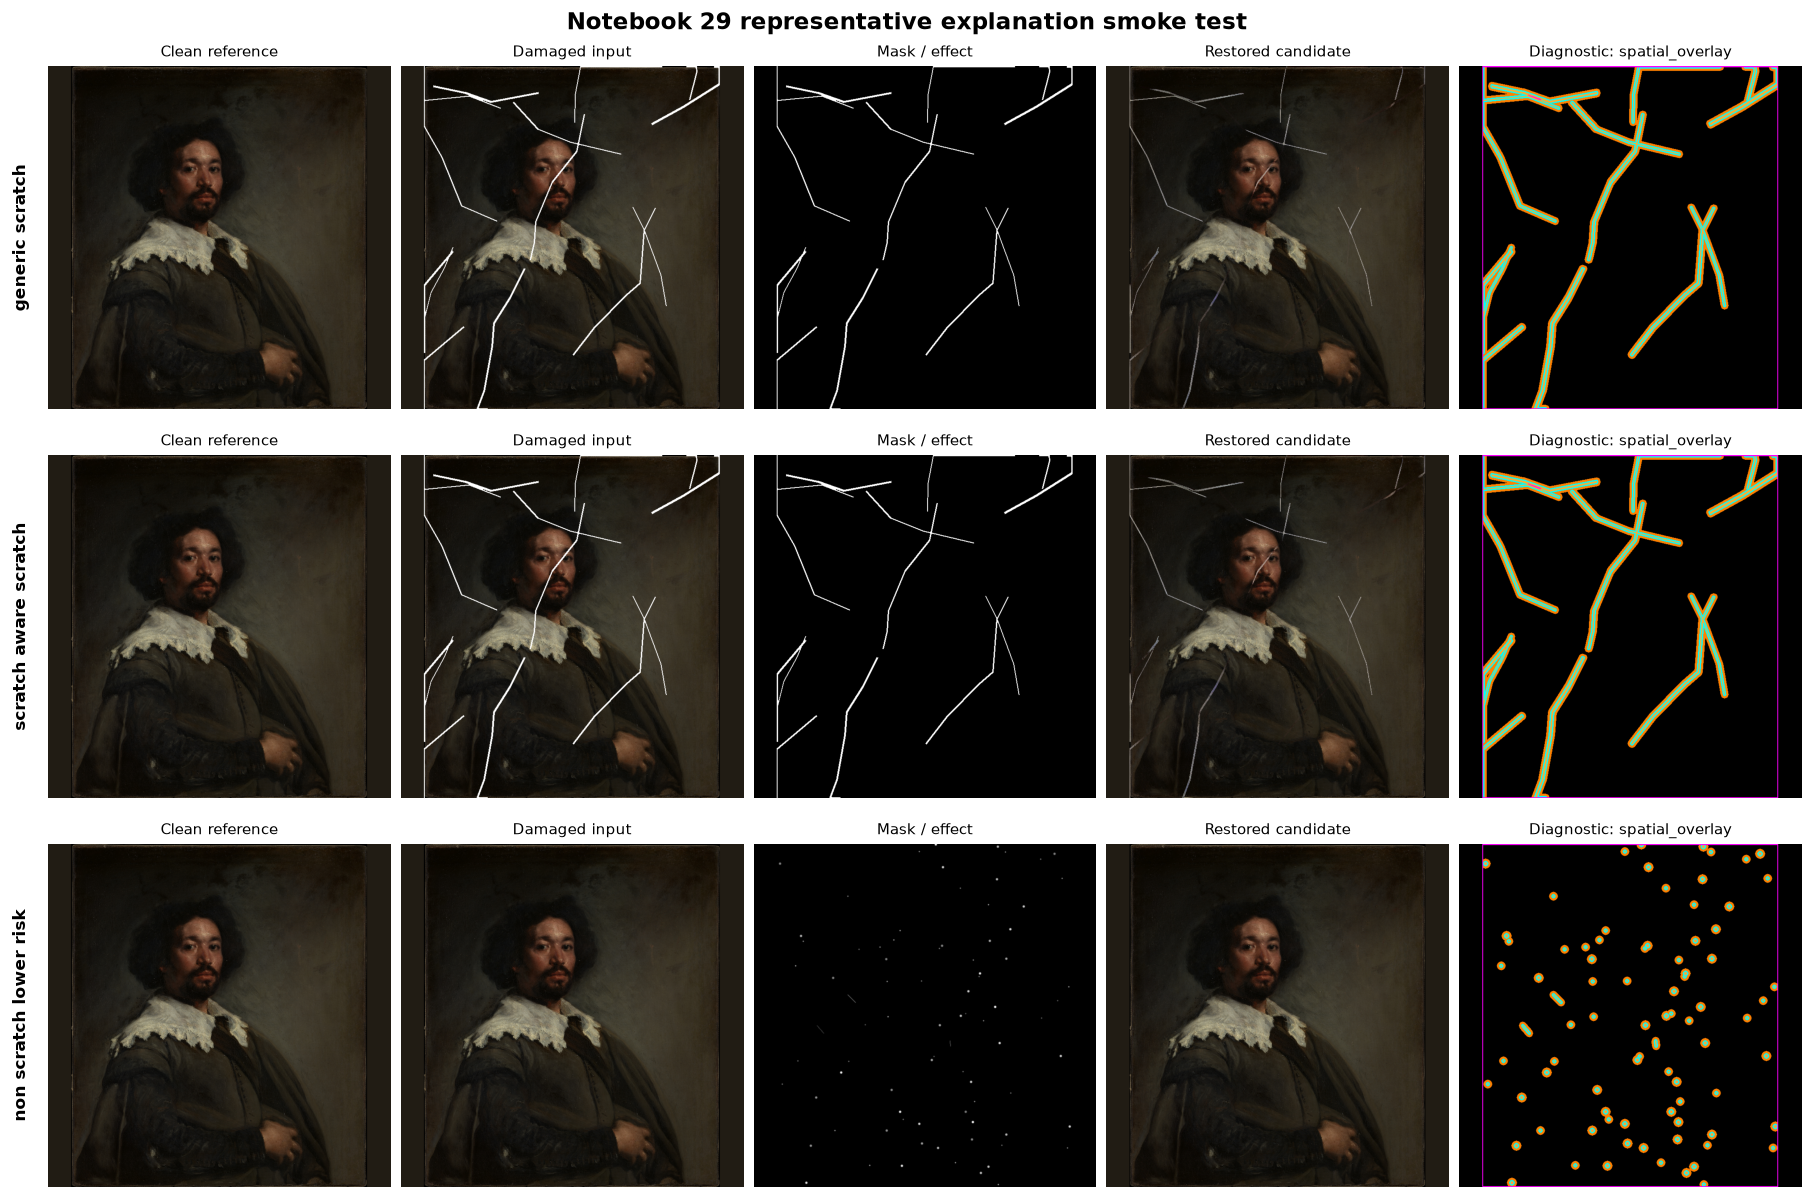

Representative smoke figure rendered in memory.
No figure file was written.


In [14]:
def display_image(
    axis,
    path: Path | None,
    *,
    title: str,
    mask: bool = False,
) -> None:
    """Render one validated image or an explicit missingness tile."""
    axis.set_title(
        title,
        fontsize=9,
    )
    axis.axis("off")

    if (
        path is None
        or not path.exists()
    ):
        axis.set_facecolor(
            "#eeeeee"
        )
        axis.text(
            0.5,
            0.5,
            "Evidence\nnot available",
            ha="center",
            va="center",
            fontsize=9,
            color="#555555",
            transform=axis.transAxes,
        )
        return

    with Image.open(path) as image:
        if mask:
            rendered = image.convert(
                "L"
            )
            axis.imshow(
                rendered,
                cmap="gray",
                vmin=0,
                vmax=255,
            )
        else:
            rendered = image.convert(
                "RGB"
            )
            axis.imshow(rendered)


figure, axes = plt.subplots(
    nrows=len(SMOKE_CASES),
    ncols=5,
    figsize=(15, 10),
    constrained_layout=True,
)

for row_index, smoke_row in (
    SMOKE_CASES.iterrows()
):
    asset_row = (
        SMOKE_ASSETS.loc[
            SMOKE_ASSETS[
                "candidate_id"
            ].eq(
                smoke_row[
                    "candidate_id"
                ]
            )
        ]
        .iloc[0]
    )

    display_image(
        axes[row_index, 0],
        asset_row["clean_path"],
        title="Clean reference",
    )

    display_image(
        axes[row_index, 1],
        asset_row["damaged_path"],
        title="Damaged input",
    )

    display_image(
        axes[row_index, 2],
        asset_row["mask_path"],
        title="Mask / effect",
        mask=True,
    )

    display_image(
        axes[row_index, 3],
        asset_row["restored_path"],
        title="Restored candidate",
    )

    diagnostic_path = (
        asset_row[
            "spatial_map_path"
        ]
        if asset_row[
            "spatial_map_available"
        ]
        else asset_row[
            "semantic_map_path"
        ]
    )

    diagnostic_name = (
        asset_row[
            "spatial_map_type"
        ]
        if asset_row[
            "spatial_map_available"
        ]
        else asset_row[
            "semantic_map_type"
        ]
    )

    display_image(
        axes[row_index, 4],
        diagnostic_path,
        title=(
            "Diagnostic: "
            f"{diagnostic_name}"
        ),
    )

    axes[
        row_index,
        0,
    ].text(
        -0.08,
        0.5,
        str(
            smoke_row[
                "smoke_role"
            ]
        ).replace(
            "_",
            " ",
        ),
        rotation=90,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        transform=axes[
            row_index,
            0,
        ].transAxes,
    )

figure.suptitle(
    "Notebook 29 representative explanation smoke test",
    fontsize=14,
    fontweight="bold",
)

plt.show()
plt.close(figure)

print("Representative smoke figure rendered in memory.")
print("No figure file was written.")

In [15]:
SMOKE_CANDIDATE_IDS = set(
    SMOKE_CASES[
        "candidate_id"
    ]
)

SMOKE_FLAGS = (
    EVIDENCE_TABLES[
        "trustworthiness_flags"
    ].loc[
        EVIDENCE_TABLES[
            "trustworthiness_flags"
        ][
            "candidate_id"
        ].isin(
            SMOKE_CANDIDATE_IDS
        )
    ]
    .copy()
)

SMOKE_FAILURES = (
    EVIDENCE_TABLES[
        "failure_assignments"
    ].loc[
        EVIDENCE_TABLES[
            "failure_assignments"
        ][
            "candidate_id"
        ].isin(
            SMOKE_CANDIDATE_IDS
        )
    ]
    .copy()
)


def sorted_json_values(
    series: pd.Series,
) -> str:
    """Return deterministic unique non-empty values."""
    values = sorted(
        {
            str(value).strip()
            for value in series
            if str(value).strip()
            and str(value).strip().lower()
            != "nan"
        }
    )
    return json.dumps(
        values,
        separators=(",", ":"),
    )


triggered_flags = (
    SMOKE_FLAGS.loc[
        SMOKE_FLAGS[
            "flag_status"
        ].eq("triggered")
    ]
    .groupby(
        "candidate_id"
    )[
        "flag_id"
    ]
    .agg(sorted_json_values)
    .rename(
        "triggered_flag_ids_json"
    )
)

insufficient_flags = (
    SMOKE_FLAGS.loc[
        SMOKE_FLAGS[
            "flag_status"
        ].eq(
            "insufficient_evidence"
        )
    ]
    .groupby(
        "candidate_id"
    )[
        "flag_id"
    ]
    .agg(sorted_json_values)
    .rename(
        "insufficient_flag_ids_json"
    )
)

triggered_categories = (
    SMOKE_FAILURES.loc[
        SMOKE_FAILURES[
            "assignment_status"
        ].eq("triggered")
    ]
    .groupby(
        "candidate_id"
    )[
        "category_id"
    ]
    .agg(sorted_json_values)
    .rename(
        "triggered_category_ids_json"
    )
)

SMOKE_EXPLANATION_SUMMARY = (
    SMOKE_CASES[
        [
            "smoke_role",
            "candidate_id",
            "case_id",
            "model_id",
            "recommendation_category",
            "manual_review_required",
        ]
    ]
    .merge(
        triggered_flags,
        on="candidate_id",
        how="left",
    )
    .merge(
        insufficient_flags,
        on="candidate_id",
        how="left",
    )
    .merge(
        triggered_categories,
        on="candidate_id",
        how="left",
    )
    .merge(
        SMOKE_ASSETS[
            [
                "candidate_id",
                "spatial_map_available",
                "local_map_available",
                "semantic_map_available",
                "uncertainty_map_available",
            ]
        ],
        on="candidate_id",
        how="left",
        validate="one_to_one",
    )
)

for json_column in (
    "triggered_flag_ids_json",
    "insufficient_flag_ids_json",
    "triggered_category_ids_json",
):
    SMOKE_EXPLANATION_SUMMARY[
        json_column
    ] = (
        SMOKE_EXPLANATION_SUMMARY[
            json_column
        ]
        .fillna("[]")
    )

DINO_MANIFEST_VIEW, DINO_VECTORS = (
    load_embedding_index(
        INPUT_PATHS[
            "embedding_manifest_path"
        ],
        INPUT_PATHS[
            "embedding_archive_path"
        ],
        feature_model_id=(
            RETRIEVAL_POLICY[
                "primary_feature_model_id"
            ]
        ),
        image_role=(
            RETRIEVAL_POLICY[
                "image_role"
            ]
        ),
        region_id=(
            RETRIEVAL_POLICY[
                "region_id"
            ]
        ),
    )
)

CLIP_MANIFEST_VIEW, CLIP_VECTORS = (
    load_embedding_index(
        INPUT_PATHS[
            "embedding_manifest_path"
        ],
        INPUT_PATHS[
            "embedding_archive_path"
        ],
        feature_model_id=(
            RETRIEVAL_POLICY[
                "secondary_feature_model_id"
            ]
        ),
        image_role=(
            RETRIEVAL_POLICY[
                "image_role"
            ]
        ),
        region_id=(
            RETRIEVAL_POLICY[
                "region_id"
            ]
        ),
    )
)

dino_index = {
    candidate_id: index
    for index, candidate_id
    in enumerate(
        DINO_MANIFEST_VIEW[
            "representative_candidate_id"
        ].astype(str)
    )
}

clip_index = {
    candidate_id: index
    for index, candidate_id
    in enumerate(
        CLIP_MANIFEST_VIEW[
            "representative_candidate_id"
        ].astype(str)
    )
}

generic_candidate_id = str(
    SMOKE_CASES.loc[
        SMOKE_CASES[
            "smoke_role"
        ].eq(
            "generic_scratch"
        ),
        "candidate_id",
    ].iloc[0]
)

scratch_aware_candidate_id = str(
    SMOKE_CASES.loc[
        SMOKE_CASES[
            "smoke_role"
        ].eq(
            "scratch_aware_scratch"
        ),
        "candidate_id",
    ].iloc[0]
)

smoke_embedding_ids = set(
    SMOKE_CASES[
        "candidate_id"
    ]
)

embedding_coverage_ok = (
    smoke_embedding_ids
    <= set(dino_index)
    and smoke_embedding_ids
    <= set(clip_index)
)

dino_prompt_similarity = float(
    DINO_VECTORS[
        dino_index[
            generic_candidate_id
        ]
    ]
    @ DINO_VECTORS[
        dino_index[
            scratch_aware_candidate_id
        ]
    ]
)

clip_prompt_similarity = float(
    CLIP_VECTORS[
        clip_index[
            generic_candidate_id
        ]
    ]
    @ CLIP_VECTORS[
        clip_index[
            scratch_aware_candidate_id
        ]
    ]
)

SMOKE_PROMPT_SIMILARITY = pd.DataFrame(
    [
        {
            "case_id": (
                SMOKE_SCRATCH_CASE_ID
            ),
            "seed": 2026,
            "comparison": (
                "generic_vs_scratch_aware"
            ),
            "dinov2_cosine_similarity": (
                dino_prompt_similarity
            ),
            "clip_cosine_similarity": (
                clip_prompt_similarity
            ),
            "interpretation": (
                "diagnostic feature similarity; "
                "not restoration correctness"
            ),
        }
    ]
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="smoke_rule_evidence",
    description=(
        "Every smoke candidate resolves its complete "
        "eleven-flag Notebook 27 evidence."
    ),
    expected=33,
    observed=len(
        SMOKE_FLAGS
    ),
    passed=(
        len(SMOKE_FLAGS) == 33
        and SMOKE_FLAGS.groupby(
            "candidate_id"
        )[
            "flag_id"
        ].nunique()
        .eq(11)
        .all()
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="smoke_embedding_access",
    description=(
        "All smoke candidates resolve separate normalized "
        "DINOv2 and CLIP restored-content embeddings."
    ),
    expected={
        "candidates": 3,
        "dinov2": True,
        "clip": True,
    },
    observed={
        "candidates": len(
            smoke_embedding_ids
        ),
        "dinov2": (
            smoke_embedding_ids
            <= set(dino_index)
        ),
        "clip": (
            smoke_embedding_ids
            <= set(clip_index)
        ),
    },
    passed=embedding_coverage_ok,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="prompt_similarity_finite",
    description=(
        "Generic/scratch-aware similarities are finite "
        "and remain separate by feature model."
    ),
    expected=True,
    observed={
        "dinov2": dino_prompt_similarity,
        "clip": clip_prompt_similarity,
    },
    passed=(
        np.isfinite(
            dino_prompt_similarity
        )
        and np.isfinite(
            clip_prompt_similarity
        )
    ),
)

unexpected_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="smoke_creates_no_files",
    description=(
        "The representative smoke test creates no "
        "canonical or temporary output files."
    ),
    expected=0,
    observed=len(
        unexpected_output_files
    ),
    passed=not unexpected_output_files,
)

display(SMOKE_EXPLANATION_SUMMARY)
display(SMOKE_PROMPT_SIMILARITY)

BATCH_3_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_3_ROWS = (
    BATCH_3_VALIDATION.loc[
        BATCH_3_VALIDATION[
            "validation_stage"
        ].eq(BATCH_3_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_3_ROWS)

print("Batch 3 representative smoke test complete.")
print(
    "Validation checks: "
    f"{len(BATCH_3_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_3_ROWS['passed']).sum()):,}"
)
print(
    "DINOv2 generic/scratch-aware similarity: "
    f"{dino_prompt_similarity:.6f}"
)
print(
    "CLIP generic/scratch-aware similarity: "
    f"{clip_prompt_similarity:.6f}"
)

VALIDATION.raise_for_blocking()

,smoke_role,candidate_id,case_id,model_id,recommendation_category,manual_review_required,triggered_flag_ids_json,insufficient_flag_ids_json,triggered_category_ids_json,spatial_map_available,local_map_available,semantic_map_available,uncertainty_map_available
0,generic_scratch,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,stable_diffusion_inpainting,specialist_review_required,True,"[""colour_inconsistency"",""manual_review_required"",""metric_disagreement"",""structural_inconsistency"",""texture_inconsistency"",""visible_boundary_artifact_proxy""]",[],"[""boundary_seam"",""colour_bleeding_proxy"",""colour_drift"",""repeated_texture_proxy"",""residual_masked_error"",""structural_collapse_proxy"",""texture_discontinuity""]",True,True,True,True
1,scratch_aware_scratch,sd15__p05__s2026__b0c01d8159c0,canonical__p001__scratch_thin,stable_diffusion_inpainting,specialist_review_required,True,"[""colour_inconsistency"",""high_generative_uncertainty"",""manual_review_required"",""metric_disagreement"",""structural_inconsistency"",""texture_inconsistency"",""visible_boundary_artifa...",[],"[""boundary_seam"",""colour_bleeding_proxy"",""colour_drift"",""repeated_texture_proxy"",""residual_masked_error"",""structural_collapse_proxy"",""texture_discontinuity"",""unstable_multi_see...",True,False,False,True
2,non_scratch_lower_risk,candidate__hint_places2__synthetic_degradation__p001__dirt_dust__mild__c00,synthetic_degradation__p001__dirt_dust__mild,hint_places2,suitable_for_preliminary_inspection,False,"[""metric_disagreement""]",[],[],True,True,True,False


,case_id,seed,comparison,dinov2_cosine_similarity,clip_cosine_similarity,interpretation
0,canonical__p001__scratch_thin,2026,generic_vs_scratch_aware,0.997475,0.998631,diagnostic feature similarity; not restoration correctness


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_smoke_test,smoke_selection_roles,The smoke population contains exactly the three approved explanation roles.,blocking,"[""generic_scratch"", ""non_scratch_lower_risk"", ""scratch_aware_scratch""]","[""generic_scratch"", ""non_scratch_lower_risk"", ""scratch_aware_scratch""]",True,
1,batch_3_smoke_test,scratch_prompt_pair,Generic and scratch-aware smoke candidates use the same case and seed.,blocking,"{""cases"": 1, ""prompt_variants"": [""p00_generic"", ""p05_scratch_aware""], ""seeds"": [2026]}","{""cases"": 1, ""prompt_variants"": [""p00_generic"", ""p05_scratch_aware""], ""seeds"": [2026]}",True,
2,batch_3_smoke_test,smoke_base_assets,"Every smoke candidate resolves its clean, damaged, mask, and restored image.",blocking,12,12,True,
3,batch_3_smoke_test,smoke_spatial_semantic_assets,All smoke candidates have spatial maps; semantic-panel availability matches the approved upstream selection scope.,blocking,"{""scratch_aware_semantic_missing"": true, ""semantic"": 2, ""spatial"": 3}","{""scratch_aware_semantic_missing"": true, ""semantic"": 2, ""spatial"": 3}",True,
4,batch_3_smoke_test,smoke_rule_evidence,Every smoke candidate resolves its complete eleven-flag Notebook 27 evidence.,blocking,33,33,True,
5,batch_3_smoke_test,smoke_embedding_access,All smoke candidates resolve separate normalized DINOv2 and CLIP restored-content embeddings.,blocking,"{""candidates"": 3, ""clip"": true, ""dinov2"": true}","{""candidates"": 3, ""clip"": true, ""dinov2"": true}",True,
6,batch_3_smoke_test,prompt_similarity_finite,Generic/scratch-aware similarities are finite and remain separate by feature model.,blocking,True,"{""clip"": 0.9986312389373779, ""dinov2"": 0.9974747896194458}",True,
7,batch_3_smoke_test,smoke_creates_no_files,The representative smoke test creates no canonical or temporary output files.,blocking,0,0,True,


Batch 3 representative smoke test complete.
Validation checks: 8
Blocking failures: 0
DINOv2 generic/scratch-aware similarity: 0.997475
CLIP generic/scratch-aware similarity: 0.998631


## Batch 4 — Explanation-case selection

This batch deterministically selects:

- ten embedding-retrieval queries:
  - one rule-defined lower-risk query from each complete artwork category;
  - one flagged query from each complete artwork category;
- fourteen counterfactual explanation units:
  - two damage-size comparisons;
  - two mask-placement comparisons;
  - two cross-model comparisons;
  - two metric-subset comparisons;
  - two diffusion-seed comparisons;
  - two evidence-family-removal comparisons;
  - two generic-versus-scratch-aware prompt comparisons.

Selections prioritize:

- complete candidate identity and restored-image provenance;
- separate DINOv2 and CLIP retrieval eligibility;
- category coverage;
- representation across the four full-run methods where supported;
- distinct paintings where supported;
- complete comparison membership;
- deterministic ordering;
- operational lower-risk or flagged states without treating either as human ground truth.

Cross-model counterfactuals use the four full-run methods: Telea, LaMa, HINT, and Stable Diffusion. Bounded SDXL remains separate and is not treated as a complete-population method.

The selected 24 visual units illustrate but do not filter or replace the complete 13,879-row Controlled-300 explanation catalogue.

This batch does not calculate nearest neighbours, assemble complete rule explanations, generate panels, persist canonical outputs, or build the HTML report.

In [16]:
BATCH_4_STAGE = "batch_4_case_selection"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_4_STAGE,
)


def bool_value(value) -> bool:
    """Coerce common tabular boolean representations."""
    if isinstance(
        value,
        (bool, np.bool_),
    ):
        return bool(value)

    if value is None:
        return False

    try:
        if pd.isna(value):
            return False
    except (TypeError, ValueError):
        pass

    return (
        str(value)
        .strip()
        .lower()
        in {
            "true",
            "1",
            "1.0",
            "yes",
            "y",
        }
    )


def compact_json_list(values) -> str:
    """Encode deterministic unique non-empty values."""
    cleaned = sorted(
        {
            str(value).strip()
            for value in values
            if str(value).strip()
            and str(value).strip().lower()
            != "nan"
        }
    )

    return json.dumps(
        cleaned,
        separators=(",", ":"),
    )


def parse_json_list(value) -> list[str]:
    """Parse one canonical JSON-list field."""
    parsed = json.loads(
        str(value)
    )

    if not isinstance(
        parsed,
        list,
    ):
        raise ValueError(
            "Expected a JSON list."
        )

    return [
        str(item)
        for item in parsed
    ]


CATEGORY_ORDER = [
    "portrait_figure",
    "landscape_natural",
    "architecture_structured",
    "high_texture_brushwork",
    "abstraction_surrealism",
]

LOWER_RISK_CATEGORY = (
    RETRIEVAL_POLICY[
        "lower_risk_recommendation_category"
    ]
)

QUERY_ELIGIBLE_IDS = (
    DINO_ELIGIBLE_IDS
    & CLIP_ELIGIBLE_IDS
    & candidate_evidence_sets[
        "spatial_maps"
    ]
)

query_pool = (
    CATALOG_BASE.loc[
        CATALOG_BASE[
            "candidate_id"
        ].isin(
            QUERY_ELIGIBLE_IDS
        )
        & CATALOG_BASE[
            "category"
        ].isin(
            CATEGORY_ORDER
        )
        & ~CATALOG_BASE[
            "model_id"
        ].eq(
            "sdxl_inpainting"
        )
    ]
    .copy()
)

query_pool[
    "manual_review_bool"
] = query_pool[
    "manual_review_required"
].map(bool_value)

query_pool[
    "query_lane"
] = np.where(
    query_pool[
        "recommendation_category"
    ].eq(
        LOWER_RISK_CATEGORY
    )
    & ~query_pool[
        "manual_review_bool"
    ],
    "lower_risk",
    "flagged",
)

preferred_models = {
    "lower_risk": [
        "lama",
        "hint_places2",
        "opencv_telea",
        "stable_diffusion_inpainting",
    ],
    "flagged": [
        "stable_diffusion_inpainting",
        "hint_places2",
        "lama",
        "opencv_telea",
    ],
}

selected_query_rows = []
used_query_candidates = set()
used_query_paintings = set()

for category_index, category in enumerate(
    CATEGORY_ORDER
):
    for lane_index, lane in enumerate(
        [
            "lower_risk",
            "flagged",
        ]
    ):
        candidates = (
            query_pool.loc[
                query_pool[
                    "category"
                ].eq(category)
                & query_pool[
                    "query_lane"
                ].eq(lane)
                & ~query_pool[
                    "candidate_id"
                ].isin(
                    used_query_candidates
                )
            ]
            .copy()
        )

        if candidates.empty:
            raise RuntimeError(
                "No eligible retrieval query for "
                f"category={category}, lane={lane}."
            )

        rotated_models = (
            preferred_models[lane][
                category_index
                % len(
                    preferred_models[
                        lane
                    ]
                ):
            ]
            + preferred_models[lane][
                : category_index
                % len(
                    preferred_models[
                        lane
                    ]
                )
            ]
        )

        model_priority = {
            model_id: priority
            for priority, model_id
            in enumerate(
                rotated_models
            )
        }

        candidates[
            "_model_priority"
        ] = candidates[
            "model_id"
        ].map(
            model_priority
        ).fillna(
            len(model_priority)
        )

        candidates[
            "_new_painting_priority"
        ] = candidates[
            "painting_id"
        ].isin(
            used_query_paintings
        ).astype(int)

        candidates = candidates.sort_values(
            [
                "_new_painting_priority",
                "_model_priority",
                "painting_id",
                "case_id",
                "candidate_id",
            ],
            kind="mergesort",
        )

        selected = candidates.iloc[0]

        query_order = (
            category_index * 2
            + lane_index
            + 1
        )

        query_id = (
            f"query_{query_order:02d}_"
            f"{category}_{lane}"
        )

        selected_query_rows.append(
            {
                "query_id": query_id,
                "query_order": query_order,
                "query_lane": lane,
                "category": category,
                "candidate_id": (
                    selected[
                        "candidate_id"
                    ]
                ),
                "case_id": (
                    selected["case_id"]
                ),
                "painting_id": (
                    selected[
                        "painting_id"
                    ]
                ),
                "model_id": (
                    selected["model_id"]
                ),
                "experiment_id": (
                    selected[
                        "experiment_id"
                    ]
                ),
                "prompt_variant_id": (
                    selected[
                        "prompt_variant_id"
                    ]
                ),
                "recommendation_category": (
                    selected[
                        "recommendation_category"
                    ]
                ),
                "manual_review_required": (
                    bool_value(
                        selected[
                            "manual_review_required"
                        ]
                    )
                ),
                "selection_reason": (
                    f"{lane} query for complete "
                    f"category {category}; DINOv2, "
                    "CLIP, and spatial evidence available"
                ),
            }
        )

        used_query_candidates.add(
            str(
                selected[
                    "candidate_id"
                ]
            )
        )
        used_query_paintings.add(
            str(
                selected[
                    "painting_id"
                ]
            )
        )

RETRIEVAL_QUERY_SELECTIONS = (
    pd.DataFrame(
        selected_query_rows
    )
    .sort_values(
        "query_order"
    )
    .reset_index(drop=True)
)

display(RETRIEVAL_QUERY_SELECTIONS)

print("Retrieval queries selected.")
print(
    f"Queries: {len(RETRIEVAL_QUERY_SELECTIONS):,}"
)
print(
    "Distinct paintings: "
    f"{RETRIEVAL_QUERY_SELECTIONS['painting_id'].nunique():,}"
)

,query_id,query_order,query_lane,category,candidate_id,case_id,painting_id,model_id,experiment_id,prompt_variant_id,recommendation_category,manual_review_required,selection_reason
0,query_01_portrait_figure_lower_risk,1,lower_risk,portrait_figure,candidate__lama__synthetic_degradation__p001__dirt_dust__moderate__c00,synthetic_degradation__p001__dirt_dust__moderate,p001,lama,synthetic_degradation,,suitable_for_preliminary_inspection,False,"lower_risk query for complete category portrait_figure; DINOv2, CLIP, and spatial evidence available"
1,query_02_portrait_figure_flagged,2,flagged,portrait_figure,sd15__p00__s2026__29ff258ff921,canonical__p002__loss_large,p002,stable_diffusion_inpainting,canonical_missing_region,p00_generic,unstable_candidate,True,"flagged query for complete category portrait_figure; DINOv2, CLIP, and spatial evidence available"
2,query_03_landscape_natural_lower_risk,3,lower_risk,landscape_natural,candidate__hint_places2__synthetic_degradation__p018__dirt_dust__mild__c00,synthetic_degradation__p018__dirt_dust__mild,p018,hint_places2,synthetic_degradation,,suitable_for_preliminary_inspection,False,"lower_risk query for complete category landscape_natural; DINOv2, CLIP, and spatial evidence available"
3,query_04_landscape_natural_flagged,4,flagged,landscape_natural,candidate__hint_places2__canonical__p011__loss_large__c00,canonical__p011__loss_large,p011,hint_places2,canonical_missing_region,,do_not_rely_automatically,True,"flagged query for complete category landscape_natural; DINOv2, CLIP, and spatial evidence available"
4,query_05_architecture_structured_lower_risk,5,lower_risk,architecture_structured,candidate__opencv_telea__synthetic_degradation__p026__dirt_dust__mild__c00,synthetic_degradation__p026__dirt_dust__mild,p026,opencv_telea,synthetic_degradation,,suitable_for_preliminary_inspection,False,"lower_risk query for complete category architecture_structured; DINOv2, CLIP, and spatial evidence available"
5,query_06_architecture_structured_flagged,6,flagged,architecture_structured,candidate__lama__canonical__p021__loss_large__c00,canonical__p021__loss_large,p021,lama,canonical_missing_region,,specialist_review_required,True,"flagged query for complete category architecture_structured; DINOv2, CLIP, and spatial evidence available"
6,query_07_high_texture_brushwork_lower_risk,7,lower_risk,high_texture_brushwork,sd15__p00__s2026__63b2979234cc,damage_size__p223__loss_large__size_08pct,p223,stable_diffusion_inpainting,damage_size_sensitivity,p00_generic,suitable_for_preliminary_inspection,False,"lower_risk query for complete category high_texture_brushwork; DINOv2, CLIP, and spatial evidence available"
7,query_08_high_texture_brushwork_flagged,8,flagged,high_texture_brushwork,candidate__opencv_telea__canonical__p041__loss_large__c00,canonical__p041__loss_large,p041,opencv_telea,canonical_missing_region,,specialist_review_required,True,"flagged query for complete category high_texture_brushwork; DINOv2, CLIP, and spatial evidence available"
8,query_09_abstraction_surrealism_lower_risk,9,lower_risk,abstraction_surrealism,candidate__lama__synthetic_degradation__p039__dirt_dust__moderate__c00,synthetic_degradation__p039__dirt_dust__moderate,p039,lama,synthetic_degradation,,suitable_for_preliminary_inspection,False,"lower_risk query for complete category abstraction_surrealism; DINOv2, CLIP, and spatial evidence available"
9,query_10_abstraction_surrealism_flagged,10,flagged,abstraction_surrealism,sd15__p00__s2026__9c54abbc36c9,canonical__p031__loss_large,p031,stable_diffusion_inpainting,canonical_missing_region,p00_generic,do_not_rely_automatically,True,"flagged query for complete category abstraction_surrealism; DINOv2, CLIP, and spatial evidence available"


Retrieval queries selected.
Queries: 10
Distinct paintings: 10


In [17]:
COUNTERFACTUAL_COLUMNS = [
    "counterfactual_panel_id",
    "counterfactual_type",
    "type_rank",
    "painting_id",
    "case_id",
    "model_id",
    "member_candidate_ids_json",
    "comparison_values_json",
    "scenario_ids_json",
    "source_notebook_ids_json",
    "selection_reason",
    "status",
]

counterfactual_rows = []


def append_counterfactual(
    *,
    counterfactual_type: str,
    type_rank: int,
    painting_id: str,
    case_id: str,
    model_id: str,
    member_candidate_ids,
    comparison_values,
    scenario_ids=(),
    source_notebook_ids=(),
    selection_reason: str,
) -> None:
    """Append one deterministic counterfactual selection."""
    counterfactual_rows.append(
        {
            "counterfactual_panel_id": (
                f"cf_{counterfactual_type}_"
                f"{type_rank:02d}"
            ),
            "counterfactual_type": (
                counterfactual_type
            ),
            "type_rank": int(
                type_rank
            ),
            "painting_id": str(
                painting_id
            ),
            "case_id": str(
                case_id
            ),
            "model_id": str(
                model_id
            ),
            "member_candidate_ids_json": (
                compact_json_list(
                    member_candidate_ids
                )
            ),
            "comparison_values_json": (
                compact_json_list(
                    comparison_values
                )
            ),
            "scenario_ids_json": (
                compact_json_list(
                    scenario_ids
                )
            ),
            "source_notebook_ids_json": (
                compact_json_list(
                    source_notebook_ids
                )
            ),
            "selection_reason": (
                selection_reason
            ),
            "status": "selected",
        }
    )


primary_roles = {
    "primary_comparison",
    "primary_and_uncertainty",
}

primary_population = (
    CATALOG_BASE.loc[
        CATALOG_BASE[
            "population_role"
        ].isin(
            primary_roles
        )
    ]
    .copy()
)

# ------------------------------------------------------------------
# Damage-size counterfactuals
# ------------------------------------------------------------------

damage_size_pool = (
    primary_population.loc[
        primary_population[
            "experiment_id"
        ].eq(
            "damage_size_sensitivity"
        )
        & primary_population[
            "target_damage_fraction"
        ].notna()
    ]
    .copy()
)

damage_size_groups = []

for (
    painting_id,
    model_id,
), group in damage_size_pool.groupby(
    [
        "painting_id",
        "model_id",
    ],
    sort=True,
):
    selected_members = (
        group.sort_values(
            [
                "target_damage_fraction",
                "case_id",
                "candidate_id",
            ],
            kind="mergesort",
        )
        .drop_duplicates(
            "target_damage_fraction"
        )
    )

    if (
        selected_members[
            "target_damage_fraction"
        ].nunique()
        >= 3
    ):
        damage_size_groups.append(
            {
                "painting_id": (
                    painting_id
                ),
                "model_id": model_id,
                "members": (
                    selected_members
                ),
            }
        )

damage_size_selected = []

for preferred_model in (
    "lama",
    "stable_diffusion_inpainting",
):
    eligible = [
        group
        for group in damage_size_groups
        if group[
            "model_id"
        ]
        == preferred_model
        and group[
            "painting_id"
        ]
        not in {
            item[
                "painting_id"
            ]
            for item
            in damage_size_selected
        }
    ]

    if not eligible:
        eligible = [
            group
            for group in damage_size_groups
            if group[
                "painting_id"
            ]
            not in {
                item[
                    "painting_id"
                ]
                for item
                in damage_size_selected
            }
        ]

    if not eligible:
        raise RuntimeError(
            "Insufficient complete damage-size "
            "counterfactual groups."
        )

    damage_size_selected.append(
        eligible[0]
    )

for rank, selection in enumerate(
    damage_size_selected,
    start=1,
):
    members = selection[
        "members"
    ]

    append_counterfactual(
        counterfactual_type=(
            "damage_size"
        ),
        type_rank=rank,
        painting_id=(
            selection[
                "painting_id"
            ]
        ),
        case_id=(
            "multiple_damage_size_cases"
        ),
        model_id=(
            selection["model_id"]
        ),
        member_candidate_ids=(
            members[
                "candidate_id"
            ].tolist()
        ),
        comparison_values=[
            f"{value:.6f}"
            for value in members[
                "target_damage_fraction"
            ].astype(float)
        ],
        source_notebook_ids=[
            "22",
            "23",
        ],
        selection_reason=(
            "same painting and model across "
            "at least three target damage fractions"
        ),
    )

# ------------------------------------------------------------------
# Mask-placement counterfactuals
# ------------------------------------------------------------------

mask_pool = (
    primary_population.loc[
        primary_population[
            "experiment_id"
        ].eq(
            "mask_robustness"
        )
    ]
    .copy()
)

mask_groups = []

for (
    painting_id,
    model_id,
), group in mask_pool.groupby(
    [
        "painting_id",
        "model_id",
    ],
    sort=True,
):
    selected_members = (
        group.sort_values(
            [
                "case_id",
                "candidate_id",
            ],
            kind="mergesort",
        )
        .drop_duplicates(
            "case_id"
        )
    )

    if (
        selected_members[
            "case_id"
        ].nunique()
        >= 3
    ):
        mask_groups.append(
            {
                "painting_id": (
                    painting_id
                ),
                "model_id": model_id,
                "members": (
                    selected_members
                ),
            }
        )

mask_selected = []

for preferred_model in (
    "opencv_telea",
    "lama",
):
    eligible = [
        group
        for group in mask_groups
        if group[
            "model_id"
        ]
        == preferred_model
        and group[
            "painting_id"
        ]
        not in {
            item[
                "painting_id"
            ]
            for item
            in mask_selected
        }
    ]

    if not eligible:
        eligible = [
            group
            for group in mask_groups
            if group[
                "painting_id"
            ]
            not in {
                item[
                    "painting_id"
                ]
                for item
                in mask_selected
            }
        ]

    if not eligible:
        raise RuntimeError(
            "Insufficient complete mask-placement "
            "counterfactual groups."
        )

    mask_selected.append(
        eligible[0]
    )

for rank, selection in enumerate(
    mask_selected,
    start=1,
):
    members = selection[
        "members"
    ]

    append_counterfactual(
        counterfactual_type=(
            "mask_placement"
        ),
        type_rank=rank,
        painting_id=(
            selection[
                "painting_id"
            ]
        ),
        case_id=(
            "multiple_mask_placement_cases"
        ),
        model_id=(
            selection["model_id"]
        ),
        member_candidate_ids=(
            members[
                "candidate_id"
            ].tolist()
        ),
        comparison_values=(
            members[
                "case_id"
            ].tolist()
        ),
        source_notebook_ids=[
            "24",
        ],
        selection_reason=(
            "same painting and model across "
            "at least three mask placements"
        ),
    )

# ------------------------------------------------------------------
# Cross-model counterfactuals
# ------------------------------------------------------------------

CORE_MODELS = {
    "opencv_telea",
    "lama",
    "hint_places2",
    "stable_diffusion_inpainting",
}

cross_model_groups = []

for case_id, group in (
    primary_population.groupby(
        "case_id",
        sort=True,
    )
):
    available_models = set(
        group[
            "model_id"
        ].astype(str)
    )

    if not (
        CORE_MODELS
        <= available_models
    ):
        continue

    selected_members = []

    for model_id in sorted(
        CORE_MODELS
    ):
        model_member = (
            group.loc[
                group[
                    "model_id"
                ].eq(model_id)
            ]
            .sort_values(
                [
                    "seed",
                    "candidate_id",
                ],
                kind="mergesort",
                na_position="last",
            )
            .iloc[0]
        )

        selected_members.append(
            model_member
        )

    members = pd.DataFrame(
        selected_members
    )

    cross_model_groups.append(
        {
            "case_id": case_id,
            "painting_id": (
                members[
                    "painting_id"
                ].iloc[0]
            ),
            "is_scratch": (
                "scratch_thin"
                in str(case_id)
            ),
            "members": members,
        }
    )

scratch_cross = [
    item
    for item in cross_model_groups
    if item["is_scratch"]
]

non_scratch_cross = [
    item
    for item in cross_model_groups
    if not item["is_scratch"]
]

if (
    not scratch_cross
    or not non_scratch_cross
):
    raise RuntimeError(
        "Complete scratch and non-scratch "
        "cross-model groups are required."
    )

cross_model_selected = [
    scratch_cross[0],
    non_scratch_cross[0],
]

for rank, selection in enumerate(
    cross_model_selected,
    start=1,
):
    members = selection[
        "members"
    ]

    append_counterfactual(
        counterfactual_type=(
            "cross_model"
        ),
        type_rank=rank,
        painting_id=(
            selection[
                "painting_id"
            ]
        ),
        case_id=(
            selection["case_id"]
        ),
        model_id="multiple_models",
        member_candidate_ids=(
            members[
                "candidate_id"
            ].tolist()
        ),
        comparison_values=(
            members[
                "model_id"
            ].tolist()
        ),
        source_notebook_ids=[
            "21",
        ],
        selection_reason=(
            "same restoration case across "
            "Telea, LaMa, HINT, and Stable Diffusion"
        ),
    )

print("Damage-size, placement, and cross-model selections complete.")
print(
    "Counterfactual rows assembled so far: "
    f"{len(counterfactual_rows):,}"
)

Damage-size, placement, and cross-model selections complete.
Counterfactual rows assembled so far: 6


In [18]:
FLAG_STABILITY = (
    EVIDENCE_TABLES[
        "flag_stability"
    ]
)

require_columns(
    FLAG_STABILITY,
    {
        "scenario_id",
        "scenario_family",
        "candidate_id",
        "changed_flag_count",
        "status",
    },
    table_name="flag_stability",
)

flag_stability_work = (
    FLAG_STABILITY.loc[
        FLAG_STABILITY[
            "candidate_id"
        ].isin(
            CATALOG_CANDIDATE_IDS
        )
        & FLAG_STABILITY[
            "status"
        ].eq("ok")
    ]
    .copy()
)

flag_stability_work[
    "changed_flag_count"
] = pd.to_numeric(
    flag_stability_work[
        "changed_flag_count"
    ],
    errors="coerce",
).fillna(0)

catalog_selection_metadata = (
    CATALOG_BASE[
        [
            "candidate_id",
            "case_id",
            "painting_id",
            "model_id",
            "recommendation_category",
            "manual_review_required",
        ]
    ]
    .drop_duplicates(
        "candidate_id"
    )
)

# ------------------------------------------------------------------
# Metric-subset counterfactuals
# ------------------------------------------------------------------

metric_subset_scenarios = {
    "only_classical",
    "only_perceptual",
    "only_semantic_feature",
}

metric_subset_changes = (
    flag_stability_work.loc[
        flag_stability_work[
            "scenario_id"
        ].isin(
            metric_subset_scenarios
        )
    ]
    .groupby(
        "candidate_id"
    )
    .agg(
        changed_flags=(
            "changed_flag_count",
            "sum",
        ),
        scenario_count=(
            "scenario_id",
            "nunique",
        ),
    )
    .reset_index()
    .merge(
        catalog_selection_metadata,
        on="candidate_id",
        how="left",
        validate="one_to_one",
    )
)

metric_subset_changes[
    "manual_review_bool"
] = (
    metric_subset_changes[
        "manual_review_required"
    ].map(bool_value)
)

metric_subset_candidates = []

for lane in (
    "lower_risk",
    "flagged",
):
    if lane == "lower_risk":
        eligible = (
            metric_subset_changes.loc[
                metric_subset_changes[
                    "recommendation_category"
                ].eq(
                    LOWER_RISK_CATEGORY
                )
                & ~metric_subset_changes[
                    "manual_review_bool"
                ]
            ]
        )
    else:
        eligible = (
            metric_subset_changes.loc[
                ~metric_subset_changes[
                    "recommendation_category"
                ].eq(
                    LOWER_RISK_CATEGORY
                )
                | metric_subset_changes[
                    "manual_review_bool"
                ]
            ]
        )

    eligible = (
        eligible.sort_values(
            [
                "changed_flags",
                "painting_id",
                "case_id",
                "candidate_id",
            ],
            ascending=[
                False,
                True,
                True,
                True,
            ],
            kind="mergesort",
        )
    )

    if eligible.empty:
        raise RuntimeError(
            "Metric-subset selection lacks "
            f"a {lane} candidate."
        )

    metric_subset_candidates.append(
        eligible.iloc[0]
    )

for rank, selection in enumerate(
    metric_subset_candidates,
    start=1,
):
    append_counterfactual(
        counterfactual_type=(
            "metric_subset"
        ),
        type_rank=rank,
        painting_id=(
            selection[
                "painting_id"
            ]
        ),
        case_id=(
            selection["case_id"]
        ),
        model_id=(
            selection["model_id"]
        ),
        member_candidate_ids=[
            selection[
                "candidate_id"
            ]
        ],
        comparison_values=[
            "complete_approved_framework",
            *sorted(
                metric_subset_scenarios
            ),
        ],
        scenario_ids=[
            "complete_approved_framework",
            *sorted(
                metric_subset_scenarios
            ),
        ],
        source_notebook_ids=[
            "27",
            "28",
        ],
        selection_reason=(
            "same candidate under complete and "
            "include-only metric-family policies"
        ),
    )

# ------------------------------------------------------------------
# Diffusion-seed counterfactuals
# ------------------------------------------------------------------

diffusion_seed_pool = (
    CATALOG_BASE.loc[
        CATALOG_BASE[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & CATALOG_BASE[
            "seed"
        ].notna()
    ]
    .copy()
)

seed_groups = []

for (
    case_id,
    prompt_variant_id,
), group in diffusion_seed_pool.groupby(
    [
        "case_id",
        "prompt_variant_id",
    ],
    dropna=False,
    sort=True,
):
    selected_members = (
        group.sort_values(
            [
                "seed",
                "candidate_id",
            ],
            kind="mergesort",
        )
        .drop_duplicates("seed")
    )

    observed_seeds = set(
        selected_members[
            "seed"
        ].dropna()
        .astype(int)
    )

    if {
        2026,
        2027,
        2028,
        2029,
    } <= observed_seeds:
        selected_members = (
            selected_members.loc[
                selected_members[
                    "seed"
                ].astype(int)
                .isin(
                    {
                        2026,
                        2027,
                        2028,
                        2029,
                    }
                )
            ]
            .sort_values(
                "seed",
                kind="mergesort",
            )
        )

        seed_groups.append(
            {
                "case_id": case_id,
                "prompt_variant_id": (
                    str(
                        prompt_variant_id
                    )
                ),
                "painting_id": (
                    selected_members[
                        "painting_id"
                    ].iloc[0]
                ),
                "is_scratch": (
                    "scratch_thin"
                    in str(case_id)
                ),
                "members": (
                    selected_members
                ),
            }
        )

generic_scratch_seed_groups = [
    item
    for item in seed_groups
    if item["is_scratch"]
    and item[
        "prompt_variant_id"
    ]
    == "p00_generic"
]

generic_non_scratch_seed_groups = [
    item
    for item in seed_groups
    if not item["is_scratch"]
    and item[
        "prompt_variant_id"
    ]
    == "p00_generic"
]

if (
    not generic_scratch_seed_groups
    or not generic_non_scratch_seed_groups
):
    raise RuntimeError(
        "Complete generic scratch and non-scratch "
        "four-seed groups are required."
    )

seed_selected = [
    generic_scratch_seed_groups[0],
    generic_non_scratch_seed_groups[0],
]

for rank, selection in enumerate(
    seed_selected,
    start=1,
):
    members = selection[
        "members"
    ]

    append_counterfactual(
        counterfactual_type=(
            "diffusion_seed"
        ),
        type_rank=rank,
        painting_id=(
            selection[
                "painting_id"
            ]
        ),
        case_id=(
            selection["case_id"]
        ),
        model_id=(
            "stable_diffusion_inpainting"
        ),
        member_candidate_ids=(
            members[
                "candidate_id"
            ].tolist()
        ),
        comparison_values=[
            str(seed)
            for seed in members[
                "seed"
            ].astype(int)
        ],
        source_notebook_ids=[
            "18",
            "22",
        ],
        selection_reason=(
            "same case and prompt across frozen "
            "seeds 2026, 2027, 2028, and 2029"
        ),
    )

# ------------------------------------------------------------------
# Evidence-family-removal counterfactuals
# ------------------------------------------------------------------

removal_changes = (
    flag_stability_work.loc[
        flag_stability_work[
            "scenario_id"
        ].astype(str)
        .str.startswith(
            "without_"
        )
    ]
    .groupby(
        "candidate_id"
    )
    .agg(
        changed_flags=(
            "changed_flag_count",
            "sum",
        ),
        changed_scenarios=(
            "scenario_id",
            lambda values: (
                compact_json_list(
                    values
                )
            ),
        ),
    )
    .reset_index()
    .merge(
        catalog_selection_metadata,
        on="candidate_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "changed_flags",
            "painting_id",
            "case_id",
            "candidate_id",
        ],
        ascending=[
            False,
            True,
            True,
            True,
        ],
        kind="mergesort",
    )
)

removal_selected_rows = []
used_removal_paintings = set()

for _, row in removal_changes.iterrows():
    if (
        float(
            row[
                "changed_flags"
            ]
        )
        <= 0
    ):
        continue

    painting_id = str(
        row[
            "painting_id"
        ]
    )

    if (
        painting_id
        in used_removal_paintings
    ):
        continue

    removal_selected_rows.append(
        row
    )
    used_removal_paintings.add(
        painting_id
    )

    if (
        len(
            removal_selected_rows
        )
        == 2
    ):
        break

if (
    len(
        removal_selected_rows
    )
    != 2
):
    raise RuntimeError(
        "Two distinct evidence-family-removal "
        "examples could not be selected."
    )

for rank, selection in enumerate(
    removal_selected_rows,
    start=1,
):
    changed_scenarios = (
        parse_json_list(
            selection[
                "changed_scenarios"
            ]
        )
    )

    append_counterfactual(
        counterfactual_type=(
            "evidence_family_removal"
        ),
        type_rank=rank,
        painting_id=(
            selection[
                "painting_id"
            ]
        ),
        case_id=(
            selection["case_id"]
        ),
        model_id=(
            selection["model_id"]
        ),
        member_candidate_ids=[
            selection[
                "candidate_id"
            ]
        ],
        comparison_values=[
            "complete_approved_framework",
            *changed_scenarios,
        ],
        scenario_ids=[
            "complete_approved_framework",
            *changed_scenarios,
        ],
        source_notebook_ids=[
            "28",
        ],
        selection_reason=(
            "candidate with the largest observed "
            "flag changes under evidence-family removal"
        ),
    )

# ------------------------------------------------------------------
# Prompt-policy counterfactuals
# ------------------------------------------------------------------

prompt_pool = (
    CATALOG_BASE.loc[
        CATALOG_BASE[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & CATALOG_BASE[
            "case_id"
        ].astype(str)
        .str.contains(
            "scratch_thin",
            regex=False,
        )
        & CATALOG_BASE[
            "prompt_variant_id"
        ].isin(
            {
                "p00_generic",
                "p05_scratch_aware",
            }
        )
        & CATALOG_BASE[
            "seed"
        ].eq(2026)
    ]
    .copy()
)

complete_prompt_cases = []

for case_id, group in (
    prompt_pool.groupby(
        "case_id",
        sort=True,
    )
):
    if set(
        group[
            "prompt_variant_id"
        ]
    ) != {
        "p00_generic",
        "p05_scratch_aware",
    }:
        continue

    members = (
        group.sort_values(
            [
                "prompt_variant_id",
                "candidate_id",
            ],
            kind="mergesort",
        )
        .drop_duplicates(
            "prompt_variant_id"
        )
    )

    complete_prompt_cases.append(
        {
            "case_id": case_id,
            "painting_id": (
                members[
                    "painting_id"
                ].iloc[0]
            ),
            "members": members,
        }
    )

prompt_selected = []
used_prompt_paintings = set()

for selection in complete_prompt_cases:
    painting_id = str(
        selection[
            "painting_id"
        ]
    )

    if (
        painting_id
        in used_prompt_paintings
    ):
        continue

    prompt_selected.append(
        selection
    )
    used_prompt_paintings.add(
        painting_id
    )

    if (
        len(
            prompt_selected
        )
        == 2
    ):
        break

if len(prompt_selected) != 2:
    raise RuntimeError(
        "Two complete prompt-policy pairs "
        "could not be selected."
    )

for rank, selection in enumerate(
    prompt_selected,
    start=1,
):
    members = selection[
        "members"
    ]

    append_counterfactual(
        counterfactual_type=(
            "prompt_policy"
        ),
        type_rank=rank,
        painting_id=(
            selection[
                "painting_id"
            ]
        ),
        case_id=(
            selection["case_id"]
        ),
        model_id=(
            "stable_diffusion_inpainting"
        ),
        member_candidate_ids=(
            members[
                "candidate_id"
            ].tolist()
        ),
        comparison_values=(
            members[
                "prompt_variant_id"
            ].tolist()
        ),
        source_notebook_ids=[
            "11",
            "18",
            "19",
        ],
        selection_reason=(
            "same scratch case and seed 2026 under "
            "generic and scratch-aware prompting"
        ),
    )

COUNTERFACTUAL_SELECTIONS = (
    pd.DataFrame(
        counterfactual_rows,
        columns=(
            COUNTERFACTUAL_COLUMNS
        ),
    )
    .sort_values(
        [
            "counterfactual_type",
            "type_rank",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

print("All counterfactual selections assembled.")
print(
    "Counterfactual panels: "
    f"{len(COUNTERFACTUAL_SELECTIONS):,}"
)

All counterfactual selections assembled.
Counterfactual panels: 14


In [19]:
expected_counterfactual_types = {
    str(
        record[
            "counterfactual_type"
        ]
    )
    for record in (
        COUNTERFACTUAL_POLICY[
            "types"
        ]
    )
}

observed_counterfactual_counts = (
    COUNTERFACTUAL_SELECTIONS[
        "counterfactual_type"
    ]
    .value_counts()
    .to_dict()
)

all_counterfactual_members = []

invalid_json_rows = []

for _, row in (
    COUNTERFACTUAL_SELECTIONS.iterrows()
):
    try:
        members = parse_json_list(
            row[
                "member_candidate_ids_json"
            ]
        )
        comparison_values = (
            parse_json_list(
                row[
                    "comparison_values_json"
                ]
            )
        )
        scenario_ids = parse_json_list(
            row[
                "scenario_ids_json"
            ]
        )
        source_ids = parse_json_list(
            row[
                "source_notebook_ids_json"
            ]
        )
    except (
        json.JSONDecodeError,
        TypeError,
        ValueError,
    ) as error:
        invalid_json_rows.append(
            {
                "counterfactual_panel_id": (
                    row[
                        "counterfactual_panel_id"
                    ]
                ),
                "error": str(error),
            }
        )
        continue

    all_counterfactual_members.extend(
        members
    )

    if (
        not members
        or not comparison_values
        or not source_ids
    ):
        invalid_json_rows.append(
            {
                "counterfactual_panel_id": (
                    row[
                        "counterfactual_panel_id"
                    ]
                ),
                "error": (
                    "required JSON list is empty"
                ),
            }
        )

unknown_counterfactual_members = sorted(
    set(
        all_counterfactual_members
    )
    - CATALOG_CANDIDATE_IDS
)

query_category_counts = (
    RETRIEVAL_QUERY_SELECTIONS[
        "category"
    ]
    .value_counts()
    .to_dict()
)

query_lane_counts = (
    RETRIEVAL_QUERY_SELECTIONS[
        "query_lane"
    ]
    .value_counts()
    .to_dict()
)

query_ids = set(
    RETRIEVAL_QUERY_SELECTIONS[
        "candidate_id"
    ]
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="retrieval_query_contract",
    description=(
        "Ten unique retrieval queries cover both "
        "risk lanes in every complete artwork category."
    ),
    expected={
        "queries": 10,
        "categories": {
            category: 2
            for category in CATEGORY_ORDER
        },
        "lanes": {
            "lower_risk": 5,
            "flagged": 5,
        },
    },
    observed={
        "queries": len(
            RETRIEVAL_QUERY_SELECTIONS
        ),
        "categories": (
            query_category_counts
        ),
        "lanes": query_lane_counts,
    },
    passed=(
        len(
            RETRIEVAL_QUERY_SELECTIONS
        )
        == 10
        and RETRIEVAL_QUERY_SELECTIONS[
            "candidate_id"
        ].is_unique
        and query_category_counts
        == {
            category: 2
            for category in CATEGORY_ORDER
        }
        and query_lane_counts
        == {
            "lower_risk": 5,
            "flagged": 5,
        }
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="retrieval_query_evidence",
    description=(
        "Every retrieval query has separate DINOv2, "
        "CLIP, and spatial evidence."
    ),
    expected=10,
    observed=len(
        query_ids
        & QUERY_ELIGIBLE_IDS
    ),
    passed=(
        query_ids
        <= QUERY_ELIGIBLE_IDS
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="counterfactual_type_contract",
    description=(
        "Every approved counterfactual type has "
        "exactly two selected panels."
    ),
    expected={
        counterfactual_type: 2
        for counterfactual_type
        in sorted(
            expected_counterfactual_types
        )
    },
    observed=observed_counterfactual_counts,
    passed=(
        len(
            COUNTERFACTUAL_SELECTIONS
        )
        == 14
        and set(
            observed_counterfactual_counts
        )
        == expected_counterfactual_types
        and all(
            count == 2
            for count
            in observed_counterfactual_counts.values()
        )
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="counterfactual_membership",
    description=(
        "Every counterfactual member belongs to the "
        "complete approved controlled-300 catalog."
    ),
    expected={
        "unknown_members": 0,
        "invalid_json_rows": 0,
    },
    observed={
        "unknown_members": len(
            unknown_counterfactual_members
        ),
        "invalid_json_rows": len(
            invalid_json_rows
        ),
    },
    passed=(
        not unknown_counterfactual_members
        and not invalid_json_rows
    ),
    details={
        "unknown_members": (
            unknown_counterfactual_members[
                :20
            ]
        ),
        "invalid_json_rows": (
            invalid_json_rows[:20]
        ),
    },
)

seed_selection_rows = (
    COUNTERFACTUAL_SELECTIONS.loc[
        COUNTERFACTUAL_SELECTIONS[
            "counterfactual_type"
        ].eq(
            "diffusion_seed"
        )
    ]
)

seed_members_are_exact = all(
    len(
        parse_json_list(
            value
        )
    )
    == 4
    for value in seed_selection_rows[
        "member_candidate_ids_json"
    ]
)

prompt_selection_rows = (
    COUNTERFACTUAL_SELECTIONS.loc[
        COUNTERFACTUAL_SELECTIONS[
            "counterfactual_type"
        ].eq(
            "prompt_policy"
        )
    ]
)

prompt_values_are_exact = all(
    set(
        parse_json_list(
            value
        )
    )
    == {
        "p00_generic",
        "p05_scratch_aware",
    }
    for value in prompt_selection_rows[
        "comparison_values_json"
    ]
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="seed_and_prompt_membership",
    description=(
        "Seed panels contain four candidates and prompt "
        "panels contain the exact approved prompt arms."
    ),
    expected={
        "four_seed_panels": 2,
        "exact_prompt_panels": 2,
    },
    observed={
        "four_seed_panels": int(
            seed_members_are_exact
        )
        * len(
            seed_selection_rows
        ),
        "exact_prompt_panels": int(
            prompt_values_are_exact
        )
        * len(
            prompt_selection_rows
        ),
    },
    passed=(
        len(
            seed_selection_rows
        )
        == 2
        and seed_members_are_exact
        and len(
            prompt_selection_rows
        )
        == 2
        and prompt_values_are_exact
    ),
)

selected_visual_unit_count = (
    len(
        RETRIEVAL_QUERY_SELECTIONS
    )
    + len(
        COUNTERFACTUAL_SELECTIONS
    )
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="selected_visual_unit_count",
    description=(
        "Ten retrieval queries and fourteen "
        "counterfactual panels produce 24 report units "
        "without filtering the complete catalog."
    ),
    expected={
        "selected_units": EXPECTED["selected_report_units"],
        "catalog_rows": EXPECTED["explanation_rows"],
    },
    observed={
        "selected_units": (
            selected_visual_unit_count
        ),
        "catalog_rows": len(
            CATALOG_BASE
        ),
    },
    passed=(
        selected_visual_unit_count
        == EXPECTED[
            "selected_report_units"
        ]
        and len(
            CATALOG_BASE
        )
        == EXPECTED[
            "explanation_rows"
        ]
    ),
)

unexpected_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="selection_creates_no_files",
    description=(
        "Explanation-case selection creates no "
        "canonical or temporary output files."
    ),
    expected=0,
    observed=len(
        unexpected_output_files
    ),
    passed=not unexpected_output_files,
)

counterfactual_summary = (
    COUNTERFACTUAL_SELECTIONS[
        [
            "counterfactual_panel_id",
            "counterfactual_type",
            "type_rank",
            "painting_id",
            "case_id",
            "model_id",
            "member_candidate_ids_json",
            "comparison_values_json",
            "selection_reason",
        ]
    ]
)

display(counterfactual_summary)

BATCH_4_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_4_ROWS = (
    BATCH_4_VALIDATION.loc[
        BATCH_4_VALIDATION[
            "validation_stage"
        ].eq(BATCH_4_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_4_ROWS)

print("Batch 4 explanation-case selection complete.")
print(
    "Validation checks: "
    f"{len(BATCH_4_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_4_ROWS['passed']).sum()):,}"
)
print(
    "Retrieval queries: "
    f"{len(RETRIEVAL_QUERY_SELECTIONS):,}"
)
print(
    "Counterfactual panels: "
    f"{len(COUNTERFACTUAL_SELECTIONS):,}"
)
print(
    "Selected visual units: "
    f"{selected_visual_unit_count:,}"
)
print(
    "Complete catalog rows retained: "
    f"{len(CATALOG_BASE):,}"
)

VALIDATION.raise_for_blocking()

,counterfactual_panel_id,counterfactual_type,type_rank,painting_id,case_id,model_id,member_candidate_ids_json,comparison_values_json,selection_reason
0,cf_cross_model_01,cross_model,1,p001,canonical__p001__scratch_thin,multiple_models,"[""candidate__hint_places2__canonical__p001__scratch_thin__c00"",""candidate__lama__canonical__p001__scratch_thin__c00"",""candidate__opencv_telea__canonical__p001__scratch_thin__c0...","[""hint_places2"",""lama"",""opencv_telea"",""stable_diffusion_inpainting""]","same restoration case across Telea, LaMa, HINT, and Stable Diffusion"
1,cf_cross_model_02,cross_model,2,p001,canonical__p001__loss_large,multiple_models,"[""candidate__hint_places2__canonical__p001__loss_large__c00"",""candidate__lama__canonical__p001__loss_large__c00"",""candidate__opencv_telea__canonical__p001__loss_large__c00"",""sd...","[""hint_places2"",""lama"",""opencv_telea"",""stable_diffusion_inpainting""]","same restoration case across Telea, LaMa, HINT, and Stable Diffusion"
2,cf_damage_size_01,damage_size,1,p001,multiple_damage_size_cases,lama,"[""candidate__lama__damage_size__p001__loss_large__size_02pct__c00"",""candidate__lama__damage_size__p001__loss_large__size_04pct__c00"",""candidate__lama__damage_size__p001__loss_l...","[""0.020000"",""0.040000"",""0.060000"",""0.080000"",""0.100000"",""0.150000"",""0.200000""]",same painting and model across at least three target damage fractions
3,cf_damage_size_02,damage_size,2,p009,multiple_damage_size_cases,stable_diffusion_inpainting,"[""sd15__p00__s2026__3121438cbf05"",""sd15__p00__s2026__78ce5903105a"",""sd15__p00__s2026__78edffece2da"",""sd15__p00__s2026__b488a2b463ae"",""sd15__p00__s2026__c705eea3843a"",""sd15__p00...","[""0.020000"",""0.040000"",""0.060000"",""0.080000"",""0.100000"",""0.150000"",""0.200000""]",same painting and model across at least three target damage fractions
4,cf_diffusion_seed_01,diffusion_seed,1,p001,canonical__p001__scratch_thin,stable_diffusion_inpainting,"[""sd15__p00__s2026__b039817c7170"",""sd15__p00__s2027__0fbbd50f5ca6"",""sd15__p00__s2028__1c93af567fe6"",""sd15__p00__s2029__912261ce3df8""]","[""2026"",""2027"",""2028"",""2029""]","same case and prompt across frozen seeds 2026, 2027, 2028, and 2029"
5,cf_diffusion_seed_02,diffusion_seed,2,p002,canonical__p002__loss_large,stable_diffusion_inpainting,"[""sd15__p00__s2026__29ff258ff921"",""sd15__p00__s2027__392cb1f3e897"",""sd15__p00__s2028__d9824b3dbf38"",""sd15__p00__s2029__0c922d2fe5ff""]","[""2026"",""2027"",""2028"",""2029""]","same case and prompt across frozen seeds 2026, 2027, 2028, and 2029"
6,cf_evidence_family_removal_01,evidence_family_removal,1,p088,canonical__p088__scratch_thin,stable_diffusion_inpainting,"[""sd15__p00__s2026__df4b8c295c6c""]","[""complete_approved_framework"",""without_classical"",""without_clip"",""without_colour"",""without_dinov2"",""without_lpips"",""without_seam"",""without_texture"",""without_uncertainty""]",candidate with the largest observed flag changes under evidence-family removal
7,cf_evidence_family_removal_02,evidence_family_removal,2,p009,damage_size__p009__loss_large__size_15pct,stable_diffusion_inpainting,"[""sd15__p00__s2026__eaac0ed31a1c""]","[""complete_approved_framework"",""without_classical"",""without_clip"",""without_colour"",""without_dinov2"",""without_lpips"",""without_seam"",""without_texture"",""without_uncertainty""]",candidate with the largest observed flag changes under evidence-family removal
8,cf_mask_placement_01,mask_placement,1,p001,multiple_mask_placement_cases,opencv_telea,"[""candidate__opencv_telea__mask_robustness__p001__loss_large__target_12p5pct__variant_01__c00"",""candidate__opencv_telea__mask_robustness__p001__loss_large__target_12p5pct__vari...","[""mask_robustness__p001__loss_large__target_12p5pct__variant_01"",""mask_robustness__p001__loss_large__target_12p5pct__variant_02"",""mask_robustness__p001__loss_large__target_12p5...",same painting and model across at least three mask placements
9,cf_mask_placement_02,

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_case_selection,retrieval_query_contract,Ten unique retrieval queries cover both risk lanes in every complete artwork category.,blocking,"{""categories"": {""abstraction_surrealism"": 2, ""architecture_structured"": 2, ""high_texture_brushwork"": 2, ""landscape_natural"": 2, ""portrait_figure"": 2}, ""lanes"": {""flagged"": 5, ""...","{""categories"": {""abstraction_surrealism"": 2, ""architecture_structured"": 2, ""high_texture_brushwork"": 2, ""landscape_natural"": 2, ""portrait_figure"": 2}, ""lanes"": {""flagged"": 5, ""...",True,
1,batch_4_case_selection,retrieval_query_evidence,"Every retrieval query has separate DINOv2, CLIP, and spatial evidence.",blocking,10,10,True,
2,batch_4_case_selection,counterfactual_type_contract,Every approved counterfactual type has exactly two selected panels.,blocking,"{""cross_model"": 2, ""damage_size"": 2, ""diffusion_seed"": 2, ""evidence_family_removal"": 2, ""mask_placement"": 2, ""metric_subset"": 2, ""prompt_policy"": 2}","{""cross_model"": 2, ""damage_size"": 2, ""diffusion_seed"": 2, ""evidence_family_removal"": 2, ""mask_placement"": 2, ""metric_subset"": 2, ""prompt_policy"": 2}",True,
3,batch_4_case_selection,counterfactual_membership,Every counterfactual member belongs to the complete approved controlled-300 catalog.,blocking,"{""invalid_json_rows"": 0, ""unknown_members"": 0}","{""invalid_json_rows"": 0, ""unknown_members"": 0}",True,"{""invalid_json_rows"": [], ""unknown_members"": []}"
4,batch_4_case_selection,seed_and_prompt_membership,Seed panels contain four candidates and prompt panels contain the exact approved prompt arms.,blocking,"{""exact_prompt_panels"": 2, ""four_seed_panels"": 2}","{""exact_prompt_panels"": 2, ""four_seed_panels"": 2}",True,
5,batch_4_case_selection,selected_visual_unit_count,Ten retrieval queries and fourteen counterfactual panels produce 24 report units without filtering the complete catalog.,blocking,"{""catalog_rows"": 13879, ""selected_units"": 24}","{""catalog_rows"": 13879, ""selected_units"": 24}",True,
6,batch_4_case_selection,selection_creates_no_files,Explanation-case selection creates no canonical or temporary output files.,blocking,0,0,True,


Batch 4 explanation-case selection complete.
Validation checks: 7
Blocking failures: 0
Retrieval queries: 10
Counterfactual panels: 14
Selected visual units: 24
Complete catalog rows retained: 13,879


## Batch 5 — Embedding-based case retrieval

This batch performs the complete retrieval operation for the ten approved queries.

For each query it retrieves:

- five nearest rule-defined lower-risk candidates;
- five nearest flagged candidates.

DINOv2 restored-content cosine similarity determines neighbour selection and rank.

For every selected DINOv2 relationship, the notebook also records the separate CLIP restored-content similarity for the same query–neighbour pair. DINOv2 and CLIP values are never averaged, weighted, or combined.

Every retrieval excludes:

- the query candidate itself;
- candidates from the same restoration case;
- candidates from the same painting.

The retrieval pool may cross restoration models. Similarity indicates feature-space resemblance, not restoration correctness, historical plausibility, or conservation suitability.

This batch builds and validates the complete 100-row neighbour table in memory. It does not persist the CSV, generate retrieval panels, assemble the complete explanation catalog, or build the HTML report.

In [20]:
BATCH_5_STAGE = "batch_5_embedding_retrieval"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_5_STAGE,
)

# Reload only the preparation helper because its neighbour schema
# now retains DINOv2 and CLIP evidence in the same canonical row.
import importlib
import restoration_eval.explainable_case_retrieval as retrieval_module

retrieval_module = importlib.reload(
    retrieval_module
)

CASE_NEIGHBOR_COLUMNS = (
    retrieval_module.CASE_NEIGHBOR_COLUMNS
)
coerce_case_neighbors = (
    retrieval_module.coerce_case_neighbors
)
retrieve_neighbors = (
    retrieval_module.retrieve_neighbors
)
validate_case_neighbors = (
    retrieval_module.validate_case_neighbors
)

retrieval_parts = []

total_queries = len(
    RETRIEVAL_QUERY_SELECTIONS
)

for query_number, query_row in (
    RETRIEVAL_QUERY_SELECTIONS.iterrows()
):
    query_candidate_id = str(
        query_row[
            "candidate_id"
        ]
    )
    approved_query_id = str(
        query_row[
            "query_id"
        ]
    )

    for lane in (
        "lower_risk",
        "flagged",
    ):
        lane_neighbors = (
            retrieve_neighbors(
                query_candidate_id,
                CATALOG_BASE,
                DINO_MANIFEST_VIEW,
                DINO_VECTORS,
                feature_model_id=(
                    RETRIEVAL_POLICY[
                        "primary_feature_model_id"
                    ]
                ),
                secondary_embedding_manifest=(
                    CLIP_MANIFEST_VIEW
                ),
                secondary_normalized_vectors=(
                    CLIP_VECTORS
                ),
                secondary_feature_model_id=(
                    RETRIEVAL_POLICY[
                        "secondary_feature_model_id"
                    ]
                ),
                lane=lane,
                top_k=(
                    RETRIEVAL_POLICY[
                        "neighbors_per_query_per_lane"
                    ]
                ),
                lower_risk_category=(
                    LOWER_RISK_CATEGORY
                ),
            )
        )

        lane_neighbors[
            "query_id"
        ] = approved_query_id

        lane_neighbors[
            "selection_reason"
        ] = (
            lane_neighbors[
                "selection_reason"
            ]
            + "; approved query role="
            + str(
                query_row[
                    "query_lane"
                ]
            )
            + "; category="
            + str(
                query_row[
                    "category"
                ]
            )
        )

        retrieval_parts.append(
            lane_neighbors
        )

    print(
        f"[{query_number + 1:02d}/"
        f"{total_queries:02d}] "
        f"{approved_query_id}: "
        "lower-risk and flagged lanes retrieved"
    )

CASE_NEIGHBORS = (
    pd.concat(
        retrieval_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "query_id",
            "lane",
            "neighbor_rank",
            "neighbor_candidate_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

CASE_NEIGHBORS = (
    coerce_case_neighbors(
        CASE_NEIGHBORS
    )
)

print("Embedding retrieval complete.")
print(
    f"Neighbour rows: {len(CASE_NEIGHBORS):,}"
)
print(
    "Queries: "
    f"{CASE_NEIGHBORS['query_id'].nunique():,}"
)

[01/10] query_01_portrait_figure_lower_risk: lower-risk and flagged lanes retrieved
[02/10] query_02_portrait_figure_flagged: lower-risk and flagged lanes retrieved
[03/10] query_03_landscape_natural_lower_risk: lower-risk and flagged lanes retrieved
[04/10] query_04_landscape_natural_flagged: lower-risk and flagged lanes retrieved
[05/10] query_05_architecture_structured_lower_risk: lower-risk and flagged lanes retrieved
[06/10] query_06_architecture_structured_flagged: lower-risk and flagged lanes retrieved
[07/10] query_07_high_texture_brushwork_lower_risk: lower-risk and flagged lanes retrieved
[08/10] query_08_high_texture_brushwork_flagged: lower-risk and flagged lanes retrieved
[09/10] query_09_abstraction_surrealism_lower_risk: lower-risk and flagged lanes retrieved
[10/10] query_10_abstraction_surrealism_flagged: lower-risk and flagged lanes retrieved
Embedding retrieval complete.
Neighbour rows: 100
Queries: 10


In [21]:
NEIGHBOR_VALIDATION = (
    validate_case_neighbors(
        CASE_NEIGHBORS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

for _, check_row in (
    NEIGHBOR_VALIDATION.iterrows()
):
    add_check(
        stage=BATCH_5_STAGE,
        check_id=(
            "neighbor_schema__"
            + str(
                check_row[
                    "check_id"
                ]
            )
        ),
        description=(
            "Canonical case-neighbour validation: "
            + str(
                check_row[
                    "check_id"
                ]
            )
        ),
        expected=True,
        observed=bool(
            check_row[
                "passed"
            ]
        ),
        passed=bool(
            check_row[
                "passed"
            ]
        ),
        details=str(
            check_row[
                "details"
            ]
        ),
    )

lower_risk_rows = (
    CASE_NEIGHBORS.loc[
        CASE_NEIGHBORS[
            "lane"
        ].eq(
            "lower_risk"
        )
    ]
)

flagged_rows = (
    CASE_NEIGHBORS.loc[
        CASE_NEIGHBORS[
            "lane"
        ].eq(
            "flagged"
        )
    ]
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="retrieval_lane_semantics",
    description=(
        "Lower-risk and flagged neighbour lanes "
        "retain their exact operational definitions."
    ),
    expected={
        "lower_risk_rows": 50,
        "flagged_rows": 50,
        "lower_risk_misclassified": 0,
        "flagged_misclassified": 0,
    },
    observed={
        "lower_risk_rows": len(
            lower_risk_rows
        ),
        "flagged_rows": len(
            flagged_rows
        ),
        "lower_risk_misclassified": int(
            (
                ~lower_risk_rows[
                    "neighbor_recommendation_category"
                ].eq(
                    LOWER_RISK_CATEGORY
                )
                | lower_risk_rows[
                    "neighbor_manual_review_required"
                ].map(bool_value)
            ).sum()
        ),
        "flagged_misclassified": int(
            (
                flagged_rows[
                    "neighbor_recommendation_category"
                ].eq(
                    LOWER_RISK_CATEGORY
                )
                & ~flagged_rows[
                    "neighbor_manual_review_required"
                ].map(bool_value)
            ).sum()
        ),
    },
    passed=(
        len(lower_risk_rows) == 50
        and len(flagged_rows) == 50
        and lower_risk_rows[
            "neighbor_recommendation_category"
        ].eq(
            LOWER_RISK_CATEGORY
        ).all()
        and not lower_risk_rows[
            "neighbor_manual_review_required"
        ].map(bool_value).any()
        and not (
            flagged_rows[
                "neighbor_recommendation_category"
            ].eq(
                LOWER_RISK_CATEGORY
            )
            & ~flagged_rows[
                "neighbor_manual_review_required"
            ].map(bool_value)
        ).any()
    ),
)

duplicate_neighbor_pairs = (
    CASE_NEIGHBORS.duplicated(
        [
            "query_id",
            "lane",
            "neighbor_candidate_id",
        ]
    )
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="retrieval_pair_uniqueness",
    description=(
        "Every query–lane–neighbour relationship "
        "appears exactly once."
    ),
    expected=0,
    observed=int(
        duplicate_neighbor_pairs.sum()
    ),
    passed=not duplicate_neighbor_pairs.any(),
)

primary_feature_ids = set(
    CASE_NEIGHBORS[
        "feature_model_id"
    ]
)

secondary_feature_ids = set(
    CASE_NEIGHBORS[
        "secondary_feature_model_id"
    ]
)

both_similarity_views_finite = (
    np.isfinite(
        CASE_NEIGHBORS[
            "cosine_similarity"
        ].to_numpy(
            dtype=float
        )
    ).all()
    and np.isfinite(
        CASE_NEIGHBORS[
            "secondary_cosine_similarity"
        ].to_numpy(
            dtype=float
        )
    ).all()
)

embedding_ids_complete = (
    CASE_NEIGHBORS[
        [
            "query_embedding_id",
            "neighbor_embedding_id",
            "secondary_query_embedding_id",
            "secondary_neighbor_embedding_id",
        ]
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda column: (
            column.str.strip().str.len().gt(0)
        )
    )
    .all()
    .all()
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="separate_feature_evidence",
    description=(
        "Every neighbour row retains separate finite "
        "DINOv2 and CLIP evidence with embedding provenance."
    ),
    expected={
        "primary": [
            "dinov2_vits14"
        ],
        "secondary": [
            "clip_vit_b32"
        ],
        "finite": True,
        "embedding_ids_complete": True,
        "combined_score": False,
    },
    observed={
        "primary": sorted(
            primary_feature_ids
        ),
        "secondary": sorted(
            secondary_feature_ids
        ),
        "finite": (
            both_similarity_views_finite
        ),
        "embedding_ids_complete": (
            embedding_ids_complete
        ),
        "combined_score": (
            RETRIEVAL_POLICY[
                "combine_feature_scores"
            ]
        ),
    },
    passed=(
        primary_feature_ids
        == {
            RETRIEVAL_POLICY[
                "primary_feature_model_id"
            ]
        }
        and secondary_feature_ids
        == {
            RETRIEVAL_POLICY[
                "secondary_feature_model_id"
            ]
        }
        and both_similarity_views_finite
        and embedding_ids_complete
        and not RETRIEVAL_POLICY[
            "combine_feature_scores"
        ]
    ),
)

cross_model_neighbor_count = int(
    (
        ~CASE_NEIGHBORS[
            "same_model"
        ].map(bool_value)
    ).sum()
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="cross_model_retrieval_pool",
    description=(
        "The retrieval pool is genuinely cross-model "
        "and does not silently restrict neighbours "
        "to the query model."
    ),
    expected="greater_than_zero",
    observed=cross_model_neighbor_count,
    passed=(
        cross_model_neighbor_count > 0
    ),
)

query_lane_sizes = (
    CASE_NEIGHBORS.groupby(
        [
            "query_id",
            "lane",
        ]
    )
    .size()
    .rename("neighbors")
    .reset_index()
)

RETRIEVAL_SUMMARY = (
    CASE_NEIGHBORS.groupby(
        [
            "query_id",
            "lane",
        ],
        dropna=False,
    )
    .agg(
        neighbors=(
            "neighbor_candidate_id",
            "size",
        ),
        dinov2_similarity_mean=(
            "cosine_similarity",
            "mean",
        ),
        dinov2_similarity_min=(
            "cosine_similarity",
            "min",
        ),
        clip_similarity_mean=(
            "secondary_cosine_similarity",
            "mean",
        ),
        clip_similarity_min=(
            "secondary_cosine_similarity",
            "min",
        ),
        same_category_fraction=(
            "same_category",
            lambda values: float(
                values.map(
                    bool_value
                ).mean()
            ),
        ),
        same_damage_family_fraction=(
            "same_degradation_family",
            lambda values: float(
                values.map(
                    bool_value
                ).mean()
            ),
        ),
        same_model_fraction=(
            "same_model",
            lambda values: float(
                values.map(
                    bool_value
                ).mean()
            ),
        ),
    )
    .reset_index()
    .sort_values(
        [
            "query_id",
            "lane",
        ],
        kind="mergesort",
    )
)

retrieval_display = (
    CASE_NEIGHBORS.merge(
        RETRIEVAL_QUERY_SELECTIONS[
            [
                "query_id",
                "query_order",
                "category",
                "query_lane",
            ]
        ],
        on="query_id",
        how="left",
        validate="many_to_one",
    )
    .loc[
        CASE_NEIGHBORS[
            "neighbor_rank"
        ].le(
            RETRIEVAL_POLICY[
                "display_neighbors_per_query_per_lane"
            ]
        )
    ]
    .sort_values(
        [
            "query_order",
            "lane",
            "neighbor_rank",
        ],
        kind="mergesort",
    )
)

display(
    retrieval_display[
        [
            "query_id",
            "category",
            "query_lane",
            "lane",
            "neighbor_rank",
            "query_model_id",
            "neighbor_model_id",
            "neighbor_recommendation_category",
            "cosine_similarity",
            "secondary_cosine_similarity",
            "same_category",
            "same_degradation_family",
        ]
    ]
)

display(RETRIEVAL_SUMMARY)
display(NEIGHBOR_VALIDATION)

unexpected_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="retrieval_creates_no_files",
    description=(
        "Embedding retrieval creates no canonical "
        "or temporary output files."
    ),
    expected=0,
    observed=len(
        unexpected_output_files
    ),
    passed=not unexpected_output_files,
)

BATCH_5_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_5_ROWS = (
    BATCH_5_VALIDATION.loc[
        BATCH_5_VALIDATION[
            "validation_stage"
        ].eq(BATCH_5_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_5_ROWS)

print("Batch 5 embedding retrieval complete.")
print(
    "Validation checks: "
    f"{len(BATCH_5_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_5_ROWS['passed']).sum()):,}"
)
print(
    f"Neighbour rows: {len(CASE_NEIGHBORS):,}"
)
print(
    "DINOv2 and CLIP values retained: "
    f"{len(CASE_NEIGHBORS):,} each"
)
print(
    "Cross-model neighbours: "
    f"{cross_model_neighbor_count:,}"
)

VALIDATION.raise_for_blocking()

,query_id,category,query_lane,lane,neighbor_rank,query_model_id,neighbor_model_id,neighbor_recommendation_category,cosine_similarity,secondary_cosine_similarity,same_category,same_degradation_family
0,query_01_portrait_figure_lower_risk,portrait_figure,lower_risk,flagged,1,lama,opencv_telea,specialist_review_required,0.809755,0.799748,True,True
1,query_01_portrait_figure_lower_risk,portrait_figure,lower_risk,flagged,2,lama,hint_places2,specialist_review_required,0.807783,0.797237,True,True
5,query_01_portrait_figure_lower_risk,portrait_figure,lower_risk,lower_risk,1,lama,hint_places2,suitable_for_preliminary_inspection,0.743052,0.720006,True,True
6,query_01_portrait_figure_lower_risk,portrait_figure,lower_risk,lower_risk,2,lama,lama,suitable_for_preliminary_inspection,0.742437,0.719920,True,True
10,query_02_portrait_figure_flagged,portrait_figure,flagged,flagged,1,stable_diffusion_inpainting,stable_diffusion_inpainting,specialist_review_required,0.673310,0.845278,True,True
11,query_02_portrait_figure_flagged,portrait_figure,flagged,flagged,2,stable_diffusion_inpainting,stable_diffusion_inpainting,specialist_review_required,0.672557,0.836553,True,True
15,query_02_portrait_figure_flagged,portrait_figure,flagged,lower_risk,1,stable_diffusion_inpainting,hint_places2,suitable_for_preliminary_inspection,0.572016,0.704349,True,True
16,query_02_portrait_figure_flagged,portrait_figure,flagged,lower_risk,2,stable_diffusion_inpainting,hint_places2,suitable_for_preliminary_inspection,0.571201,0.703572,True,True
20,query_03_landscape_natural_lower_risk,landscape_natural,lower_risk,flagged,1,hint_places2,opencv_telea,specialist_review_required,0.536575,0.789330,False,True
21,query_03_landscape_natural_lower_risk,landscape_natural,lower_risk,flagged,2,hint_places2,stable_diffusion_inpainting,specialist_review_required,0.531785,0.782366,False,True


,query_id,lane,neighbors,dinov2_similarity_mean,dinov2_similarity_min,clip_similarity_mean,clip_similarity_min,same_category_fraction,same_damage_family_fraction,same_model_fraction
0,query_01_portrait_figure_lower_risk,flagged,5,0.807282,0.805849,0.788680,0.751711,1.0,1.0,0.2
1,query_01_portrait_figure_lower_risk,lower_risk,5,0.741808,0.740894,0.719317,0.715147,1.0,1.0,0.2
2,query_02_portrait_figure_flagged,flagged,5,0.667134,0.661643,0.843475,0.836101,1.0,1.0,0.8
3,query_02_portrait_figure_flagged,lower_risk,5,0.570100,0.567938,0.704003,0.703371,1.0,1.0,0.0
4,query_03_landscape_natural_lower_risk,flagged,5,0.530152,0.527148,0.779353,0.769481,0.0,1.0,0.0
5,query_03_landscape_natural_lower_risk,lower_risk,5,0.429209,0.414081,0.744626,0.718195,0.0,1.0,0.2
6,query_04_landscape_natural_flagged,flagged,5,0.737615,0.704343,0.821576,0.723228,0.4,1.0,1.0
7,query_04_landscape_natural_flagged,lower_risk,5,0.645609,0.626107,0.755310,0.689611,0.0,1.0,0.6
8,query_05_architecture_structured_lower_risk,flagged,5,0.710301,0.701562,0.799741,0.784494,0.2,1.0,0.0
9,query_05_architecture_structured_lower_risk,lower_risk,5,0.581693,0.554489,0.846368,0.812060,0.8,1.0,0.0


,check_id,passed,details
0,exact_columns,True,columns=35
1,schema_version,True,case_neighbors.v1
2,record_id_unique,True,rows=100
3,no_self,True,candidate IDs differ
4,no_same_case,True,same case excluded
5,no_same_painting,True,same painting excluded
6,finite_similarity,True,rows=100
7,finite_secondary_similarity,True,rows=100
8,separate_feature_views,True,primary and secondary IDs differ
9,valid_lanes,True,"['flagged', 'lower_risk']"


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_embedding_retrieval,neighbor_schema__exact_columns,Canonical case-neighbour validation: exact_columns,blocking,True,True,True,columns=35
1,batch_5_embedding_retrieval,neighbor_schema__schema_version,Canonical case-neighbour validation: schema_version,blocking,True,True,True,case_neighbors.v1
2,batch_5_embedding_retrieval,neighbor_schema__record_id_unique,Canonical case-neighbour validation: record_id_unique,blocking,True,True,True,rows=100
3,batch_5_embedding_retrieval,neighbor_schema__no_self,Canonical case-neighbour validation: no_self,blocking,True,True,True,candidate IDs differ
4,batch_5_embedding_retrieval,neighbor_schema__no_same_case,Canonical case-neighbour validation: no_same_case,blocking,True,True,True,same case excluded
5,batch_5_embedding_retrieval,neighbor_schema__no_same_painting,Canonical case-neighbour validation: no_same_painting,blocking,True,True,True,same painting excluded
6,batch_5_embedding_retrieval,neighbor_schema__finite_similarity,Canonical case-neighbour validation: finite_similarity,blocking,True,True,True,rows=100
7,batch_5_embedding_retrieval,neighbor_schema__finite_secondary_similarity,Canonical case-neighbour validation: finite_secondary_similarity,blocking,True,True,True,rows=100
8,batch_5_embedding_retrieval,neighbor_schema__separate_feature_views,Canonical case-neighbour validation: separate_feature_views,blocking,True,True,True,primary and secondary IDs differ
9,batch_5_embedding_retrieval,neighbor_schema__valid_lanes,Canonical case-neighbour validation: valid_lanes,blocking,True,True,True,"['flagged', 'lower_risk']"


Batch 5 embedding retrieval complete.
Validation checks: 18
Blocking failures: 0
Neighbour rows: 100
DINOv2 and CLIP values retained: 100 each
Cross-model neighbours: 63


## Batch 6 — Complete rule, metric, and spatial explanation assembly

This batch assembles the complete 13,879-row Controlled-300 explanation catalogue in memory, covering 2,620 cases and 300 paintings.

For every approved candidate it records:

- stable candidate, case, painting, model, and experiment identity;
- resolved clean, damaged, mask, and restored-image paths;
- rule-derived recommendation, manual-review state, and failure assignments;
- triggered and insufficient-evidence flags;
- triggering measurements, affected regions, and recommended actions;
- difference, local-consistency, semantic, mask-boundary, and uncertainty assets where applicable;
- repeated-seed uncertainty membership and its applicability state;
- separate DINOv2 and CLIP retrieval eligibility;
- retrieval-query and counterfactual-panel membership;
- evidence-source notebook identifiers;
- explicit evidence-coverage and scope states.

Telea, LaMa, and HINT are treated as deterministic full-run methods. Stable Diffusion receives repeated-seed uncertainty evidence only where complete seed groups exist. SDXL remains a bounded diagnostic branch with insufficient seed coverage for uncertainty analysis.

Missing evidence remains explicit. Selected report cases do not filter the complete catalogue.

This batch does not persist the catalogue, generate counterfactual or retrieval panels, write canonical files, or build the HTML report.

In [22]:
BATCH_6_STAGE = "batch_6_explanation_assembly"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_6_STAGE,
)


def repository_relative_path(
    path: Path | None,
) -> str:
    """Convert an existing local asset to a repository-relative path."""
    if path is None:
        return ""

    resolved = path.resolve()

    if not resolved.exists():
        return ""

    try:
        return (
            resolved.relative_to(
                PROJECT_ROOT
            )
            .as_posix()
        )
    except ValueError:
        return ""


def manifest_asset_path(
    value,
    *,
    owner_root: Path | None = None,
) -> str:
    """Resolve manifest paths that may be repository- or notebook-relative."""
    text = str(
        value
        if value is not None
        else ""
    ).strip()

    if (
        not text
        or text.lower() == "nan"
    ):
        return ""

    normalized = text.replace(
        "\\",
        "/",
    )
    raw_path = Path(normalized)

    if raw_path.is_absolute():
        resolved = raw_path.resolve()
    elif normalized.startswith(
        (
            "outputs/",
            "data/",
            "config/",
            "docs/",
            "src/",
        )
    ):
        resolved = (
            PROJECT_ROOT
            / raw_path
        ).resolve()
    elif owner_root is not None:
        resolved = (
            owner_root
            / raw_path
        ).resolve()
    else:
        resolved = (
            PROJECT_ROOT
            / raw_path
        ).resolve()

    return repository_relative_path(
        resolved
    )


def flatten_json_series(
    values: pd.Series,
) -> list[str]:
    """Flatten JSON-list strings while preserving deterministic uniqueness."""
    flattened = []

    for value in values:
        if value is None:
            continue

        text = str(value).strip()

        if (
            not text
            or text.lower() == "nan"
        ):
            continue

        try:
            parsed = json.loads(text)
        except json.JSONDecodeError:
            parsed = [text]

        if not isinstance(
            parsed,
            list,
        ):
            parsed = [parsed]

        flattened.extend(
            str(item).strip()
            for item in parsed
            if str(item).strip()
        )

    return sorted(
        set(flattened)
    )


def grouped_plain_json(
    frame: pd.DataFrame,
    value_column: str,
) -> dict[str, str]:
    """Aggregate ordinary values into candidate-keyed JSON lists."""
    if frame.empty:
        return {}

    return (
        frame.groupby(
            "candidate_id"
        )[
            value_column
        ]
        .agg(
            lambda values: (
                compact_json_list(
                    values
                )
            )
        )
        .to_dict()
    )


def grouped_nested_json(
    frame: pd.DataFrame,
    value_column: str,
) -> dict[str, str]:
    """Aggregate upstream JSON-list fields by candidate."""
    if frame.empty:
        return {}

    return (
        frame.groupby(
            "candidate_id"
        )[
            value_column
        ]
        .agg(
            lambda values: json.dumps(
                flatten_json_series(
                    values
                ),
                separators=(",", ":"),
            )
        )
        .to_dict()
    )


def candidate_manifest_paths(
    manifest: pd.DataFrame,
    *,
    owner_root: Path | None = None,
    allowed_map_types: set[str] | None = None,
) -> dict[str, str]:
    """Create candidate-keyed JSON lists of validated asset paths."""
    require_columns(
        manifest,
        {
            "candidate_id",
            "relative_path",
            "status",
        },
        table_name="candidate asset manifest",
    )

    selected = manifest.loc[
        manifest[
            "candidate_id"
        ].fillna("")
        .astype(str)
        .str.strip()
        .str.len()
        .gt(0)
        & manifest[
            "status"
        ].isin(
            {
                "passed",
                "ok",
            }
        )
    ].copy()

    if (
        allowed_map_types is not None
        and "map_type"
        in selected.columns
    ):
        selected = selected.loc[
            selected[
                "map_type"
            ].isin(
                allowed_map_types
            )
        ].copy()

    selected[
        "_resolved_relative_path"
    ] = selected[
        "relative_path"
    ].map(
        lambda value: (
            manifest_asset_path(
                value,
                owner_root=owner_root,
            )
        )
    )

    selected = selected.loc[
        selected[
            "_resolved_relative_path"
        ].str.len()
        .gt(0)
    ]

    return (
        selected.groupby(
            "candidate_id"
        )[
            "_resolved_relative_path"
        ]
        .agg(
            lambda values: (
                compact_json_list(
                    values
                )
            )
        )
        .to_dict()
    )


CATALOG_WORK = (
    CATALOG_BASE.copy()
)

for source_column, output_column in (
    (
        "clean_image_path",
        "clean_path",
    ),
    (
        "input_image_path",
        "damaged_path",
    ),
    (
        "mask_or_effect_path",
        "mask_path",
    ),
    (
        "restored_path",
        "restored_path_resolved",
    ),
):
    CATALOG_WORK[
        output_column
    ] = [
        repository_relative_path(
            resolve_candidate_asset(
                row[source_column],
                candidate_source=str(
                    row[
                        "candidate_source"
                    ]
                ),
            )
        )
        for _, row
        in CATALOG_WORK.iterrows()
    ]

SPATIAL_MANIFEST = (
    EVIDENCE_TABLES[
        "spatial_map_manifest"
    ]
)

LOCAL_MANIFEST = (
    EVIDENCE_TABLES[
        "local_map_manifest"
    ]
)

SEMANTIC_MANIFEST = (
    EVIDENCE_TABLES[
        "semantic_map_manifest"
    ]
)

difference_path_map = (
    candidate_manifest_paths(
        SPATIAL_MANIFEST
    )
)

seam_path_map = (
    candidate_manifest_paths(
        LOCAL_MANIFEST,
        allowed_map_types={
            "seam",
        },
    )
)

colour_path_map = (
    candidate_manifest_paths(
        LOCAL_MANIFEST,
        allowed_map_types={
            "colour",
        },
    )
)

texture_path_map = (
    candidate_manifest_paths(
        LOCAL_MANIFEST,
        allowed_map_types={
            "texture",
        },
    )
)

semantic_path_map = (
    candidate_manifest_paths(
        SEMANTIC_MANIFEST
    )
)

mask_boundary_path_map = (
    candidate_manifest_paths(
        SPATIAL_MANIFEST,
        allowed_map_types={
            "spatial_overlay",
            "masked_signed_improvement",
        },
    )
)

print("Candidate-owned and map asset paths normalized.")
print(
    "Resolved restored images: "
    f"{CATALOG_WORK['restored_path_resolved'].str.len().gt(0).sum():,}"
)
print(
    "Candidates with difference assets: "
    f"{len(difference_path_map):,}"
)
print(
    "Candidates with local assets: "
    f"{len(set(seam_path_map) | set(colour_path_map) | set(texture_path_map)):,}"
)
print(
    "Candidates with semantic assets: "
    f"{len(semantic_path_map):,}"
)

Candidate-owned and map asset paths normalized.
Resolved restored images: 13,879
Candidates with difference assets: 15,204
Candidates with local assets: 9,304
Candidates with semantic assets: 16,404


In [23]:
FLAGS = (
    EVIDENCE_TABLES[
        "trustworthiness_flags"
    ]
)

FAILURE_ASSIGNMENTS = (
    EVIDENCE_TABLES[
        "failure_assignments"
    ]
)

triggered_flag_rows = (
    FLAGS.loc[
        FLAGS[
            "flag_status"
        ].eq("triggered")
    ]
    .copy()
)

insufficient_flag_rows = (
    FLAGS.loc[
        FLAGS[
            "flag_status"
        ].eq(
            "insufficient_evidence"
        )
    ]
    .copy()
)

triggered_assignment_rows = (
    FAILURE_ASSIGNMENTS.loc[
        FAILURE_ASSIGNMENTS[
            "assignment_status"
        ].eq("triggered")
    ]
    .copy()
)

triggered_flag_map = (
    grouped_plain_json(
        triggered_flag_rows,
        "flag_id",
    )
)

insufficient_flag_map = (
    grouped_plain_json(
        insufficient_flag_rows,
        "flag_id",
    )
)

triggered_category_map = (
    grouped_plain_json(
        triggered_assignment_rows,
        "category_id",
    )
)

assignment_evidence_map = (
    grouped_nested_json(
        triggered_assignment_rows,
        "supporting_evidence_ids_json",
    )
)

flag_evidence_map = (
    grouped_nested_json(
        triggered_flag_rows,
        "supporting_evidence_ids_json",
    )
)

assignment_region_map = (
    grouped_nested_json(
        triggered_assignment_rows,
        "affected_regions_json",
    )
)

flag_region_map = (
    grouped_nested_json(
        triggered_flag_rows,
        "affected_regions_json",
    )
)

assignment_source_map = (
    grouped_nested_json(
        triggered_assignment_rows,
        "source_notebook_ids_json",
    )
)

flag_source_map = (
    grouped_nested_json(
        triggered_flag_rows,
        "source_notebook_ids_json",
    )
)

assignment_action_map = (
    grouped_plain_json(
        triggered_assignment_rows,
        "recommended_action",
    )
)

flag_action_map = (
    grouped_plain_json(
        triggered_flag_rows,
        "recommended_action",
    )
)

metric_disagreement_rows = (
    triggered_flag_rows.loc[
        triggered_flag_rows[
            "flag_id"
        ].eq(
            "metric_disagreement"
        )
    ]
)

metric_disagreement_map = (
    grouped_nested_json(
        metric_disagreement_rows,
        "supporting_evidence_ids_json",
    )
)


def merged_json_lists(
    *values,
) -> str:
    """Merge any number of JSON-list strings."""
    merged = []

    for value in values:
        if value is None:
            continue

        text = str(value).strip()

        if (
            not text
            or text.lower() == "nan"
        ):
            continue

        try:
            parsed = json.loads(text)
        except json.JSONDecodeError:
            parsed = [text]

        if not isinstance(
            parsed,
            list,
        ):
            parsed = [parsed]

        merged.extend(
            str(item).strip()
            for item in parsed
            if str(item).strip()
        )

    return compact_json_list(
        merged
    )


UNCERTAINTY_SOURCE_TABLES = {
    "18": EVIDENCE_TABLES[
        "uncertainty_metrics"
    ],
    "22": EVIDENCE_TABLES[
        "damage_size_uncertainty"
    ],
}

uncertainty_membership_parts = []

for source_notebook, frame in (
    UNCERTAINTY_SOURCE_TABLES.items()
):
    require_columns(
        frame,
        {
            "uncertainty_group_id",
            "candidate_id",
            "candidate_id_a",
            "candidate_id_b",
            "status",
        },
        table_name=(
            f"uncertainty metrics {source_notebook}"
        ),
    )

    for candidate_column in (
        "candidate_id",
        "candidate_id_a",
        "candidate_id_b",
    ):
        part = (
            frame[
                [
                    "uncertainty_group_id",
                    candidate_column,
                ]
            ]
            .rename(
                columns={
                    candidate_column: (
                        "candidate_id"
                    )
                }
            )
            .copy()
        )

        part[
            "candidate_id"
        ] = (
            part[
                "candidate_id"
            ]
            .fillna("")
            .astype(str)
            .str.strip()
        )

        part = part.loc[
            part[
                "candidate_id"
            ].str.len().gt(0)
        ]

        part[
            "source_notebook_id"
        ] = source_notebook

        uncertainty_membership_parts.append(
            part
        )

UNCERTAINTY_MEMBERSHIP = (
    pd.concat(
        uncertainty_membership_parts,
        ignore_index=True,
    )
    .drop_duplicates(
        [
            "candidate_id",
            "uncertainty_group_id",
        ]
    )
    .sort_values(
        [
            "candidate_id",
            "uncertainty_group_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

candidate_uncertainty_group_counts = (
    UNCERTAINTY_MEMBERSHIP.groupby(
        "candidate_id"
    )[
        "uncertainty_group_id"
    ]
    .nunique()
)

multi_group_candidates = (
    candidate_uncertainty_group_counts.loc[
        candidate_uncertainty_group_counts.gt(1)
    ]
)

if not multi_group_candidates.empty:
    raise RuntimeError(
        "A candidate belongs to multiple uncertainty groups: "
        f"{multi_group_candidates.head(10).to_dict()}"
    )

candidate_uncertainty_group_map = (
    UNCERTAINTY_MEMBERSHIP.drop_duplicates(
        "candidate_id"
    )
    .set_index(
        "candidate_id"
    )[
        "uncertainty_group_id"
    ]
    .to_dict()
)

candidate_uncertainty_source_map = (
    UNCERTAINTY_MEMBERSHIP.groupby(
        "candidate_id"
    )[
        "source_notebook_id"
    ]
    .agg(
        lambda values: (
            compact_json_list(
                values
            )
        )
    )
    .to_dict()
)


def group_manifest_paths(
    manifest: pd.DataFrame,
    *,
    owner_root: Path | None = None,
) -> dict[str, str]:
    """Create uncertainty-group-keyed validated asset-path lists."""
    require_columns(
        manifest,
        {
            "uncertainty_group_id",
            "relative_path",
            "status",
        },
        table_name="uncertainty map manifest",
    )

    selected = (
        manifest.loc[
            manifest[
                "uncertainty_group_id"
            ].fillna("")
            .astype(str)
            .str.len()
            .gt(0)
            & manifest[
                "status"
            ].isin(
                {
                    "passed",
                    "ok",
                }
            )
        ]
        .copy()
    )

    selected[
        "_resolved_relative_path"
    ] = selected[
        "relative_path"
    ].map(
        lambda value: (
            manifest_asset_path(
                value,
                owner_root=owner_root,
            )
        )
    )

    selected = selected.loc[
        selected[
            "_resolved_relative_path"
        ].str.len()
        .gt(0)
    ]

    return (
        selected.groupby(
            "uncertainty_group_id"
        )[
            "_resolved_relative_path"
        ]
        .agg(
            lambda values: (
                compact_json_list(
                    values
                )
            )
        )
        .to_dict()
    )


n19_uncertainty_paths = (
    group_manifest_paths(
        EVIDENCE_TABLES[
            "uncertainty_map_manifest"
        ]
    )
)

n22_uncertainty_paths = (
    group_manifest_paths(
        EVIDENCE_TABLES[
            "damage_size_map_manifest"
        ],
        owner_root=(
            PROJECT_ROOT
            / "outputs"
            / "22_damage_size_diffusion_uncertainty_extension"
        ),
    )
)

uncertainty_group_path_map = {}

for group_id in (
    set(n19_uncertainty_paths)
    | set(n22_uncertainty_paths)
):
    uncertainty_group_path_map[
        group_id
    ] = merged_json_lists(
        n19_uncertainty_paths.get(
            group_id,
            "[]",
        ),
        n22_uncertainty_paths.get(
            group_id,
            "[]",
        ),
    )

print("Rule and uncertainty evidence aggregated.")
print(
    "Candidates with uncertainty membership: "
    f"{len(candidate_uncertainty_group_map):,}"
)
print(
    "Uncertainty groups with visual assets: "
    f"{len(uncertainty_group_path_map):,}"
)

Rule and uncertainty evidence aggregated.
Candidates with uncertainty membership: 4,100
Uncertainty groups with visual assets: 1,025


In [24]:
report_role_map = {}
counterfactual_membership_map = {}

for _, query_row in (
    RETRIEVAL_QUERY_SELECTIONS.iterrows()
):
    candidate_id = str(
        query_row[
            "candidate_id"
        ]
    )

    report_role_map.setdefault(
        candidate_id,
        [],
    ).append(
        "retrieval_query:"
        + str(
            query_row[
                "query_id"
            ]
        )
    )

for _, counterfactual_row in (
    COUNTERFACTUAL_SELECTIONS.iterrows()
):
    panel_id = str(
        counterfactual_row[
            "counterfactual_panel_id"
        ]
    )

    member_ids = parse_json_list(
        counterfactual_row[
            "member_candidate_ids_json"
        ]
    )

    for candidate_id in member_ids:
        report_role_map.setdefault(
            candidate_id,
            [],
        ).append(
            "counterfactual:"
            + panel_id
        )

        counterfactual_membership_map.setdefault(
            candidate_id,
            [],
        ).append(
            panel_id
        )


def derive_degradation_family(
    case_id: str,
    fallback: str,
) -> str:
    """Recover the scientifically meaningful family from canonical case IDs."""
    parts = str(
        case_id
    ).split("__")

    if len(parts) >= 3:
        family = str(
            parts[2]
        ).strip()

        if family:
            return family

    return str(
        fallback
    ).strip()


def derive_severity(
    case_id: str,
    experiment_id: str,
) -> str:
    """Derive an explicit descriptive severity/scope label."""
    parts = str(
        case_id
    ).split("__")

    for value in (
        "mild",
        "moderate",
        "severe",
    ):
        if value in parts:
            return value

    if (
        experiment_id
        == "canonical_missing_region"
    ):
        return "canonical"

    if (
        experiment_id
        == "damage_size_sensitivity"
    ):
        return "damage_size_level"

    if (
        experiment_id
        == "mask_robustness"
    ):
        return "placement_variant"

    return "not_applicable"


def retrieval_lane_for_row(
    row: pd.Series,
) -> str:
    """Assign an operational lane only where embeddings exist."""
    candidate_id = str(
        row[
            "candidate_id"
        ]
    )

    if (
        candidate_id
        not in DINO_ELIGIBLE_IDS
        or candidate_id
        not in CLIP_ELIGIBLE_IDS
    ):
        return (
            "not_eligible_missing_embedding"
        )

    if (
        str(
            row[
                "recommendation_category"
            ]
        )
        == LOWER_RISK_CATEGORY
        and not bool_value(
            row[
                "manual_review_required"
            ]
        )
    ):
        return "lower_risk"

    return "flagged"


def uncertainty_applicability_for_row(
    row: pd.Series,
    group_id: str,
) -> str:
    """State uncertainty applicability without inventing values."""
    if group_id:
        return (
            "applicable_complete_repeated_seed_group"
        )

    model_id = str(
        row[
            "model_id"
        ]
    )

    if model_id in {
        "opencv_telea",
        "lama",
        "hint_places2",
    }:
        return (
            "not_applicable_deterministic_method"
        )

    if model_id == "sdxl_inpainting":
        return (
            "not_applicable_insufficient_seed_coverage"
        )

    if (
        model_id
        == "stable_diffusion_inpainting"
    ):
        return (
            "not_available_single_candidate_scope"
        )

    return "not_applicable_unknown_method"


def scope_status_for_row(
    row: pd.Series,
) -> str:
    """Record the approved population role without overclaiming."""
    population_role = str(
        row[
            "population_role"
        ]
    )

    if population_role == "bounded_sdxl":
        return "bounded_diagnostic_scope"

    if population_role == "uncertainty_only":
        return "supported_uncertainty_extension"

    if population_role in {
        "primary_comparison",
        "primary_and_uncertainty",
    }:
        return "supported_primary_scope"

    return "supported_catalog_scope"


def coverage_status_for_candidate(
    candidate_id: str,
) -> str:
    """Summarize evidence coverage without interpreting absence as success."""
    available = {
        "embedding": (
            candidate_id
            in DINO_ELIGIBLE_IDS
            and candidate_id
            in CLIP_ELIGIBLE_IDS
        ),
        "spatial": (
            candidate_id
            in difference_path_map
        ),
        "local": (
            candidate_id
            in seam_path_map
            or candidate_id
            in colour_path_map
            or candidate_id
            in texture_path_map
        ),
        "semantic": (
            candidate_id
            in semantic_path_map
        ),
        "uncertainty": (
            candidate_id
            in candidate_uncertainty_group_map
        ),
    }

    if all(
        available[
            family
        ]
        for family in (
            "embedding",
            "spatial",
            "local",
            "semantic",
        )
    ):
        return (
            "complete_multi_family_candidate_evidence"
        )

    if (
        available["embedding"]
        and available["spatial"]
    ):
        return (
            "partial_map_or_semantic_evidence"
        )

    if available["embedding"]:
        return (
            "feature_and_rule_evidence_only"
        )

    return (
        "rule_evidence_with_explicit_missing_upstream_families"
    )


explanation_records = []

source_notebook_by_candidate_source = {
    "notebook_09_telea": "09",
    "notebook_10_lama": "10",
    "notebook_11_stable_diffusion": "11",
    "notebook_12_sdxl": "12",
    "notebook_12a_hint": "12a",
    "notebook_22_damage_size_extension": "22",
}

for _, row in (
    CATALOG_WORK.iterrows()
):
    candidate_id = str(
        row[
            "candidate_id"
        ]
    )

    uncertainty_group_id = str(
        candidate_uncertainty_group_map.get(
            candidate_id,
            "",
        )
    )

    asset_paths = {
        "difference": (
            difference_path_map.get(
                candidate_id,
                "[]",
            )
        ),
        "uncertainty": (
            uncertainty_group_path_map.get(
                uncertainty_group_id,
                "[]",
            )
            if uncertainty_group_id
            else "[]"
        ),
        "seam": (
            seam_path_map.get(
                candidate_id,
                "[]",
            )
        ),
        "colour": (
            colour_path_map.get(
                candidate_id,
                "[]",
            )
        ),
        "texture": (
            texture_path_map.get(
                candidate_id,
                "[]",
            )
        ),
        "semantic": (
            semantic_path_map.get(
                candidate_id,
                "[]",
            )
        ),
        "mask_boundary": (
            mask_boundary_path_map.get(
                candidate_id,
                "[]",
            )
        ),
    }

    available_asset_families = [
        family
        for family, json_value
        in asset_paths.items()
        if parse_json_list(
            json_value
        )
    ]

    evidence_sources = {
        source_notebook_by_candidate_source.get(
            str(
                row[
                    "candidate_source"
                ]
            ),
            "",
        ),
        "27",
        "28",
    }

    if (
        candidate_id
        in DINO_ELIGIBLE_IDS
        or candidate_id
        in CLIP_ELIGIBLE_IDS
    ):
        evidence_sources.add("15")

    if candidate_id in difference_path_map:
        evidence_sources.add("16")

    if (
        candidate_id in seam_path_map
        or candidate_id in colour_path_map
        or candidate_id in texture_path_map
    ):
        evidence_sources.add("17")

    if uncertainty_group_id:
        evidence_sources.update(
            parse_json_list(
                candidate_uncertainty_source_map.get(
                    candidate_id,
                    "[]",
                )
            )
        )

        if uncertainty_group_id in n19_uncertainty_paths:
            evidence_sources.add("19")

    if candidate_id in semantic_path_map:
        evidence_sources.add("20")

    triggering_evidence = (
        merged_json_lists(
            assignment_evidence_map.get(
                candidate_id,
                "[]",
            ),
            flag_evidence_map.get(
                candidate_id,
                "[]",
            ),
        )
    )

    affected_regions = (
        merged_json_lists(
            assignment_region_map.get(
                candidate_id,
                "[]",
            ),
            flag_region_map.get(
                candidate_id,
                "[]",
            ),
        )
    )

    recommended_actions = (
        merged_json_lists(
            assignment_action_map.get(
                candidate_id,
                "[]",
            ),
            flag_action_map.get(
                candidate_id,
                "[]",
            ),
        )
    )

    report_roles = report_role_map.get(
        candidate_id,
        [],
    )

    counterfactual_memberships = (
        counterfactual_membership_map.get(
            candidate_id,
            [],
        )
    )

    scope_status = (
        scope_status_for_row(
            row
        )
    )

    uncertainty_applicability = (
        uncertainty_applicability_for_row(
            row,
            uncertainty_group_id,
        )
    )

    scope_note = (
        f"population_role={row['population_role']}; "
        f"uncertainty={uncertainty_applicability}; "
        "style_or_period is descriptive where present; "
        "operational flags are not human or conservation ground truth"
    )

    explanation_records.append(
        {
            "candidate_id": candidate_id,
            "case_id": row["case_id"],
            "painting_id": (
                row["painting_id"]
            ),
            "model_id": row["model_id"],
            "experiment_id": (
                row["experiment_id"]
            ),
            "prompt_variant_id": (
                row[
                    "prompt_variant_id"
                ]
            ),
            "population_role": (
                row[
                    "population_role"
                ]
            ),
            "category": row["category"],
            "style_or_period": (
                row[
                    "style_or_period"
                ]
            ),
            "degradation_family": (
                derive_degradation_family(
                    row["case_id"],
                    row[
                        "damage_or_degradation_type"
                    ],
                )
            ),
            "severity": (
                derive_severity(
                    row["case_id"],
                    row[
                        "experiment_id"
                    ],
                )
            ),
            "restored_path": (
                row[
                    "restored_path_resolved"
                ]
            ),
            "damaged_path": (
                row[
                    "damaged_path"
                ]
            ),
            "clean_path": (
                row["clean_path"]
            ),
            "mask_path": (
                row["mask_path"]
            ),
            "difference_paths_json": (
                asset_paths[
                    "difference"
                ]
            ),
            "uncertainty_paths_json": (
                asset_paths[
                    "uncertainty"
                ]
            ),
            "seam_paths_json": (
                asset_paths["seam"]
            ),
            "colour_paths_json": (
                asset_paths["colour"]
            ),
            "texture_paths_json": (
                asset_paths["texture"]
            ),
            "semantic_paths_json": (
                asset_paths["semantic"]
            ),
            "mask_boundary_paths_json": (
                asset_paths[
                    "mask_boundary"
                ]
            ),
            "asset_availability_json": (
                compact_json_list(
                    available_asset_families
                )
            ),
            "recommendation_category": (
                row[
                    "recommendation_category"
                ]
            ),
            "manual_review_required": (
                bool_value(
                    row[
                        "manual_review_required"
                    ]
                )
            ),
            "triggered_flag_ids_json": (
                triggered_flag_map.get(
                    candidate_id,
                    "[]",
                )
            ),
            "insufficient_flag_ids_json": (
                insufficient_flag_map.get(
                    candidate_id,
                    "[]",
                )
            ),
            "triggered_category_ids_json": (
                triggered_category_map.get(
                    candidate_id,
                    "[]",
                )
            ),
            "triggering_evidence_ids_json": (
                triggering_evidence
            ),
            "affected_regions_json": (
                affected_regions
            ),
            "recommended_actions_json": (
                recommended_actions
            ),
            "metric_disagreement_ids_json": (
                metric_disagreement_map.get(
                    candidate_id,
                    "[]",
                )
            ),
            "uncertainty_group_id": (
                uncertainty_group_id
            ),
            "uncertainty_applicability": (
                uncertainty_applicability
            ),
            "retrieval_dino_eligible": (
                candidate_id
                in DINO_ELIGIBLE_IDS
            ),
            "retrieval_clip_eligible": (
                candidate_id
                in CLIP_ELIGIBLE_IDS
            ),
            "retrieval_lane": (
                retrieval_lane_for_row(
                    row
                )
            ),
            "report_selected": bool(
                report_roles
            ),
            "report_selection_roles_json": (
                compact_json_list(
                    report_roles
                )
            ),
            "counterfactual_panel_ids_json": (
                compact_json_list(
                    counterfactual_memberships
                )
            ),
            "evidence_source_notebook_ids_json": (
                compact_json_list(
                    value
                    for value
                    in evidence_sources
                    if value
                )
            ),
            "evidence_coverage_status": (
                coverage_status_for_candidate(
                    candidate_id
                )
            ),
            "scope_status": (
                scope_status
            ),
            "scope_note": scope_note,
            "status": "ok",
            "issue": "",
        }
    )

EXPLANATION_CASES = (
    coerce_explanation_cases(
        explanation_records
    )
)

print("Complete explanation catalog assembled.")
print(
    f"Catalog rows: {len(EXPLANATION_CASES):,}"
)
print(
    "Report-selected candidate rows: "
    f"{int(EXPLANATION_CASES['report_selected'].sum()):,}"
)

Complete explanation catalog assembled.
Catalog rows: 13,879
Report-selected candidate rows: 73


In [25]:
EXPLANATION_VALIDATION = (
    validate_explanation_cases(
        EXPLANATION_CASES,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

for _, check_row in (
    EXPLANATION_VALIDATION.iterrows()
):
    add_check(
        stage=BATCH_6_STAGE,
        check_id=(
            "explanation_schema__"
            + str(
                check_row[
                    "check_id"
                ]
            )
        ),
        description=(
            "Canonical explanation-catalog validation: "
            + str(
                check_row[
                    "check_id"
                ]
            )
        ),
        expected=True,
        observed=bool(
            check_row[
                "passed"
            ]
        ),
        passed=bool(
            check_row[
                "passed"
            ]
        ),
        details=str(
            check_row[
                "details"
            ]
        ),
    )

base_path_columns = [
    "restored_path",
    "damaged_path",
    "clean_path",
    "mask_path",
]

base_paths_nonempty = (
    EXPLANATION_CASES[
        base_path_columns
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda column: (
            column.str.len().gt(0)
        )
    )
)

base_paths_exist = (
    EXPLANATION_CASES[
        base_path_columns
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda column: column.map(
            lambda value: (
                bool(value)
                and (
                    PROJECT_ROOT
                    / Path(value)
                ).exists()
            )
        )
    )
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="catalog_base_asset_paths",
    description=(
        "All Controlled-300 candidates retain existing "
        "repository-relative clean, damaged, mask, "
        "and restored-image paths."
    ),
    expected={
        "path_values": (
            EXPECTED[
                "explanation_rows"
            ] * 4
        ),
        "missing": 0,
        "nonexistent": 0,
    },
    observed={
        "path_values": int(
            base_paths_nonempty.sum().sum()
        ),
        "missing": int(
            (
                ~base_paths_nonempty
            ).sum().sum()
        ),
        "nonexistent": int(
            (
                ~base_paths_exist
            ).sum().sum()
        ),
    },
    passed=(
        base_paths_nonempty.all().all()
        and base_paths_exist.all().all()
    ),
)

flag_counts_by_candidate = (
    FLAGS.groupby(
        "candidate_id"
    )[
        "flag_id"
    ]
    .nunique()
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="catalog_rule_coverage",
    description=(
        "Every explanation row is backed by exactly "
        "eleven independent Notebook 27 flag records."
    ),
    expected={
        "candidates": EXPECTED[
            "explanation_rows"
        ],
        "flags_per_candidate": 11,
    },
    observed={
        "candidates": len(
            flag_counts_by_candidate
        ),
        "minimum_flags": int(
            flag_counts_by_candidate.min()
        ),
        "maximum_flags": int(
            flag_counts_by_candidate.max()
        ),
    },
    passed=(
        len(
            flag_counts_by_candidate
        )
        == EXPECTED[
            "explanation_rows"
        ]
        and flag_counts_by_candidate.eq(
            11
        ).all()
    ),
)

uncertainty_supported_rows = (
    EXPLANATION_CASES[
        "uncertainty_group_id"
    ]
    .fillna("")
    .astype(str)
    .str.len()
    .gt(0)
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="catalog_uncertainty_membership",
    description=(
        "The approved repeated-seed candidates map to the "
        "approved complete repeated-seed groups."
    ),
    expected={
        "candidate_members": POPULATION[
            "repeated_seed_candidate_count"
        ],
        "groups": POPULATION[
            "complete_uncertainty_group_count"
        ],
        "multi_group_candidates": 0,
    },
    observed={
        "candidate_members": int(
            uncertainty_supported_rows.sum()
        ),
        "groups": (
            EXPLANATION_CASES.loc[
                uncertainty_supported_rows,
                "uncertainty_group_id",
            ].nunique()
        ),
        "multi_group_candidates": len(
            multi_group_candidates
        ),
    },
    passed=(
        int(
            uncertainty_supported_rows.sum()
        )
        == POPULATION[
            "repeated_seed_candidate_count"
        ]
        and EXPLANATION_CASES.loc[
            uncertainty_supported_rows,
            "uncertainty_group_id",
        ].nunique()
        == POPULATION[
            "complete_uncertainty_group_count"
        ]
        and multi_group_candidates.empty
    ),
)

retrieval_eligible_rows = (
    EXPLANATION_CASES[
        "retrieval_dino_eligible"
    ].map(bool_value)
    & EXPLANATION_CASES[
        "retrieval_clip_eligible"
    ].map(bool_value)
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="catalog_retrieval_eligibility",
    description=(
        "The complete catalogue explicitly records "
        "the configured dual-feature retrieval-eligible "
        "and retrieval-ineligible candidate populations."
    ),
    expected={
        "eligible": POPULATION[
            "dual_feature_retrieval_eligible_candidate_count"
        ],
        "ineligible": POPULATION[
            "retrieval_ineligible_extension_candidate_count"
        ],
    },
    observed={
        "eligible": int(
            retrieval_eligible_rows.sum()
        ),
        "ineligible": int(
            (
                ~retrieval_eligible_rows
            ).sum()
        ),
    },
    passed=(
        int(
            retrieval_eligible_rows.sum()
        )
        == POPULATION[
            "dual_feature_retrieval_eligible_candidate_count"
        ]
        and int(
            (
                ~retrieval_eligible_rows
            ).sum()
        )
        == POPULATION[
            "retrieval_ineligible_extension_candidate_count"
        ]
    ),
)

selected_role_tokens = set()

for value in (
    EXPLANATION_CASES[
        "report_selection_roles_json"
    ]
):
    selected_role_tokens.update(
        parse_json_list(value)
    )

expected_report_role_tokens = {
    "retrieval_query:"
    + str(query_id)
    for query_id in (
        RETRIEVAL_QUERY_SELECTIONS[
            "query_id"
        ]
    )
}

expected_report_role_tokens.update(
    {
        "counterfactual:"
        + str(panel_id)
        for panel_id in (
            COUNTERFACTUAL_SELECTIONS[
                "counterfactual_panel_id"
            ]
        )
    }
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="catalog_report_selection_traceability",
    description=(
        "All ten retrieval-query and fourteen "
        "counterfactual selection units are traceable "
        "inside the full catalogue."
    ),
    expected=sorted(
        expected_report_role_tokens
    ),
    observed=sorted(
        selected_role_tokens
    ),
    passed=(
        selected_role_tokens
        == expected_report_role_tokens
    ),
)

coverage_summary = (
    EXPLANATION_CASES.groupby(
        [
            "evidence_coverage_status",
            "scope_status",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "evidence_coverage_status",
            "scope_status",
        ],
        kind="mergesort",
    )
)

asset_summary = pd.DataFrame(
    [
        {
            "asset_family": (
                column.removesuffix(
                    "_paths_json"
                )
            ),
            "candidates_with_assets": int(
                EXPLANATION_CASES[
                    column
                ].map(
                    lambda value: bool(
                        parse_json_list(
                            value
                        )
                    )
                ).sum()
            ),
        }
        for column in (
            "difference_paths_json",
            "uncertainty_paths_json",
            "seam_paths_json",
            "colour_paths_json",
            "texture_paths_json",
            "semantic_paths_json",
            "mask_boundary_paths_json",
        )
    ]
)

display(
    EXPLANATION_CASES[
        [
            "candidate_id",
            "case_id",
            "model_id",
            "population_role",
            "category",
            "degradation_family",
            "recommendation_category",
            "triggered_flag_ids_json",
            "uncertainty_applicability",
            "retrieval_lane",
            "report_selected",
            "evidence_coverage_status",
            "scope_status",
        ]
    ].head(20)
)

display(coverage_summary)
display(asset_summary)
display(EXPLANATION_VALIDATION)

unexpected_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="assembly_creates_no_files",
    description=(
        "Complete explanation assembly creates no "
        "canonical or temporary output files."
    ),
    expected=0,
    observed=len(
        unexpected_output_files
    ),
    passed=not unexpected_output_files,
)

BATCH_6_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_6_ROWS = (
    BATCH_6_VALIDATION.loc[
        BATCH_6_VALIDATION[
            "validation_stage"
        ].eq(BATCH_6_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_6_ROWS)

print("Batch 6 complete explanation assembly finished.")
print(
    "Validation checks: "
    f"{len(BATCH_6_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_6_ROWS['passed']).sum()):,}"
)
print(
    f"Explanation rows: {len(EXPLANATION_CASES):,}"
)
print(
    "Repeated-seed members: "
    f"{int(uncertainty_supported_rows.sum()):,}"
)
print(
    "Dual-feature retrieval eligible: "
    f"{int(retrieval_eligible_rows.sum()):,}"
)
print(
    "Report-selection units traced: "
    f"{len(selected_role_tokens):,}"
)

VALIDATION.raise_for_blocking()

,candidate_id,case_id,model_id,population_role,category,degradation_family,recommendation_category,triggered_flag_ids_json,uncertainty_applicability,retrieval_lane,report_selected,evidence_coverage_status,scope_status
0,candidate__hint_places2__canonical__p001__loss_large__c00,canonical__p001__loss_large,hint_places2,primary_comparison,portrait_figure,loss_large,specialist_review_required,"[""insufficient_evidence"",""manual_review_required"",""metric_disagreement"",""semantic_inconsistency"",""structural_inconsistency"",""visible_boundary_artifact_proxy""]",not_applicable_deterministic_method,flagged,True,complete_multi_family_candidate_evidence,supported_primary_scope
1,candidate__lama__canonical__p001__loss_large__c00,canonical__p001__loss_large,lama,primary_comparison,portrait_figure,loss_large,specialist_review_required,"[""insufficient_evidence"",""manual_review_required"",""metric_disagreement""]",not_applicable_deterministic_method,flagged,True,complete_multi_family_candidate_evidence,supported_primary_scope
2,candidate__opencv_telea__canonical__p001__loss_large__c00,canonical__p001__loss_large,opencv_telea,primary_comparison,portrait_figure,loss_large,specialist_review_required,"[""insufficient_evidence"",""manual_review_required"",""metric_disagreement"",""semantic_inconsistency"",""structural_inconsistency""]",not_applicable_deterministic_method,flagged,True,complete_multi_family_candidate_evidence,supported_primary_scope
3,sdxl__a502c0783c0a__p00_generic__seed2026,canonical__p001__loss_large,sdxl_inpainting,bounded_sdxl,portrait_figure,loss_large,specialist_review_required,"[""colour_inconsistency"",""insufficient_evidence"",""manual_review_required"",""metric_disagreement"",""structural_inconsistency"",""texture_inconsistency"",""visible_boundary_artifact_pro...",not_applicable_insufficient_seed_coverage,flagged,False,complete_multi_family_candidate_evidence,bounded_diagnostic_scope
4,sd15__p00__s2026__b4e721b8c5b3,canonical__p001__loss_large,stable_diffusion_inpainting,primary_comparison,portrait_figure,loss_large,specialist_review_required,"[""insufficient_evidence"",""manual_review_required""]",not_available_single_candidate_scope,flagged,True,complete_multi_family_candidate_evidence,supported_primary_scope
5,candidate__hint_places2__canonical__p001__loss_small__c00,canonical__p001__loss_small,hint_places2,primary_comparison,portrait_figure,loss_small,specialist_review_required,"[""insufficient_evidence"",""manual_review_required""]",not_applicable_deterministic_method,flagged,False,complete_multi_family_candidate_evidence,supported_primary_scope
6,candidate__lama__canonical__p001__loss_small__c00,canonical__p001__loss_small,lama,primary_comparison,portrait_figure,loss_small,specialist_review_required,"[""insufficient_evidence"",""manual_review_required""]",not_applicable_deterministic_method,flagged,False,complete_multi_family_candidate_evidence,supported_primary_scope
7,candidate__opencv_telea__canonical__p001__loss_small__c00,canonical__p001__loss_small,opencv_telea,primary_comparison,portrait_figure,loss_small,specialist_review_required,"[""insufficient_evidence"",""manual_review_required""]",not_applicable_deterministic_method,flagged,False,complete_multi_family_candidate_evidence,supported_primary_scope
8,sd15__p00__s2026__fde0a7a7542f,canonical__p001__loss_small,stable_diffusion_inpainting,primary_comparison,portrait_figure,loss_small,specialist_review_required,"[""insufficient_evidence"",""manual_review_required"",""visible_boundary_artifact_proxy""]",not_available_single_candidate_scope,flagged,False,complete_multi_family_candidate_evidence,supported_primary_scope
9,candidate__hint_places2__canonical__p001__mixed_damage__c00,canonical__p001__mixed_damage,hint_places2,primary_comparison,portrait_figure,mixed_damage,specialist_review_required,"[""insufficient_evidence"",""manual_review_required""]",not_applicable_deterministic_method,flagged,False,complete_multi_family_candidate_evidence,supported_primar

,evidence_coverage_status,scope_status,candidates,cases,paintings
0,complete_multi_family_candidate_evidence,bounded_diagnostic_scope,24,24,19
1,complete_multi_family_candidate_evidence,supported_primary_scope,9280,2320,300
2,feature_and_rule_evidence_only,supported_primary_scope,1200,300,300
3,partial_map_or_semantic_evidence,supported_uncertainty_extension,2640,480,300
4,rule_evidence_with_explicit_missing_upstream_families,supported_uncertainty_extension,735,245,35


,asset_family,candidates_with_assets
0,difference,11944
1,uncertainty,4100
2,seam,9304
3,colour,9304
4,texture,9304
5,semantic,13144
6,mask_boundary,11944


,check_id,passed,details
0,exact_columns,True,columns=48
1,schema_version,True,explanation_cases.v1
2,candidate_unique,True,rows=13879
3,explanation_id_unique,True,rows=13879
4,required_ids_nonempty,True,candidate/case/painting/model
5,report_roles_are_subset,True,selected_rows=73
6,json_fields_parse,True,all JSON-list fields
7,full_catalog_rows,True,expected=13879; observed=13879
8,unique_cases,True,expected=2620; observed=2620
9,not_report_only,True,catalog=13879; report_units=24


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_explanation_assembly,explanation_schema__exact_columns,Canonical explanation-catalog validation: exact_columns,blocking,True,True,True,columns=48
1,batch_6_explanation_assembly,explanation_schema__schema_version,Canonical explanation-catalog validation: schema_version,blocking,True,True,True,explanation_cases.v1
2,batch_6_explanation_assembly,explanation_schema__candidate_unique,Canonical explanation-catalog validation: candidate_unique,blocking,True,True,True,rows=13879
3,batch_6_explanation_assembly,explanation_schema__explanation_id_unique,Canonical explanation-catalog validation: explanation_id_unique,blocking,True,True,True,rows=13879
4,batch_6_explanation_assembly,explanation_schema__required_ids_nonempty,Canonical explanation-catalog validation: required_ids_nonempty,blocking,True,True,True,candidate/case/painting/model
5,batch_6_explanation_assembly,explanation_schema__report_roles_are_subset,Canonical explanation-catalog validation: report_roles_are_subset,blocking,True,True,True,selected_rows=73
6,batch_6_explanation_assembly,explanation_schema__json_fields_parse,Canonical explanation-catalog validation: json_fields_parse,blocking,True,True,True,all JSON-list fields
7,batch_6_explanation_assembly,explanation_schema__full_catalog_rows,Canonical explanation-catalog validation: full_catalog_rows,blocking,True,True,True,expected=13879; observed=13879
8,batch_6_explanation_assembly,explanation_schema__unique_cases,Canonical explanation-catalog validation: unique_cases,blocking,True,True,True,expected=2620; observed=2620
9,batch_6_explanation_assembly,explanation_schema__not_report_only,Canonical explanation-catalog validation: not_report_only,blocking,True,True,True,catalog=13879; report_units=24


Batch 6 complete explanation assembly finished.
Validation checks: 16
Blocking failures: 0
Explanation rows: 13,879
Repeated-seed members: 4,100
Dual-feature retrieval eligible: 13,144
Report-selection units traced: 24


## Batch 7 — Counterfactual explanation panels

This batch:

- renders the fourteen approved counterfactual panels;
- preserves the deterministic selections made in Batch 4;
- compares damage size, mask placement, restoration method, metric policy, diffusion seed, evidence-family removal, and prompt policy;
- presents Telea, LaMa, HINT, and Stable Diffusion together in the cross-model panels;
- uses restored images for visual counterfactuals;
- uses scenario-level flag changes for evaluation-policy counterfactuals;
- records every generated panel for later report construction;
- validates exact file count, filenames, image readability, panel-type coverage, and selection traceability.

The fourteen panels are selected explanations drawn from the complete 13,879-candidate Controlled-300 catalogue. They illustrate specific comparisons but do not replace, filter, or redefine the canonical catalogue.

In [26]:
from textwrap import fill

from PIL import Image, ImageOps


BATCH_7_STAGE = "batch_7_counterfactual_panels"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_7_STAGE,
)

COUNTERFACTUAL_DIR = OUTPUT_PATHS[
    "counterfactual_panels_dir"
]

CATALOG_LOOKUP = (
    CATALOG_BASE.set_index(
        "candidate_id",
        drop=False,
    )
)

EXPLANATION_LOOKUP = (
    EXPLANATION_CASES.set_index(
        "candidate_id",
        drop=False,
    )
)


def load_rgb_image(
    repository_relative_path_value: str,
) -> Image.Image:
    """Load one repository-relative image as RGB."""
    path = (
        PROJECT_ROOT
        / Path(
            str(
                repository_relative_path_value
            )
        )
    ).resolve()

    if not path.exists():
        raise FileNotFoundError(
            f"Panel image does not exist: {path}"
        )

    with Image.open(path) as source:
        return (
            ImageOps.exif_transpose(source)
            .convert("RGB")
            .copy()
        )


def show_axis_image(
    axis,
    repository_relative_path_value: str,
    title: str,
) -> None:
    """Render one image without retaining an open file handle."""
    image = load_rgb_image(
        repository_relative_path_value
    )

    axis.imshow(image)
    axis.set_title(
        fill(
            str(title),
            width=28,
        ),
        fontsize=9,
        pad=7,
    )
    axis.axis("off")


def candidate_label(
    candidate_id: str,
    counterfactual_type: str,
) -> str:
    """Derive a member label without relying on JSON-list order."""
    row = CATALOG_LOOKUP.loc[
        candidate_id
    ]

    if counterfactual_type == "damage_size":
        value = pd.to_numeric(
            pd.Series(
                [
                    row[
                        "target_damage_fraction"
                    ]
                ]
            ),
            errors="coerce",
        ).iloc[0]

        return (
            f"target damage = {float(value):.1%}"
            if pd.notna(value)
            else str(row["case_id"])
        )

    if counterfactual_type == "mask_placement":
        return str(
            row["case_id"]
        ).replace(
            "_",
            " ",
        )

    if counterfactual_type == "cross_model":
        model_labels = {
            "opencv_telea": "Telea",
            "lama": "LaMa",
            "hint_places2": "HINT",
            "stable_diffusion_inpainting": (
                "Stable Diffusion"
            ),
            "sdxl_inpainting": "SDXL",
        }
    
        model_id = str(
            row["model_id"]
        )
    
        return model_labels.get(
            model_id,
            model_id.replace(
                "_",
                " ",
            ),
        )

    if counterfactual_type == "diffusion_seed":
        seed_value = pd.to_numeric(
            pd.Series(
                [row["seed"]]
            ),
            errors="coerce",
        ).iloc[0]

        return (
            f"seed {int(seed_value)}"
            if pd.notna(seed_value)
            else "seed unavailable"
        )

    if counterfactual_type == "prompt_policy":
        prompt_id = str(
            row["prompt_variant_id"]
        )

        prompt_labels = {
            "p00_generic": "generic prompt",
            "p05_scratch_aware": (
                "scratch-aware prompt"
            ),
        }

        return prompt_labels.get(
            prompt_id,
            prompt_id.replace("_", " "),
        )

    return str(candidate_id)


def candidate_result_note(
    candidate_id: str,
) -> str:
    """Return a compact operational interpretation."""
    row = EXPLANATION_LOOKUP.loc[
        candidate_id
    ]

    recommendation = str(
        row[
            "recommendation_category"
        ]
    ).replace(
        "_",
        " ",
    )

    triggered_count = len(
        parse_json_list(
            row[
                "triggered_flag_ids_json"
            ]
        )
    )

    insufficient_count = len(
        parse_json_list(
            row[
                "insufficient_flag_ids_json"
            ]
        )
    )

    return (
        f"{recommendation}\n"
        f"{triggered_count} triggered; "
        f"{insufficient_count} insufficient"
    )


def policy_scenario_rows(
    candidate_id: str,
    scenario_ids: list[str],
) -> pd.DataFrame:
    """Return ordered flag-stability rows for one policy panel."""
    requested_ids = list(
        dict.fromkeys(
            [
                "complete_approved_framework",
                *scenario_ids,
            ]
        )
    )

    rows = (
        FLAG_STABILITY.loc[
            FLAG_STABILITY[
                "candidate_id"
            ].eq(candidate_id)
            & FLAG_STABILITY[
                "scenario_id"
            ].isin(
                requested_ids
            )
            & FLAG_STABILITY[
                "status"
            ].eq("ok")
        ]
        .copy()
    )

    order = {
        scenario_id: position
        for position, scenario_id
        in enumerate(requested_ids)
    }

    rows[
        "_scenario_order"
    ] = rows[
        "scenario_id"
    ].map(order)

    rows = (
        rows.sort_values(
            [
                "_scenario_order",
                "scenario_id",
            ],
            kind="mergesort",
        )
        .drop_duplicates(
            "scenario_id",
            keep="first",
        )
        .reset_index(drop=True)
    )

    return rows


def draw_policy_panel(
    selection_row: pd.Series,
    output_path: Path,
) -> dict:
    """Render metric-policy or evidence-removal evidence."""
    panel_id = str(
        selection_row[
            "counterfactual_panel_id"
        ]
    )

    counterfactual_type = str(
        selection_row[
            "counterfactual_type"
        ]
    )

    member_ids = parse_json_list(
        selection_row[
            "member_candidate_ids_json"
        ]
    )

    candidate_id = member_ids[0]

    scenario_ids = parse_json_list(
        selection_row[
            "scenario_ids_json"
        ]
    )

    scenario_rows = policy_scenario_rows(
        candidate_id,
        scenario_ids,
    )

    if scenario_rows.empty:
        raise RuntimeError(
            f"No policy rows found for {panel_id}."
        )

    image_row = EXPLANATION_LOOKUP.loc[
        candidate_id
    ]

    fig = plt.figure(
        figsize=(16, 7.5),
        constrained_layout=True,
    )

    grid = fig.add_gridspec(
        1,
        2,
        width_ratios=[
            1.05,
            1.75,
        ],
    )

    image_axis = fig.add_subplot(
        grid[0, 0]
    )

    show_axis_image(
        image_axis,
        image_row[
            "restored_path"
        ],
        (
            f"{image_row['painting_id']} | "
            f"{str(image_row['model_id']).replace('_', ' ')}\n"
            f"{candidate_result_note(candidate_id)}"
        ),
    )

    chart_axis = fig.add_subplot(
        grid[0, 1]
    )

    labels = [
        str(value).replace(
            "_",
            " ",
        )
        for value in scenario_rows[
            "scenario_id"
        ]
    ]

    positions = np.arange(
        len(scenario_rows)
    )

    baseline_counts = pd.to_numeric(
        scenario_rows[
            "baseline_triggered_flag_count"
        ],
        errors="coerce",
    ).fillna(0)

    scenario_counts = pd.to_numeric(
        scenario_rows[
            "scenario_triggered_flag_count"
        ],
        errors="coerce",
    ).fillna(0)

    changed_counts = pd.to_numeric(
        scenario_rows[
            "changed_flag_count"
        ],
        errors="coerce",
    ).fillna(0)

    bar_width = 0.35

    chart_axis.barh(
        positions - bar_width / 2,
        baseline_counts,
        height=bar_width,
        label="approved framework",
        color="#355C7D",
    )

    chart_axis.barh(
        positions + bar_width / 2,
        scenario_counts,
        height=bar_width,
        label="scenario",
        color="#C06C84",
    )

    chart_axis.set_yticks(
        positions,
        [
            fill(
                label,
                width=34,
            )
            for label in labels
        ],
    )

    chart_axis.invert_yaxis()
    chart_axis.set_xlabel(
        "Triggered operational flags"
    )
    chart_axis.set_title(
        "Flag outcome under evaluation-policy changes",
        fontsize=11,
    )
    chart_axis.legend(
        loc="lower right"
    )

    for position, changed_count in zip(
        positions,
        changed_counts,
    ):
        chart_axis.text(
            max(
                float(
                    baseline_counts.iloc[
                        position
                    ]
                ),
                float(
                    scenario_counts.iloc[
                        position
                    ]
                ),
            )
            + 0.08,
            position,
            f"changed: {int(changed_count)}",
            va="center",
            fontsize=8,
        )

    fig.suptitle(
        (
            f"{panel_id.replace('_', ' ').title()}\n"
            f"{str(selection_row['selection_reason'])}"
        ),
        fontsize=13,
        fontweight="bold",
    )

    fig.savefig(
        output_path,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.close(fig)

    return {
        "counterfactual_panel_id": panel_id,
        "counterfactual_type": (
            counterfactual_type
        ),
        "panel_path": (
            output_path
            .relative_to(PROJECT_ROOT)
            .as_posix()
        ),
        "member_count": len(member_ids),
        "scenario_count": len(
            scenario_rows
        ),
        "selection_reason": str(
            selection_row[
                "selection_reason"
            ]
        ),
    }


def draw_visual_panel(
    selection_row: pd.Series,
    output_path: Path,
) -> dict:
    """Render an image-based counterfactual panel."""
    panel_id = str(
        selection_row[
            "counterfactual_panel_id"
        ]
    )

    counterfactual_type = str(
        selection_row[
            "counterfactual_type"
        ]
    )

    member_ids = parse_json_list(
        selection_row[
            "member_candidate_ids_json"
        ]
    )

    member_rows = (
        CATALOG_LOOKUP.loc[
            member_ids
        ]
        .copy()
        .reset_index(drop=True)
    )

    member_rows[
        "_label"
    ] = [
        candidate_label(
            candidate_id,
            counterfactual_type,
        )
        for candidate_id in (
            member_rows[
                "candidate_id"
            ]
        )
    ]

    if counterfactual_type == "damage_size":
        sort_values = pd.to_numeric(
            member_rows[
                "target_damage_fraction"
            ],
            errors="coerce",
        )

        member_rows = (
            member_rows.assign(
                _sort_value=sort_values
            )
            .sort_values(
                [
                    "_sort_value",
                    "candidate_id",
                ],
                kind="mergesort",
            )
            .reset_index(drop=True)
        )

        columns = len(member_rows)

        fig, axes = plt.subplots(
            2,
            columns,
            figsize=(
                max(
                    14,
                    columns * 3.0,
                ),
                7.4,
            ),
            squeeze=False,
        )

        for column, row in (
            member_rows.iterrows()
        ):
            explanation_row = (
                EXPLANATION_LOOKUP.loc[
                    row["candidate_id"]
                ]
            )

            show_axis_image(
                axes[0, column],
                explanation_row[
                    "damaged_path"
                ],
                (
                    f"Damaged\n"
                    f"{row['_label']}"
                ),
            )

            show_axis_image(
                axes[1, column],
                explanation_row[
                    "restored_path"
                ],
                (
                    f"Restored\n"
                    f"{candidate_result_note(row['candidate_id'])}"
                ),
            )

    elif counterfactual_type == "mask_placement":
        member_rows = (
            member_rows.sort_values(
                [
                    "case_id",
                    "candidate_id",
                ],
                kind="mergesort",
            )
            .reset_index(drop=True)
        )

        columns = min(
            5,
            len(member_rows),
        )

        placement_blocks = int(
            np.ceil(
                len(member_rows)
                / columns
            )
        )

        rows = (
            placement_blocks
            * 3
        )

        fig, axes = plt.subplots(
            rows,
            columns,
            figsize=(
                17,
                placement_blocks * 7.5,
            ),
            squeeze=False,
        )

        for axis in axes.ravel():
            axis.axis("off")

        for member_number, (
            _,
            row,
        ) in enumerate(
            member_rows.iterrows()
        ):
            block_number = (
                member_number
                // columns
            )

            column = (
                member_number
                % columns
            )

            damaged_row = (
                block_number
                * 3
            )

            mask_row = (
                damaged_row
                + 1
            )

            restored_row = (
                damaged_row
                + 2
            )

            explanation_row = (
                EXPLANATION_LOOKUP.loc[
                    row["candidate_id"]
                ]
            )

            show_axis_image(
                axes[
                    damaged_row,
                    column,
                ],
                explanation_row[
                    "damaged_path"
                ],
                (
                    f"Damaged\n"
                    f"{row['_label']}"
                ),
            )

            show_axis_image(
                axes[
                    mask_row,
                    column,
                ],
                explanation_row[
                    "mask_path"
                ],
                "Evaluation mask",
            )

            show_axis_image(
                axes[
                    restored_row,
                    column,
                ],
                explanation_row[
                    "restored_path"
                ],
                (
                    f"Restored\n"
                    f"{candidate_result_note(row['candidate_id'])}"
                ),
            )

    else:
        if counterfactual_type == "cross_model":
            model_order = {
                "opencv_telea": 0,
                "lama": 1,
                "hint_places2": 2,
                "stable_diffusion_inpainting": 3,
            }

            member_rows[
                "_sort_value"
            ] = member_rows[
                "model_id"
            ].map(
                model_order
            ).fillna(99)

            member_rows = (
                member_rows.sort_values(
                    [
                        "_sort_value",
                        "candidate_id",
                    ],
                    kind="mergesort",
                )
                .reset_index(drop=True)
            )

        elif counterfactual_type == "diffusion_seed":
            member_rows[
                "_sort_value"
            ] = pd.to_numeric(
                member_rows["seed"],
                errors="coerce",
            )

            member_rows = (
                member_rows.sort_values(
                    [
                        "_sort_value",
                        "candidate_id",
                    ],
                    kind="mergesort",
                )
                .reset_index(drop=True)
            )

        elif counterfactual_type == "prompt_policy":
            prompt_order = {
                "p00_generic": 0,
                "p05_scratch_aware": 1,
            }

            member_rows[
                "_sort_value"
            ] = member_rows[
                "prompt_variant_id"
            ].map(
                prompt_order
            ).fillna(99)

            member_rows = (
                member_rows.sort_values(
                    [
                        "_sort_value",
                        "candidate_id",
                    ],
                    kind="mergesort",
                )
                .reset_index(drop=True)
            )

        columns = max(
            3,
            len(member_rows),
        )

        fig, axes = plt.subplots(
            2,
            columns,
            figsize=(
                max(
                    13,
                    columns * 3.3,
                ),
                7.8,
            ),
            squeeze=False,
        )

        representative = (
            EXPLANATION_LOOKUP.loc[
                member_rows.iloc[0][
                    "candidate_id"
                ]
            ]
        )

        context_items = [
            (
                representative[
                    "clean_path"
                ],
                "Clean reference",
            ),
            (
                representative[
                    "damaged_path"
                ],
                "Damaged input",
            ),
            (
                representative[
                    "mask_path"
                ],
                "Evaluation mask",
            ),
        ]

        for column in range(columns):
            if column < len(
                context_items
            ):
                path_value, title = (
                    context_items[column]
                )

                show_axis_image(
                    axes[0, column],
                    path_value,
                    title,
                )
            else:
                axes[0, column].axis(
                    "off"
                )

        for column in range(columns):
            if column < len(
                member_rows
            ):
                row = member_rows.iloc[
                    column
                ]

                explanation_row = (
                    EXPLANATION_LOOKUP.loc[
                        row[
                            "candidate_id"
                        ]
                    ]
                )

                show_axis_image(
                    axes[1, column],
                    explanation_row[
                        "restored_path"
                    ],
                    (
                        f"{row['_label']}\n"
                        f"{candidate_result_note(row['candidate_id'])}"
                    ),
                )
            else:
                axes[1, column].axis(
                    "off"
                )

    fig.suptitle(
        (
            f"{panel_id.replace('_', ' ').title()}\n"
            f"{str(selection_row['selection_reason'])}"
        ),
        fontsize=13,
        fontweight="bold",
    )

    fig.tight_layout(
        rect=[
            0,
            0,
            1,
            0.93,
        ]
    )

    fig.savefig(
        output_path,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.close(fig)

    return {
        "counterfactual_panel_id": panel_id,
        "counterfactual_type": (
            counterfactual_type
        ),
        "panel_path": (
            output_path
            .relative_to(PROJECT_ROOT)
            .as_posix()
        ),
        "member_count": len(member_ids),
        "scenario_count": 0,
        "selection_reason": str(
            selection_row[
                "selection_reason"
            ]
        ),
    }


print("Counterfactual panel utilities ready.")

Counterfactual panel utilities ready.


In [27]:
policy_counterfactual_types = {
    "metric_subset",
    "evidence_family_removal",
}

counterfactual_panel_records = []

ordered_counterfactuals = (
    COUNTERFACTUAL_SELECTIONS.sort_values(
        [
            "counterfactual_type",
            "type_rank",
            "counterfactual_panel_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

for number, (
    _,
    selection_row,
) in enumerate(
    ordered_counterfactuals.iterrows(),
    start=1,
):
    panel_id = str(
        selection_row[
            "counterfactual_panel_id"
        ]
    )

    counterfactual_type = str(
        selection_row[
            "counterfactual_type"
        ]
    )

    output_path = (
        COUNTERFACTUAL_DIR
        / f"{panel_id}.png"
    )

    if (
        counterfactual_type
        in policy_counterfactual_types
    ):
        panel_record = (
            draw_policy_panel(
                selection_row,
                output_path,
            )
        )
    else:
        panel_record = (
            draw_visual_panel(
                selection_row,
                output_path,
            )
        )

    counterfactual_panel_records.append(
        panel_record
    )

    print(
        f"[{number:02d}/"
        f"{len(ordered_counterfactuals):02d}] "
        f"{panel_id} rendered"
    )

COUNTERFACTUAL_PANEL_INDEX = (
    pd.DataFrame(
        counterfactual_panel_records
    )
    .sort_values(
        [
            "counterfactual_type",
            "counterfactual_panel_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

display(
    COUNTERFACTUAL_PANEL_INDEX
)

print("Counterfactual panel generation complete.")
print(
    "Panels written: "
    f"{len(COUNTERFACTUAL_PANEL_INDEX):,}"
)

[01/14] cf_cross_model_01 rendered
[02/14] cf_cross_model_02 rendered
[03/14] cf_damage_size_01 rendered
[04/14] cf_damage_size_02 rendered
[05/14] cf_diffusion_seed_01 rendered
[06/14] cf_diffusion_seed_02 rendered
[07/14] cf_evidence_family_removal_01 rendered
[08/14] cf_evidence_family_removal_02 rendered
[09/14] cf_mask_placement_01 rendered
[10/14] cf_mask_placement_02 rendered
[11/14] cf_metric_subset_01 rendered
[12/14] cf_metric_subset_02 rendered
[13/14] cf_prompt_policy_01 rendered
[14/14] cf_prompt_policy_02 rendered


,counterfactual_panel_id,counterfactual_type,panel_path,member_count,scenario_count,selection_reason
0,cf_cross_model_01,cross_model,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_cross_model_01.png,4,0,"same restoration case across Telea, LaMa, HINT, and Stable Diffusion"
1,cf_cross_model_02,cross_model,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_cross_model_02.png,4,0,"same restoration case across Telea, LaMa, HINT, and Stable Diffusion"
2,cf_damage_size_01,damage_size,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_damage_size_01.png,7,0,same painting and model across at least three target damage fractions
3,cf_damage_size_02,damage_size,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_damage_size_02.png,7,0,same painting and model across at least three target damage fractions
4,cf_diffusion_seed_01,diffusion_seed,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_diffusion_seed_01.png,4,0,"same case and prompt across frozen seeds 2026, 2027, 2028, and 2029"
5,cf_diffusion_seed_02,diffusion_seed,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_diffusion_seed_02.png,4,0,"same case and prompt across frozen seeds 2026, 2027, 2028, and 2029"
6,cf_evidence_family_removal_01,evidence_family_removal,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_evidence_family_removal_01.png,1,9,candidate with the largest observed flag changes under evidence-family removal
7,cf_evidence_family_removal_02,evidence_family_removal,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_evidence_family_removal_02.png,1,9,candidate with the largest observed flag changes under evidence-family removal
8,cf_mask_placement_01,mask_placement,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_mask_placement_01.png,15,0,same painting and model across at least three mask placements
9,cf_mask_placement_02,mask_placement,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels/cf_mask_placement_02.png,15,0,same painting and model across at least three mask placements


Counterfactual panel generation complete.
Panels written: 14


,panel_name,format,width,height,size_bytes
0,cf_cross_model_01.png,PNG,2346,1384,2324449
1,cf_cross_model_02.png,PNG,2346,1384,2204276
2,cf_damage_size_01.png,PNG,3762,1303,4306573
3,cf_damage_size_02.png,PNG,3762,1303,6031232
4,cf_diffusion_seed_01.png,PNG,2346,1384,2367917
5,cf_diffusion_seed_02.png,PNG,2352,1384,1212345
6,cf_evidence_family_removal_01.png,PNG,2900,1370,2130103
7,cf_evidence_family_removal_02.png,PNG,2900,1370,1455717
8,cf_mask_placement_01.png,PNG,2687,3977,2954005
9,cf_mask_placement_02.png,PNG,2684,3977,4113444


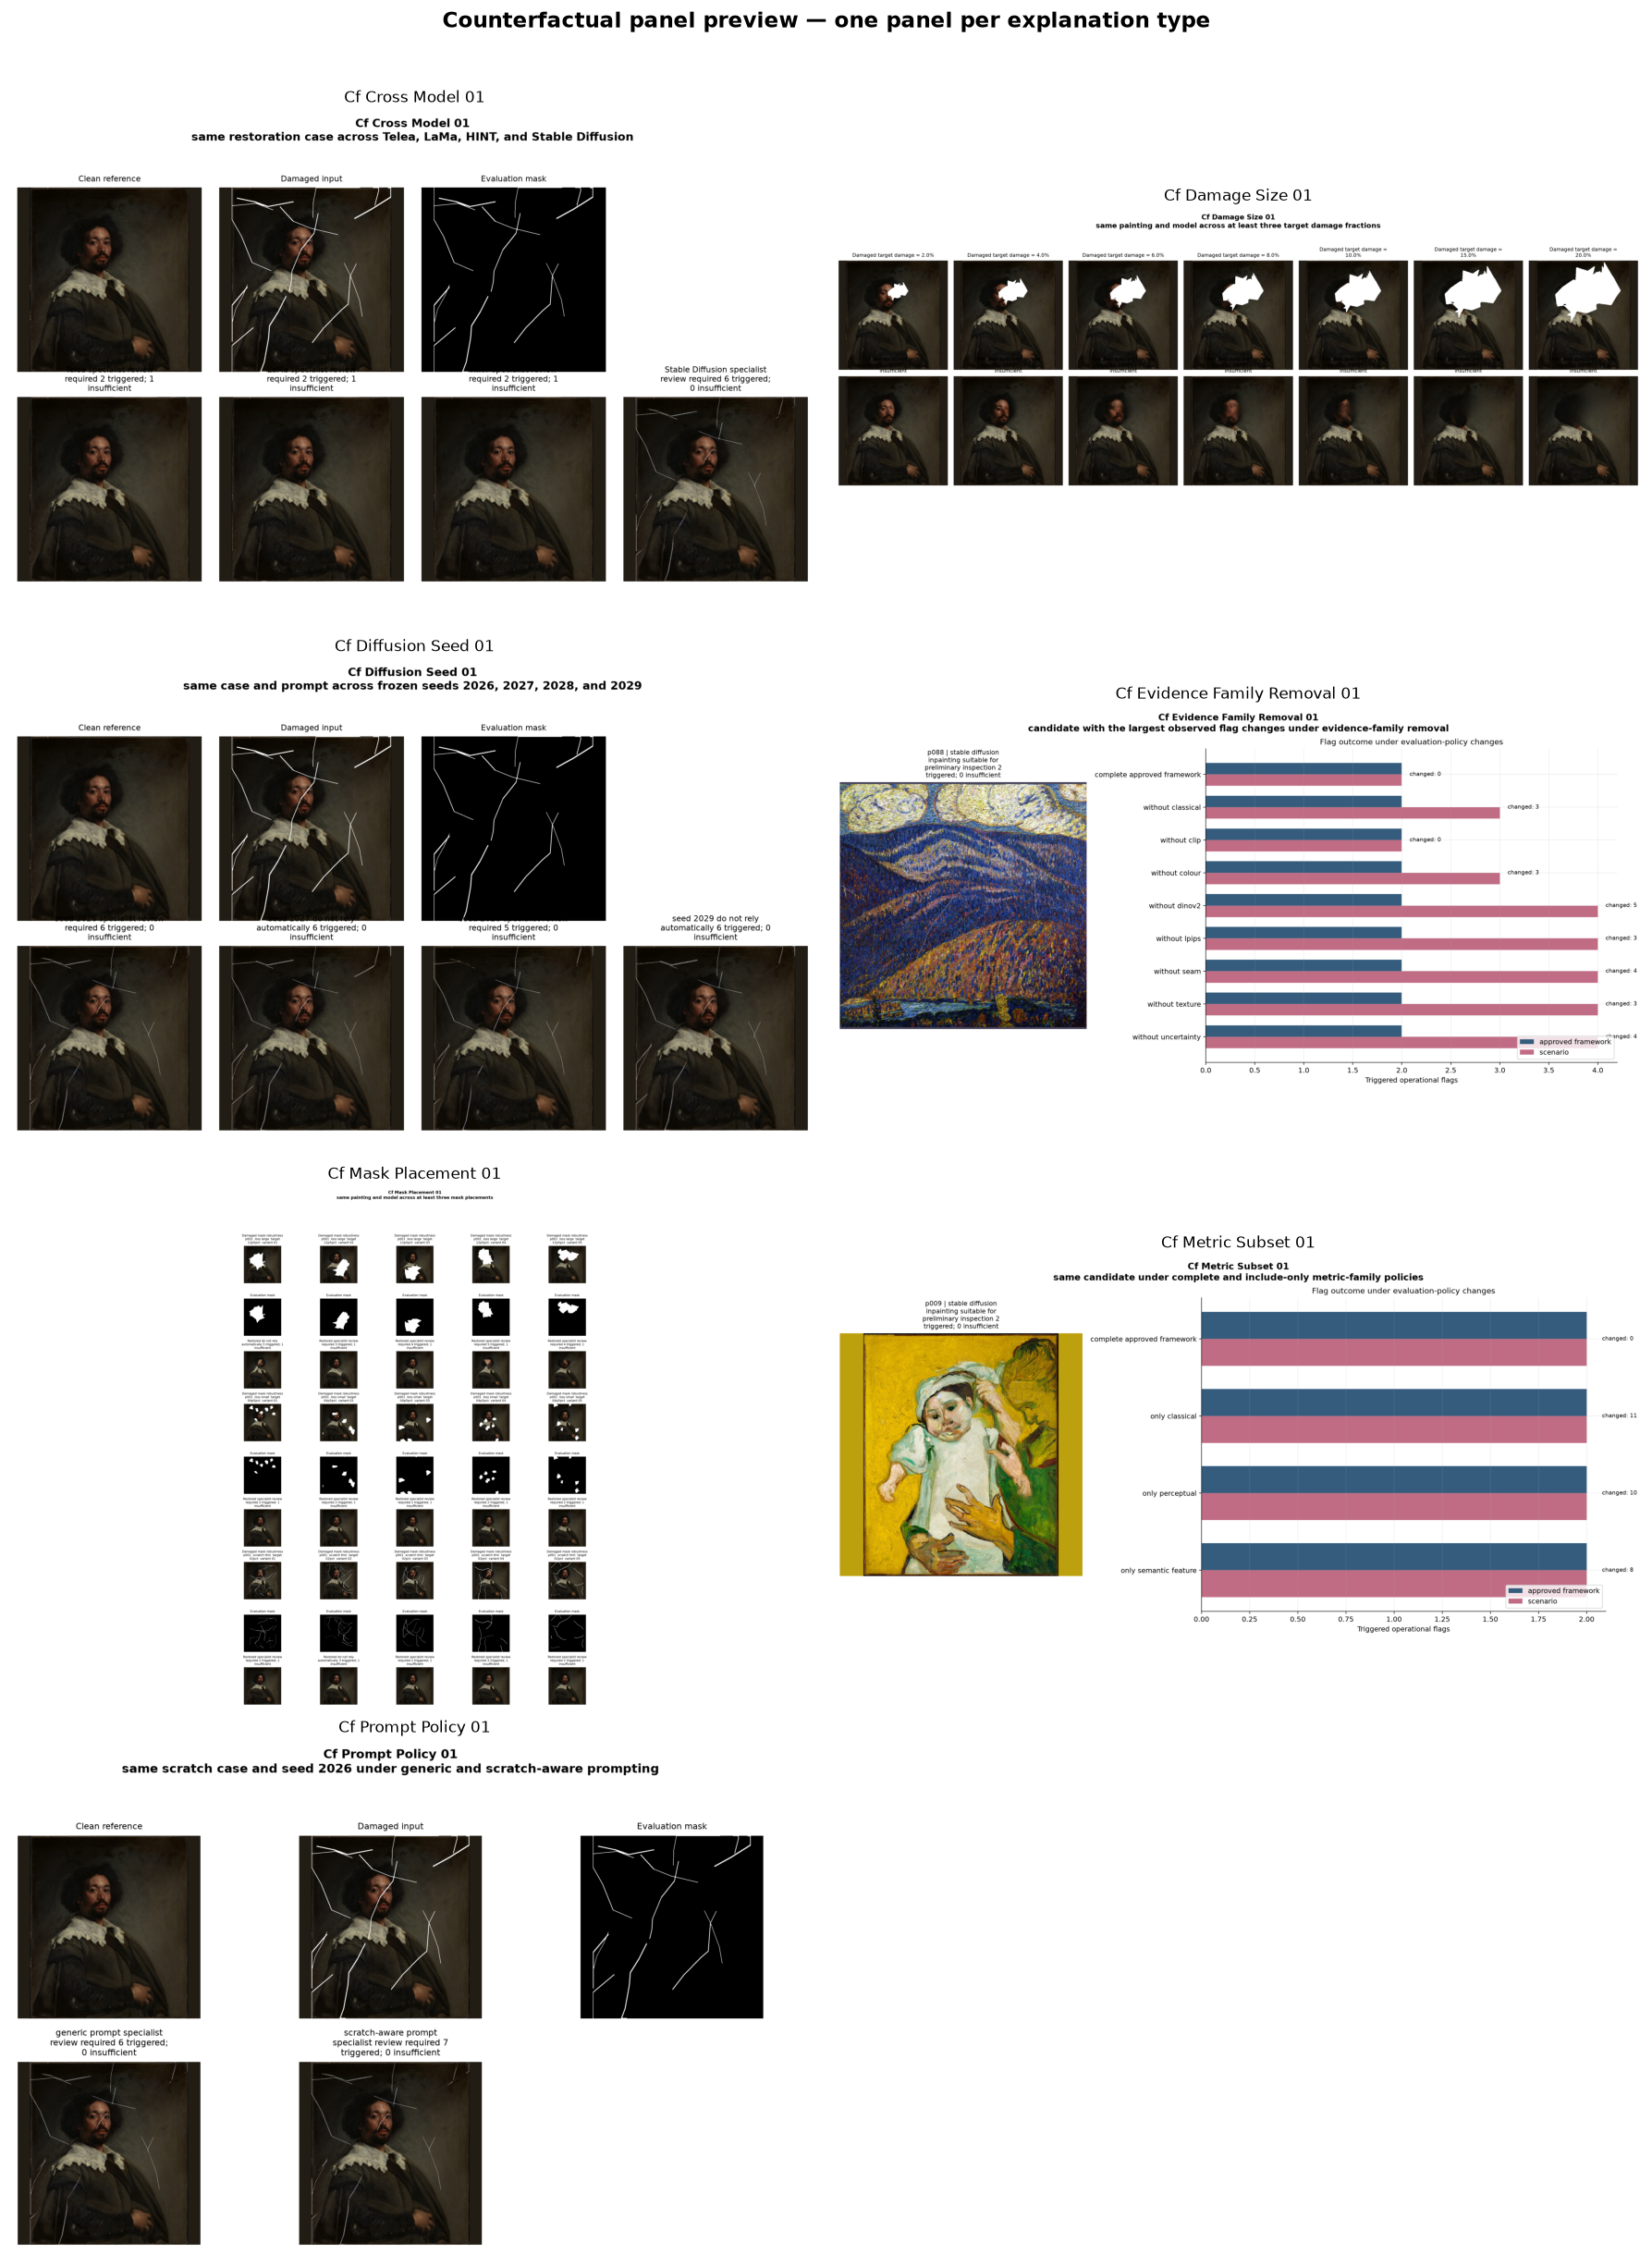

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_counterfactual_panels,counterfactual_panel_count,Exactly fourteen counterfactual PNGs exist.,blocking,14,14,True,
1,batch_7_counterfactual_panels,counterfactual_panel_filenames,Generated filenames exactly match the fourteen approved panel identifiers.,blocking,"[""cf_cross_model_01.png"", ""cf_cross_model_02.png"", ""cf_damage_size_01.png"", ""cf_damage_size_02.png"", ""cf_diffusion_seed_01.png"", ""cf_diffusion_seed_02.png"", ""cf_evidence_family...","[""cf_cross_model_01.png"", ""cf_cross_model_02.png"", ""cf_damage_size_01.png"", ""cf_damage_size_02.png"", ""cf_diffusion_seed_01.png"", ""cf_diffusion_seed_02.png"", ""cf_evidence_family...",True,
2,batch_7_counterfactual_panels,counterfactual_panel_type_coverage,Every approved counterfactual type has exactly two generated panels.,blocking,"{""cross_model"": 2, ""damage_size"": 2, ""diffusion_seed"": 2, ""evidence_family_removal"": 2, ""mask_placement"": 2, ""metric_subset"": 2, ""prompt_policy"": 2}","{""cross_model"": 2, ""damage_size"": 2, ""diffusion_seed"": 2, ""evidence_family_removal"": 2, ""mask_placement"": 2, ""metric_subset"": 2, ""prompt_policy"": 2}",True,
3,batch_7_counterfactual_panels,counterfactual_panels_readable,"Every generated panel is a readable, non-empty PNG.",blocking,"{""invalid"": 0, ""valid"": 14}","{""invalid"": 0, ""valid"": 14}",True,[]
4,batch_7_counterfactual_panels,counterfactual_selection_traceability,Every generated panel traces to its exact approved panel ID and counterfactual type.,blocking,14,14,True,
5,batch_7_counterfactual_panels,no_unexpected_counterfactual_files,The counterfactual directory contains no uncontracted files.,blocking,[],[],True,


Batch 7 counterfactual panels complete.
Validation checks: 6
Blocking failures: 0
Readable PNGs: 14
Panel types represented: 7


In [28]:
expected_panel_ids = set(
    COUNTERFACTUAL_SELECTIONS[
        "counterfactual_panel_id"
    ].astype(str)
)

expected_panel_names = {
    f"{panel_id}.png"
    for panel_id in expected_panel_ids
}

observed_panel_paths = sorted(
    COUNTERFACTUAL_DIR.glob(
        "*.png"
    )
)

observed_panel_names = {
    path.name
    for path in observed_panel_paths
}

panel_image_records = []
invalid_panel_images = []

for panel_path in observed_panel_paths:
    try:
        with Image.open(
            panel_path
        ) as image:
            image.verify()

        with Image.open(
            panel_path
        ) as image:
            width, height = image.size
            image_format = image.format

        panel_image_records.append(
            {
                "panel_name": (
                    panel_path.name
                ),
                "format": image_format,
                "width": int(width),
                "height": int(height),
                "size_bytes": int(
                    panel_path.stat().st_size
                ),
            }
        )

        if (
            image_format != "PNG"
            or width <= 0
            or height <= 0
            or panel_path.stat().st_size
            <= 0
        ):
            invalid_panel_images.append(
                panel_path.name
            )

    except Exception as error:
        invalid_panel_images.append(
            (
                f"{panel_path.name}: "
                f"{type(error).__name__}: "
                f"{error}"
            )
        )

PANEL_IMAGE_SUMMARY = (
    pd.DataFrame(
        panel_image_records
    )
    .sort_values(
        "panel_name",
        kind="mergesort",
    )
    .reset_index(drop=True)
)

panel_type_counts = (
    COUNTERFACTUAL_PANEL_INDEX[
        "counterfactual_type"
    ]
    .value_counts()
    .to_dict()
)

expected_type_counts = {
    counterfactual_type: 2
    for counterfactual_type
    in sorted(
        expected_counterfactual_types
    )
}

add_check(
    stage=BATCH_7_STAGE,
    check_id="counterfactual_panel_count",
    description=(
        "Exactly fourteen counterfactual PNGs exist."
    ),
    expected=14,
    observed=len(
        observed_panel_paths
    ),
    passed=(
        len(
            observed_panel_paths
        )
        == EXPECTED[
            "counterfactual_panels"
        ]
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="counterfactual_panel_filenames",
    description=(
        "Generated filenames exactly match the "
        "fourteen approved panel identifiers."
    ),
    expected=sorted(
        expected_panel_names
    ),
    observed=sorted(
        observed_panel_names
    ),
    passed=(
        observed_panel_names
        == expected_panel_names
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="counterfactual_panel_type_coverage",
    description=(
        "Every approved counterfactual type has "
        "exactly two generated panels."
    ),
    expected=expected_type_counts,
    observed=panel_type_counts,
    passed=(
        panel_type_counts
        == expected_type_counts
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="counterfactual_panels_readable",
    description=(
        "Every generated panel is a readable, "
        "non-empty PNG."
    ),
    expected={
        "valid": 14,
        "invalid": 0,
    },
    observed={
        "valid": len(
            panel_image_records
        )
        - len(
            invalid_panel_images
        ),
        "invalid": len(
            invalid_panel_images
        ),
    },
    passed=(
        len(
            panel_image_records
        )
        == 14
        and not invalid_panel_images
    ),
    details=invalid_panel_images,
)

index_selection_pairs = set(
    zip(
        COUNTERFACTUAL_PANEL_INDEX[
            "counterfactual_panel_id"
        ],
        COUNTERFACTUAL_PANEL_INDEX[
            "counterfactual_type"
        ],
    )
)

approved_selection_pairs = set(
    zip(
        COUNTERFACTUAL_SELECTIONS[
            "counterfactual_panel_id"
        ],
        COUNTERFACTUAL_SELECTIONS[
            "counterfactual_type"
        ],
    )
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="counterfactual_selection_traceability",
    description=(
        "Every generated panel traces to its exact "
        "approved panel ID and counterfactual type."
    ),
    expected=14,
    observed=len(
        index_selection_pairs
        & approved_selection_pairs
    ),
    passed=(
        index_selection_pairs
        == approved_selection_pairs
    ),
)

unexpected_counterfactual_files = sorted(
    path.name
    for path in (
        COUNTERFACTUAL_DIR.iterdir()
    )
    if (
        path.is_file()
        and path.name
        not in expected_panel_names
    )
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="no_unexpected_counterfactual_files",
    description=(
        "The counterfactual directory contains "
        "no uncontracted files."
    ),
    expected=[],
    observed=(
        unexpected_counterfactual_files
    ),
    passed=(
        not unexpected_counterfactual_files
    ),
)

display(
    PANEL_IMAGE_SUMMARY
)

preview_paths = (
    COUNTERFACTUAL_PANEL_INDEX.groupby(
        "counterfactual_type",
        sort=True,
    )
    .head(1)[
        "panel_path"
    ]
    .tolist()
)

preview_columns = 2
preview_rows = int(
    np.ceil(
        len(preview_paths)
        / preview_columns
    )
)

preview_figure, preview_axes = (
    plt.subplots(
        preview_rows,
        preview_columns,
        figsize=(
            15,
            preview_rows * 5.2,
        ),
        squeeze=False,
    )
)

for axis in (
    preview_axes.ravel()
):
    axis.axis("off")

for axis, relative_path in zip(
    preview_axes.ravel(),
    preview_paths,
):
    preview_image = (
        load_rgb_image(
            relative_path
        )
    )

    axis.imshow(
        preview_image
    )
    axis.set_title(
        Path(
            relative_path
        ).stem.replace(
            "_",
            " ",
        ).title(),
        fontsize=10,
    )
    axis.axis("off")

preview_figure.suptitle(
    "Counterfactual panel preview — one panel per explanation type",
    fontsize=14,
    fontweight="bold",
)

preview_figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.97,
    ]
)

plt.show()
plt.close(
    preview_figure
)

BATCH_7_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_7_ROWS = (
    BATCH_7_VALIDATION.loc[
        BATCH_7_VALIDATION[
            "validation_stage"
        ].eq(BATCH_7_STAGE)
    ]
    .reset_index(drop=True)
)

display(
    BATCH_7_ROWS
)

print("Batch 7 counterfactual panels complete.")
print(
    "Validation checks: "
    f"{len(BATCH_7_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_7_ROWS['passed']).sum()):,}"
)
print(
    "Readable PNGs: "
    f"{len(panel_image_records):,}"
)
print(
    "Panel types represented: "
    f"{len(panel_type_counts):,}"
)

VALIDATION.raise_for_blocking()

## Batch 8 — Similar-case retrieval panels and canonical persistence

This batch:

- renders one retrieval panel for each of the ten approved queries;
- shows five rule-defined lower-risk and five flagged neighbours per query;
- presents DINOv2 similarity as the primary retrieval view;
- presents CLIP similarity separately as secondary evidence;
- does not average, weight, or combine DINOv2 and CLIP scores;
- permits cross-model retrieval while preserving each method’s identity;
- persists the complete 13,879-row Controlled-300 explanation catalogue;
- persists all 100 selected neighbour relationships;
- reloads and validates both canonical CSV files;
- validates all fourteen counterfactual and ten retrieval panels.

Feature similarity supports comparison, contextual retrieval, and human inspection. It does not establish restoration correctness, historical plausibility, calibrated confidence, conservation suitability, or universal model superiority.

In [29]:
BATCH_8_PANEL_STAGE = (
    "batch_8_retrieval_panels"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_8_PANEL_STAGE,
)

RETRIEVAL_DIR = OUTPUT_PATHS[
    "retrieval_panels_dir"
]

RETRIEVAL_MODEL_LABELS = {
    "opencv_telea": "Telea",
    "lama": "LaMa",
    "hint_places2": "HINT",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
    "sdxl_inpainting": "SDXL",
}


def retrieval_model_label(
    model_id,
) -> str:
    """Return a presentation-safe restoration-method label."""
    normalized = str(model_id)

    return RETRIEVAL_MODEL_LABELS.get(
        normalized,
        normalized.replace(
            "_",
            " ",
        ),
    )


def retrieval_candidate_note(
    candidate_id: str,
) -> str:
    """Return compact retrieval-candidate metadata."""
    row = EXPLANATION_LOOKUP.loc[
        candidate_id
    ]

    return (
        f"{retrieval_model_label(row['model_id'])}\n"
        f"{str(row['recommendation_category']).replace('_', ' ')}"
    )


def draw_retrieval_panel(
    query_row: pd.Series,
    output_path: Path,
) -> dict:
    """Render one query with both five-neighbour lanes."""
    query_id = str(
        query_row["query_id"]
    )

    query_candidate_id = str(
        query_row["candidate_id"]
    )

    neighbors = (
        CASE_NEIGHBORS.loc[
            CASE_NEIGHBORS[
                "query_id"
            ].eq(query_id)
        ]
        .copy()
        .sort_values(
            [
                "lane",
                "neighbor_rank",
                "neighbor_candidate_id",
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    lane_counts = (
        neighbors[
            "lane"
        ]
        .value_counts()
        .to_dict()
    )

    if (
        len(neighbors) != 10
        or lane_counts
        != {
            "lower_risk": 5,
            "flagged": 5,
        }
    ):
        raise RuntimeError(
            f"Invalid retrieval population for {query_id}: "
            f"rows={len(neighbors)}, lanes={lane_counts}"
        )

    query_explanation = (
        EXPLANATION_LOOKUP.loc[
            query_candidate_id
        ]
    )

    figure = plt.figure(
        figsize=(18, 12.5),
        constrained_layout=True,
    )

    grid = figure.add_gridspec(
        3,
        5,
        height_ratios=[
            1.08,
            1.0,
            1.0,
        ],
    )

    query_axis = figure.add_subplot(
        grid[0, 2]
    )

    show_axis_image(
        query_axis,
        query_explanation[
            "restored_path"
        ],
        (
            f"Query: {query_row['painting_id']} | "
            f"{str(query_row['query_lane']).replace('_', ' ')}\n"
            f"{retrieval_candidate_note(query_candidate_id)}"
        ),
    )

    lane_titles = {
        "lower_risk": (
            "Rule-defined lower-risk neighbour"
        ),
        "flagged": "Flagged neighbour",
    }

    lane_rows = {
        "lower_risk": 1,
        "flagged": 2,
    }

    for lane in (
        "lower_risk",
        "flagged",
    ):
        lane_neighbors = (
            neighbors.loc[
                neighbors[
                    "lane"
                ].eq(lane)
            ]
            .sort_values(
                [
                    "neighbor_rank",
                    "neighbor_candidate_id",
                ],
                kind="mergesort",
            )
            .reset_index(drop=True)
        )

        for column, (
            _,
            neighbor_row,
        ) in enumerate(
            lane_neighbors.iterrows()
        ):
            axis = figure.add_subplot(
                grid[
                    lane_rows[lane],
                    column,
                ]
            )

            neighbor_candidate_id = str(
                neighbor_row[
                    "neighbor_candidate_id"
                ]
            )

            neighbor_explanation = (
                EXPLANATION_LOOKUP.loc[
                    neighbor_candidate_id
                ]
            )

            dino_similarity = float(
                neighbor_row[
                    "cosine_similarity"
                ]
            )

            clip_similarity = float(
                neighbor_row[
                    "secondary_cosine_similarity"
                ]
            )

            title = (
                f"{lane_titles[lane]} "
                f"#{int(neighbor_row['neighbor_rank'])}\n"
                f"{retrieval_model_label(neighbor_row['neighbor_model_id'])}\n"
                f"DINOv2 {dino_similarity:.3f} | "
                f"CLIP {clip_similarity:.3f}\n"
                f"{str(neighbor_row['neighbor_recommendation_category']).replace('_', ' ')}"
            )

            show_axis_image(
                axis,
                neighbor_explanation[
                    "restored_path"
                ],
                title,
            )

    figure.suptitle(
        (
            f"{query_id.replace('_', ' ').title()}\n"
            f"{str(query_row['category']).replace('_', ' ')} | "
            "DINOv2 primary retrieval with separate CLIP evidence"
        ),
        fontsize=14,
        fontweight="bold",
    )

    figure.savefig(
        output_path,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.close(
        figure
    )

    return {
        "query_id": query_id,
        "query_candidate_id": (
            query_candidate_id
        ),
        "query_lane": str(
            query_row[
                "query_lane"
            ]
        ),
        "category": str(
            query_row[
                "category"
            ]
        ),
        "panel_path": (
            output_path
            .relative_to(PROJECT_ROOT)
            .as_posix()
        ),
        "lower_risk_neighbors": int(
            lane_counts[
                "lower_risk"
            ]
        ),
        "flagged_neighbors": int(
            lane_counts[
                "flagged"
            ]
        ),
        "primary_feature_model_id": str(
            neighbors[
                "feature_model_id"
            ].iloc[0]
        ),
        "secondary_feature_model_id": str(
            neighbors[
                "secondary_feature_model_id"
            ].iloc[0]
        ),
    }


print("Retrieval-panel utilities ready.")

Retrieval-panel utilities ready.


In [30]:
retrieval_panel_records = []

ordered_queries = (
    RETRIEVAL_QUERY_SELECTIONS.sort_values(
        [
            "query_order",
            "query_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

for number, (
    _,
    query_row,
) in enumerate(
    ordered_queries.iterrows(),
    start=1,
):
    query_id = str(
        query_row[
            "query_id"
        ]
    )

    output_path = (
        RETRIEVAL_DIR
        / f"{query_id}.png"
    )

    retrieval_panel_records.append(
        draw_retrieval_panel(
            query_row,
            output_path,
        )
    )

    print(
        f"[{number:02d}/"
        f"{len(ordered_queries):02d}] "
        f"{query_id} rendered"
    )

RETRIEVAL_PANEL_INDEX = (
    pd.DataFrame(
        retrieval_panel_records
    )
    .sort_values(
        [
            "category",
            "query_lane",
            "query_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

display(
    RETRIEVAL_PANEL_INDEX
)

print("Retrieval-panel generation complete.")
print(
    "Panels written: "
    f"{len(RETRIEVAL_PANEL_INDEX):,}"
)

[01/10] query_01_portrait_figure_lower_risk rendered
[02/10] query_02_portrait_figure_flagged rendered
[03/10] query_03_landscape_natural_lower_risk rendered
[04/10] query_04_landscape_natural_flagged rendered
[05/10] query_05_architecture_structured_lower_risk rendered
[06/10] query_06_architecture_structured_flagged rendered
[07/10] query_07_high_texture_brushwork_lower_risk rendered
[08/10] query_08_high_texture_brushwork_flagged rendered
[09/10] query_09_abstraction_surrealism_lower_risk rendered
[10/10] query_10_abstraction_surrealism_flagged rendered


,query_id,query_candidate_id,query_lane,category,panel_path,lower_risk_neighbors,flagged_neighbors,primary_feature_model_id,secondary_feature_model_id
0,query_10_abstraction_surrealism_flagged,sd15__p00__s2026__9c54abbc36c9,flagged,abstraction_surrealism,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_10_abstraction_surrealism_flagged.png,5,5,dinov2_vits14,clip_vit_b32
1,query_09_abstraction_surrealism_lower_risk,candidate__lama__synthetic_degradation__p039__dirt_dust__moderate__c00,lower_risk,abstraction_surrealism,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_09_abstraction_surrealism_lower_risk.png,5,5,dinov2_vits14,clip_vit_b32
2,query_06_architecture_structured_flagged,candidate__lama__canonical__p021__loss_large__c00,flagged,architecture_structured,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_06_architecture_structured_flagged.png,5,5,dinov2_vits14,clip_vit_b32
3,query_05_architecture_structured_lower_risk,candidate__opencv_telea__synthetic_degradation__p026__dirt_dust__mild__c00,lower_risk,architecture_structured,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_05_architecture_structured_lower_risk.png,5,5,dinov2_vits14,clip_vit_b32
4,query_08_high_texture_brushwork_flagged,candidate__opencv_telea__canonical__p041__loss_large__c00,flagged,high_texture_brushwork,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_08_high_texture_brushwork_flagged.png,5,5,dinov2_vits14,clip_vit_b32
5,query_07_high_texture_brushwork_lower_risk,sd15__p00__s2026__63b2979234cc,lower_risk,high_texture_brushwork,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_07_high_texture_brushwork_lower_risk.png,5,5,dinov2_vits14,clip_vit_b32
6,query_04_landscape_natural_flagged,candidate__hint_places2__canonical__p011__loss_large__c00,flagged,landscape_natural,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_04_landscape_natural_flagged.png,5,5,dinov2_vits14,clip_vit_b32
7,query_03_landscape_natural_lower_risk,candidate__hint_places2__synthetic_degradation__p018__dirt_dust__mild__c00,lower_risk,landscape_natural,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_03_landscape_natural_lower_risk.png,5,5,dinov2_vits14,clip_vit_b32
8,query_02_portrait_figure_flagged,sd15__p00__s2026__29ff258ff921,flagged,portrait_figure,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_02_portrait_figure_flagged.png,5,5,dinov2_vits14,clip_vit_b32
9,query_01_portrait_figure_lower_risk,candidate__lama__synthetic_degradation__p001__dirt_dust__moderate__c00,lower_risk,portrait_figure,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels/query_01_portrait_figure_lower_risk.png,5,5,dinov2_vits14,clip_vit_b32


Retrieval-panel generation complete.
Panels written: 10


,panel_name,format,width,height,size_bytes
0,query_01_portrait_figure_lower_risk.png,PNG,3209,2270,1983301
1,query_02_portrait_figure_flagged.png,PNG,3220,2270,1686928
2,query_03_landscape_natural_lower_risk.png,PNG,3209,2270,2090595
3,query_04_landscape_natural_flagged.png,PNG,3230,2270,4435207
4,query_05_architecture_structured_lower_risk.png,PNG,3199,2270,3206071
5,query_06_architecture_structured_flagged.png,PNG,3230,2270,3162532
6,query_07_high_texture_brushwork_lower_risk.png,PNG,3209,2270,2319761
7,query_08_high_texture_brushwork_flagged.png,PNG,3230,2270,3944091
8,query_09_abstraction_surrealism_lower_risk.png,PNG,3209,2270,2674984
9,query_10_abstraction_surrealism_flagged.png,PNG,3209,2270,2318229


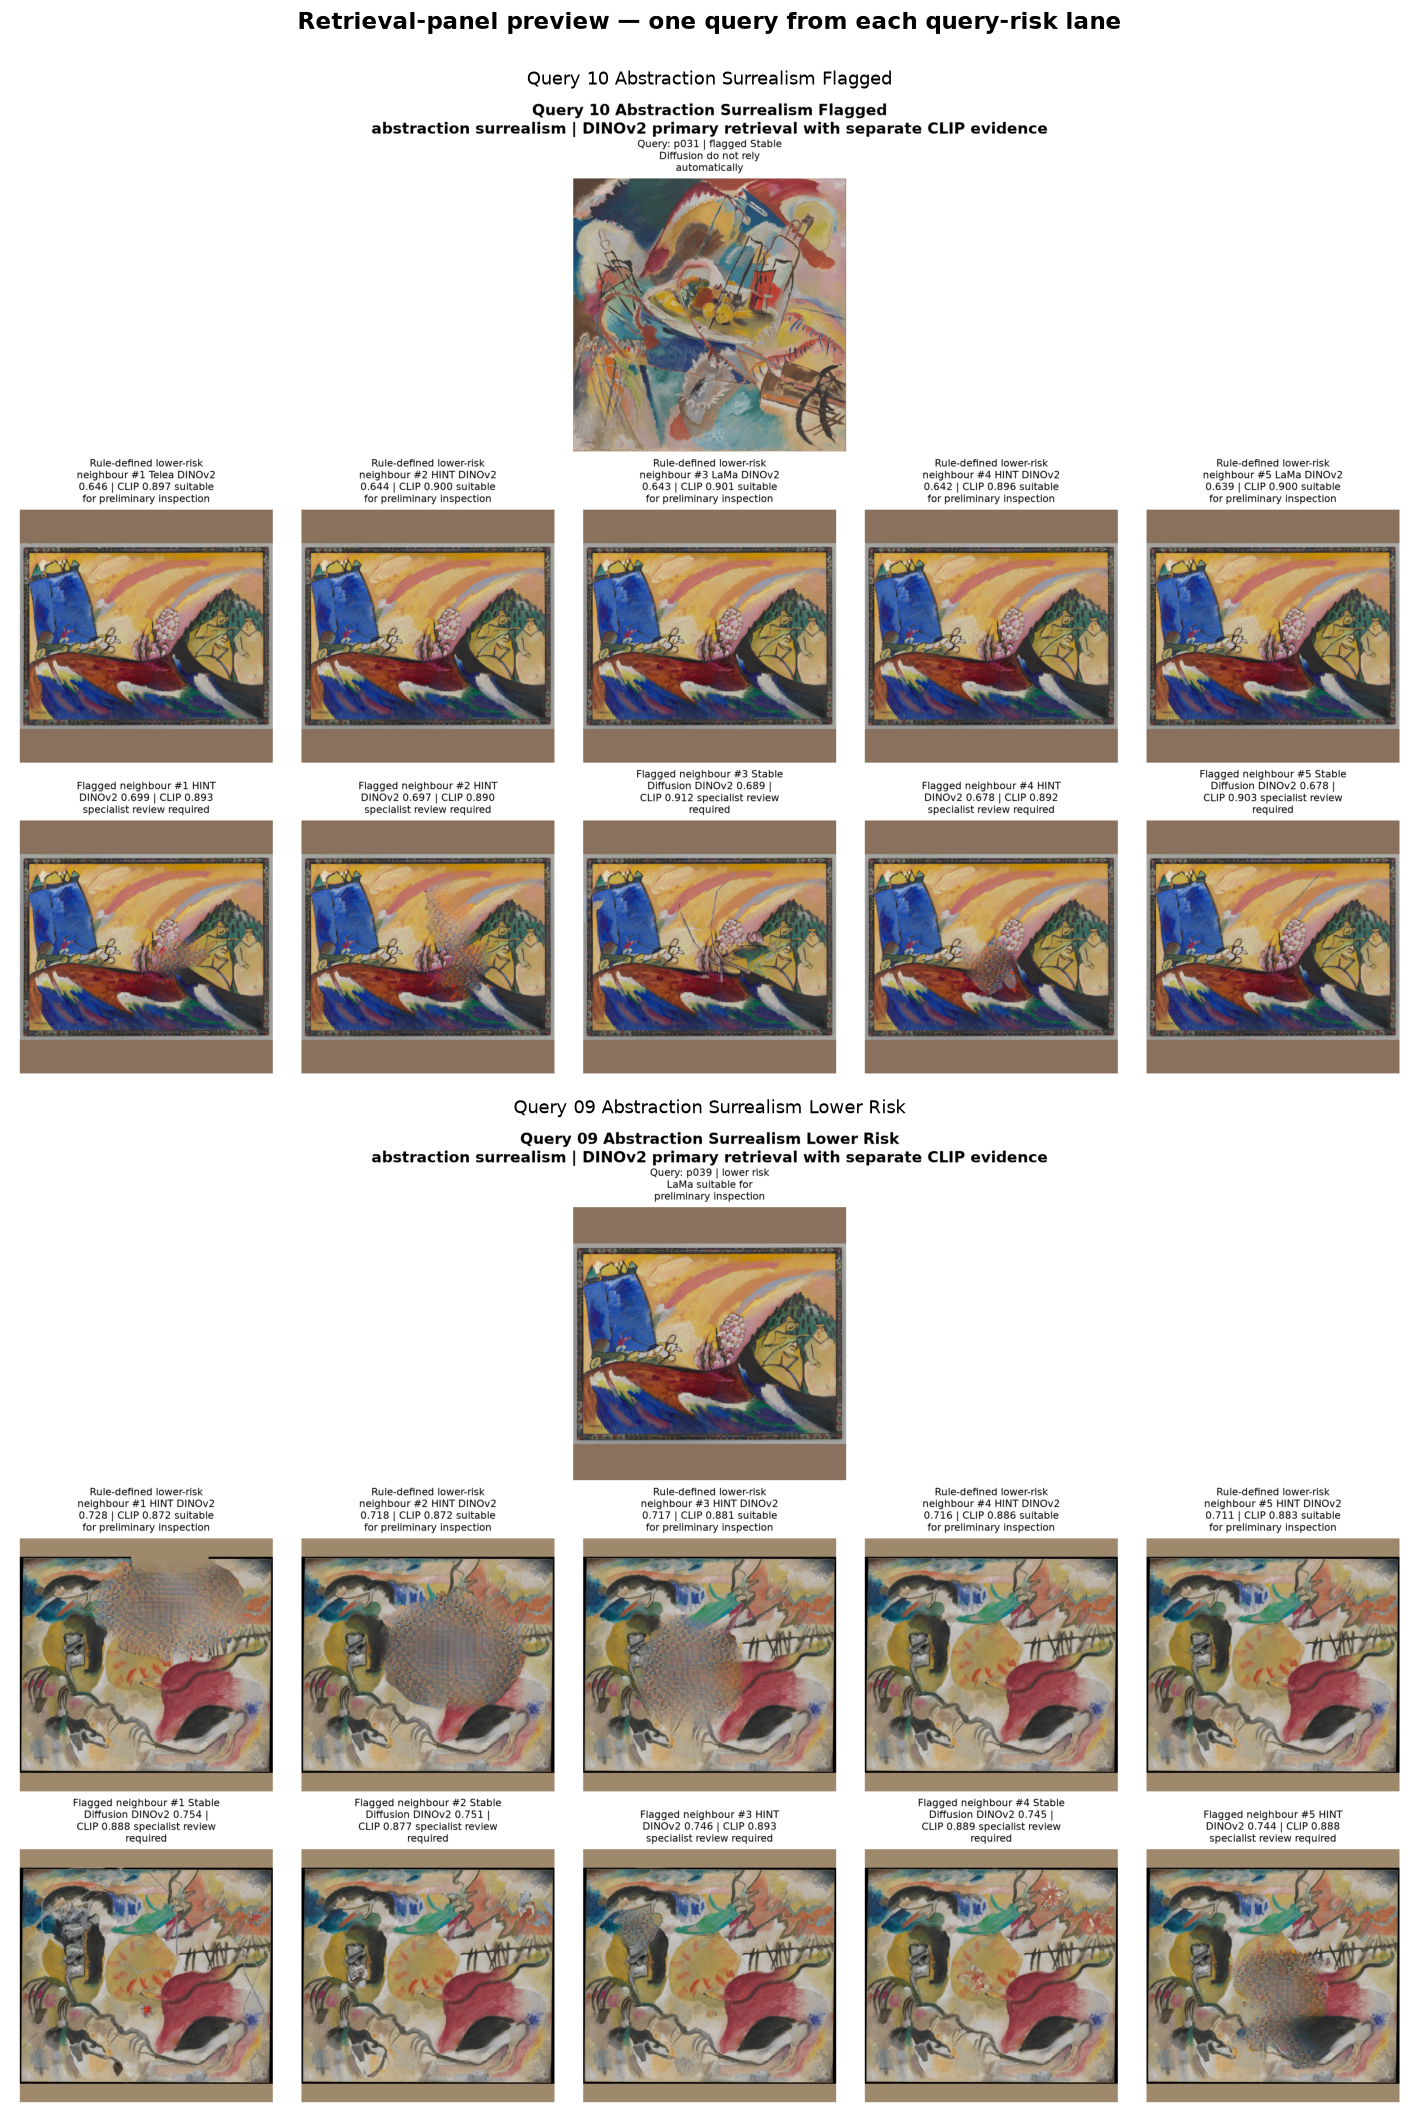

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_retrieval_panels,panel_directory__counterfactual_panel_count,Canonical panel-directory validation: counterfactual_panel_count,blocking,True,True,True,expected=14; observed=14
1,batch_8_retrieval_panels,panel_directory__retrieval_panel_count,Canonical panel-directory validation: retrieval_panel_count,blocking,True,True,True,expected=10; observed=10
2,batch_8_retrieval_panels,panel_directory__no_temporary_files,Canonical panel-directory validation: no_temporary_files,blocking,True,True,True,[]
3,batch_8_retrieval_panels,retrieval_panel_filenames,Retrieval-panel filenames exactly match the ten approved query identifiers.,blocking,"[""query_01_portrait_figure_lower_risk.png"", ""query_02_portrait_figure_flagged.png"", ""query_03_landscape_natural_lower_risk.png"", ""query_04_landscape_natural_flagged.png"", ""quer...","[""query_01_portrait_figure_lower_risk.png"", ""query_02_portrait_figure_flagged.png"", ""query_03_landscape_natural_lower_risk.png"", ""query_04_landscape_natural_flagged.png"", ""quer...",True,
4,batch_8_retrieval_panels,retrieval_panels_readable,"Every retrieval panel is a readable, non-empty PNG.",blocking,"{""invalid"": 0, ""valid"": 10}","{""invalid"": 0, ""valid"": 10}",True,[]
5,batch_8_retrieval_panels,retrieval_panel_traceability,Every generated retrieval panel traces to one approved query and its complete neighbours.,blocking,"{""flagged_per_query"": 5, ""lower_risk_per_query"": 5, ""queries"": 10}","{""flagged_maximum"": 5, ""flagged_minimum"": 5, ""lower_risk_maximum"": 5, ""lower_risk_minimum"": 5, ""queries"": 10}",True,
6,batch_8_retrieval_panels,retrieval_feature_views_separate,Every panel retains separate DINOv2 primary and CLIP secondary similarity views.,blocking,True,True,True,


Retrieval-panel validation complete.
Validation checks: 7
Blocking failures: 0
Readable retrieval PNGs: 10


In [31]:
expected_retrieval_names = {
    f"{query_id}.png"
    for query_id in (
        RETRIEVAL_QUERY_SELECTIONS[
            "query_id"
        ].astype(str)
    )
}

observed_retrieval_paths = sorted(
    RETRIEVAL_DIR.glob(
        "*.png"
    )
)

observed_retrieval_names = {
    path.name
    for path in observed_retrieval_paths
}

retrieval_image_records = []
invalid_retrieval_images = []

for panel_path in (
    observed_retrieval_paths
):
    try:
        with Image.open(
            panel_path
        ) as image:
            image.verify()

        with Image.open(
            panel_path
        ) as image:
            width, height = image.size
            image_format = image.format

        retrieval_image_records.append(
            {
                "panel_name": (
                    panel_path.name
                ),
                "format": image_format,
                "width": int(width),
                "height": int(height),
                "size_bytes": int(
                    panel_path.stat().st_size
                ),
            }
        )

        if (
            image_format != "PNG"
            or width <= 0
            or height <= 0
            or panel_path.stat().st_size
            <= 0
        ):
            invalid_retrieval_images.append(
                panel_path.name
            )

    except Exception as error:
        invalid_retrieval_images.append(
            (
                f"{panel_path.name}: "
                f"{type(error).__name__}: "
                f"{error}"
            )
        )

RETRIEVAL_IMAGE_SUMMARY = (
    pd.DataFrame(
        retrieval_image_records
    )
    .sort_values(
        "panel_name",
        kind="mergesort",
    )
    .reset_index(drop=True)
)

panel_directory_validation = (
    validate_panel_directories(
        COUNTERFACTUAL_DIR,
        RETRIEVAL_DIR,
        config=ANALYSIS_CONFIG,
    )
)

for _, check_row in (
    panel_directory_validation.iterrows()
):
    add_check(
        stage=BATCH_8_PANEL_STAGE,
        check_id=(
            "panel_directory__"
            + str(
                check_row[
                    "check_id"
                ]
            )
        ),
        description=(
            "Canonical panel-directory validation: "
            + str(
                check_row[
                    "check_id"
                ]
            )
        ),
        expected=True,
        observed=bool(
            check_row[
                "passed"
            ]
        ),
        passed=bool(
            check_row[
                "passed"
            ]
        ),
        details=str(
            check_row[
                "details"
            ]
        ),
    )

add_check(
    stage=BATCH_8_PANEL_STAGE,
    check_id="retrieval_panel_filenames",
    description=(
        "Retrieval-panel filenames exactly match "
        "the ten approved query identifiers."
    ),
    expected=sorted(
        expected_retrieval_names
    ),
    observed=sorted(
        observed_retrieval_names
    ),
    passed=(
        observed_retrieval_names
        == expected_retrieval_names
    ),
)

add_check(
    stage=BATCH_8_PANEL_STAGE,
    check_id="retrieval_panels_readable",
    description=(
        "Every retrieval panel is a readable, "
        "non-empty PNG."
    ),
    expected={
        "valid": 10,
        "invalid": 0,
    },
    observed={
        "valid": (
            len(
                retrieval_image_records
            )
            - len(
                invalid_retrieval_images
            )
        ),
        "invalid": len(
            invalid_retrieval_images
        ),
    },
    passed=(
        len(
            retrieval_image_records
        )
        == EXPECTED[
            "retrieval_panels"
        ]
        and not invalid_retrieval_images
    ),
    details=(
        invalid_retrieval_images
    ),
)

retrieval_index_queries = set(
    RETRIEVAL_PANEL_INDEX[
        "query_id"
    ]
)

approved_query_ids = set(
    RETRIEVAL_QUERY_SELECTIONS[
        "query_id"
    ]
)

add_check(
    stage=BATCH_8_PANEL_STAGE,
    check_id="retrieval_panel_traceability",
    description=(
        "Every generated retrieval panel traces to "
        "one approved query and its complete neighbours."
    ),
    expected={
        "queries": 10,
        "lower_risk_per_query": 5,
        "flagged_per_query": 5,
    },
    observed={
        "queries": len(
            retrieval_index_queries
        ),
        "lower_risk_minimum": int(
            RETRIEVAL_PANEL_INDEX[
                "lower_risk_neighbors"
            ].min()
        ),
        "lower_risk_maximum": int(
            RETRIEVAL_PANEL_INDEX[
                "lower_risk_neighbors"
            ].max()
        ),
        "flagged_minimum": int(
            RETRIEVAL_PANEL_INDEX[
                "flagged_neighbors"
            ].min()
        ),
        "flagged_maximum": int(
            RETRIEVAL_PANEL_INDEX[
                "flagged_neighbors"
            ].max()
        ),
    },
    passed=(
        retrieval_index_queries
        == approved_query_ids
        and RETRIEVAL_PANEL_INDEX[
            "lower_risk_neighbors"
        ].eq(5).all()
        and RETRIEVAL_PANEL_INDEX[
            "flagged_neighbors"
        ].eq(5).all()
    ),
)

separate_feature_views = (
    RETRIEVAL_PANEL_INDEX[
        "primary_feature_model_id"
    ].ne(
        RETRIEVAL_PANEL_INDEX[
            "secondary_feature_model_id"
        ]
    ).all()
)

add_check(
    stage=BATCH_8_PANEL_STAGE,
    check_id="retrieval_feature_views_separate",
    description=(
        "Every panel retains separate DINOv2 primary "
        "and CLIP secondary similarity views."
    ),
    expected=True,
    observed=bool(
        separate_feature_views
    ),
    passed=bool(
        separate_feature_views
    ),
)

display(
    RETRIEVAL_IMAGE_SUMMARY
)

preview_retrieval_paths = (
    RETRIEVAL_PANEL_INDEX.sort_values(
        [
            "query_lane",
            "category",
            "query_id",
        ],
        kind="mergesort",
    )
    .groupby(
        "query_lane",
        sort=True,
    )
    .head(1)[
        "panel_path"
    ]
    .tolist()
)

preview_figure, preview_axes = (
    plt.subplots(
        len(
            preview_retrieval_paths
        ),
        1,
        figsize=(
            18,
            9
            * len(
                preview_retrieval_paths
            ),
        ),
        squeeze=False,
    )
)

for axis, relative_path in zip(
    preview_axes.ravel(),
    preview_retrieval_paths,
):
    axis.imshow(
        load_rgb_image(
            relative_path
        )
    )
    axis.set_title(
        Path(
            relative_path
        ).stem.replace(
            "_",
            " ",
        ).title(),
        fontsize=11,
    )
    axis.axis("off")

preview_figure.suptitle(
    "Retrieval-panel preview — one query from each query-risk lane",
    fontsize=14,
    fontweight="bold",
)

preview_figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.98,
    ]
)

plt.show()
plt.close(
    preview_figure
)

BATCH_8_PANEL_ROWS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            BATCH_8_PANEL_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(
    BATCH_8_PANEL_ROWS
)

print("Retrieval-panel validation complete.")
print(
    "Validation checks: "
    f"{len(BATCH_8_PANEL_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_8_PANEL_ROWS['passed']).sum()):,}"
)
print(
    "Readable retrieval PNGs: "
    f"{len(retrieval_image_records):,}"
)

VALIDATION.raise_for_blocking()

In [32]:
BATCH_8_PERSIST_STAGE = (
    "batch_8_canonical_persistence"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_8_PERSIST_STAGE,
)

atomic_write_csv(
    EXPLANATION_CASES,
    OUTPUT_PATHS[
        "explanation_cases"
    ],
)

atomic_write_csv(
    CASE_NEIGHBORS,
    OUTPUT_PATHS[
        "case_neighbors"
    ],
)

EXPLANATION_CASES_RELOADED = (
    pd.read_csv(
        OUTPUT_PATHS[
            "explanation_cases"
        ],
        keep_default_na=False,
        low_memory=False,
    )
)

CASE_NEIGHBORS_RELOADED = (
    pd.read_csv(
        OUTPUT_PATHS[
            "case_neighbors"
        ],
        keep_default_na=False,
        low_memory=False,
    )
)

RELOADED_EXPLANATION_VALIDATION = (
    validate_explanation_cases(
        EXPLANATION_CASES_RELOADED,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

RELOADED_NEIGHBOR_VALIDATION = (
    validate_case_neighbors(
        CASE_NEIGHBORS_RELOADED,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

for validator_name, validation_frame in (
    (
        "explanation_cases",
        RELOADED_EXPLANATION_VALIDATION,
    ),
    (
        "case_neighbors",
        RELOADED_NEIGHBOR_VALIDATION,
    ),
):
    for _, check_row in (
        validation_frame.iterrows()
    ):
        add_check(
            stage=BATCH_8_PERSIST_STAGE,
            check_id=(
                f"{validator_name}__"
                + str(
                    check_row[
                        "check_id"
                    ]
                )
            ),
            description=(
                f"Reloaded {validator_name} validation: "
                + str(
                    check_row[
                        "check_id"
                    ]
                )
            ),
            expected=True,
            observed=bool(
                check_row[
                    "passed"
                ]
            ),
            passed=bool(
                check_row[
                    "passed"
                ]
            ),
            details=str(
                check_row[
                    "details"
                ]
            ),
        )

explanation_identity_preserved = (
    EXPLANATION_CASES_RELOADED[
        "candidate_id"
    ].tolist()
    == EXPLANATION_CASES[
        "candidate_id"
    ].astype(str).tolist()
)

neighbor_identity_preserved = (
    CASE_NEIGHBORS_RELOADED[
        "neighbor_record_id"
    ].tolist()
    == CASE_NEIGHBORS[
        "neighbor_record_id"
    ].astype(str).tolist()
)

add_check(
    stage=BATCH_8_PERSIST_STAGE,
    check_id="canonical_identity_preserved",
    description=(
        "CSV persistence preserves exact ordered "
        "candidate and neighbour-record identities."
    ),
    expected={
        "explanation_candidates": True,
        "neighbor_records": True,
    },
    observed={
        "explanation_candidates": bool(
            explanation_identity_preserved
        ),
        "neighbor_records": bool(
            neighbor_identity_preserved
        ),
    },
    passed=(
        explanation_identity_preserved
        and neighbor_identity_preserved
    ),
)

canonical_csv_summary = pd.DataFrame(
    [
        {
            "artifact": (
                "explanation_cases"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "explanation_cases"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "rows": len(
                EXPLANATION_CASES_RELOADED
            ),
            "columns": len(
                EXPLANATION_CASES_RELOADED.columns
            ),
            "size_bytes": (
                OUTPUT_PATHS[
                    "explanation_cases"
                ].stat().st_size
            ),
            "sha256": sha256_file(
                OUTPUT_PATHS[
                    "explanation_cases"
                ]
            ),
        },
        {
            "artifact": (
                "case_neighbors"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "case_neighbors"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "rows": len(
                CASE_NEIGHBORS_RELOADED
            ),
            "columns": len(
                CASE_NEIGHBORS_RELOADED.columns
            ),
            "size_bytes": (
                OUTPUT_PATHS[
                    "case_neighbors"
                ].stat().st_size
            ),
            "sha256": sha256_file(
                OUTPUT_PATHS[
                    "case_neighbors"
                ]
            ),
        },
    ]
)

temporary_output_files = sorted(
    path.relative_to(
        OUTPUT_ROOT
    ).as_posix()
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and (
            path.suffix.lower()
            in {
                ".tmp",
                ".temp",
            }
            or path.name.startswith(".")
        )
    )
)

current_physical_files = sorted(
    path
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
)

add_check(
    stage=BATCH_8_PERSIST_STAGE,
    check_id="no_temporary_output_files",
    description=(
        "Atomic persistence leaves no temporary files."
    ),
    expected=[],
    observed=temporary_output_files,
    passed=(
        not temporary_output_files
    ),
)

add_check(
    stage=BATCH_8_PERSIST_STAGE,
    check_id="batch_8_physical_file_count",
    description=(
        "After canonical persistence the output root "
        "contains fourteen counterfactual panels, ten "
        "retrieval panels, and two canonical CSVs."
    ),
    expected=26,
    observed=len(
        current_physical_files
    ),
    passed=(
        len(
            current_physical_files
        )
        == 26
    ),
)

display(
    canonical_csv_summary
)

display(
    RELOADED_EXPLANATION_VALIDATION
)

display(
    RELOADED_NEIGHBOR_VALIDATION
)

BATCH_8_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_8_ROWS = (
    BATCH_8_VALIDATION.loc[
        BATCH_8_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_8_PANEL_STAGE,
                BATCH_8_PERSIST_STAGE,
            }
        )
    ]
    .reset_index(drop=True)
)

display(
    BATCH_8_ROWS
)

print("Batch 8 retrieval and persistence complete.")
print(
    "Validation checks: "
    f"{len(BATCH_8_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_8_ROWS['passed']).sum()):,}"
)
print(
    "Explanation rows reloaded: "
    f"{len(EXPLANATION_CASES_RELOADED):,}"
)
print(
    "Neighbour rows reloaded: "
    f"{len(CASE_NEIGHBORS_RELOADED):,}"
)
print(
    "Counterfactual panels: "
    f"{len(observed_panel_paths):,}"
)
print(
    "Retrieval panels: "
    f"{len(observed_retrieval_paths):,}"
)
print(
    "Physical files after Batch 8: "
    f"{len(current_physical_files):,}"
)

VALIDATION.raise_for_blocking()

,artifact,relative_path,rows,columns,size_bytes,sha256
0,explanation_cases,outputs/29_explainable_ai_and_case_retrieval/data/explanation_cases.csv,13879,48,46809964,4118b8c573dcb7013751de2e3b1279d8824176eb05ad7656c4007ab24ae37f8b
1,case_neighbors,outputs/29_explainable_ai_and_case_retrieval/data/case_neighbors.csv,100,35,78782,6cc63587363dfadd249c32d01dcae76e8ee82d707126a2dbe263c1771ec695fb


,check_id,passed,details
0,exact_columns,True,columns=48
1,schema_version,True,explanation_cases.v1
2,candidate_unique,True,rows=13879
3,explanation_id_unique,True,rows=13879
4,required_ids_nonempty,True,candidate/case/painting/model
5,report_roles_are_subset,True,selected_rows=73
6,json_fields_parse,True,all JSON-list fields
7,full_catalog_rows,True,expected=13879; observed=13879
8,unique_cases,True,expected=2620; observed=2620
9,not_report_only,True,catalog=13879; report_units=24


,check_id,passed,details
0,exact_columns,True,columns=35
1,schema_version,True,case_neighbors.v1
2,record_id_unique,True,rows=100
3,no_self,True,candidate IDs differ
4,no_same_case,True,same case excluded
5,no_same_painting,True,same painting excluded
6,finite_similarity,True,rows=100
7,finite_secondary_similarity,True,rows=100
8,separate_feature_views,True,primary and secondary IDs differ
9,valid_lanes,True,"['flagged', 'lower_risk']"


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_retrieval_panels,panel_directory__counterfactual_panel_count,Canonical panel-directory validation: counterfactual_panel_count,blocking,True,True,True,expected=14; observed=14
1,batch_8_retrieval_panels,panel_directory__retrieval_panel_count,Canonical panel-directory validation: retrieval_panel_count,blocking,True,True,True,expected=10; observed=10
2,batch_8_retrieval_panels,panel_directory__no_temporary_files,Canonical panel-directory validation: no_temporary_files,blocking,True,True,True,[]
3,batch_8_retrieval_panels,retrieval_panel_filenames,Retrieval-panel filenames exactly match the ten approved query identifiers.,blocking,"[""query_01_portrait_figure_lower_risk.png"", ""query_02_portrait_figure_flagged.png"", ""query_03_landscape_natural_lower_risk.png"", ""query_04_landscape_natural_flagged.png"", ""quer...","[""query_01_portrait_figure_lower_risk.png"", ""query_02_portrait_figure_flagged.png"", ""query_03_landscape_natural_lower_risk.png"", ""query_04_landscape_natural_flagged.png"", ""quer...",True,
4,batch_8_retrieval_panels,retrieval_panels_readable,"Every retrieval panel is a readable, non-empty PNG.",blocking,"{""invalid"": 0, ""valid"": 10}","{""invalid"": 0, ""valid"": 10}",True,[]
5,batch_8_retrieval_panels,retrieval_panel_traceability,Every generated retrieval panel traces to one approved query and its complete neighbours.,blocking,"{""flagged_per_query"": 5, ""lower_risk_per_query"": 5, ""queries"": 10}","{""flagged_maximum"": 5, ""flagged_minimum"": 5, ""lower_risk_maximum"": 5, ""lower_risk_minimum"": 5, ""queries"": 10}",True,
6,batch_8_retrieval_panels,retrieval_feature_views_separate,Every panel retains separate DINOv2 primary and CLIP secondary similarity views.,blocking,True,True,True,
7,batch_8_canonical_persistence,explanation_cases__exact_columns,Reloaded explanation_cases validation: exact_columns,blocking,True,True,True,columns=48
8,batch_8_canonical_persistence,explanation_cases__schema_version,Reloaded explanation_cases validation: schema_version,blocking,True,True,True,explanation_cases.v1
9,batch_8_canonical_persistence,explanation_cases__candidate_unique,Reloaded explanation_cases validation: candidate_unique,blocking,True,True,True,rows=13879


Batch 8 retrieval and persistence complete.
Validation checks: 33
Blocking failures: 0
Explanation rows reloaded: 13,879
Neighbour rows reloaded: 100
Counterfactual panels: 14
Retrieval panels: 10
Physical files after Batch 8: 26


## Batch 9 — Mock-bound self-contained explanation report

This batch builds the approved fourteen-section report without changing its mock structure.

The final report:

- describes the complete 13,879-candidate Controlled-300 catalogue across 2,620 cases and 300 paintings;
- covers Telea, LaMa, HINT, Stable Diffusion, and the bounded SDXL branch;
- embeds all fourteen counterfactual panels;
- embeds all ten retrieval panels;
- embeds at least five analytical views;
- includes selected spatial evidence from upstream outputs;
- contains no external image dependencies;
- uses concise facts followed by direct interpretation;
- connects results to RQ1, RQ2, and the RQ3 scope extension;
- distinguishes operational screening evidence from correctness, authenticity, calibrated confidence, or conservation approval.

The report is an upgraded implementation of the approved mock, not a replacement structure.

In [33]:
import base64
import html as html_lib
import io
import re


BATCH_9_STAGE = (
    "batch_9_self_contained_report"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_9_STAGE,
)


def figure_data_uri(
    figure,
    *,
    dpi: int = 145,
) -> str:
    """Encode a Matplotlib figure without creating a file."""
    buffer = io.BytesIO()

    figure.savefig(
        buffer,
        format="png",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.close(
        figure
    )

    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("ascii")

    return (
        "data:image/png;base64,"
        + encoded
    )


def report_image_data_uri(
    path: Path,
    *,
    maximum_dimension: int = 1800,
    quality: int = 82,
) -> str:
    """Create a compact embedded JPEG representation."""
    with Image.open(
        path
    ) as source:
        image = (
            ImageOps.exif_transpose(
                source
            )
            .convert("RGB")
        )

        image.thumbnail(
            (
                maximum_dimension,
                maximum_dimension,
            ),
            Image.Resampling.LANCZOS,
        )

        buffer = io.BytesIO()

        image.save(
            buffer,
            format="JPEG",
            quality=quality,
            optimize=True,
            progressive=True,
        )

    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("ascii")

    return (
        "data:image/jpeg;base64,"
        + encoded
    )


def display_model_name(
    value: str,
) -> str:
    """Return concise model names for tables and prose."""
    names = {
        "opencv_telea": "OpenCV Telea",
        "lama": "LaMa",
        "hint_places2": "HINT",
        "stable_diffusion_inpainting": (
            "Stable Diffusion"
        ),
        "sdxl_inpainting": "SDXL",
    }

    return names.get(
        str(value),
        str(value).replace(
            "_",
            " ",
        ).title(),
    )


def report_table(
    frame: pd.DataFrame,
) -> str:
    """Convert a compact table to styled HTML."""
    return frame.to_html(
        index=False,
        border=0,
        classes=[
            "data-table",
        ],
        escape=True,
    )


REPORT_CASES = (
    EXPLANATION_CASES_RELOADED.copy()
)

REPORT_NEIGHBORS = (
    CASE_NEIGHBORS_RELOADED.copy()
)

REPORT_CASES[
    "manual_review_bool"
] = REPORT_CASES[
    "manual_review_required"
].map(bool_value)

lower_risk_mask = (
    REPORT_CASES[
        "retrieval_lane"
    ].eq("lower_risk")
)

LOWER_RISK_COUNT = int(
    lower_risk_mask.sum()
)

FLAGGED_COUNT = int(
    (
        ~lower_risk_mask
    ).sum()
)

MANUAL_REVIEW_COUNT = int(
    REPORT_CASES[
        "manual_review_bool"
    ].sum()
)

RETRIEVAL_ELIGIBLE_COUNT = int(
    (
        REPORT_CASES[
            "retrieval_dino_eligible"
        ].map(bool_value)
        & REPORT_CASES[
            "retrieval_clip_eligible"
        ].map(bool_value)
    ).sum()
)

UNCERTAINTY_MEMBER_COUNT = int(
    REPORT_CASES[
        "uncertainty_group_id"
    ]
    .fillna("")
    .astype(str)
    .str.len()
    .gt(0)
    .sum()
)

STYLE_PERIOD_COUNT = int(
    REPORT_CASES.loc[
        REPORT_CASES[
            "style_or_period"
        ]
        .fillna("")
        .astype(str)
        .str.len()
        .gt(0),
        "painting_id",
    ].nunique()
)

MODEL_REPORT_SUMMARY = (
    REPORT_CASES.groupby(
        "model_id",
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        lower_risk=(
            "retrieval_lane",
            lambda values: int(
                values.eq(
                    "lower_risk"
                ).sum()
            ),
        ),
        manual_review=(
            "manual_review_bool",
            "sum",
        ),
    )
    .reset_index()
)

MODEL_REPORT_SUMMARY[
    "lower_risk_fraction"
] = (
    MODEL_REPORT_SUMMARY[
        "lower_risk"
    ]
    / MODEL_REPORT_SUMMARY[
        "candidates"
    ]
)

MODEL_REPORT_SUMMARY[
    "model"
] = MODEL_REPORT_SUMMARY[
    "model_id"
].map(
    display_model_name
)

MODEL_REPORT_TABLE = (
    MODEL_REPORT_SUMMARY[
        [
            "model",
            "candidates",
            "cases",
            "lower_risk",
            "manual_review",
            "lower_risk_fraction",
        ]
    ]
    .copy()
)

MODEL_REPORT_TABLE[
    "lower_risk_fraction"
] = MODEL_REPORT_TABLE[
    "lower_risk_fraction"
].map(
    lambda value: (
        f"{float(value):.1%}"
    )
)

highest_lower_risk_row = (
    MODEL_REPORT_SUMMARY.sort_values(
        [
            "lower_risk_fraction",
            "lower_risk",
            "model",
        ],
        ascending=[
            False,
            False,
            True,
        ],
        kind="mergesort",
    )
    .iloc[0]
)

HIGHEST_LOWER_RISK_MODEL = str(
    highest_lower_risk_row[
        "model"
    ]
)

HIGHEST_LOWER_RISK_SHARE = float(
    highest_lower_risk_row[
        "lower_risk_fraction"
    ]
)

CATEGORY_REPORT_TABLE = (
    REPORT_CASES.groupby(
        "category",
        dropna=False,
    )
    .agg(
        paintings=(
            "painting_id",
            "nunique",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        lower_risk=(
            "retrieval_lane",
            lambda values: int(
                values.eq(
                    "lower_risk"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

CATEGORY_REPORT_TABLE[
    "category"
] = CATEGORY_REPORT_TABLE[
    "category"
].astype(str).str.replace(
    "_",
    " ",
)

RETRIEVAL_LANE_SUMMARY = (
    REPORT_NEIGHBORS.groupby(
        "lane",
        dropna=False,
    )
    .agg(
        neighbors=(
            "neighbor_record_id",
            "count",
        ),
        dinov2_similarity_mean=(
            "cosine_similarity",
            "mean",
        ),
        clip_similarity_mean=(
            "secondary_cosine_similarity",
            "mean",
        ),
        same_category_fraction=(
            "same_category",
            lambda values: float(
                values.map(
                    bool_value
                ).mean()
            ),
        ),
        same_damage_family_fraction=(
            "same_degradation_family",
            lambda values: float(
                values.map(
                    bool_value
                ).mean()
            ),
        ),
        cross_model_fraction=(
            "same_model",
            lambda values: float(
                (
                    ~values.map(
                        bool_value
                    )
                ).mean()
            ),
        ),
    )
    .reset_index()
)

RETRIEVAL_LANE_TABLE = (
    RETRIEVAL_LANE_SUMMARY.copy()
)

RETRIEVAL_LANE_TABLE[
    "lane"
] = RETRIEVAL_LANE_TABLE[
    "lane"
].str.replace(
    "_",
    " ",
)

for column in (
    "dinov2_similarity_mean",
    "clip_similarity_mean",
    "same_category_fraction",
    "same_damage_family_fraction",
    "cross_model_fraction",
):
    RETRIEVAL_LANE_TABLE[
        column
    ] = RETRIEVAL_LANE_TABLE[
        column
    ].map(
        lambda value: (
            f"{float(value):.3f}"
        )
    )

retrieval_lane_index = (
    RETRIEVAL_LANE_SUMMARY.set_index(
        "lane"
    )
)

LOWER_DINO_MEAN = float(
    retrieval_lane_index.loc[
        "lower_risk",
        "dinov2_similarity_mean",
    ]
)

FLAGGED_DINO_MEAN = float(
    retrieval_lane_index.loc[
        "flagged",
        "dinov2_similarity_mean",
    ]
)

LOWER_CLIP_MEAN = float(
    retrieval_lane_index.loc[
        "lower_risk",
        "clip_similarity_mean",
    ]
)

FLAGGED_CLIP_MEAN = float(
    retrieval_lane_index.loc[
        "flagged",
        "clip_similarity_mean",
    ]
)

flag_tokens = []

for value in (
    REPORT_CASES[
        "triggered_flag_ids_json"
    ]
):
    flag_tokens.extend(
        parse_json_list(value)
    )

FLAG_PREVALENCE_TABLE = (
    pd.Series(
        flag_tokens,
        dtype="object",
    )
    .value_counts()
    .rename_axis("flag")
    .reset_index(name="candidate_count")
    .head(10)
)

FLAG_PREVALENCE_TABLE[
    "flag"
] = FLAG_PREVALENCE_TABLE[
    "flag"
].str.replace(
    "_",
    " ",
)

FLAG_PREVALENCE_TABLE[
    "candidate_fraction"
] = (
    FLAG_PREVALENCE_TABLE[
        "candidate_count"
    ]
    / len(
        REPORT_CASES
    )
).map(
    lambda value: (
        f"{float(value):.1%}"
    )
)

SCENARIO_IMPACT = (
    FLAG_STABILITY.loc[
        FLAG_STABILITY[
            "status"
        ].eq("ok")
        & ~FLAG_STABILITY[
            "scenario_id"
        ].eq(
            "complete_approved_framework"
        )
    ]
    .assign(
        changed_flag_count_numeric=(
            lambda frame: pd.to_numeric(
                frame[
                    "changed_flag_count"
                ],
                errors="coerce",
            ).fillna(0)
        )
    )
    .groupby(
        [
            "scenario_id",
            "scenario_family",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        mean_changed_flags=(
            "changed_flag_count_numeric",
            "mean",
        ),
        maximum_changed_flags=(
            "changed_flag_count_numeric",
            "max",
        ),
        changed_candidate_fraction=(
            "changed_flag_count_numeric",
            lambda values: float(
                values.gt(0).mean()
            ),
        ),
    )
    .reset_index()
    .sort_values(
        [
            "mean_changed_flags",
            "changed_candidate_fraction",
            "scenario_id",
        ],
        ascending=[
            False,
            False,
            True,
        ],
        kind="mergesort",
    )
)

TOP_SCENARIO_ROW = (
    SCENARIO_IMPACT.iloc[0]
)

TOP_SCENARIO_NAME = str(
    TOP_SCENARIO_ROW[
        "scenario_id"
    ]
).replace(
    "_",
    " ",
)

TOP_SCENARIO_MEAN_CHANGE = float(
    TOP_SCENARIO_ROW[
        "mean_changed_flags"
    ]
)

# ----------------------------------------------------------
# Analytical view 1: catalog population roles
# ----------------------------------------------------------

population_role_counts = (
    REPORT_CASES[
        "population_role"
    ]
    .value_counts()
    .sort_values()
)

figure, axis = plt.subplots(
    figsize=(9.5, 5.2)
)

axis.barh(
    [
        value.replace(
            "_",
            " ",
        )
        for value in (
            population_role_counts.index
        )
    ],
    population_role_counts.values,
    color="#355C7D",
)

axis.set_xlabel(
    "Candidates"
)
axis.set_title(
    "Complete catalog by evidence-population role"
)

for position, value in enumerate(
    population_role_counts.values
):
    axis.text(
        value + 8,
        position,
        f"{int(value):,}",
        va="center",
    )

ANALYTICAL_VIEW_URIS = {
    "catalog_population_roles": (
        figure_data_uri(
            figure
        )
    )
}

# ----------------------------------------------------------
# Analytical view 2: recommendation distribution by model
# ----------------------------------------------------------

recommendation_cross_tab = (
    pd.crosstab(
        REPORT_CASES[
            "model_id"
        ].map(
            display_model_name
        ),
        REPORT_CASES[
            "recommendation_category"
        ].astype(str).str.replace(
            "_",
            " ",
        ),
        normalize="index",
    )
)

preferred_recommendation_columns = [
    "suitable for preliminary inspection",
    "specialist review required",
    "do not rely automatically",
]

recommendation_cross_tab = (
    recommendation_cross_tab.reindex(
        columns=(
            preferred_recommendation_columns
        ),
        fill_value=0,
    )
)

figure, axis = plt.subplots(
    figsize=(10.5, 5.8)
)

recommendation_cross_tab.plot(
    kind="bar",
    stacked=True,
    ax=axis,
    color=[
        "#4C956C",
        "#E9C46A",
        "#C65B7C",
    ],
)

axis.set_ylabel(
    "Fraction of model candidates"
)
axis.set_xlabel("")
axis.set_title(
    "Operational recommendation distribution by model"
)
axis.legend(
    title="Recommendation",
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)
axis.tick_params(
    axis="x",
    rotation=20,
)

ANALYTICAL_VIEW_URIS[
    "recommendation_by_model"
] = figure_data_uri(
    figure
)

# ----------------------------------------------------------
# Analytical view 3: asset-family coverage
# ----------------------------------------------------------

asset_plot_table = (
    asset_summary.sort_values(
        "candidates_with_assets"
    )
)

figure, axis = plt.subplots(
    figsize=(9.5, 5.8)
)

axis.barh(
    asset_plot_table[
        "asset_family"
    ].str.replace(
        "_",
        " ",
    ),
    asset_plot_table[
        "candidates_with_assets"
    ],
    color="#6C5B7B",
)

axis.axvline(
    len(
        REPORT_CASES
    ),
    color="#333333",
    linestyle="--",
    linewidth=1,
    label="complete catalog",
)

axis.set_xlabel(
    "Candidates with available asset paths"
)
axis.set_title(
    "Explanation-asset coverage is explicit, not assumed"
)
axis.legend()

ANALYTICAL_VIEW_URIS[
    "asset_family_coverage"
] = figure_data_uri(
    figure
)

# ----------------------------------------------------------
# Analytical view 4: separate DINOv2 and CLIP retrieval views
# ----------------------------------------------------------

retrieval_plot = (
    RETRIEVAL_LANE_SUMMARY.set_index(
        "lane"
    )[
        [
            "dinov2_similarity_mean",
            "clip_similarity_mean",
        ]
    ]
    .rename(
        columns={
            "dinov2_similarity_mean": (
                "DINOv2 primary"
            ),
            "clip_similarity_mean": (
                "CLIP secondary"
            ),
        }
    )
)

figure, axis = plt.subplots(
    figsize=(8.5, 5.4)
)

retrieval_plot.plot(
    kind="bar",
    ax=axis,
    color=[
        "#355C7D",
        "#C06C84",
    ],
)

axis.set_ylim(
    0,
    1,
)
axis.set_ylabel(
    "Mean cosine similarity"
)
axis.set_xlabel(
    "Operational neighbour lane"
)
axis.set_title(
    "Retrieval similarity by lane and feature model"
)
axis.tick_params(
    axis="x",
    rotation=0,
)
axis.legend(
    title="Separate feature view"
)

ANALYTICAL_VIEW_URIS[
    "retrieval_similarity"
] = figure_data_uri(
    figure
)

# ----------------------------------------------------------
# Analytical view 5: evaluation-policy sensitivity
# ----------------------------------------------------------

scenario_plot = (
    SCENARIO_IMPACT.head(10)
    .sort_values(
        "mean_changed_flags"
    )
)

figure, axis = plt.subplots(
    figsize=(10.5, 6.5)
)

axis.barh(
    [
        fill(
            str(value).replace(
                "_",
                " ",
            ),
            width=34,
        )
        for value in (
            scenario_plot[
                "scenario_id"
            ]
        )
    ],
    scenario_plot[
        "mean_changed_flags"
    ],
    color="#C06C84",
)

axis.set_xlabel(
    "Mean changed operational flags per candidate"
)
axis.set_title(
    "Most influential metric and evidence-policy scenarios"
)

ANALYTICAL_VIEW_URIS[
    "policy_sensitivity"
] = figure_data_uri(
    figure
)

print("Report summaries and analytical views prepared.")
print(
    f"Analytical views: {len(ANALYTICAL_VIEW_URIS):,}"
)
print(
    f"Lower-risk candidates: {LOWER_RISK_COUNT:,}"
)
print(
    f"Flagged candidates: {FLAGGED_COUNT:,}"
)
print(
    "Dual-feature retrieval eligible: "
    f"{RETRIEVAL_ELIGIBLE_COUNT:,}"
)

Report summaries and analytical views prepared.
Analytical views: 5
Lower-risk candidates: 757
Flagged candidates: 13,122
Dual-feature retrieval eligible: 13,144


In [34]:
COUNTERFACTUAL_MEDIA = {}
RETRIEVAL_MEDIA = {}

counterfactual_media_rows = (
    COUNTERFACTUAL_PANEL_INDEX.sort_values(
        [
            "counterfactual_type",
            "counterfactual_panel_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

for number, (
    _,
    row,
) in enumerate(
    counterfactual_media_rows.iterrows(),
    start=1,
):
    panel_id = str(
        row[
            "counterfactual_panel_id"
        ]
    )

    panel_path = (
        PROJECT_ROOT
        / Path(
            row[
                "panel_path"
            ]
        )
    )

    COUNTERFACTUAL_MEDIA[
        panel_id
    ] = report_image_data_uri(
        panel_path
    )

    if (
        number % 5 == 0
        or number
        == len(
            counterfactual_media_rows
        )
    ):
        print(
            "Counterfactual media encoded: "
            f"{number:02d}/"
            f"{len(counterfactual_media_rows):02d}"
        )

retrieval_media_rows = (
    RETRIEVAL_PANEL_INDEX.sort_values(
        "query_id",
        kind="mergesort",
    )
    .reset_index(drop=True)
)

for number, (
    _,
    row,
) in enumerate(
    retrieval_media_rows.iterrows(),
    start=1,
):
    query_id = str(
        row[
            "query_id"
        ]
    )

    panel_path = (
        PROJECT_ROOT
        / Path(
            row[
                "panel_path"
            ]
        )
    )

    RETRIEVAL_MEDIA[
        query_id
    ] = report_image_data_uri(
        panel_path
    )

    if (
        number % 5 == 0
        or number
        == len(
            retrieval_media_rows
        )
    ):
        print(
            "Retrieval media encoded: "
            f"{number:02d}/"
            f"{len(retrieval_media_rows):02d}"
        )


def find_spatial_atlas_asset(
    column: str,
) -> dict | None:
    """Select one existing report-query asset per family."""
    preferred_candidate_ids = [
        *RETRIEVAL_QUERY_SELECTIONS[
            "candidate_id"
        ].astype(str).tolist(),
        *REPORT_CASES[
            "candidate_id"
        ].astype(str).tolist(),
    ]

    seen = set()

    for candidate_id in (
        preferred_candidate_ids
    ):
        if candidate_id in seen:
            continue

        seen.add(
            candidate_id
        )

        if (
            candidate_id
            not in EXPLANATION_LOOKUP.index
        ):
            continue

        row = EXPLANATION_LOOKUP.loc[
            candidate_id
        ]

        for relative_path in (
            parse_json_list(
                row[column]
            )
        ):
            path = (
                PROJECT_ROOT
                / Path(
                    relative_path
                )
            )

            if (
                path.exists()
                and path.suffix.lower()
                in {
                    ".png",
                    ".jpg",
                    ".jpeg",
                }
            ):
                return {
                    "candidate_id": (
                        candidate_id
                    ),
                    "painting_id": str(
                        row[
                            "painting_id"
                        ]
                    ),
                    "model_id": str(
                        row[
                            "model_id"
                        ]
                    ),
                    "relative_path": (
                        relative_path
                    ),
                    "path": path,
                }

    return None


spatial_family_specs = [
    (
        "difference",
        "difference_paths_json",
        "Difference and spatial-error evidence",
    ),
    (
        "uncertainty",
        "uncertainty_paths_json",
        "Repeated-seed uncertainty evidence",
    ),
    (
        "seam",
        "seam_paths_json",
        "Boundary-seam evidence",
    ),
    (
        "semantic",
        "semantic_paths_json",
        "Semantic or structural evidence",
    ),
    (
        "mask boundary",
        "mask_boundary_paths_json",
        "Mask-boundary explanation",
    ),
]

SPATIAL_ATLAS_ITEMS = []

for (
    family,
    column,
    caption,
) in spatial_family_specs:
    asset = find_spatial_atlas_asset(
        column
    )

    if asset is None:
        continue

    SPATIAL_ATLAS_ITEMS.append(
        {
            "family": family,
            "caption": caption,
            "candidate_id": (
                asset[
                    "candidate_id"
                ]
            ),
            "painting_id": (
                asset[
                    "painting_id"
                ]
            ),
            "model_id": (
                asset[
                    "model_id"
                ]
            ),
            "relative_path": (
                asset[
                    "relative_path"
                ]
            ),
            "data_uri": (
                report_image_data_uri(
                    asset["path"],
                    maximum_dimension=1500,
                    quality=84,
                )
            ),
        }
    )

print("Self-contained report media prepared.")
print(
    "Counterfactual panels embedded: "
    f"{len(COUNTERFACTUAL_MEDIA):,}"
)
print(
    "Retrieval panels embedded: "
    f"{len(RETRIEVAL_MEDIA):,}"
)
print(
    "Selected spatial assets embedded: "
    f"{len(SPATIAL_ATLAS_ITEMS):,}"
)
print(
    "Minimum image count before spatial assets: "
    f"{len(COUNTERFACTUAL_MEDIA) + len(RETRIEVAL_MEDIA) + len(ANALYTICAL_VIEW_URIS):,}"
)

Counterfactual media encoded: 05/14
Counterfactual media encoded: 10/14
Counterfactual media encoded: 14/14
Retrieval media encoded: 05/10
Retrieval media encoded: 10/10
Self-contained report media prepared.
Counterfactual panels embedded: 14
Retrieval panels embedded: 10
Selected spatial assets embedded: 5
Minimum image count before spatial assets: 29


In [35]:
def analytical_view_html(
    view_id: str,
    title: str,
    caption: str,
) -> str:
    """Render one embedded analytical view."""
    return f"""
    <figure class="report-figure analytical-view"
            data-analytical-view="{html_lib.escape(view_id)}">
      <img src="{ANALYTICAL_VIEW_URIS[view_id]}"
           alt="{html_lib.escape(title)}">
      <figcaption>
        <strong>{html_lib.escape(title)}</strong><br>
        {html_lib.escape(caption)}
      </figcaption>
    </figure>
    """


def counterfactual_grid_html(
    counterfactual_types: set[str],
) -> str:
    """Render selected counterfactual types in mock order."""
    selected = (
        COUNTERFACTUAL_SELECTIONS.loc[
            COUNTERFACTUAL_SELECTIONS[
                "counterfactual_type"
            ].isin(
                counterfactual_types
            )
        ]
        .sort_values(
            [
                "counterfactual_type",
                "type_rank",
                "counterfactual_panel_id",
            ],
            kind="mergesort",
        )
    )

    figures = []

    for _, row in (
        selected.iterrows()
    ):
        panel_id = str(
            row[
                "counterfactual_panel_id"
            ]
        )

        figures.append(
            f"""
            <figure class="report-figure"
                    data-counterfactual-panel="{html_lib.escape(panel_id)}">
              <img src="{COUNTERFACTUAL_MEDIA[panel_id]}"
                   alt="{html_lib.escape(panel_id)}">
              <figcaption>
                <strong>{html_lib.escape(panel_id.replace("_", " ").title())}</strong><br>
                {html_lib.escape(str(row["selection_reason"]))}
              </figcaption>
            </figure>
            """
        )

    return (
        '<div class="figure-grid">'
        + "".join(figures)
        + "</div>"
    )


def retrieval_grid_html(
    query_lane: str,
) -> str:
    """Render all query panels for one operational lane."""
    selected = (
        RETRIEVAL_PANEL_INDEX.loc[
            RETRIEVAL_PANEL_INDEX[
                "query_lane"
            ].eq(query_lane)
        ]
        .sort_values(
            [
                "category",
                "query_id",
            ],
            kind="mergesort",
        )
    )

    figures = []

    for _, row in (
        selected.iterrows()
    ):
        query_id = str(
            row["query_id"]
        )

        figures.append(
            f"""
            <figure class="report-figure"
                    data-retrieval-panel="{html_lib.escape(query_id)}">
              <img src="{RETRIEVAL_MEDIA[query_id]}"
                   alt="{html_lib.escape(query_id)}">
              <figcaption>
                <strong>{html_lib.escape(query_id.replace("_", " ").title())}</strong><br>
                Query category:
                {html_lib.escape(str(row["category"]).replace("_", " "))}.
                Five lower-risk and five flagged neighbours are shown.
              </figcaption>
            </figure>
            """
        )

    return (
        '<div class="figure-grid">'
        + "".join(figures)
        + "</div>"
    )


def spatial_atlas_html() -> str:
    """Render selected upstream spatial assets."""
    figures = []

    for item in (
        SPATIAL_ATLAS_ITEMS
    ):
        figures.append(
            f"""
            <figure class="report-figure"
                    data-spatial-evidence="{html_lib.escape(item["family"])}">
              <img src="{item["data_uri"]}"
                   alt="{html_lib.escape(item["caption"])}">
              <figcaption>
                <strong>{html_lib.escape(item["caption"])}</strong><br>
                Painting {html_lib.escape(item["painting_id"])};
                {html_lib.escape(display_model_name(item["model_id"]))}.
                The complete catalog retains the original upstream path.
              </figcaption>
            </figure>
            """
        )

    return (
        '<div class="figure-grid">'
        + "".join(figures)
        + "</div>"
    )


mock_traceability_table = pd.DataFrame(
    [
        {
            "Approved section": (
                section_id
                .replace("_", " ")
                .title()
            ),
            "Final-report responsibility": responsibility,
        }
        for section_id, responsibility
        in [
            (
                "executive_findings",
                "Direct findings and practical meaning",
            ),
            (
                "catalog_scope",
                "Complete population and evidence scope",
            ),
            (
                "population_coverage",
                "Model, category, and metadata coverage",
            ),
            (
                "explanation_anatomy",
                "How one catalog explanation is constructed",
            ),
            (
                "spatial_atlas",
                "Selected local and spatial evidence",
            ),
            (
                "lower_risk_examples",
                "Five lower-risk retrieval queries",
            ),
            (
                "flagged_examples",
                "Five flagged retrieval queries",
            ),
            (
                "similar_case_retrieval",
                "DINOv2 and CLIP interpretation",
            ),
            (
                "damage_size_counterfactuals",
                "Damage-size sensitivity examples",
            ),
            (
                "placement_and_model_counterfactuals",
                "Mask-placement and cross-model examples",
            ),
            (
                "seed_and_prompt_counterfactuals",
                "Seed and prompt-policy examples",
            ),
            (
                "evaluation_policy_counterfactuals",
                "Metric and evidence-policy sensitivity",
            ),
            (
                "disagreement_and_missingness",
                "Conflicts, incomplete evidence, and escalation",
            ),
            (
                "thesis_synthesis_and_limits",
                "RQ synthesis, limits, and traceability",
            ),
        ]
    ]
)

REPORT_CSS = """
:root {
  --ink: #20242a;
  --muted: #5f6874;
  --paper: #f5f2ec;
  --card: #ffffff;
  --navy: #355c7d;
  --rose: #c06c84;
  --gold: #d9a441;
  --green: #4c956c;
  --border: #d8d2c8;
}
* {
  box-sizing: border-box;
}
body {
  margin: 0;
  color: var(--ink);
  background: var(--paper);
  font-family: "Segoe UI", Arial, sans-serif;
  line-height: 1.55;
}
main {
  width: min(1480px, 94vw);
  margin: 0 auto;
  padding: 34px 0 80px;
}
header {
  padding: 42px;
  color: white;
  background: linear-gradient(135deg, #26384a, #5a4e69);
  border-radius: 20px;
  box-shadow: 0 12px 34px rgba(0,0,0,.16);
}
header h1 {
  margin: 0 0 8px;
  font-size: 2.45rem;
}
header h2 {
  margin: 0;
  font-weight: 500;
  color: #f4e7cf;
}
header p {
  max-width: 980px;
}
section {
  margin-top: 28px;
  padding: 30px;
  background: var(--card);
  border: 1px solid var(--border);
  border-radius: 18px;
  box-shadow: 0 5px 18px rgba(30,36,42,.07);
}
section h2 {
  margin-top: 0;
  padding-bottom: 10px;
  color: var(--navy);
  border-bottom: 3px solid #eadfcf;
}
section h3 {
  color: #4f455d;
}
.metric-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(185px, 1fr));
  gap: 14px;
  margin: 20px 0;
}
.metric {
  padding: 18px;
  background: #f7f8fa;
  border-left: 5px solid var(--navy);
  border-radius: 10px;
}
.metric strong {
  display: block;
  font-size: 1.7rem;
  color: var(--navy);
}
.finding {
  margin: 18px 0;
  padding: 16px 18px;
  background: #f3f7f4;
  border-left: 5px solid var(--green);
  border-radius: 8px;
}
.warning {
  margin: 18px 0;
  padding: 16px 18px;
  background: #fff7e8;
  border-left: 5px solid var(--gold);
  border-radius: 8px;
}
.figure-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(470px, 1fr));
  gap: 22px;
  align-items: start;
}
.report-figure {
  margin: 18px 0;
  padding: 12px;
  background: #fbfaf7;
  border: 1px solid var(--border);
  border-radius: 12px;
}
.report-figure img {
  display: block;
  width: 100%;
  height: auto;
  border-radius: 7px;
}
.report-figure figcaption {
  padding: 10px 4px 2px;
  color: var(--muted);
}
.data-table {
  width: 100%;
  margin: 16px 0;
  border-collapse: collapse;
  font-size: .93rem;
}
.data-table th,
.data-table td {
  padding: 9px 11px;
  border: 1px solid var(--border);
  text-align: left;
  vertical-align: top;
}
.data-table th {
  color: white;
  background: var(--navy);
}
.data-table tr:nth-child(even) {
  background: #f7f5f1;
}
.two-column {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(330px, 1fr));
  gap: 22px;
}
.small {
  color: var(--muted);
  font-size: .9rem;
}
code {
  word-break: break-word;
}
@media (max-width: 700px) {
  header, section {
    padding: 20px;
  }
  .figure-grid {
    grid-template-columns: 1fr;
  }
}
"""

REPORT_HTML = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>{html_lib.escape(REPORT_POLICY["title"])} — {html_lib.escape(REPORT_POLICY["subtitle"])}</title>
<style>{REPORT_CSS}</style>
</head>
<body>
<main>
<header>
  <h1>{html_lib.escape(REPORT_POLICY["title"])}</h1>
  <h2>{html_lib.escape(REPORT_POLICY["subtitle"])}</h2>
  <p>
    A self-contained explanation and retrieval report covering the complete
    catalog of {len(REPORT_CASES):,} approved restoration candidates across
    {REPORT_CASES["case_id"].nunique():,} cases.
    Operational flags support human review; they are not correctness,
    authenticity, or conservation ground truth.
  </p>
</header>

<section id="executive_findings">
<h2>1. Executive findings</h2>
<div class="metric-grid">
  <div class="metric"><strong>{len(REPORT_CASES):,}</strong>catalog candidates</div>
  <div class="metric"><strong>{REPORT_CASES["case_id"].nunique():,}</strong>restoration cases</div>
  <div class="metric"><strong>{LOWER_RISK_COUNT:,}</strong>rule-defined lower-risk candidates</div>
  <div class="metric"><strong>{MANUAL_REVIEW_COUNT:,}</strong>manual-review candidates</div>
  <div class="metric"><strong>{UNCERTAINTY_MEMBER_COUNT:,}</strong>repeated-seed members</div>
  <div class="metric"><strong>{RETRIEVAL_ELIGIBLE_COUNT:,}</strong>dual-feature retrieval eligible</div>
</div>
<ul>
  <li>
    Only {LOWER_RISK_COUNT:,} of {len(REPORT_CASES):,} candidates meet the
    operational lower-risk rule. Most candidates therefore require caution
    or specialist review.
  </li>
  <li>
    DINOv2 and CLIP retrieve visually similar cases, but similar cases can
    receive different risk labels. Similarity is useful for comparison,
    not acceptance.
  </li>
  <li>
    Counterfactuals show that restoration conclusions can change with damage
    size, mask placement, model, seed, prompt, metric subset, and evidence policy.
  </li>
  <li>
    Spatial, semantic, uncertainty, colour, texture, and boundary evidence
    expose different failure modes. No single metric family is sufficient.
  </li>
</ul>
<div class="finding">
<strong>Conclusion:</strong>
The framework is useful as a transparent screening and review system.
It does not justify automatic restoration approval.
</div>
</section>

<section id="catalog_scope">
<h2>2. Complete catalog scope</h2>
<p>
The persisted <code>explanation_cases.csv</code> contains every approved
candidate from the Notebook 27 union. The report panels are selected examples;
they do not define or limit the machine-readable population.
</p>
{analytical_view_html(
    "catalog_population_roles",
    "Catalog population roles",
    "Primary, uncertainty-only, bounded SDXL, and damage-size-extension candidates remain explicitly separated."
)}
<div class="finding">
<strong>Conclusion:</strong>
Keeping all {len(REPORT_CASES):,} candidates prevents the visual report from
hiding unsupported, incomplete, or less favourable cases.
</div>
</section>

<section id="population_coverage">
<h2>3. Population and metadata coverage</h2>
<div class="two-column">
<div>
<h3>Coverage by model</h3>
{report_table(MODEL_REPORT_TABLE)}
</div>
<div>
<h3>Coverage by complete artwork category</h3>
{report_table(CATEGORY_REPORT_TABLE)}
</div>
</div>
{analytical_view_html(
    "recommendation_by_model",
    "Operational recommendations by model",
    "The bars describe this catalog and its transparent rules; they are not universal model rankings."
)}
<div class="finding">
<strong>Conclusion:</strong>
Within this catalog and rule system, {html_lib.escape(HIGHEST_LOWER_RISK_MODEL)}
has the largest lower-risk share ({HIGHEST_LOWER_RISK_SHARE:.1%}).
This means it is escalated least often here; it does not prove universal superiority.
</div>
<div class="warning">
Category metadata is complete for all
{REPORT_CASES["painting_id"].nunique():,} paintings. Style or period metadata
is available for only {STYLE_PERIOD_COUNT} paintings, so independent
style-effect claims are not supported.
</div>
</section>

<section id="explanation_anatomy">
<h2>4. Anatomy of one explanation record</h2>
<p>Each catalog row connects candidate identity to the evidence needed for review.</p>
<div class="two-column">
<div>
<h3>What the row records</h3>
<ul>
  <li>painting, case, model, experiment, prompt, and population role;</li>
  <li>clean, damaged, mask, and restored-image paths;</li>
  <li>difference, uncertainty, seam, colour, texture, semantic, and boundary assets;</li>
  <li>triggered flags, insufficient evidence, affected regions, and recommended actions;</li>
  <li>retrieval eligibility, report roles, evidence source notebooks, and explicit scope.</li>
</ul>
</div>
<div>
<h3>How to interpret it</h3>
<ul>
  <li>A triggered flag identifies transparent rule evidence.</li>
  <li>An insufficient flag records missing support rather than favourable evidence.</li>
  <li>A lower-risk label supports preliminary inspection only.</li>
  <li>A specialist-review label identifies evidence requiring human attention.</li>
  <li>A do-not-rely label rejects automatic reliance, not necessarily all human use.</li>
</ul>
</div>
</div>
<div class="finding">
<strong>Conclusion:</strong>
The explanation is traceable because every recommendation retains its
candidate, evidence, rule, region, and missingness context.
</div>
</section>

<section id="spatial_atlas">
<h2>5. Spatial explanation atlas</h2>
<p>
Selected maps show where error, uncertainty, seams, semantic change, or
mask-boundary effects occur. The complete catalog retains upstream paths for
all applicable candidates.
</p>
{spatial_atlas_html()}
{analytical_view_html(
    "asset_family_coverage",
    "Asset-family coverage",
    "Unequal counts are preserved as explicit scope and missingness, not silently treated as equivalent coverage."
)}
<div class="finding">
<strong>Conclusion:</strong>
Local maps explain where a restoration becomes questionable.
Scalar scores alone cannot show whether the problem lies inside the repair,
on its boundary, or outside the mask.
</div>
</section>

<section id="lower_risk_examples">
<h2>6. Rule-defined lower-risk examples</h2>
<p>
Each query is paired with five lower-risk and five flagged neighbours.
The query label reflects operational screening, not verified correctness.
</p>
{retrieval_grid_html("lower_risk")}
<div class="finding">
<strong>Conclusion:</strong>
Lower-risk candidates can still retrieve flagged images with strong visual
similarity. Passing the rules therefore reduces observed concern but does not
establish that a restoration is correct.
</div>
</section>

<section id="flagged_examples">
<h2>7. Flagged and specialist-review examples</h2>
<p>
These queries were selected from flagged candidates in each complete artwork
category. Their neighbours show how visually related cases can fail for
different metric, regional, uncertainty, or evidence-coverage reasons.
</p>
{retrieval_grid_html("flagged")}
<div class="finding">
<strong>Conclusion:</strong>
A visually plausible restoration can remain unsuitable for automatic reliance
when local seams, semantic changes, instability, or metric disagreement are present.
</div>
</section>

<section id="similar_case_retrieval">
<h2>8. Similar-case retrieval</h2>
{report_table(RETRIEVAL_LANE_TABLE)}
{analytical_view_html(
    "retrieval_similarity",
    "DINOv2 and CLIP retrieval evidence",
    "DINOv2 defines the selected neighbour order. CLIP is retained as a separate secondary view and is never combined into one score."
)}
<ul>
  <li>DINOv2 mean similarity is {LOWER_DINO_MEAN:.3f} for lower-risk neighbours and {FLAGGED_DINO_MEAN:.3f} for flagged neighbours.</li>
  <li>CLIP mean similarity is {LOWER_CLIP_MEAN:.3f} for lower-risk neighbours and {FLAGGED_CLIP_MEAN:.3f} for flagged neighbours.</li>
  <li>Self matches, same-case matches, and same-painting matches are excluded.</li>
  <li>All 100 relationships retain both feature-model identities and embedding provenance.</li>
</ul>
<div class="finding">
<strong>Conclusion:</strong>
Risk is not encoded by visual similarity alone. Retrieval is best used to
find precedents for inspection, while the evaluation evidence decides why
those precedents differ.
</div>
</section>

<section id="damage_size_counterfactuals">
<h2>9. Damage-size counterfactuals</h2>
<p>
The same painting and model are compared across increasing target damage
fractions. All selected damage-size members remain in the complete catalog.
</p>
{counterfactual_grid_html({"damage_size"})}
<div class="finding">
<strong>Conclusion:</strong>
Larger missing regions remove more structural context and visibly increase
the restoration burden. Model behaviour at small masks should not be assumed
to hold at larger damage sizes.
</div>
</section>

<section id="placement_and_model_counterfactuals">
<h2>10. Mask-placement and cross-model counterfactuals</h2>
<h3>Mask placement</h3>
{counterfactual_grid_html({"mask_placement"})}
<h3>Same case across restoration models</h3>
{counterfactual_grid_html({"cross_model"})}
<div class="finding">
<strong>Conclusion:</strong>
Restoration difficulty depends on where damage occurs as well as how much
area is missing. Cross-model differences further show that no method responds
uniformly to faces, edges, texture, or open background.
</div>
</section>

<section id="seed_and_prompt_counterfactuals">
<h2>11. Diffusion-seed and prompt counterfactuals</h2>
<h3>Repeated diffusion seeds</h3>
{counterfactual_grid_html({"diffusion_seed"})}
<h3>Generic versus scratch-aware prompting</h3>
{counterfactual_grid_html({"prompt_policy"})}
<div class="finding">
<strong>Conclusion:</strong>
Diffusion outputs can change under both seed and prompt policy.
Scratch-aware wording does not automatically remove scratch-shaped residuals,
so prompting cannot replace geometric and local-quality evaluation.
</div>
<div class="warning">
The prompt comparison is damage-specific, not style-specific.
Uncertainty is repeated-seed variability, not calibrated confidence.
</div>
</section>

<section id="evaluation_policy_counterfactuals">
<h2>12. Metric and evidence-policy counterfactuals</h2>
<p>
These panels keep the restoration candidate fixed while changing which
metric or evidence families participate in the operational flag framework.
</p>
{counterfactual_grid_html({"metric_subset", "evidence_family_removal"})}
{analytical_view_html(
    "policy_sensitivity",
    "Evaluation-policy sensitivity",
    "Scenarios are ranked by the mean number of changed operational flags per candidate."
)}
<div class="finding">
<strong>Conclusion:</strong>
The strongest observed scenario is
{html_lib.escape(TOP_SCENARIO_NAME)}, with a mean change of
{TOP_SCENARIO_MEAN_CHANGE:.2f} flags per evaluated candidate.
Evaluation conclusions therefore depend materially on retaining complementary evidence.
</div>
</section>

<section id="disagreement_and_missingness">
<h2>13. Metric disagreement and missing evidence</h2>
<h3>Most common triggered operational flags</h3>
{report_table(FLAG_PREVALENCE_TABLE)}
<ul>
  <li>Metric disagreement is retained rather than resolved by arbitrary averaging.</li>
  <li>Missing evidence produces explicit insufficient-evidence states.</li>
  <li>Deterministic methods are not assigned artificial seed uncertainty.</li>
  <li>Single-seed SDXL cases are marked insufficient for repeated-seed analysis.</li>
  <li>The {POPULATION["retrieval_ineligible_extension_candidate_count"]:,}
      damage-size extension candidates without Notebook 15 embeddings remain
      retrieval-ineligible rather than silently dropped.</li>
</ul>
<div class="finding">
<strong>Conclusion:</strong>
Disagreement and missingness are review signals. Treating either as a positive
result would make the framework appear more confident than its evidence allows.
</div>
</section>

<section id="thesis_synthesis_and_limits">
<h2>14. Thesis synthesis, limits, and mock traceability</h2>
<div class="two-column">
<div>
<h3>Research-question synthesis</h3>
<ul>
  <li><strong>RQ1:</strong> complementary classical, perceptual, feature, local, semantic, and uncertainty evidence explains failures that single similarity metrics miss.</li>
  <li><strong>RQ2:</strong> model behaviour changes with damage family, damage size, placement, artwork category, and local image structure.</li>
  <li><strong>RQ3 scope extension:</strong> diffusion seeds, prompt policy, and evaluation-policy ablations expose uncertainty and conclusion sensitivity without claiming calibrated confidence.</li>
  <li><strong>Practical result:</strong> the catalog supports traceable human review, case comparison, and escalation.</li>
</ul>
</div>
<div>
<h3>Limits</h3>
<ul>
  <li>Operational flags are not human or conservation ground truth.</li>
  <li>Artificial degradations do not reproduce every historical deterioration process.</li>
  <li>Style or period metadata is incomplete.</li>
  <li>SDXL remains a bounded branch with
      {POPULATION["bounded_sdxl_candidate_count"]:,} technically valid completed
      candidates from its approved 35-row schedule.</li>
  <li>No result proves historical authenticity, museum approval, or physical conservation suitability.</li>
  <li>No result supports universal model superiority.</li>
</ul>
</div>
</div>
<h3>Approved mock-to-final traceability</h3>
{report_table(mock_traceability_table)}
<div class="finding">
<strong>Final conclusion:</strong>
Trustworthy restoration evaluation requires multiple evidence families,
explicit uncertainty and missingness, transparent operational rules, and
human interpretation. The framework can identify comparatively safer or more
concerning candidates, but it cannot replace conservation expertise.
</div>
<p class="small">
Generated from Notebook 29 canonical evidence. All report images are embedded
as data URIs; the HTML has no external image dependency.
</p>
</section>

</main>
</body>
</html>
"""

OUTPUT_PATHS[
    "explanation_report"
].write_text(
    REPORT_HTML,
    encoding="utf-8",
)

print("Self-contained explanation report written.")
print(
    "Report path: "
    + OUTPUT_PATHS[
        "explanation_report"
    ].relative_to(
        PROJECT_ROOT
    ).as_posix()
)
print(
    "Report size: "
    f"{OUTPUT_PATHS['explanation_report'].stat().st_size:,} bytes"
)

Self-contained explanation report written.
Report path: outputs/29_explainable_ai_and_case_retrieval/reports/explanation_catalog.html
Report size: 7,795,286 bytes


In [36]:
REPORT_HTML_RELOADED = (
    OUTPUT_PATHS[
        "explanation_report"
    ]
    .read_text(
        encoding="utf-8"
    )
)

REPORT_VALIDATION = (
    validate_explanation_report_html(
        REPORT_HTML_RELOADED,
        config=ANALYSIS_CONFIG,
    )
)

for _, check_row in (
    REPORT_VALIDATION.iterrows()
):
    add_check(
        stage=BATCH_9_STAGE,
        check_id=(
            "report__"
            + str(
                check_row[
                    "check_id"
                ]
            )
        ),
        description=(
            "Self-contained report validation: "
            + str(
                check_row[
                    "check_id"
                ]
            )
        ),
        expected=True,
        observed=bool(
            check_row[
                "passed"
            ]
        ),
        passed=bool(
            check_row[
                "passed"
            ]
        ),
        details=str(
            check_row[
                "details"
            ]
        ),
    )

embedded_image_sources = re.findall(
    r'<img[^>]+src=["\']([^"\']+)["\']',
    REPORT_HTML_RELOADED,
    flags=re.IGNORECASE,
)

counterfactual_attributes = set(
    re.findall(
        r'data-counterfactual-panel=["\']([^"\']+)["\']',
        REPORT_HTML_RELOADED,
        flags=re.IGNORECASE,
    )
)

retrieval_attributes = set(
    re.findall(
        r'data-retrieval-panel=["\']([^"\']+)["\']',
        REPORT_HTML_RELOADED,
        flags=re.IGNORECASE,
    )
)

analytical_attributes = set(
    re.findall(
        r'data-analytical-view=["\']([^"\']+)["\']',
        REPORT_HTML_RELOADED,
        flags=re.IGNORECASE,
    )
)

expected_counterfactual_attributes = set(
    COUNTERFACTUAL_SELECTIONS[
        "counterfactual_panel_id"
    ].astype(str)
)

expected_retrieval_attributes = set(
    RETRIEVAL_QUERY_SELECTIONS[
        "query_id"
    ].astype(str)
)

expected_analytical_attributes = set(
    ANALYTICAL_VIEW_URIS
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="exact_counterfactual_report_units",
    description=(
        "The report embeds every approved counterfactual "
        "panel exactly through its traceability attribute."
    ),
    expected=sorted(
        expected_counterfactual_attributes
    ),
    observed=sorted(
        counterfactual_attributes
    ),
    passed=(
        counterfactual_attributes
        == expected_counterfactual_attributes
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="exact_retrieval_report_units",
    description=(
        "The report embeds every approved retrieval "
        "panel exactly through its traceability attribute."
    ),
    expected=sorted(
        expected_retrieval_attributes
    ),
    observed=sorted(
        retrieval_attributes
    ),
    passed=(
        retrieval_attributes
        == expected_retrieval_attributes
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="analytical_view_contract",
    description=(
        "All five approved analytical views are embedded."
    ),
    expected=sorted(
        expected_analytical_attributes
    ),
    observed=sorted(
        analytical_attributes
    ),
    passed=(
        analytical_attributes
        == expected_analytical_attributes
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="all_report_images_embedded",
    description=(
        "Every report image is embedded and the report "
        "exceeds the minimum image count."
    ),
    expected={
        "minimum_images": (
            REPORT_POLICY[
                "minimum_embedded_images"
            ]
        ),
        "external_images": 0,
    },
    observed={
        "images": len(
            embedded_image_sources
        ),
        "external_images": sum(
            not source.startswith(
                "data:image/"
            )
            for source in (
                embedded_image_sources
            )
        ),
    },
    passed=(
        len(
            embedded_image_sources
        )
        >= REPORT_POLICY[
            "minimum_embedded_images"
        ]
        and all(
            source.startswith(
                "data:image/"
            )
            for source in (
                embedded_image_sources
            )
        )
    ),
)

report_matches_memory = (
    REPORT_HTML_RELOADED
    == REPORT_HTML
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="report_round_trip",
    description=(
        "The UTF-8 report reloads without content changes."
    ),
    expected=True,
    observed=bool(
        report_matches_memory
    ),
    passed=bool(
        report_matches_memory
    ),
)

physical_files_after_report = sorted(
    path
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="batch_9_physical_file_count",
    description=(
        "The report adds one HTML file to the "
        "26 Batch 8 physical outputs."
    ),
    expected=27,
    observed=len(
        physical_files_after_report
    ),
    passed=(
        len(
            physical_files_after_report
        )
        == 27
    ),
)

REPORT_SUMMARY = pd.DataFrame(
    [
        {
            "report_path": (
                OUTPUT_PATHS[
                    "explanation_report"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "size_bytes": (
                OUTPUT_PATHS[
                    "explanation_report"
                ]
                .stat()
                .st_size
            ),
            "sha256": sha256_file(
                OUTPUT_PATHS[
                    "explanation_report"
                ]
            ),
            "sections": len(
                REPORT_POLICY[
                    "required_section_ids"
                ]
            ),
            "embedded_images": len(
                embedded_image_sources
            ),
            "counterfactual_panels": len(
                counterfactual_attributes
            ),
            "retrieval_panels": len(
                retrieval_attributes
            ),
            "analytical_views": len(
                analytical_attributes
            ),
            "external_images": sum(
                not source.startswith(
                    "data:image/"
                )
                for source in (
                    embedded_image_sources
                )
            ),
        }
    ]
)

display(
    REPORT_SUMMARY
)

display(
    REPORT_VALIDATION
)

REPORT_PREVIEW_HTML = f"""
<div style="
    font-family:Segoe UI,Arial,sans-serif;
    border:1px solid #d8d2c8;
    border-radius:14px;
    padding:22px;
    background:#f7f5f1;">
  <h2 style="margin-top:0;color:#355c7d;">
    {html_lib.escape(REPORT_POLICY["subtitle"])}
  </h2>
  <p>
      <strong>Complete catalog:</strong>
      {len(REPORT_CASES):,} candidates |
      <strong>Cases:</strong>
      {REPORT_CASES["case_id"].nunique():,} |
      <strong>Paintings:</strong>
      {REPORT_CASES["painting_id"].nunique():,} |
      <strong>Sections:</strong>
      {len(REPORT_POLICY["required_section_ids"]):,} |
      <strong>Embedded images:</strong>
      {len(embedded_image_sources):,}
    </p>
  <p>
    <strong>Main conclusion:</strong>
    Similarity, metric scores, uncertainty, and operational flags provide
    complementary review evidence. None establishes conservation correctness
    on its own.
  </p>
  <p>
    The complete standalone report has been written to
    <code>{html_lib.escape(OUTPUT_PATHS["explanation_report"].relative_to(PROJECT_ROOT).as_posix())}</code>.
  </p>
</div>
"""

display(
    HTML(
        REPORT_PREVIEW_HTML
    )
)

BATCH_9_ROWS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            BATCH_9_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(
    BATCH_9_ROWS
)

print("Batch 9 self-contained report complete.")
print(
    "Validation checks: "
    f"{len(BATCH_9_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_9_ROWS['passed']).sum()):,}"
)
print(
    "Embedded images: "
    f"{len(embedded_image_sources):,}"
)
print(
    "Report bytes: "
    f"{OUTPUT_PATHS['explanation_report'].stat().st_size:,}"
)
print(
    "Physical files after report: "
    f"{len(physical_files_after_report):,}"
)

VALIDATION.raise_for_blocking()

,report_path,size_bytes,sha256,sections,embedded_images,counterfactual_panels,retrieval_panels,analytical_views,external_images
0,outputs/29_explainable_ai_and_case_retrieval/reports/explanation_catalog.html,7795286,135ea78afd827d891093fa636dd493a66ebef8064c63e27d9554fb729005e85d,14,34,14,10,5,0


,check_id,passed,details
0,report_nonempty,True,bytes=7794176
1,report_title,True,title and subtitle
2,required_sections,True,required=14
3,section_order,True,approved mock order
4,embedded_images,True,embedded=34
5,no_external_images,True,external=[]
6,analytical_views,True,observed=5
7,counterfactual_panels,True,observed=14
8,retrieval_panels,True,observed=10
9,complete_catalog_declared,True,full catalog must be described


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_self_contained_report,report__report_nonempty,Self-contained report validation: report_nonempty,blocking,True,True,True,bytes=7794176
1,batch_9_self_contained_report,report__report_title,Self-contained report validation: report_title,blocking,True,True,True,title and subtitle
2,batch_9_self_contained_report,report__required_sections,Self-contained report validation: required_sections,blocking,True,True,True,required=14
3,batch_9_self_contained_report,report__section_order,Self-contained report validation: section_order,blocking,True,True,True,approved mock order
4,batch_9_self_contained_report,report__embedded_images,Self-contained report validation: embedded_images,blocking,True,True,True,embedded=34
5,batch_9_self_contained_report,report__no_external_images,Self-contained report validation: no_external_images,blocking,True,True,True,external=[]
6,batch_9_self_contained_report,report__analytical_views,Self-contained report validation: analytical_views,blocking,True,True,True,observed=5
7,batch_9_self_contained_report,report__counterfactual_panels,Self-contained report validation: counterfactual_panels,blocking,True,True,True,observed=14
8,batch_9_self_contained_report,report__retrieval_panels,Self-contained report validation: retrieval_panels,blocking,True,True,True,observed=10
9,batch_9_self_contained_report,report__complete_catalog_declared,Self-contained report validation: complete_catalog_declared,blocking,True,True,True,full catalog must be described


Batch 9 self-contained report complete.
Validation checks: 17
Blocking failures: 0
Embedded images: 34
Report bytes: 7,795,286
Physical files after report: 27


## Batch 10 — Final manifests, roadmap traceability, and completion gate

This batch:

- verifies every Notebook 29 responsibility from the governing roadmap;
- confirms that all validation checks from Batches 1–9 passed;
- persists consolidated validation evidence;
- registers six non-self-referential canonical artifacts;
- updates the shared project-path registry;
- writes the completed run manifest;
- reloads every canonical output;
- verifies checksums, schemas, panel directories, report structure, and scope claims;
- enforces the final 30-file physical-output contract.

The notebook is complete only when the final gate passes with no blocking or warning failures.

In [37]:
import gc
import time

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_path,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    load_project_paths_registry,
    to_repo_relative,
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    VALIDATION_SCHEMA_VERSION,
)


BATCH_10_STAGE = (
    "batch_10_final_manifests_and_completion"
)

catalog_candidate_count = int(
    POPULATION["catalog_candidate_count"]
)
evaluated_case_count = int(
    POPULATION["evaluated_case_count"]
)
artwork_count = int(
    POPULATION["artwork_count"]
)
style_period_artwork_count = int(
    POPULATION["style_period_artwork_count"]
)
repeated_seed_candidate_count = int(
    POPULATION["repeated_seed_candidate_count"]
)
complete_uncertainty_group_count = int(
    POPULATION["complete_uncertainty_group_count"]
)
expected_pre_manifest_file_count = (
    int(EXPECTED["physical_output_files"]) - 3
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_10_STAGE,
)

prior_validation = VALIDATION.to_dataframe()

prior_failed_checks = prior_validation.loc[
    ~prior_validation["passed"].astype(bool)
]

counterfactual_type_counts = (
    COUNTERFACTUAL_SELECTIONS[
        "counterfactual_type"
    ]
    .value_counts()
    .to_dict()
)

neighbor_lane_counts = (
    CASE_NEIGHBORS_RELOADED[
        "lane"
    ]
    .value_counts()
    .to_dict()
)

neighbor_leakage_count = int(
    CASE_NEIGHBORS_RELOADED[
        "same_case"
    ].map(bool_value).sum()
    + CASE_NEIGHBORS_RELOADED[
        "same_painting"
    ].map(bool_value).sum()
    + CASE_NEIGHBORS_RELOADED[
        "query_candidate_id"
    ].eq(
        CASE_NEIGHBORS_RELOADED[
            "neighbor_candidate_id"
        ]
    ).sum()
)

complete_base_path_count = int(
    base_paths_exist.sum().sum()
)

flag_counts_by_candidate = (
    FLAGS.groupby(
        "candidate_id"
    )["flag_id"].nunique()
)

report_validation_passed = bool(
    REPORT_VALIDATION[
        "passed"
    ].astype(bool).all()
)

panel_validation_passed = bool(
    panel_directory_validation[
        "passed"
    ].astype(bool).all()
)

scope_policy_observed = {
    "flags_are_human_ground_truth": EVIDENCE_POLICY[
        "flags_are_human_ground_truth"
    ],
    "flags_are_conservation_ground_truth": EVIDENCE_POLICY[
        "flags_are_conservation_ground_truth"
    ],
    "retrieval_similarity_is_correctness": EVIDENCE_POLICY[
        "retrieval_similarity_is_correctness"
    ],
    "uncertainty_is_calibrated_confidence": EVIDENCE_POLICY[
        "uncertainty_is_calibrated_confidence"
    ],
    "independent_style_effect_allowed": EVIDENCE_POLICY[
        "independent_style_effect_allowed"
    ],
    "style_specific_prompt_claim_allowed": EVIDENCE_POLICY[
        "style_specific_prompt_claim_allowed"
    ],
    "universal_model_superiority_claim_allowed": EVIDENCE_POLICY[
        "universal_model_superiority_claim_allowed"
    ],
    "bounded_sdxl_in_full_comparison": EVIDENCE_POLICY[
        "bounded_sdxl_in_full_comparison"
    ],
    "combined_retrieval_score_retained": EVIDENCE_POLICY[
        "combined_retrieval_score_retained"
    ],
}

ROADMAP_TRACEABILITY = pd.DataFrame(
    [
        {
            "responsibility": "Complete explanation catalog",
            "expected": {
                "candidates": catalog_candidate_count,
                "cases": evaluated_case_count,
            },
            "observed": {
                "candidates": len(
                    EXPLANATION_CASES_RELOADED
                ),
                "cases": (
                    EXPLANATION_CASES_RELOADED[
                        "case_id"
                    ].nunique()
                ),
            },
            "passed": (
                len(EXPLANATION_CASES_RELOADED)
                == catalog_candidate_count
                and EXPLANATION_CASES_RELOADED[
                    "case_id"
                ].nunique()
                == evaluated_case_count
            ),
            "evidence": (
                "Complete Notebook 27 union persisted, "
                "not only selected report cases"
            ),
        },
        {
            "responsibility": (
                "Base image-path traceability"
            ),
            "expected": (
                catalog_candidate_count * 4
            ),
            "observed": complete_base_path_count,
            "passed": (
                complete_base_path_count
                == catalog_candidate_count * 4
            ),
            "evidence": (
                "Clean, damaged, mask, and restored "
                "paths resolve for every candidate"
            ),
        },
        {
            "responsibility": (
                "Rule and flag traceability"
            ),
            "expected": (
                "eleven flag records per candidate"
            ),
            "observed": {
                "candidates": len(
                    flag_counts_by_candidate
                ),
                "minimum": int(
                    flag_counts_by_candidate.min()
                ),
                "maximum": int(
                    flag_counts_by_candidate.max()
                ),
            },
            "passed": (
                len(flag_counts_by_candidate)
                == catalog_candidate_count
                and flag_counts_by_candidate.eq(
                    11
                ).all()
            ),
            "evidence": (
                "Triggered, insufficient, regional, "
                "evidence, and action fields retained"
            ),
        },
        {
            "responsibility": (
                "Counterfactual explanation coverage"
            ),
            "expected": {
                "types": 7,
                "panels_per_type": 2,
                "panels": 14,
            },
            "observed": {
                "types": len(
                    counterfactual_type_counts
                ),
                "counts": (
                    counterfactual_type_counts
                ),
                "panels": len(
                    COUNTERFACTUAL_SELECTIONS
                ),
            },
            "passed": (
                len(COUNTERFACTUAL_SELECTIONS)
                == 14
                and len(counterfactual_type_counts)
                == 7
                and all(
                    count == 2
                    for count in (
                        counterfactual_type_counts.values()
                    )
                )
            ),
            "evidence": (
                "Damage size, placement, model, metric "
                "subset, seed, evidence removal, and prompt"
            ),
        },
        {
            "responsibility": (
                "Embedding-based case retrieval"
            ),
            "expected": {
                "queries": 10,
                "neighbors": 100,
                "lower_risk": 50,
                "flagged": 50,
            },
            "observed": {
                "queries": (
                    CASE_NEIGHBORS_RELOADED[
                        "query_id"
                    ].nunique()
                ),
                "neighbors": len(
                    CASE_NEIGHBORS_RELOADED
                ),
                "lanes": neighbor_lane_counts,
            },
            "passed": (
                CASE_NEIGHBORS_RELOADED[
                    "query_id"
                ].nunique()
                == 10
                and len(CASE_NEIGHBORS_RELOADED)
                == 100
                and neighbor_lane_counts
                == {
                    "lower_risk": 50,
                    "flagged": 50,
                }
            ),
            "evidence": (
                "Five lower-risk and five flagged "
                "neighbors for every query"
            ),
        },
        {
            "responsibility": (
                "Separate DINOv2 and CLIP evidence"
            ),
            "expected": (
                "two separate feature views; "
                "no combined score"
            ),
            "observed": {
                "primary_models": sorted(
                    CASE_NEIGHBORS_RELOADED[
                        "feature_model_id"
                    ].unique()
                ),
                "secondary_models": sorted(
                    CASE_NEIGHBORS_RELOADED[
                        "secondary_feature_model_id"
                    ].unique()
                ),
                "combined_score_retained": (
                    EVIDENCE_POLICY[
                        "combined_retrieval_score_retained"
                    ]
                ),
            },
            "passed": (
                CASE_NEIGHBORS_RELOADED[
                    "feature_model_id"
                ].ne(
                    CASE_NEIGHBORS_RELOADED[
                        "secondary_feature_model_id"
                    ]
                ).all()
                and not EVIDENCE_POLICY[
                    "combined_retrieval_score_retained"
                ]
            ),
            "evidence": (
                "DINOv2 selects neighbors; CLIP remains "
                "a separate secondary comparison"
            ),
        },
        {
            "responsibility": (
                "Retrieval leakage prevention"
            ),
            "expected": 0,
            "observed": neighbor_leakage_count,
            "passed": neighbor_leakage_count == 0,
            "evidence": (
                "Self, same-case, and same-painting "
                "matches excluded"
            ),
        },
        {
            "responsibility": (
                "Owned visual explanation panels"
            ),
            "expected": {
                "counterfactual": 14,
                "retrieval": 10,
            },
            "observed": {
                "counterfactual": len(
                    observed_panel_paths
                ),
                "retrieval": len(
                    observed_retrieval_paths
                ),
            },
            "passed": (
                len(observed_panel_paths) == 14
                and len(
                    observed_retrieval_paths
                )
                == 10
                and panel_validation_passed
            ),
            "evidence": (
                "Twenty-four readable notebook-owned PNGs"
            ),
        },
        {
            "responsibility": (
                "Approved report structure"
            ),
            "expected": {
                "sections": 14,
                "counterfactual_panels": 14,
                "retrieval_panels": 10,
                "analytical_views": 5,
                "minimum_images": 29,
                "external_images": 0,
            },
            "observed": {
                "sections": len(
                    REPORT_POLICY[
                        "required_section_ids"
                    ]
                ),
                "counterfactual_panels": len(
                    counterfactual_attributes
                ),
                "retrieval_panels": len(
                    retrieval_attributes
                ),
                "analytical_views": len(
                    analytical_attributes
                ),
                "embedded_images": len(
                    embedded_image_sources
                ),
                "external_images": sum(
                    not source.startswith(
                        "data:image/"
                    )
                    for source in (
                        embedded_image_sources
                    )
                ),
            },
            "passed": (
                report_validation_passed
                and len(
                    REPORT_POLICY[
                        "required_section_ids"
                    ]
                )
                == 14
                and len(
                    counterfactual_attributes
                )
                == 14
                and len(retrieval_attributes)
                == 10
                and len(analytical_attributes)
                == 5
                and len(embedded_image_sources)
                >= 29
                and all(
                    source.startswith(
                        "data:image/"
                    )
                    for source in (
                        embedded_image_sources
                    )
                )
            ),
            "evidence": (
                "Approved mock retained and upgraded "
                "with concise assertions"
            ),
        },
        {
            "responsibility": (
                "Complete category and bounded style scope"
            ),
            "expected": {
                "category_artworks": artwork_count,
                "style_period_artworks": (
                    style_period_artwork_count
                ),
            },
            "observed": {
                "category_artworks": (
                    REPORT_CASES.loc[
                        REPORT_CASES[
                            "category"
                        ]
                        .fillna("")
                        .astype(str)
                        .str.len()
                        .gt(0),
                        "painting_id",
                    ].nunique()
                ),
                "style_period_artworks": (
                    STYLE_PERIOD_COUNT
                ),
            },
            "passed": (
                REPORT_CASES.loc[
                    REPORT_CASES[
                        "category"
                    ]
                    .fillna("")
                    .astype(str)
                    .str.len()
                    .gt(0),
                    "painting_id",
                ].nunique()
                == artwork_count
                and STYLE_PERIOD_COUNT
                == style_period_artwork_count
            ),
            "evidence": (
                "Category is primary; style or period "
                "is descriptive only"
            ),
        },
        {
            "responsibility": (
                "Repeated-seed applicability"
            ),
            "expected": {
                "candidate_members": (
                    repeated_seed_candidate_count
                ),
                "groups": (
                    complete_uncertainty_group_count
                ),
            },
            "observed": {
                "candidate_members": int(
                    REPORT_CASES[
                        "uncertainty_group_id"
                    ]
                    .fillna("")
                    .astype(str)
                    .str.len()
                    .gt(0)
                    .sum()
                ),
                "groups": (
                    REPORT_CASES.loc[
                        REPORT_CASES[
                            "uncertainty_group_id"
                        ]
                        .fillna("")
                        .astype(str)
                        .str.len()
                        .gt(0),
                        "uncertainty_group_id",
                    ].nunique()
                ),
            },
            "passed": (
                int(
                    REPORT_CASES[
                        "uncertainty_group_id"
                    ]
                    .fillna("")
                    .astype(str)
                    .str.len()
                    .gt(0)
                    .sum()
                )
                == repeated_seed_candidate_count
                and REPORT_CASES.loc[
                    REPORT_CASES[
                        "uncertainty_group_id"
                    ]
                    .fillna("")
                    .astype(str)
                    .str.len()
                    .gt(0),
                    "uncertainty_group_id",
                ].nunique()
                == complete_uncertainty_group_count
            ),
            "evidence": (
                "Deterministic and single-seed methods "
                "retain explicit non-applicability"
            ),
        },
        {
            "responsibility": (
                "Scope and claim restrictions"
            ),
            "expected": {
                key: False
                for key in scope_policy_observed
            },
            "observed": scope_policy_observed,
            "passed": (
                not any(
                    bool(value)
                    for value in (
                        scope_policy_observed.values()
                    )
                )
            ),
            "evidence": (
                "No correctness, calibrated confidence, "
                "style-effect, or universal-superiority claim"
            ),
        },
        {
            "responsibility": (
                "Canonical tables survive reload"
            ),
            "expected": {
                "explanation_rows": (
                    catalog_candidate_count
                ),
                "neighbor_rows": 100,
                "schema_checks": "all passed",
            },
            "observed": {
                "explanation_rows": len(
                    EXPLANATION_CASES_RELOADED
                ),
                "neighbor_rows": len(
                    CASE_NEIGHBORS_RELOADED
                ),
                "explanation_schema_passed": bool(
                    RELOADED_EXPLANATION_VALIDATION[
                        "passed"
                    ].astype(bool).all()
                ),
                "neighbor_schema_passed": bool(
                    RELOADED_NEIGHBOR_VALIDATION[
                        "passed"
                    ].astype(bool).all()
                ),
            },
            "passed": (
                len(EXPLANATION_CASES_RELOADED)
                == catalog_candidate_count
                and len(CASE_NEIGHBORS_RELOADED)
                == 100
                and RELOADED_EXPLANATION_VALIDATION[
                    "passed"
                ].astype(bool).all()
                and RELOADED_NEIGHBOR_VALIDATION[
                    "passed"
                ].astype(bool).all()
            ),
            "evidence": (
                "Both canonical schemas and identities "
                "validated"
            ),
        },
    ]
)

roadmap_failures = ROADMAP_TRACEABILITY.loc[
    ~ROADMAP_TRACEABILITY[
        "passed"
    ].astype(bool)
]

pre_manifest_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

pre_manifest_temporary_files = [
    path
    for path in pre_manifest_files
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
            ".partial",
        }
        or path.name.startswith(".")
    )
]

add_check(
    stage=BATCH_10_STAGE,
    check_id="prior_validation_complete",
    description=(
        "Every validation check from Batches 1–9 "
        "passed before final persistence."
    ),
    expected=0,
    observed=len(prior_failed_checks),
    passed=prior_failed_checks.empty,
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="roadmap_traceability_complete",
    description=(
        "Every Notebook 29 roadmap responsibility "
        "has direct completed evidence."
    ),
    expected=len(ROADMAP_TRACEABILITY),
    observed=int(
        ROADMAP_TRACEABILITY[
            "passed"
        ].astype(bool).sum()
    ),
    passed=roadmap_failures.empty,
    details=(
        roadmap_failures[
            "responsibility"
        ].tolist()
    ),
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="pre_manifest_output_contract",
    description=(
        "Before the three final manifest files, the "
        "output root contains the expected "
        "pre-manifest files."
    ),
    expected={
        "files": (
            expected_pre_manifest_file_count
        ),
        "temporary_files": 0,
    },
    observed={
        "files": len(pre_manifest_files),
        "temporary_files": len(
            pre_manifest_temporary_files
        ),
    },
    passed=(
        len(pre_manifest_files)
        == expected_pre_manifest_file_count
        and not pre_manifest_temporary_files
    ),
)

display(ROADMAP_TRACEABILITY)

print("Final roadmap traceability assembled.")
print(
    "Responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].astype(bool).sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Prior failed checks: "
    f"{len(prior_failed_checks):,}"
)
print(
    "Pre-manifest physical files: "
    f"{len(pre_manifest_files):,}"
)
print(
    "Temporary files: "
    f"{len(pre_manifest_temporary_files):,}"
)

VALIDATION.raise_for_blocking()

,responsibility,expected,observed,passed,evidence
0,Complete explanation catalog,"{'candidates': 13879, 'cases': 2620}","{'candidates': 13879, 'cases': 2620}",True,"Complete Notebook 27 union persisted, not only selected report cases"
1,Base image-path traceability,55516,55516,True,"Clean, damaged, mask, and restored paths resolve for every candidate"
2,Rule and flag traceability,eleven flag records per candidate,"{'candidates': 13879, 'minimum': 11, 'maximum': 11}",True,"Triggered, insufficient, regional, evidence, and action fields retained"
3,Counterfactual explanation coverage,"{'types': 7, 'panels_per_type': 2, 'panels': 14}","{'types': 7, 'counts': {'cross_model': 2, 'damage_size': 2, 'diffusion_seed': 2, 'evidence_family_removal': 2, 'mask_placement': 2, 'metric_subset': 2, 'prompt_policy': 2}, 'pa...",True,"Damage size, placement, model, metric subset, seed, evidence removal, and prompt"
4,Embedding-based case retrieval,"{'queries': 10, 'neighbors': 100, 'lower_risk': 50, 'flagged': 50}","{'queries': 10, 'neighbors': 100, 'lanes': {'flagged': 50, 'lower_risk': 50}}",True,Five lower-risk and five flagged neighbors for every query
5,Separate DINOv2 and CLIP evidence,two separate feature views; no combined score,"{'primary_models': ['dinov2_vits14'], 'secondary_models': ['clip_vit_b32'], 'combined_score_retained': False}",True,DINOv2 selects neighbors; CLIP remains a separate secondary comparison
6,Retrieval leakage prevention,0,0,True,"Self, same-case, and same-painting matches excluded"
7,Owned visual explanation panels,"{'counterfactual': 14, 'retrieval': 10}","{'counterfactual': 14, 'retrieval': 10}",True,Twenty-four readable notebook-owned PNGs
8,Approved report structure,"{'sections': 14, 'counterfactual_panels': 14, 'retrieval_panels': 10, 'analytical_views': 5, 'minimum_images': 29, 'external_images': 0}","{'sections': 14, 'counterfactual_panels': 14, 'retrieval_panels': 10, 'analytical_views': 5, 'embedded_images': 34, 'external_images': 0}",True,Approved mock retained and upgraded with concise assertions
9,Complete category and bounded style scope,"{'category_artworks': 300, 'style_period_artworks': 268}","{'category_artworks': 300, 'style_period_artworks': 268}",True,Category is primary; style or period is descriptive only


Final roadmap traceability assembled.
Responsibilities passed: 13/13
Prior failed checks: 0
Pre-manifest physical files: 27
Temporary files: 0


In [38]:
def permission_retry(
    function,
    *args,
    attempts: int = 5,
    delay_seconds: float = 0.75,
):
    """Retry small atomic writes affected by Windows locks."""
    last_error = None

    for attempt in range(
        1,
        attempts + 1,
    ):
        try:
            result = function(
                *args
            )

            return {
                "result": result,
                "attempts": attempt,
            }

        except PermissionError as error:
            last_error = error
            gc.collect()

            if (
                attempt
                < attempts
            ):
                time.sleep(
                    delay_seconds
                    * attempt
                )

    raise last_error


FINAL_VALIDATION_FRAME = (
    VALIDATION.to_dataframe()
)

failed_validation_rows = (
    FINAL_VALIDATION_FRAME.loc[
        ~FINAL_VALIDATION_FRAME[
            "passed"
        ].astype(bool)
    ]
)

if not failed_validation_rows.empty:
    raise RuntimeError(
        "Notebook 29 contains failed validation checks: "
        + ", ".join(
            (
                failed_validation_rows[
                    "validation_stage"
                ].astype(str)
                + ":"
                + failed_validation_rows[
                    "check_id"
                ].astype(str)
            ).tolist()
        )
    )

validation_write_result = (
    permission_retry(
        VALIDATION.write_csv,
        OUTPUT_PATHS[
            "validation"
        ],
    )
)

PERSISTED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS[
        "validation"
    ],
    keep_default_na=False,
)

persisted_passed = (
    PERSISTED_VALIDATION[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

persisted_validation_keys = set(
    zip(
        PERSISTED_VALIDATION[
            "validation_stage"
        ].astype(str),
        PERSISTED_VALIDATION[
            "check_id"
        ].astype(str),
    )
)

memory_validation_keys = set(
    zip(
        FINAL_VALIDATION_FRAME[
            "validation_stage"
        ].astype(str),
        FINAL_VALIDATION_FRAME[
            "check_id"
        ].astype(str),
    )
)

if (
    len(
        PERSISTED_VALIDATION
    )
    != len(
        FINAL_VALIDATION_FRAME
    )
    or persisted_validation_keys
    != memory_validation_keys
    or not persisted_passed.all()
):
    raise RuntimeError(
        "Consolidated validation did not survive "
        "persistence and reload."
    )

validation_stage_summary = (
    PERSISTED_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

display(
    validation_stage_summary
)

print("Consolidated validation persisted.")
print(
    "Validation rows: "
    f"{len(PERSISTED_VALIDATION):,}"
)
print(
    "Failed checks: "
    f"{int((~persisted_passed).sum()):,}"
)
print(
    "Write attempts: "
    f"{validation_write_result['attempts']:,}"
)

,validation_stage,checks,passed
0,batch_10_final_manifests_and_completion,3,3
1,batch_1_preflight,27,27
2,batch_2_input_loading,11,11
3,batch_3_smoke_test,8,8
4,batch_4_case_selection,7,7
5,batch_5_embedding_retrieval,18,18
6,batch_6_explanation_assembly,16,16
7,batch_7_counterfactual_panels,6,6
8,batch_8_canonical_persistence,26,26
9,batch_8_retrieval_panels,7,7


Consolidated validation persisted.
Validation rows: 146
Failed checks: 0
Write attempts: 1


In [39]:
artifact_specifications = [
    {
        "artifact_key": (
            "explainable_case_retrieval."
            "explanation_cases"
        ),
        "path": OUTPUT_PATHS[
            "explanation_cases"
        ],
        "artifact_type": (
            "normalized_explanation_catalog"
        ),
        "artifact_role": (
            "complete_candidate_level_"
            "explanation_and_evidence_catalog"
        ),
        "schema_version": (
            EXPLANATION_SCHEMA_VERSION
        ),
        "row_count": len(
            EXPLANATION_CASES_RELOADED
        ),
    },
    {
        "artifact_key": (
            "explainable_case_retrieval."
            "case_neighbors"
        ),
        "path": OUTPUT_PATHS[
            "case_neighbors"
        ],
        "artifact_type": (
            "normalized_case_retrieval_table"
        ),
        "artifact_role": (
            "separate_dinov2_and_clip_"
            "neighbor_evidence"
        ),
        "schema_version": (
            NEIGHBOR_SCHEMA_VERSION
        ),
        "row_count": len(
            CASE_NEIGHBORS_RELOADED
        ),
    },
    {
        "artifact_key": (
            "explainable_case_retrieval."
            "counterfactual_panels"
        ),
        "path": OUTPUT_PATHS[
            "counterfactual_panels_dir"
        ],
        "artifact_type": (
            "counterfactual_panel_collection"
        ),
        "artifact_role": (
            "selected_visual_counterfactual_"
            "explanations"
        ),
        "schema_version": (
            "counterfactual_panels.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "explainable_case_retrieval."
            "retrieval_panels"
        ),
        "path": OUTPUT_PATHS[
            "retrieval_panels_dir"
        ],
        "artifact_type": (
            "case_retrieval_panel_collection"
        ),
        "artifact_role": (
            "selected_lower_risk_and_flagged_"
            "case_retrieval_examples"
        ),
        "schema_version": (
            "case_retrieval_panels.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "explainable_case_retrieval.report"
        ),
        "path": OUTPUT_PATHS[
            "explanation_report"
        ],
        "artifact_type": (
            "self_contained_html_report"
        ),
        "artifact_role": (
            "mock_bound_thesis_aligned_"
            "explanation_report"
        ),
        "schema_version": (
            SETTINGS[
                "report_policy_id"
            ]
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation."
            "29_explainable_ai_and_case_retrieval"
        ),
        "path": OUTPUT_PATHS[
            "validation"
        ],
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_SCHEMA_VERSION
        ),
        "row_count": len(
            PERSISTED_VALIDATION
        ),
    },
]

FINAL_ARTIFACT_RECORDS = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=SETTINGS[
            "notebook_stem"
        ],
        path=specification[
            "path"
        ],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope=(
            "controlled_50"
        ),
        experiment_id=(
            "explainable_case_retrieval"
        ),
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification
    in artifact_specifications
]

FINAL_ARTIFACTS = (
    artifact_records_dataframe(
        FINAL_ARTIFACT_RECORDS
    )
)

if len(
    FINAL_ARTIFACTS
) != int(
    EXPECTED[
        "artifact_records"
    ]
):
    raise RuntimeError(
        "Notebook 29 must register exactly six "
        "non-self-referential artifacts."
    )

artifact_write_result = (
    permission_retry(
        write_artifact_manifest,
        OUTPUT_PATHS[
            "artifacts"
        ],
        FINAL_ARTIFACT_RECORDS,
    )
)

PERSISTED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS[
        "artifacts"
    ],
    keep_default_na=False,
)

latest_project_paths = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths = (
    upsert_project_path_artifacts(
        latest_project_paths,
        FINAL_ARTIFACT_RECORDS,
    )
)

project_paths_errors = (
    validate_project_paths_registry(
        updated_project_paths
    )
)

if project_paths_errors:
    raise RuntimeError(
        "Updated project-path registry is invalid: "
        + "; ".join(
            project_paths_errors
        )
    )

registry_write_result = (
    permission_retry(
        write_project_paths_registry,
        updated_project_paths,
        PROJECT_ROOT,
    )
)

registry_json_path, registry_markdown_path = (
    registry_write_result[
        "result"
    ]
)


def infer_input_producer(
    input_path: Path,
) -> str:
    """Infer a concise producer from a repository path."""
    relative_path = to_repo_relative(
        input_path,
        PROJECT_ROOT,
    )

    parts = relative_path.split(
        "/"
    )

    if relative_path.startswith(
        "outputs/inventory/"
    ):
        return "global_inventory"

    if (
        len(parts) >= 2
        and parts[0] == "outputs"
        and len(parts[1]) >= 2
        and parts[1][:2].isdigit()
    ):
        return parts[1]

    return "repository_control"


manifest_input_records = [
    {
        "input_key": str(
            input_key
        ),
        "producer": infer_input_producer(
            input_path
        ),
        "relative_path": to_repo_relative(
            input_path,
            PROJECT_ROOT,
        ),
        "required": True,
        "size_bytes": int(
            input_path.stat().st_size
        ),
    }
    for input_key, input_path
    in INPUT_PATHS.items()
]

output_artifact_types = {
    "explanation_cases": "csv",
    "case_neighbors": "csv",
    "counterfactual_panels_dir": (
        "png_directory"
    ),
    "retrieval_panels_dir": (
        "png_directory"
    ),
    "explanation_report": (
        "self_contained_html"
    ),
    "run_manifest": "json",
    "artifacts": "csv",
    "validation": "csv",
}

manifest_output_records = [
    {
        "artifact_key": (
            output_key
        ),
        "relative_path": (
            to_repo_relative(
                output_path,
                PROJECT_ROOT,
            )
        ),
        "artifact_type": (
            output_artifact_types[
                output_key
            ]
        ),
    }
    for output_key, output_path
    in OUTPUT_PATHS.items()
]

configuration_paths = [
    CONFIG_PATH,
    INPUT_PATHS[
        "evidence_coverage_path"
    ],
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        project_root=PROJECT_ROOT,
    )
)

upstream_run_ids = {
    notebook_id: str(
        manifest.get(
            "run_id",
            "",
        )
    )
    for notebook_id, manifest
    in UPSTREAM_MANIFESTS.items()
}

RUN_COMPLETED_AT_UTC = (
    utc_now_iso()
)

observed_counts = {
    "explanation_rows": len(
        EXPLANATION_CASES_RELOADED
    ),
    "unique_cases": (
        EXPLANATION_CASES_RELOADED[
            "case_id"
        ].nunique()
    ),
    "unique_paintings": (
        EXPLANATION_CASES_RELOADED[
            "painting_id"
        ].nunique()
    ),
    "retrieval_eligible_candidates": (
        RETRIEVAL_ELIGIBLE_COUNT
    ),
    "uncertainty_candidate_members": (
        UNCERTAINTY_MEMBER_COUNT
    ),
    "uncertainty_groups": (
        EXPLANATION_CASES_RELOADED.loc[
            EXPLANATION_CASES_RELOADED[
                "uncertainty_group_id"
            ]
            .fillna("")
            .astype(str)
            .str.len()
            .gt(0),
            "uncertainty_group_id",
        ].nunique()
    ),
    "retrieval_queries": (
        CASE_NEIGHBORS_RELOADED[
            "query_id"
        ].nunique()
    ),
    "neighbor_rows": len(
        CASE_NEIGHBORS_RELOADED
    ),
    "counterfactual_panels": len(
        observed_panel_paths
    ),
    "retrieval_panels": len(
        observed_retrieval_paths
    ),
    "selected_report_units": (
        len(
            observed_panel_paths
        )
        + len(
            observed_retrieval_paths
        )
    ),
    "report_sections": len(
        REPORT_POLICY[
            "required_section_ids"
        ]
    ),
    "report_embedded_images": len(
        embedded_image_sources
    ),
    "report_external_images": 0,
    "roadmap_responsibilities": len(
        ROADMAP_TRACEABILITY
    ),
    "artifact_record_count": len(
        PERSISTED_ARTIFACTS
    ),
    "validation_row_count": len(
        PERSISTED_VALIDATION
    ),
    "physical_output_files": int(
        EXPECTED[
            "physical_output_files"
        ]
    ),
}

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS[
        "notebook_id"
    ],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=SETTINGS[
        "origin"
    ],
    run_status="completed",
    started_at_utc=(
        RUN_STARTED_AT_UTC
    ),
    completed_at_utc=(
        RUN_COMPLETED_AT_UTC
    ),
    inventory_run_id=str(
        INVENTORY_RUN[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "configuration_version": (
            ANALYSIS_CONFIG[
                "config_version"
            ]
        ),
        "configuration_schema_version": (
            CONFIG_SCHEMA_VERSION
        ),
        "explanation_schema_version": (
            EXPLANATION_SCHEMA_VERSION
        ),
        "neighbor_schema_version": (
            NEIGHBOR_SCHEMA_VERSION
        ),
        "report_policy_id": (
            SETTINGS[
                "report_policy_id"
            ]
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in (
            configuration_paths
        )
    ],
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions={
        "explainable_case_retrieval": (
            MODULE_VERSION
        ),
        "manifests": (
            MANIFESTS_MODULE_VERSION
        ),
        "paths": (
            PATHS_MODULE_VERSION
        ),
        "validation": (
            VALIDATION_MODULE_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(
        EXPECTED
    ),
    observed_counts=(
        observed_counts
    ),
    validation_summary=(
        VALIDATION.summary()
    ),
    known_limitations=list(
        SETTINGS[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "matplotlib",
        "Pillow",
        "PyYAML",
    ),
    hardware={
        "analysis_mode": (
            "tabular_visual_explanation_and_"
            "case_retrieval"
        ),
        "restoration_inference_performed": (
            False
        ),
        "feature_inference_performed": (
            False
        ),
        "combined_retrieval_score_computed": (
            False
        ),
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "report_policy_id": (
            SETTINGS[
                "report_policy_id"
            ]
        ),
        "complete_catalog_persisted": True,
        "report_selection_filters_catalog": (
            False
        ),
        "flags_are_human_ground_truth": (
            False
        ),
        "flags_are_conservation_ground_truth": (
            False
        ),
        "retrieval_similarity_is_correctness": (
            False
        ),
        "uncertainty_is_calibrated_confidence": (
            False
        ),
        "independent_style_effect_claimed": (
            False
        ),
        "style_specific_prompt_claimed": (
            False
        ),
        "universal_model_superiority_claimed": (
            False
        ),
        "combined_retrieval_score_retained": (
            False
        ),
        "output_checksums": {
            str(
                record[
                    "artifact_key"
                ]
            ): str(
                record[
                    "checksum"
                ]
            )
            for record in (
                FINAL_ARTIFACT_RECORDS
            )
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS[
                    "artifacts"
                ]
            )
        ),
        "roadmap_requirement_count": len(
            ROADMAP_TRACEABILITY
        ),
        "roadmap_traceability_failures": int(
            (
                ~ROADMAP_TRACEABILITY[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
        "report_visual_contract": {
            "required_sections": len(
                REPORT_POLICY[
                    "required_section_ids"
                ]
            ),
            "counterfactual_panels": len(
                counterfactual_attributes
            ),
            "retrieval_panels": len(
                retrieval_attributes
            ),
            "analytical_views": len(
                analytical_attributes
            ),
            "embedded_images": len(
                embedded_image_sources
            ),
            "external_images": 0,
            "report_size_bytes": int(
                OUTPUT_PATHS[
                    "explanation_report"
                ].stat().st_size
            ),
        },
    }
)

run_manifest_write_result = (
    permission_retry(
        write_run_manifest,
        OUTPUT_PATHS[
            "run_manifest"
        ],
        FINAL_RUN_MANIFEST,
    )
)

display(
    PERSISTED_ARTIFACTS
)

print("Final manifests and project paths persisted.")
print(
    "Artifact records: "
    f"{len(PERSISTED_ARTIFACTS):,}"
)
print(
    "Artifact-manifest write attempts: "
    f"{artifact_write_result['attempts']:,}"
)
print(
    "Run-manifest write attempts: "
    f"{run_manifest_write_result['attempts']:,}"
)
print(
    "Registry write attempts: "
    f"{registry_write_result['attempts']:,}"
)
print(
    "Registry JSON: "
    f"{to_repo_relative(registry_json_path, PROJECT_ROOT)}"
)
print(
    "Registry Markdown: "
    f"{to_repo_relative(registry_markdown_path, PROJECT_ROOT)}"
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_9eaecb5a7d601b14c94e,explainable_case_retrieval.explanation_cases,29_explainable_ai_and_case_retrieval,normalized_explanation_catalog,complete_candidate_level_explanation_and_evidence_catalog,outputs/29_explainable_ai_and_case_retrieval/data/explanation_cases.csv,csv,controlled_50,explainable_case_retrieval,explanation_cases.v1,13879,1,46809964,4118b8c573dcb7013751de2e3b1279d8824176eb05ad7656c4007ab24ae37f8b,passed
1,artifact_1f8d8af9adffd5233229,explainable_case_retrieval.case_neighbors,29_explainable_ai_and_case_retrieval,normalized_case_retrieval_table,separate_dinov2_and_clip_neighbor_evidence,outputs/29_explainable_ai_and_case_retrieval/data/case_neighbors.csv,csv,controlled_50,explainable_case_retrieval,case_neighbors.v1,100,1,78782,6cc63587363dfadd249c32d01dcae76e8ee82d707126a2dbe263c1771ec695fb,passed
2,artifact_21bf8136d72e0272dc58,explainable_case_retrieval.counterfactual_panels,29_explainable_ai_and_case_retrieval,counterfactual_panel_collection,selected_visual_counterfactual_explanations,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels,directory,controlled_50,explainable_case_retrieval,counterfactual_panels.v1,,14,32660414,226c15b618afdc9eb60050eb59f68edb698496c21b4c26779a736fb5181a0897,passed
3,artifact_95684abb38691d5eac7f,explainable_case_retrieval.retrieval_panels,29_explainable_ai_and_case_retrieval,case_retrieval_panel_collection,selected_lower_risk_and_flagged_case_retrieval_examples,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels,directory,controlled_50,explainable_case_retrieval,case_retrieval_panels.v1,,10,27821699,f5d036698a186dab1284c0172a498b1a0e01edf1980db5ca18c146beec33896e,passed
4,artifact_e9b517d54090b1fb1ee3,explainable_case_retrieval.report,29_explainable_ai_and_case_retrieval,self_contained_html_report,mock_bound_thesis_aligned_explanation_report,outputs/29_explainable_ai_and_case_retrieval/reports/explanation_catalog.html,html,controlled_50,explainable_case_retrieval,approved_mock_aligned_self_contained_explanation_catalog.v1,,1,7795286,135ea78afd827d891093fa636dd493a66ebef8064c63e27d9554fb729005e85d,passed
5,artifact_f5c7cf2080ea38264213,validation.29_explainable_ai_and_case_retrieval,29_explainable_ai_and_case_retrieval,validation_table,validation_evidence,outputs/29_explainable_ai_and_case_retrieval/validation/checks.csv,csv,controlled_50,explainable_case_retrieval,validation_checks.v1,146,1,37482,cc104cf4c5f67d21464ed8c6e874a8729a831d3a86601a1c6024276f492f2ddc,passed


Final manifests and project paths persisted.
Artifact records: 6
Artifact-manifest write attempts: 1
Run-manifest write attempts: 1
Registry write attempts: 1
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [40]:
FINAL_EXPLANATION_CASES = pd.read_csv(
    OUTPUT_PATHS[
        "explanation_cases"
    ],
    keep_default_na=False,
    low_memory=False,
)

FINAL_CASE_NEIGHBORS = pd.read_csv(
    OUTPUT_PATHS[
        "case_neighbors"
    ],
    keep_default_na=False,
    low_memory=False,
)

FINAL_VALIDATION = pd.read_csv(
    OUTPUT_PATHS[
        "validation"
    ],
    keep_default_na=False,
)

FINAL_ARTIFACT_MANIFEST = pd.read_csv(
    OUTPUT_PATHS[
        "artifacts"
    ],
    keep_default_na=False,
)

FINAL_REPORT_HTML = (
    OUTPUT_PATHS[
        "explanation_report"
    ].read_text(
        encoding="utf-8"
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_PROJECT_PATHS = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_explanation_contract = (
    validate_explanation_cases(
        FINAL_EXPLANATION_CASES,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

final_neighbor_contract = (
    validate_case_neighbors(
        FINAL_CASE_NEIGHBORS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

final_panel_contract = (
    validate_panel_directories(
        OUTPUT_PATHS[
            "counterfactual_panels_dir"
        ],
        OUTPUT_PATHS[
            "retrieval_panels_dir"
        ],
        config=ANALYSIS_CONFIG,
    )
)

final_report_contract = (
    validate_explanation_report_html(
        FINAL_REPORT_HTML,
        config=ANALYSIS_CONFIG,
    )
)

final_passed_values = (
    FINAL_VALIDATION[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ].astype(str).eq(
            "blocking"
        )
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ].astype(str).eq(
            "warning"
        )
    ).sum()
)

expected_final_files = {
    OUTPUT_PATHS[
        "explanation_cases"
    ].resolve(),
    OUTPUT_PATHS[
        "case_neighbors"
    ].resolve(),
    OUTPUT_PATHS[
        "explanation_report"
    ].resolve(),
    OUTPUT_PATHS[
        "run_manifest"
    ].resolve(),
    OUTPUT_PATHS[
        "artifacts"
    ].resolve(),
    OUTPUT_PATHS[
        "validation"
    ].resolve(),
    *{
        path.resolve()
        for path in (
            OUTPUT_PATHS[
                "counterfactual_panels_dir"
            ].glob("*.png")
        )
    },
    *{
        path.resolve()
        for path in (
            OUTPUT_PATHS[
                "retrieval_panels_dir"
            ].glob("*.png")
        )
    },
}

observed_final_files = {
    path.resolve()
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

final_temporary_files = [
    path
    for path in (
        observed_final_files
    )
    if (
        ".tmp" in path.name
        or ".building" in path.name
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
            ".partial",
        }
        or path.name.startswith(".")
    )
]

registry_records = {
    str(
        record[
            "artifact_key"
        ]
    ): record
    for record in (
        FINAL_PROJECT_PATHS[
            "artifacts"
        ]
    )
}

artifact_checksum_failures = []
registry_failures = []
manifest_checksum_failures = []

for record in (
    FINAL_ARTIFACT_MANIFEST.to_dict(
        orient="records"
    )
):
    artifact_key = str(
        record[
            "artifact_key"
        ]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(
            record[
                "relative_path"
            ]
        )
    )

    observed_checksum = (
        sha256_path(
            artifact_path
        )
    )

    if observed_checksum != str(
        record[
            "checksum"
        ]
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    registry_record = (
        registry_records.get(
            artifact_key
        )
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(
            record[
                "relative_path"
            ]
        )
        or str(
            registry_record[
                "checksum"
            ]
        )
        != str(
            record[
                "checksum"
            ]
        )
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_failures.append(
            artifact_key
        )

    if (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(
            artifact_key
        )
        != str(
            record[
                "checksum"
            ]
        )
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

final_report_sources = re.findall(
    r"""<img\b[^>]*\bsrc=["']([^"']+)["']""",
    FINAL_REPORT_HTML,
    flags=re.IGNORECASE,
)

final_embedded_sources = [
    source
    for source in (
        final_report_sources
    )
    if source.startswith(
        "data:image/"
    )
]

final_external_sources = [
    source
    for source in (
        final_report_sources
    )
    if not source.startswith(
        "data:image/"
    )
]

final_failures = []

if not final_explanation_contract[
    "passed"
].astype(bool).all():
    final_failures.append(
        "explanation-catalog schema"
    )

if not final_neighbor_contract[
    "passed"
].astype(bool).all():
    final_failures.append(
        "case-neighbor schema"
    )

if not final_panel_contract[
    "passed"
].astype(bool).all():
    final_failures.append(
        "panel-directory contract"
    )

if not final_report_contract[
    "passed"
].astype(bool).all():
    final_failures.append(
        "standalone report contract"
    )

if len(
    FINAL_EXPLANATION_CASES
) != int(
    EXPECTED["explanation_rows"]
):
    final_failures.append(
        "explanation row count"
    )

if len(
    FINAL_CASE_NEIGHBORS
) != 100:
    final_failures.append(
        "neighbor row count"
    )

if len(
    FINAL_ARTIFACT_MANIFEST
) != 6:
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_files
    != expected_final_files
    or len(
        observed_final_files
    )
    != int(
        EXPECTED[
            "physical_output_files"
        ]
    )
):
    final_failures.append(
        "physical output file contract"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_failures:
    final_failures.append(
        "project-path registry records"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS[
            "artifacts"
        ]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    != "completed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    != "passed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    != "refactored"
    or not FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ][
            "check_count"
        ]
    )
    != len(
        FINAL_VALIDATION
    )
):
    final_failures.append(
        "run-manifest validation count"
    )

if len(
    FINAL_RELOADED_RUN_MANIFEST[
        "outputs"
    ]
) != int(
    EXPECTED[
        "declared_artifact_paths"
    ]
):
    final_failures.append(
        "run-manifest output count"
    )

if (
    len(
        final_embedded_sources
    )
    < int(
        REPORT_POLICY[
            "minimum_embedded_images"
        ]
    )
    or final_external_sources
):
    final_failures.append(
        "self-contained report images"
    )

if not ROADMAP_TRACEABILITY[
    "passed"
].astype(bool).all():
    final_failures.append(
        "roadmap traceability"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 29 completion gate failed: "
        + ", ".join(
            final_failures
        )
    )

final_stage_summary = (
    FINAL_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

final_output_summary_records = []

for artifact_key, output_path in (
    OUTPUT_PATHS.items()
):
    if output_path.is_dir():
        owned_files = [
            path
            for path in (
                output_path.rglob("*")
            )
            if path.is_file()
        ]

        file_count = len(
            owned_files
        )

        size_bytes = sum(
            path.stat().st_size
            for path in (
                owned_files
            )
        )

    else:
        file_count = 1
        size_bytes = int(
            output_path.stat().st_size
        )

    final_output_summary_records.append(
        {
            "artifact": artifact_key,
            "relative_path": (
                output_path.relative_to(
                    PROJECT_ROOT
                ).as_posix()
            ),
            "file_count": (
                file_count
            ),
            "size_bytes": int(
                size_bytes
            ),
        }
    )

FINAL_OUTPUT_SUMMARY = (
    pd.DataFrame(
        final_output_summary_records
    )
    .sort_values(
        "relative_path",
        kind="mergesort",
    )
)

display(
    final_stage_summary
)

display(
    FINAL_ARTIFACT_MANIFEST
)

display(
    ROADMAP_TRACEABILITY
)

display(
    FINAL_OUTPUT_SUMMARY
)

print("Notebook 29 completion gate passed.")
print(
    "Explanation rows: "
    f"{len(FINAL_EXPLANATION_CASES):,}"
)
print(
    "Neighbor rows: "
    f"{len(FINAL_CASE_NEIGHBORS):,}"
)
print(
    "Counterfactual panels: "
    f"{len(list(OUTPUT_PATHS['counterfactual_panels_dir'].glob('*.png'))):,}"
)
print(
    "Retrieval panels: "
    f"{len(list(OUTPUT_PATHS['retrieval_panels_dir'].glob('*.png'))):,}"
)
print(
    "Embedded report images: "
    f"{len(final_embedded_sources):,}"
)
print(
    "External report images: "
    f"{len(final_external_sources):,}"
)
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{final_blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{final_warning_failures:,}"
)
print(
    "Physical files: "
    f"{len(observed_final_files):,}/"
    f"{EXPECTED['physical_output_files']}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_MANIFEST):,}/"
    f"{EXPECTED['artifact_records']}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].astype(bool).sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 29 is complete.")

,validation_stage,checks,passed
0,batch_10_final_manifests_and_completion,3,3
1,batch_1_preflight,27,27
2,batch_2_input_loading,11,11
3,batch_3_smoke_test,8,8
4,batch_4_case_selection,7,7
5,batch_5_embedding_retrieval,18,18
6,batch_6_explanation_assembly,16,16
7,batch_7_counterfactual_panels,6,6
8,batch_8_canonical_persistence,26,26
9,batch_8_retrieval_panels,7,7


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_9eaecb5a7d601b14c94e,explainable_case_retrieval.explanation_cases,29_explainable_ai_and_case_retrieval,normalized_explanation_catalog,complete_candidate_level_explanation_and_evidence_catalog,outputs/29_explainable_ai_and_case_retrieval/data/explanation_cases.csv,csv,controlled_50,explainable_case_retrieval,explanation_cases.v1,13879,1,46809964,4118b8c573dcb7013751de2e3b1279d8824176eb05ad7656c4007ab24ae37f8b,passed
1,artifact_1f8d8af9adffd5233229,explainable_case_retrieval.case_neighbors,29_explainable_ai_and_case_retrieval,normalized_case_retrieval_table,separate_dinov2_and_clip_neighbor_evidence,outputs/29_explainable_ai_and_case_retrieval/data/case_neighbors.csv,csv,controlled_50,explainable_case_retrieval,case_neighbors.v1,100,1,78782,6cc63587363dfadd249c32d01dcae76e8ee82d707126a2dbe263c1771ec695fb,passed
2,artifact_21bf8136d72e0272dc58,explainable_case_retrieval.counterfactual_panels,29_explainable_ai_and_case_retrieval,counterfactual_panel_collection,selected_visual_counterfactual_explanations,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels,directory,controlled_50,explainable_case_retrieval,counterfactual_panels.v1,,14,32660414,226c15b618afdc9eb60050eb59f68edb698496c21b4c26779a736fb5181a0897,passed
3,artifact_95684abb38691d5eac7f,explainable_case_retrieval.retrieval_panels,29_explainable_ai_and_case_retrieval,case_retrieval_panel_collection,selected_lower_risk_and_flagged_case_retrieval_examples,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels,directory,controlled_50,explainable_case_retrieval,case_retrieval_panels.v1,,10,27821699,f5d036698a186dab1284c0172a498b1a0e01edf1980db5ca18c146beec33896e,passed
4,artifact_e9b517d54090b1fb1ee3,explainable_case_retrieval.report,29_explainable_ai_and_case_retrieval,self_contained_html_report,mock_bound_thesis_aligned_explanation_report,outputs/29_explainable_ai_and_case_retrieval/reports/explanation_catalog.html,html,controlled_50,explainable_case_retrieval,approved_mock_aligned_self_contained_explanation_catalog.v1,,1,7795286,135ea78afd827d891093fa636dd493a66ebef8064c63e27d9554fb729005e85d,passed
5,artifact_f5c7cf2080ea38264213,validation.29_explainable_ai_and_case_retrieval,29_explainable_ai_and_case_retrieval,validation_table,validation_evidence,outputs/29_explainable_ai_and_case_retrieval/validation/checks.csv,csv,controlled_50,explainable_case_retrieval,validation_checks.v1,146,1,37482,cc104cf4c5f67d21464ed8c6e874a8729a831d3a86601a1c6024276f492f2ddc,passed


,responsibility,expected,observed,passed,evidence
0,Complete explanation catalog,"{'candidates': 13879, 'cases': 2620}","{'candidates': 13879, 'cases': 2620}",True,"Complete Notebook 27 union persisted, not only selected report cases"
1,Base image-path traceability,55516,55516,True,"Clean, damaged, mask, and restored paths resolve for every candidate"
2,Rule and flag traceability,eleven flag records per candidate,"{'candidates': 13879, 'minimum': 11, 'maximum': 11}",True,"Triggered, insufficient, regional, evidence, and action fields retained"
3,Counterfactual explanation coverage,"{'types': 7, 'panels_per_type': 2, 'panels': 14}","{'types': 7, 'counts': {'cross_model': 2, 'damage_size': 2, 'diffusion_seed': 2, 'evidence_family_removal': 2, 'mask_placement': 2, 'metric_subset': 2, 'prompt_policy': 2}, 'pa...",True,"Damage size, placement, model, metric subset, seed, evidence removal, and prompt"
4,Embedding-based case retrieval,"{'queries': 10, 'neighbors': 100, 'lower_risk': 50, 'flagged': 50}","{'queries': 10, 'neighbors': 100, 'lanes': {'flagged': 50, 'lower_risk': 50}}",True,Five lower-risk and five flagged neighbors for every query
5,Separate DINOv2 and CLIP evidence,two separate feature views; no combined score,"{'primary_models': ['dinov2_vits14'], 'secondary_models': ['clip_vit_b32'], 'combined_score_retained': False}",True,DINOv2 selects neighbors; CLIP remains a separate secondary comparison
6,Retrieval leakage prevention,0,0,True,"Self, same-case, and same-painting matches excluded"
7,Owned visual explanation panels,"{'counterfactual': 14, 'retrieval': 10}","{'counterfactual': 14, 'retrieval': 10}",True,Twenty-four readable notebook-owned PNGs
8,Approved report structure,"{'sections': 14, 'counterfactual_panels': 14, 'retrieval_panels': 10, 'analytical_views': 5, 'minimum_images': 29, 'external_images': 0}","{'sections': 14, 'counterfactual_panels': 14, 'retrieval_panels': 10, 'analytical_views': 5, 'embedded_images': 34, 'external_images': 0}",True,Approved mock retained and upgraded with concise assertions
9,Complete category and bounded style scope,"{'category_artworks': 300, 'style_period_artworks': 268}","{'category_artworks': 300, 'style_period_artworks': 268}",True,Category is primary; style or period is descriptive only


,artifact,relative_path,file_count,size_bytes
1,case_neighbors,outputs/29_explainable_ai_and_case_retrieval/data/case_neighbors.csv,1,78782
0,explanation_cases,outputs/29_explainable_ai_and_case_retrieval/data/explanation_cases.csv,1,46809964
2,counterfactual_panels_dir,outputs/29_explainable_ai_and_case_retrieval/figures/counterfactual_panels,14,32660414
3,retrieval_panels_dir,outputs/29_explainable_ai_and_case_retrieval/figures/example_retrieval_panels,10,27821699
6,artifacts,outputs/29_explainable_ai_and_case_retrieval/manifests/artifacts.csv,1,2704
5,run_manifest,outputs/29_explainable_ai_and_case_retrieval/manifests/run_manifest.json,1,23528
4,explanation_report,outputs/29_explainable_ai_and_case_retrieval/reports/explanation_catalog.html,1,7795286
7,validation,outputs/29_explainable_ai_and_case_retrieval/validation/checks.csv,1,37482


Notebook 29 completion gate passed.
Explanation rows: 13,879
Neighbor rows: 100
Counterfactual panels: 14
Retrieval panels: 10
Embedded report images: 34
External report images: 0
Validation rows: 146
Blocking failures: 0
Warning failures: 0
Physical files: 30/30
Artifact records: 6/6
Roadmap responsibilities passed: 13/13
Run status: completed
Completion gate: True
Notebook 29 is complete.
